# 🏠 London Smart Meters: Comprehensive PySpark ML Pipeline

## Dataset: [Smart meters in London](https://www.kaggle.com/jeanmidev/smart-meters-in-london)
- **Source**: UK Power Networks Low Carbon London project
- **Period**: November 2011 – February 2014
- **Households**: ~5,560 London households
- **Frequency**: Half-hourly smart meter readings

## Tasks Covered
1. **ACORN Group Prediction** (Classification)
2. **Tariff Type Classification** (Classification)
3. **Energy Consumption Forecasting** (Regression)
4. **Peak Demand Prediction** (Regression)
5. **Load Shape Analysis / Household Segmentation** (Clustering)
6. **Anomaly Detection** (Unsupervised)
7. **Weather Impact Analysis** (Feature Engineering + Correlation)
8. **Multi-Input Neural Network** (Deep Learning with Keras)

## Files Used
- `informations_households.csv` — Household metadata (ACORN, tariff, file mapping)
- `daily_dataset.zip` — Daily aggregated statistics (mean, max, std, sum, count, median)
- `halfhourly_dataset.zip` — Raw half-hourly readings
- `acorn_details.csv` — ACORN socio-economic indices
- `weather_daily_darksky.csv` — Daily weather data
- `weather_hourly_darksky.csv` — Hourly weather data
- `uk_bank_holidays.csv` — Bank holidays

### Cell 1: Environment Setup

In [1]:
# ============================================================
#   CELL 1: ENVIRONMENT SETUP
#   Part A – Install Python dependencies
#   Part B – Configure PySpark / Spark session (max-lifetime)
#   Part C – Inline ensure_spark() helper → register in builtins
# ============================================================
import subprocess, sys, os, warnings, logging, builtins, importlib

# ── Part A: Install dependencies ─────────────────────────────
_packages = [
    "findspark", "pandas", "setuptools", "matplotlib",
    "seaborn", "kagglehub", "scikit-learn",
]
print("─" * 52)
print("  📦 Installing Python dependencies …")
print("─" * 52)
for _pkg in _packages:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install",
             "--quiet", "--disable-pip-version-check", _pkg],
            stderr=subprocess.DEVNULL,
        )
        print(f"  ✅ {_pkg}")
    except Exception as _e:
        print(f"  ⚠️ {_pkg}  →  {_e}")
print("─" * 52)
print("  ✔ All packages ready\n")

# ── Part B: Environment variables ────────────────────────────
sys.setrecursionlimit(10000)
os.environ["PYTHONIOENCODING"]               = "utf-8"
os.environ["IPYTHON_SUPPRESS_CONFIG_ERRORS"] = "1"
warnings.filterwarnings("ignore")

# Notebook root directory
NOTEBOOK_DIR = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in dir()
    else os.getcwd()
)

# Python interpreter: ensure workers and driver use the exact same active python
_py_env = sys.executable
os.environ["PYSPARK_PYTHON"]        = _py_env
os.environ["PYSPARK_DRIVER_PYTHON"] = _py_env

# JAVA_HOME
for _jh in [
    r"C:\Program Files\Microsoft\jdk-17.0.20.8-hotspot",
    r"C:\Program Files\Eclipse Adoptium\jdk-17",
    r"C:\Program Files\Java\jdk-17",
]:
    if os.path.isdir(_jh):
        os.environ["JAVA_HOME"] = _jh
        break

# HADOOP_HOME (winutils.exe)
_hadoop_dir = os.path.join(NOTEBOOK_DIR, "hadoop")
if os.path.isfile(os.path.join(_hadoop_dir, "bin", "winutils.exe")):
    os.environ["HADOOP_HOME"]     = _hadoop_dir
    os.environ["hadoop.home.dir"] = _hadoop_dir
    os.environ["PATH"] = (
        os.path.join(_hadoop_dir, "bin") + os.pathsep + os.environ.get("PATH", "")
    )

# Silence loggers
logging.getLogger("py4j").setLevel(logging.CRITICAL)
logging.getLogger("py4j.java_gateway").setLevel(logging.CRITICAL)
logging.getLogger("pyspark").setLevel(logging.CRITICAL)

# ── Part C: Inline Spark helpers (no external file needed) ───
# These functions are defined here and then registered in
# builtins so every later cell can call ensure_spark() directly.

_JAVA17_OPENS = " ".join([
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED",
    "--add-opens=java.base/java.nio=ALL-UNNAMED",
    "--add-opens=java.base/java.util=ALL-UNNAMED",
    "--add-opens=java.base/java.lang=ALL-UNNAMED",
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED",
    "--add-opens=java.base/java.io=ALL-UNNAMED",
    "--add-opens=java.base/java.math=ALL-UNNAMED",
])

def _cleanup_pyspark_gateway():
    """Cleanly reset stale Py4J gateway and SparkContext internals."""
    try:
        from pyspark import SparkContext
        from pyspark.sql import SparkSession
        if getattr(SparkContext, "_gateway", None) is not None:
            try:
                SparkContext._gateway.proc.kill()
            except Exception:
                pass
            try:
                SparkContext._gateway.shutdown()
            except Exception:
                pass
            SparkContext._gateway = None
        SparkContext._jvm = None
        SparkContext._active_spark_context = None
        SparkSession._instantiatedSession = None
        SparkSession._defaultSession = None
    except Exception:
        pass

def _build_spark_session(notebook_dir=""):
    """Build a fresh SparkSession with maximum-lifetime and stability settings."""
    from pyspark.sql import SparkSession as _SS

    os.environ["PYSPARK_PYTHON"]        = sys.executable
    os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

    # HADOOP on Windows
    if notebook_dir:
        _hd = os.path.join(notebook_dir, "hadoop")
        if os.path.isfile(os.path.join(_hd, "bin", "winutils.exe")):
            os.environ["HADOOP_HOME"]     = _hd
            os.environ["hadoop.home.dir"] = _hd
            _bin = os.path.join(_hd, "bin")
            if _bin not in os.environ.get("PATH", ""):
                os.environ["PATH"] = _bin + os.pathsep + os.environ.get("PATH", "")

    _s = (
        _SS.builder
        .appName("LondonSmartMeters_PySpark")
        .master("local[*]")
        # ── Networking & Host binding ───
        .config("spark.driver.host",                 "127.0.0.1")
        .config("spark.driver.bindAddress",          "127.0.0.1")
        # ── Memory ───────────────────────────────────────────
        .config("spark.driver.memory",               "6g")
        .config("spark.driver.maxResultSize",        "2g")
        .config("spark.memory.fraction",             "0.7")
        .config("spark.memory.storageFraction",      "0.3")
        # ── Max-lifetime / keep-alive ─────────────────────────
        .config("spark.network.timeout",                    "3600s")
        .config("spark.executor.heartbeatInterval",         "120s")
        .config("spark.rpc.askTimeout",                     "3600s")
        .config("spark.rpc.lookupTimeout",                  "3600s")
        .config("spark.shuffle.service.enabled",            "false")
        .config("spark.dynamicAllocation.enabled",          "false")
        # ── SQL / Adaptive ────────────────────────────────────
        .config("spark.sql.adaptive.enabled",                    "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.shuffle.partitions",                  "16")
        .config("spark.default.parallelism",                     "8")
        # ── Arrow ─────────────────────────────────────────────
        .config("spark.sql.execution.arrow.pyspark.enabled",    "true")
        .config("spark.sql.execution.arrow.maxRecordsPerBatch", "10000")
        # ── Stability ─────────────────────────────────────────
        .config("spark.speculation",      "false")
        .config("spark.task.maxFailures", "4")
        .config("spark.driver.extraJavaOptions", _JAVA17_OPENS)
        .getOrCreate()
    )
    _s.sparkContext.setLogLevel("ERROR")
    return _s

def ensure_spark(notebook_dir=""):
    """
    Return a live SparkSession.
    If the current session is dead, clean up stale Py4J context and rebuild automatically.
    """
    import builtins as _bi
    from pyspark import SparkContext
    from pyspark.sql import SparkSession

    # 1. Check existing cached session
    _existing = getattr(_bi, "_spark_session", None)
    if _existing is not None:
        try:
            _ = _existing.sparkContext.defaultParallelism  # liveness ping
            return _existing
        except Exception:
            print("  \033[93m⚠️ SparkSession was dead – cleaning up and rebuilding …\033[0m")
            try:
                _existing.stop()
            except Exception:
                pass

    # 2. Reset internal PySpark active context & Py4J gateway references
    _cleanup_pyspark_gateway()

    # 3. Build a completely fresh session
    _nb = notebook_dir or getattr(_bi, "_notebook_dir", "")
    _s  = _build_spark_session(_nb)
    _bi._spark_session = _s
    print(f"  \033[92m✅ Fresh SparkSession ready (Spark {_s.version})\033[0m")
    return _s

# ── Build the initial session ─────────────────────────────────
# Stop any leftover first
_existing_sess = getattr(builtins, "_spark_session", None)
if _existing_sess is not None:
    try:
        _existing_sess.stop()
    except Exception:
        pass
_cleanup_pyspark_gateway()

spark = _build_spark_session(NOTEBOOK_DIR)

# ── Register everything in builtins ──────────────────────────
# After this, every subsequent cell has access to:
#   spark          – via builtins
#   ensure_spark() – auto-recovery function
#   NOTEBOOK_DIR   – path convenience alias
builtins._spark_session   = spark
builtins._notebook_dir    = NOTEBOOK_DIR
builtins.ensure_spark     = ensure_spark
builtins.NOTEBOOK_DIR     = NOTEBOOK_DIR

# ── Import common PySpark / ML libraries ─────────────────────
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window

from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder,
    PCA, Bucketizer, PolynomialExpansion, Interaction,
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
    LinearSVC, MultilayerPerceptronClassifier,
)
from pyspark.ml.regression import (
    LinearRegression, RandomForestRegressor, GBTRegressor,
    GeneralizedLinearRegression,
)
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, BinaryClassificationEvaluator,
    RegressionEvaluator, ClusteringEvaluator,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder, TrainValidationSplit
from pyspark.ml import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ── Done ─────────────────────────────────────────────────────
_sv    = spark.version
_py    = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
_cores = spark.sparkContext.defaultParallelism
print("═" * 52)
print("  ✅ Environment ready")
print("─" * 52)
print(f"  🔥 Spark             : {_sv}")
print(f"  🐍 Python            : {_py}")
print(f"  💻 Parallelism       : {_cores} cores")
print(f"  📁 Notebook dir      : {NOTEBOOK_DIR}")
print("─" * 52)
print("  🔗 network.timeout   : 3600s  (60 min)")
print("  🔗 heartbeat interval: 120s")
print("  🛡️ ensure_spark()    : registered in builtins")
print("═" * 52)


────────────────────────────────────────────────────
  📦 Installing Python dependencies …
────────────────────────────────────────────────────
  ✅ findspark
  ✅ pandas
  ✅ setuptools
  ✅ matplotlib
  ✅ seaborn
  ✅ kagglehub
  ✅ scikit-learn
────────────────────────────────────────────────────
  ✔ All packages ready

════════════════════════════════════════════════════
  ✅ Environment ready
────────────────────────────────────────────────────
  🔥 Spark             : 3.5.1
  🐍 Python            : 3.11.15
  💻 Parallelism       : 8 cores
  📁 Notebook dir      : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline
────────────────────────────────────────────────────
  🔗 network.timeout   : 3600s  (60 min)
  🔗 heartbeat interval: 120s
  🛡️ ensure_spark()    : registered in builtins
════════════════════════════════════════════════════


### Cell 2: Define Paths & Load Household Information


In [2]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import builtins
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 2: DEFINE PATHS & LOAD HOUSEHOLD INFORMATION
# ============================================================

import os
import glob
from pyspark.sql.functions import col, count, when
import pandas as pd

class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 28
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ------------------- Define Data Paths -------------------
DATA_PATH = os.path.join(NOTEBOOK_DIR, "data")
if not os.path.exists(DATA_PATH):
    import kagglehub
    DATA_PATH = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")

def _resolve_path(candidates):
    for cand in candidates:
        fp = os.path.join(DATA_PATH, cand)
        if os.path.exists(fp):
            return cand
    return candidates[0]

paths = {
    "acorn":          _resolve_path(["acorn_details.csv"]),
    "daily":          _resolve_path(["daily_dataset/daily_dataset", "daily_dataset.csv", "daily_dataset"]),
    "halfhourly":     _resolve_path(["halfhourly_dataset/halfhourly_dataset", "halfhourly_dataset", "hhblock_dataset"]),
    "weather_daily":  _resolve_path(["weather_daily.csv", "weather_daily_darksky.csv"]),
    "weather_hourly": _resolve_path(["weather_hourly.csv", "weather_hourly_darksky.csv"]),
    "holidays":       _resolve_path(["uk_bank_holidays.csv"]),
    "households":     _resolve_path(["informations_households.csv"])
}

_section("CHECKING DATASET FILES", "📂")
if not os.path.exists(os.path.join(NOTEBOOK_DIR, "data")):
    _warn("Local data/ not found – using kagglehub cache …")
print(f"  📁  DATA_PATH : {DATA_PATH}")

available_files = os.listdir(DATA_PATH)
print(f"\n 📁 Found {len(available_files)} entries in DATA_PATH:")
for _f in sorted(available_files):
    _full = os.path.join(DATA_PATH, _f)
    if os.path.isdir(_full):
        print(f"    • {_f}/")
    else:
        print(f"    • {_f}")

print(f"\n  📋  FILE AVAILABILITY")
print(f"  {SEP2[:58]}")
for _key, _fname in paths.items():
    _fpath = os.path.join(DATA_PATH, _fname)
    if os.path.isfile(_fpath):
        print(f"    ✅  {_key:<18} →  {_fname}")
    elif os.path.isdir(_fpath):
        _csvs = glob.glob(f"{_fpath}/*.csv")
        if _csvs:
            print(f"    ✅  {_key:<18} →  {_fname}/  ({len(_csvs)} CSV files)")
        else:
            _sub = glob.glob(f"{_fpath}/*/*.csv")
            if _sub:
                print(f"    ✅  {_key:<18} →  {_fname}/{_fname}/  ({len(_sub)} CSV files)")
            else:
                print(f"    ❌  {_key:<18} →  {_fname}  MISSING")
    else:
        print(f"    ❌  {_key:<18} →  {_fname}  MISSING")

# ------------------- Load Households -------------------
_section("LOADING HOUSEHOLD INFORMATION", "📋")
households_path = os.path.join(DATA_PATH, paths["households"])
households_df   = spark.read.csv(households_path, header=True, inferSchema=True)

_row("Total Households", f"{households_df.count():,}", "🏠")
_row("Total Columns",    f"{len(households_df.columns)}", "🔢")

# ------------------- Missing Values -------------------
_section("MISSING VALUES ANALYSIS", "🔍")
_null_exprs = [count(when(col(_c).isNull(), 1)).alias(_c) for _c in households_df.columns]
_null_row = households_df.agg(*_null_exprs).collect()[0].asDict()

_maxlen = builtins.max([len(c) for c in households_df.columns] + [6])
print(f"    {'Column':<{_maxlen}} | {'Missing':>10} | Status")
print(f"    {'-'*(_maxlen + 28)}")
for _cn, _nc in _null_row.items():
    _st = "✅ Clean" if _nc == 0 else f"⚠️ {_nc:,} missing"
    print(f"    {_cn:<{_maxlen}} | {_nc:>10,} | {_st}")

print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  HOUSEHOLD DATA LOADING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  🏠  Total Households : {households_df.count():,}")
print(f"  🔢  Total Columns    : {len(households_df.columns)}")
print(f"  📁  Dataset Path     : {DATA_PATH}")
print(f"{'═'*62}{C.END}")



  📂  CHECKING DATASET FILES
  ⚠️  Local data/ not found – using kagglehub cache …
  📁  DATA_PATH : C:\Users\Alimm\.cache\kagglehub\datasets\jeanmidev\smart-meters-in-london\versions\21

 📁 Found 9 entries in DATA_PATH:
    • acorn_details.csv
    • daily_dataset/
    • daily_dataset.csv
    • halfhourly_dataset/
    • hhblock_dataset/
    • informations_households.csv
    • uk_bank_holidays.csv
    • weather_daily_darksky.csv
    • weather_hourly_darksky.csv

  📋  FILE AVAILABILITY
  ──────────────────────────────────────────────────────────
    ✅  acorn              →  acorn_details.csv
    ✅  daily              →  daily_dataset/daily_dataset/  (112 CSV files)
    ✅  halfhourly         →  halfhourly_dataset/halfhourly_dataset/  (112 CSV files)
    ✅  weather_daily      →  weather_daily_darksky.csv
    ✅  weather_hourly     →  weather_hourly_darksky.csv
    ✅  holidays           →  uk_bank_holidays.csv
    ✅  households         →  informations_households.csv

  📋  LOADING HOUSEHOLD IN

### Cell 3: Load ACORN Details



  📋  ACORN DETAILS
  📊  Total Rows           : 826
  🔢  Total Columns        : 20

  📋  SCHEMA  (first 10 columns)
  ──────────────────────────────────────────────────────
    • MAIN CATEGORIES                | StringType()
    • CATEGORIES                     | StringType()
    • REFERENCE                      | StringType()
    • ACORN-A                        | DoubleType()
    • ACORN-B                        | DoubleType()
    • ACORN-C                        | DoubleType()
    • ACORN-D                        | DoubleType()
    • ACORN-E                        | DoubleType()
    • ACORN-F                        | DoubleType()
    • ACORN-G                        | DoubleType()
    ... and 10 more columns

  📊  SAMPLE DATA (First 5 Rows)


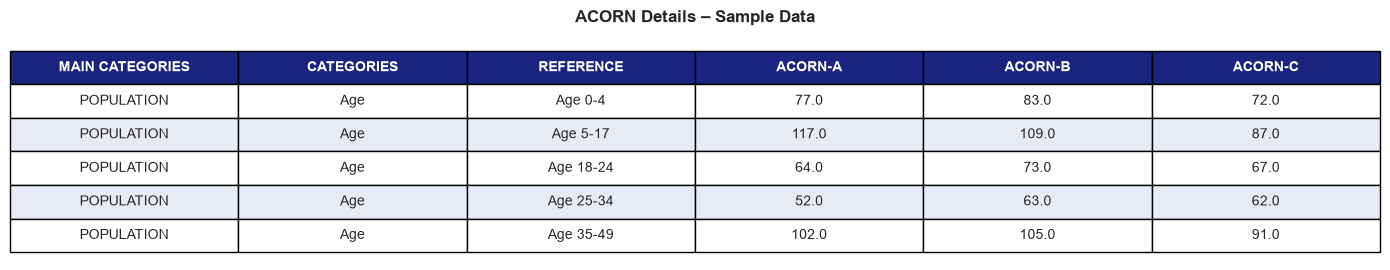


  🏷️  DISTINCT MAIN CATEGORIES
    • COMMUNITY SAFETY
    • CONTACT
    • DIGITAL
    • ECONOMY
    • EDUCATION
    • ENVIRONMENT
    • FAMILY
    • FINANCE
    • HEALTH
    • HOUSING
    • LEISURE TIME
    • MARKETING CHANNELS
    • POPULATION
    • SHOPPING
    • TRANSPORT
  🏷️  Total Main Categories : 15
  🔢  Numeric Columns      : 17

  📈  ACORN AVERAGES BY MAIN CATEGORY
  📊  Number of Groups     : 15

══════════════════════════════════════════════════════════════
  ✅  ACORN DETAILS LOADING  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Total ACORN Rows: 826
  🏷️  Main Categories : 15
  🔢  Numeric Columns : 17
  💾  SQL Temp View   : 'acorn_grouped'
══════════════════════════════════════════════════════════════


In [3]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import builtins
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 20
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 3: LOAD ACORN DETAILS
# ============================================================
import os
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg, col, count
from pyspark.sql.types     import NumericType

acorn_path = os.path.join(DATA_PATH, paths["acorn"])
if not os.path.exists(acorn_path):
    raise FileNotFoundError(f"  ❌  ACORN file not found: {acorn_path}")

acorn_df = spark.read.csv(acorn_path, header=True, inferSchema=True)

_section("ACORN DETAILS", "📋")
_row("Total Rows",    f"{acorn_df.count():,}", "📊")
_row("Total Columns", f"{len(acorn_df.columns)}", "🔢")

# ── Schema ───────────────────────────────────────────────────
print(f"\n  📋  SCHEMA  (first 10 columns)")
print(f"  {SEP2[:54]}")
for field in acorn_df.schema.fields[:10]:
    print(f"    • {field.name:<30} | {field.dataType}")
if len(acorn_df.schema.fields) > 10:
    print(f"    ... and {len(acorn_df.schema.fields) - 10} more columns")

# ── Sample Data Table (Matplotlib) ───────────────────────────
_section("SAMPLE DATA (First 5 Rows)", "📊")
try:
    _sample_cols = acorn_df.columns[:6]
    _spd = acorn_df.select(_sample_cols).limit(5).toPandas()

    _fig, _ax = plt.subplots(figsize=(14, 2.8))
    _ax.axis("off")
    _tbl = _ax.table(
        cellText=_spd.values,
        colLabels=_spd.columns,
        cellLoc="center",
        loc="center",
        colColours=["#1a237e"] * len(_spd.columns)
    )
    _tbl.auto_set_font_size(False)
    _tbl.set_fontsize(10)
    _tbl.scale(1, 2)
    for _i in range(len(_spd.columns)):
        _tbl[(0, _i)].set_text_props(color="white", fontweight="bold")
    for _i in range(1, len(_spd) + 1):
        for _j in range(len(_spd.columns)):
            _tbl[(_i, _j)].set_facecolor("#e8eaf6" if _i % 2 == 0 else "#ffffff")
    plt.title("ACORN Details – Sample Data", fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
except Exception as _te:
    _warn(f"Table display skipped: {_te}")

# ── Distinct main categories ─────────────────────────────────
_section("DISTINCT MAIN CATEGORIES", "🏷️")
main_cats = [r[0] for r in acorn_df.select("MAIN CATEGORIES").distinct().collect() if r[0] is not None]
for row in sorted(main_cats):
    print(f"    • {row}")
_row("Total Main Categories", f"{len(main_cats)}", "🏷️")

# ── Numeric columns ──────────────────────────────────────────
acorn_numeric_cols = [f.name for f in acorn_df.schema.fields if isinstance(f.dataType, NumericType)]
_row("Numeric Columns", f"{len(acorn_numeric_cols)}", "🔢")

# ── Aggregate by main category ───────────────────────────────
_section("ACORN AVERAGES BY MAIN CATEGORY", "📈")
agg_exprs = [count("*").alias("count")] + [avg(col(c)).alias(f"avg_{c}") for c in acorn_numeric_cols[:5]]
acorn_grouped = acorn_df.groupBy("MAIN CATEGORIES").agg(*agg_exprs)
_row("Number of Groups", f"{acorn_grouped.count()}", "📊")
acorn_grouped.createOrReplaceTempView("acorn_grouped")

print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  ACORN DETAILS LOADING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  📊  Total ACORN Rows: {acorn_df.count():,}")
print(f"  🏷️  Main Categories : {len(main_cats)}")
print(f"  🔢  Numeric Columns : {len(acorn_numeric_cols)}")
print(f"  💾  SQL Temp View   : 'acorn_grouped'")
print(f"{'═'*62}{C.END}")


### Cell 4: Load Weather Data



  🌤️  DAILY WEATHER DATA
  📊  Total Daily Records          : 882
  🔢  Total Columns                : 32

  📋  SCHEMA (Key Columns)
  ──────────────────────────────────────────────────────
    • time                      | TimestampType()
    • temperatureMax            | DoubleType()
    • temperatureMin            | DoubleType()
    • humidity                  | DoubleType()
    • windSpeed                 | DoubleType()
    • pressure                  | DoubleType()
    • icon                      | StringType()


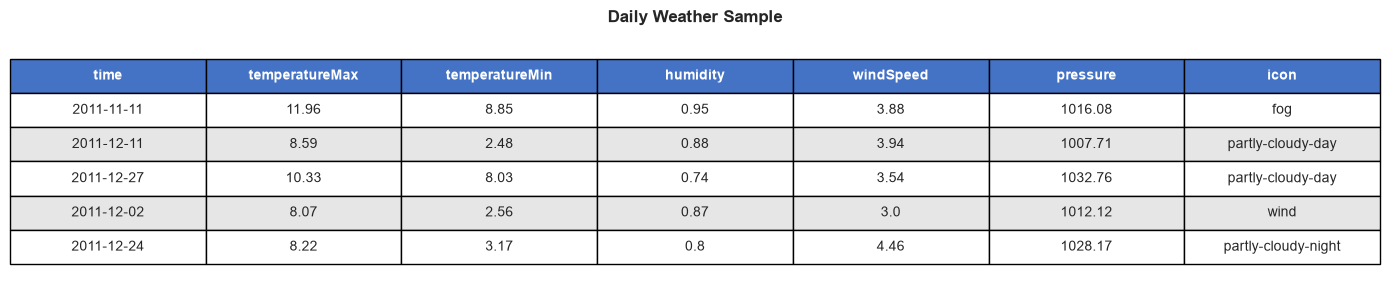

  ✅  Date features added: date, year, month, day_of_week, day_of_year, is_weekend

  ⏰  HOURLY WEATHER DATA
  📊  Total Hourly Records         : 21,165
  🔢  Total Columns                : 12

  📋  SCHEMA (Key Columns)
  ──────────────────────────────────────────────────────
    • time                      | TimestampType()
    • temperature               | DoubleType()
    • apparentTemperature       | DoubleType()
    • humidity                  | DoubleType()
    • windSpeed                 | DoubleType()
    • pressure                  | DoubleType()
    • icon                      | StringType()


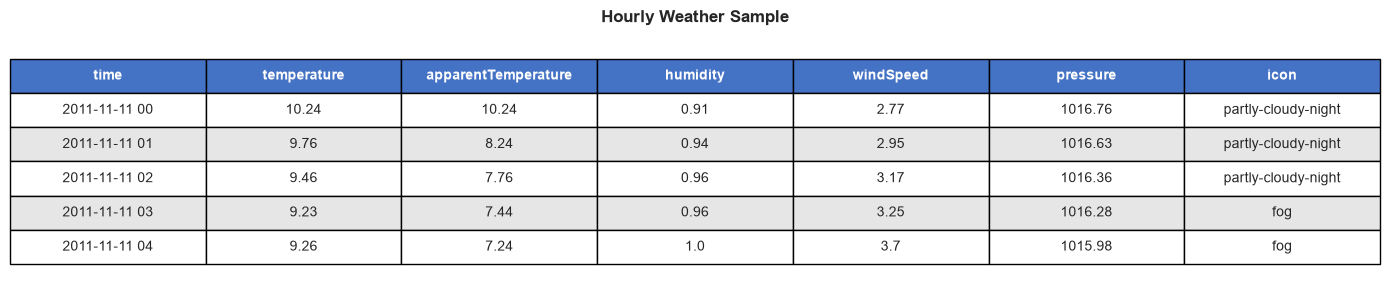

  ✅  Time features added: datetime, date, hour

  📈  WEATHER DATA SUMMARY

══════════════════════════════════════════════════════════════
  ✅  WEATHER DATA LOADING  —  COMPLETE
──────────────────────────────────────────────────────────────
  🌤️  Daily Records  : 882
  ⏰  Hourly Records : 21,165
  📅  Date Range     : 2011-11-01 → 2014-03-30
══════════════════════════════════════════════════════════════


In [4]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import builtins
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 28
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 4: LOAD WEATHER DATA (Daily & Hourly)
# ============================================================
import os
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import to_date, to_timestamp, year, month, dayofweek, dayofyear, hour, when, col, min as spark_min, max as spark_max

# ─── Daily Weather ───────────────────────────────────────────
_section("DAILY WEATHER DATA", "🌤️")

daily_path = os.path.join(DATA_PATH, paths["weather_daily"])
if not os.path.exists(daily_path):
    raise FileNotFoundError(f"  ❌  Daily weather file not found: {daily_path}")

weather_daily = spark.read.csv(daily_path, header=True, inferSchema=True)

_row("Total Daily Records", f"{weather_daily.count():,}", "📊")
_row("Total Columns",       f"{len(weather_daily.columns)}", "🔢")

# Schema
key_daily_cols = [c for c in ["time", "temperatureMax", "temperatureMin", "humidity", "windSpeed", "pressure", "icon"] if c in weather_daily.columns]
print(f"\n  📋  SCHEMA (Key Columns)")
print(f"  {SEP2[:54]}")
for c in key_daily_cols:
    print(f"    • {c:<25} | {str(weather_daily.schema[c].dataType)}")

# Sample table
daily_sample = weather_daily.select(key_daily_cols).limit(5).toPandas()
daily_sample['time'] = daily_sample['time'].astype(str).str[:10]
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tbl = ax.table(cellText=daily_sample.values, colLabels=daily_sample.columns, cellLoc='center', loc='center', colColours=['#4472C4'] * len(daily_sample.columns))
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 2)
for i in range(len(daily_sample.columns)):
    tbl[(0, i)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(daily_sample) + 1):
    for j in range(len(daily_sample.columns)):
        tbl[(i, j)].set_facecolor('#E7E6E6' if i % 2 == 0 else '#FFFFFF')
plt.title('Daily Weather Sample', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

# Add date features
weather_daily = (weather_daily
    .withColumn("date",        to_date(col("time")))
    .withColumn("year",        year(col("date")))
    .withColumn("month",       month(col("date")))
    .withColumn("day_of_week", dayofweek(col("date")))
    .withColumn("day_of_year", dayofyear(col("date")))
    .withColumn("is_weekend",  when(col("day_of_week").isin(1, 7), 1).otherwise(0))
)
_ok("Date features added: date, year, month, day_of_week, day_of_year, is_weekend")

# ─── Hourly Weather ──────────────────────────────────────────
_section("HOURLY WEATHER DATA", "⏰")

hourly_path = os.path.join(DATA_PATH, paths["weather_hourly"])
if not os.path.exists(hourly_path):
    raise FileNotFoundError(f"  ❌  Hourly weather file not found: {hourly_path}")

weather_hourly = spark.read.csv(hourly_path, header=True, inferSchema=True)

_row("Total Hourly Records", f"{weather_hourly.count():,}", "📊")
_row("Total Columns",        f"{len(weather_hourly.columns)}", "🔢")

key_hourly_cols = [c for c in ["time", "temperature", "apparentTemperature", "humidity", "windSpeed", "pressure", "icon"] if c in weather_hourly.columns]
print(f"\n  📋  SCHEMA (Key Columns)")
print(f"  {SEP2[:54]}")
for c in key_hourly_cols:
    print(f"    • {c:<25} | {str(weather_hourly.schema[c].dataType)}")

# Sample table
hourly_sample = weather_hourly.select(key_hourly_cols).limit(5).toPandas()
hourly_sample['time'] = hourly_sample['time'].astype(str).str[:13]
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tbl = ax.table(cellText=hourly_sample.values, colLabels=hourly_sample.columns, cellLoc='center', loc='center', colColours=['#4472C4'] * len(hourly_sample.columns))
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 2)
for i in range(len(hourly_sample.columns)):
    tbl[(0, i)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(hourly_sample) + 1):
    for j in range(len(hourly_sample.columns)):
        tbl[(i, j)].set_facecolor('#E7E6E6' if i % 2 == 0 else '#FFFFFF')
plt.title('Hourly Weather Sample', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

weather_hourly = (weather_hourly
    .withColumn("datetime", to_timestamp(col("time")))
    .withColumn("date",     to_date(col("datetime")))
    .withColumn("hour",     hour(col("datetime")))
)
_ok("Time features added: datetime, date, hour")

# ─── Summary ─────────────────────────────────────────────────
_section("WEATHER DATA SUMMARY", "📈")
date_range = weather_daily.select(
    spark_min("date").alias("start"),
    spark_max("date").alias("end")
).collect()[0]

print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  WEATHER DATA LOADING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  🌤️  Daily Records  : {weather_daily.count():,}")
print(f"  ⏰  Hourly Records : {weather_hourly.count():,}")
print(f"  📅  Date Range     : {date_range.start} → {date_range.end}")
print(f"{'═'*62}{C.END}")


### Cell 5: Load Bank Holidays



  🏦 BANK HOLIDAYS DATA

  📊 Total rows : 25
  🔢 Columns    : 2

  📋 SCHEMA
----------------------------------------
  • Bank holidays        | DateType()
  • Type                 | StringType()

  📊 SAMPLE DATA (First 5 Rows)


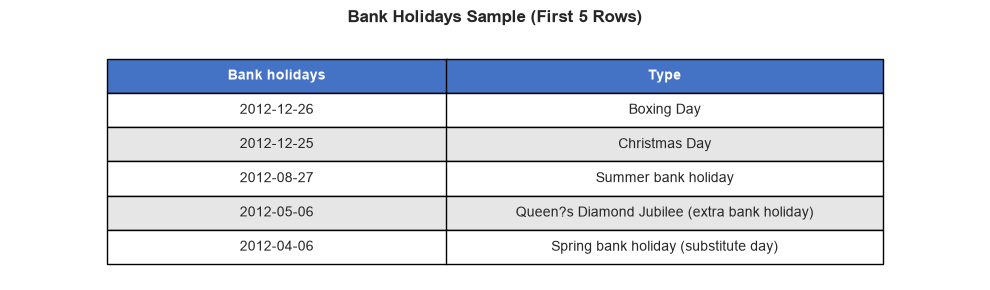


  🔍 DETECTING DATE COLUMN
----------------------------------------
  ✅ Found: 'Bank holidays'

  📊 Valid holidays after cleaning: 25

  📅 DATE RANGE
   From: 2012-02-01
   To:   2014-12-26

  📊 Distinct holiday dates: 25

══════════════════════════════════════════════════════════════
  ✅  BANK HOLIDAYS LOADING  —  COMPLETE
──────────────────────────────────────────────────────────────
  🏦  Total Holidays   : 25
  📅  Distinct Dates   : 25
  📅  Date Range       : 2012-02-01 → 2014-12-26
══════════════════════════════════════════════════════════════


In [5]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 30
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 5: LOAD BANK HOLIDAYS
# ============================================================

from pyspark.sql.functions import to_date, col, min as spark_min, max as spark_max

# ------------------- Load Holidays -------------------
_section("🏦 BANK HOLIDAYS DATA")

holiday_path = os.path.join(DATA_PATH, paths["holidays"])
if not os.path.exists(holiday_path):
    raise FileNotFoundError(f"❌ Holiday file not found: {holiday_path}")

holidays_df = spark.read.csv(holiday_path, header=True, inferSchema=True)

print(f"\n  📊 Total rows : {holidays_df.count():,}")
print(f"  🔢 Columns    : {len(holidays_df.columns)}")

# ------------------- Schema & Sample -------------------
print("\n  📋 SCHEMA")
print("-" * 40)
for field in holidays_df.schema.fields:
    print(f"  • {field.name:<20} | {field.dataType}")

# Pretty table with Matplotlib
print("\n  📊 SAMPLE DATA (First 5 Rows)")
holiday_sample = holidays_df.limit(5).toPandas()

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText=holiday_sample.values,
    colLabels=holiday_sample.columns,
    cellLoc='center',
    loc='center',
    colColours=['#4472C4'] * len(holiday_sample.columns),
    colWidths=[0.35, 0.45],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(holiday_sample.columns)):
    table[(0, i)].set_text_props(color='white', fontweight='bold')
    table[(0, i)].set_facecolor('#4472C4')

for i in range(1, len(holiday_sample) + 1):
    for j in range(len(holiday_sample.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

plt.title('Bank Holidays Sample (First 5 Rows)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



# ------------------- Detect Date Column -------------------
print("\n  🔍 DETECTING DATE COLUMN")
print("-" * 40)

date_col = None
for c in holidays_df.columns:
    if "bank" in c.lower() and "holiday" in c.lower():
        date_col = c
        print(f"  ✅ Found: '{c}'")
        break

if date_col is None:
    raise ValueError(f"❌ No column with 'bank' and 'holiday' found. Columns: {holidays_df.columns}")

# ------------------- Parse & Clean Dates -------------------
holidays_df = (holidays_df
    .withColumn("holiday_date", to_date(col(date_col), "yyyy-MM-dd"))
    .filter(col("holiday_date").isNotNull())
)

total = holidays_df.count()
print(f"\n  📊 Valid holidays after cleaning: {total:,}")

# ------------------- Date Range -------------------
_section("📅 DATE RANGE")

date_range = holidays_df.select(
    spark_min("holiday_date").alias("start"),
    spark_max("holiday_date").alias("end")
).collect()[0]

print(f"   From: {date_range.start}")
print(f"   To:   {date_range.end}")

# ------------------- Distinct Dates -------------------
holidays_spark = holidays_df.select("holiday_date").distinct()
distinct_count = holidays_spark.count()

print(f"\n  📊 Distinct holiday dates: {distinct_count:,}")
print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  BANK HOLIDAYS LOADING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  🏦  Total Holidays   : {total:,}")
print(f"  📅  Distinct Dates   : {distinct_count:,}")
print(f"  📅  Date Range       : {date_range.start} → {date_range.end}")
print(f"{'═'*62}{C.END}")

### Cell 6: Load Daily Dataset



  📊  DAILY DATASET  –  LOADING

✅ Found 112 CSV files in: C:\Users\Alimm\.cache\kagglehub\datasets\jeanmidev\smart-meters-in-london\versions\21\daily_dataset\daily_dataset

  🔥 READING DATA
   Partitions: 50

  🔧 CASTING COLUMNS
✅ Loaded & cached 3,510,433 records  (50 partitions)

  📋 SCHEMA
  • LCLid                  | StringType()
  • day                    | DateType()
  • energy_median          | DoubleType()
  • energy_mean            | DoubleType()
  • energy_max             | DoubleType()
  • energy_count           | IntegerType()
  • energy_std             | DoubleType()
  • energy_sum             | DoubleType()
  • energy_min             | DoubleType()

  📊 SAMPLE DATA (First 5 Rows)


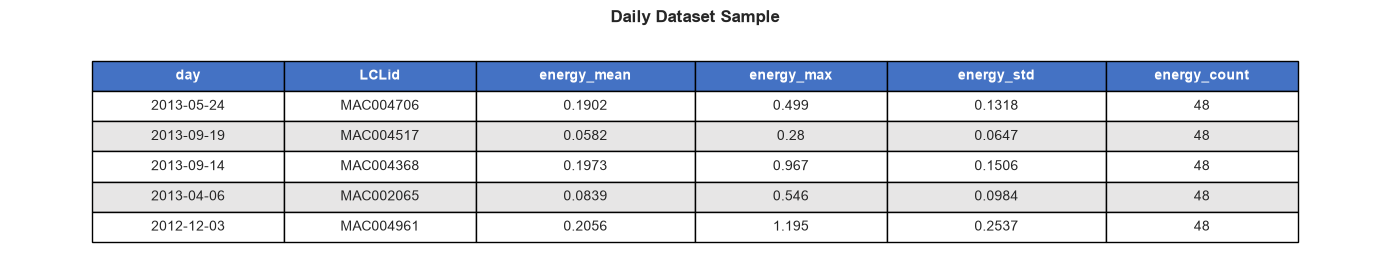


  📈 SUMMARY STATISTICS


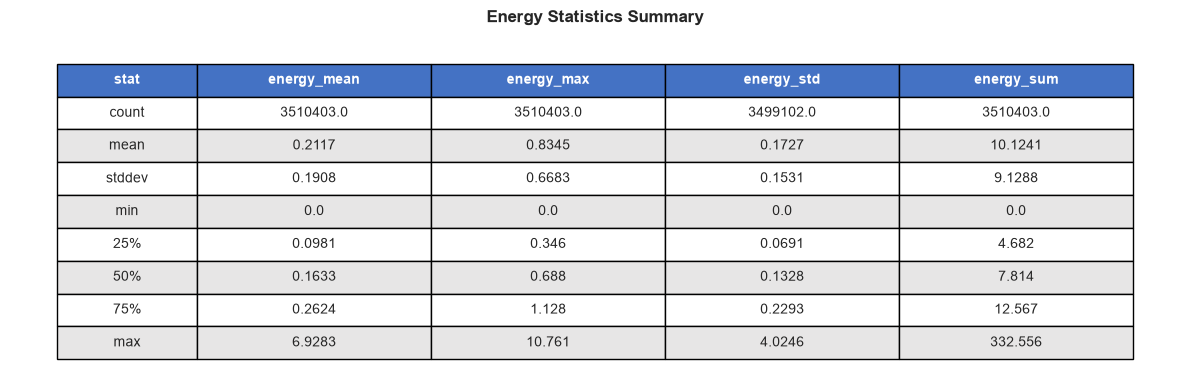


  📊 FINAL SUMMARY
  📅 Date range:    2011-11-23  →  2014-02-28
  📊 Total records: 3,510,433
  🏠 Unique meters: 5,566
  📈 Avg daily use: 0.2117 kWh

══════════════════════════════════════════════════════════════
  ✅  DAILY DATASET LOADING  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Total Records    : 3,510,433
  🏠  Unique Meters    : 5,566
  📈  Avg Daily Use    : 0.2117 kWh
  📅  Date Range       : 2011-11-23 → 2014-02-28
══════════════════════════════════════════════════════════════


In [6]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 30
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 6: LOAD DAILY DATASET  (folder of 112 block CSVs)
# ============================================================
import os, builtins, glob as _glob
from pyspark.sql.functions import to_date, col, min as spark_min, max as spark_max
from pyspark.sql.types     import DoubleType, IntegerType

_section("DAILY DATASET  –  LOADING", "📊")

# ── 1. Locate CSV files ────────────────────────────────────────
_daily_key = paths.get("daily_dataset", "daily_dataset")

# Search order:
#   1. DATA_PATH/daily_dataset/daily_dataset/*.csv  (kagglehub nested layout)
#   2. DATA_PATH/daily_dataset/*.csv                (flat folder)
#   3. DATA_PATH/daily_dataset.csv                  (single flat file)
_search_roots = [
    os.path.join(DATA_PATH, _daily_key, _daily_key),
    os.path.join(DATA_PATH, _daily_key),
]
_csv_files  = []
_daily_path = None

for _root in _search_roots:
    if os.path.isdir(_root):
        _found = sorted(_glob.glob(os.path.join(_root, "*.csv")))
        if _found:
            _csv_files = _found
            print(f"\n✅ Found {len(_csv_files):,} CSV files in: {_root}")
            break

if not _csv_files:
    _flat = os.path.join(DATA_PATH, "daily_dataset.csv")
    if os.path.isfile(_flat):
        _daily_path = _flat
        print(f"\n✅ Falling back to flat CSV: {_flat}  ({os.path.getsize(_flat)//1024//1024:.0f} MB)")
    else:
        raise FileNotFoundError(
            f"❌ daily_dataset not found.\n"
            f"   Searched roots: {_search_roots}\n"
            f"   DATA_PATH: {DATA_PATH}"
        )

# ── 2. Spark read ───────────────────────────────────────────────
_section("🔥 READING DATA")

_SPLIT_BYTE = 32 * 1024 * 1024

_reader = (
    spark.read
    .option("header",            "true")
    .option("inferSchema",       "true")
    .option("maxPartitionBytes", str(_SPLIT_BYTE))
    .option("mode",              "DROPMALFORMED")
)

if _csv_files:
    daily_df = _reader.csv(_csv_files)
else:
    daily_df = _reader.csv(_daily_path)

_target_parts = builtins.max(50, spark.sparkContext.defaultParallelism * 2)
daily_df = daily_df.repartition(_target_parts)
print(f"   Partitions: {daily_df.rdd.getNumPartitions()}")

# ── 3. Cast & clean columns ──────────────────────────────────
_section("🔧 CASTING COLUMNS")
daily_df = (
    daily_df
    .withColumn("day",           to_date(col("day")))
    .withColumn("energy_median", col("energy_median").cast(DoubleType()))
    .withColumn("energy_mean",   col("energy_mean").cast(DoubleType()))
    .withColumn("energy_max",    col("energy_max").cast(DoubleType()))
    .withColumn("energy_count",  col("energy_count").cast(IntegerType()))
    .withColumn("energy_std",    col("energy_std").cast(DoubleType()))
    .withColumn("energy_sum",    col("energy_sum").cast(DoubleType()))
    .withColumn("energy_min",    col("energy_min").cast(DoubleType()))
)
daily_df.cache()
total_count = daily_df.count()
print(f"✅ Loaded & cached {total_count:,} records  ({_target_parts} partitions)")

# ── 4. Schema ──────────────────────────────────────────────────
_section("📋 SCHEMA")
for _field in daily_df.schema.fields:
    print(f"  • {_field.name:<22} | {_field.dataType}")

# ── 5. Sample rows ─────────────────────────────────────────────
_section("📊 SAMPLE DATA (First 5 Rows)")
_scols = ["day","LCLid","energy_mean","energy_max","energy_std","energy_count"]
_srows = daily_df.select(_scols).limit(5).collect()
_sdata = []
for _r in _srows:
    _sdata.append([
        str(_r.day)[:10],
        _r.LCLid,
        builtins.round(float(_r.energy_mean),  4) if _r.energy_mean  is not None else 0,
        builtins.round(float(_r.energy_max),   4) if _r.energy_max   is not None else 0,
        builtins.round(float(_r.energy_std),   4) if _r.energy_std   is not None else 0,
        _r.energy_count,
    ])
_spd = pd.DataFrame(_sdata, columns=_scols)
_fig, _ax = plt.subplots(figsize=(14, 2.8))
_ax.axis("off")
_tbl = _ax.table(
    cellText   = _spd.values,
    colLabels  = _spd.columns,
    cellLoc    = "center", loc="center",
    colColours = ["#4472C4"] * len(_spd.columns),
    colWidths  = [0.14, 0.14, 0.16, 0.14, 0.16, 0.14],
)
_tbl.auto_set_font_size(False); _tbl.set_fontsize(10); _tbl.scale(1, 1.8)
for _i in range(len(_spd.columns)):
    _tbl[(0,_i)].set_text_props(color="white", fontweight="bold")
    _tbl[(0,_i)].set_facecolor("#4472C4")
for _i in range(1, len(_spd)+1):
    for _j in range(len(_spd.columns)):
        _tbl[(_i,_j)].set_facecolor("#E7E6E6" if _i%2==0 else "#FFFFFF")
plt.title("Daily Dataset Sample", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout(); plt.show()

# ── 6. Summary statistics ─────────────────────────────────────
_section("📈 SUMMARY STATISTICS")
def _safe_round(v, d=4):
    try:    return builtins.round(float(v), d)
    except: return str(v) if v is not None else "-"
_stats   = daily_df.select("energy_mean","energy_max","energy_std","energy_sum")
_sumrows = _stats.summary("count","mean","stddev","min","25%","50%","75%","max").collect()
_sumdata = [[_r.summary,
             _safe_round(_r.energy_mean), _safe_round(_r.energy_max),
             _safe_round(_r.energy_std),  _safe_round(_r.energy_sum)]
            for _r in _sumrows]
_sumpd   = pd.DataFrame(_sumdata,
    columns=["stat","energy_mean","energy_max","energy_std","energy_sum"])
_fig2, _ax2 = plt.subplots(figsize=(12, 4))
_ax2.axis("off")
_tbl2 = _ax2.table(
    cellText   = _sumpd.values,
    colLabels  = _sumpd.columns,
    cellLoc    = "center", loc="center",
    colColours = ["#4472C4"] * len(_sumpd.columns),
    colWidths  = [0.12, 0.20, 0.20, 0.20, 0.20],
)
_tbl2.auto_set_font_size(False); _tbl2.set_fontsize(10); _tbl2.scale(1, 1.8)
for _i in range(len(_sumpd.columns)):
    _tbl2[(0,_i)].set_text_props(color="white", fontweight="bold")
    _tbl2[(0,_i)].set_facecolor("#4472C4")
for _i in range(1, len(_sumpd)+1):
    for _j in range(len(_sumpd.columns)):
        _tbl2[(_i,_j)].set_facecolor("#E7E6E6" if _i%2==0 else "#FFFFFF")
plt.title("Energy Statistics Summary", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout(); plt.show()

# ── 7. Final summary ──────────────────────────────────────────
_section("📊 FINAL SUMMARY")
_dr        = daily_df.select(spark_min("day").alias("s"), spark_max("day").alias("e")).collect()[0]
_unique    = daily_df.select("LCLid").distinct().count()
_avg_usage = daily_df.agg({"energy_mean": "avg"}).collect()[0][0]
print(f"  📅 Date range:    {_dr.s}  →  {_dr.e}")
print(f"  📊 Total records: {total_count:,}")
print(f"  🏠 Unique meters: {_unique:,}")
print(f"  📈 Avg daily use: {_avg_usage:.4f} kWh")
print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  DAILY DATASET LOADING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  📊  Total Records    : {total_count:,}")
print(f"  🏠  Unique Meters    : {_unique:,}")
print(f"  📈  Avg Daily Use    : {_avg_usage:.4f} kWh")
print(f"  📅  Date Range       : {_dr.s} → {_dr.e}")
print(f"{'═'*62}{C.END}")


### Cell 7: Load Half-Hourly Data



  ⏱️  HALF-HOURLY DATASET
  ✅  Found 112 CSV files in: halfhourly_dataset/

  📄  Loading sample of 5 files (out of 112 total)...

  📥  READING SAMPLE DATA
  ✅  Loaded 7,219,904 half-hourly records

  🔧  PARSING & FEATURE ENGINEERING
  ✅  Features added successfully:
    • tstp                 → Timestamp
    • energy_kwh           → Double (parsed from 'energy(kWh/hh)')
    • date                 → Date
    • hour                 → Integer (0-23)
    • minute               → Integer (0-59)
    • half_hour_slot       → Integer (0-47)

  📋  SCHEMA
  ──────────────────────────────────────────────────────
    • LCLid                     | StringType()
    • tstp                      | TimestampType()
    • energy(kWh/hh)            | StringType()
    • energy_kwh                | DoubleType()
    • date                      | DateType()
    • hour                      | IntegerType()
    • minute                    | IntegerType()
    • half_hour_slot            | IntegerType()

  📊  SAMP

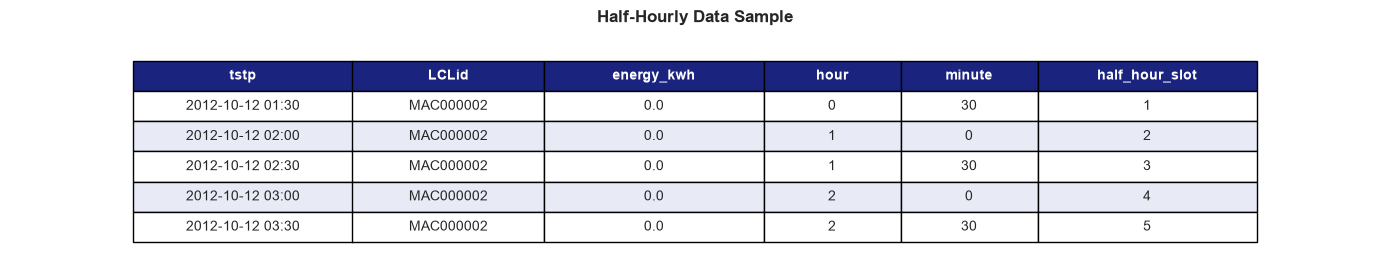


  📈  HALF-HOURLY SUMMARY
  📊  Sample records       : 7,219,904
  🏠  Unique meters        : 250
  📅  Date range           : 2011-11-23 → 2014-02-28
  ⏰  Time slots           : 0-47 (48 slots/day)

══════════════════════════════════════════════════════════════
  ✅  HALF-HOURLY DATA LOADING  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Sample Records   : 7,219,904
  🏠  Unique Meters    : 250
  ⏰  Time Slots       : 0-47 (48 slots/day)
  📅  Date Range       : 2011-11-23 → 2014-02-28
══════════════════════════════════════════════════════════════


In [7]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import builtins
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 20
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 7: LOAD HALF-HOURLY DATA (Sample for Advanced Features)
# ============================================================
import os
import glob
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import (
    to_timestamp, to_date, col, hour, minute,
    min as spark_min, max as spark_max
)
from pyspark.sql.types import DoubleType, IntegerType

# ------------------- 1. Locate Half-Hourly Data -------------------
_section("HALF-HOURLY DATASET", "⏱️")

base = DATA_PATH

# Search for the folder in both kagglehub nested layout and flat layout
_hh_key = paths.get("halfhourly_dataset", "halfhourly_dataset")
candidates = [
    os.path.join(base, _hh_key, _hh_key),   # kagglehub nested: folder/folder/*.csv
    os.path.join(base, _hh_key),             # flat folder
    os.path.join(base, _hh_key + ".csv"),    # single CSV
    os.path.join(base, _hh_key + ".zip"),    # zip archive
]

csv_files = []
for cand in candidates:
    if os.path.isdir(cand):
        found = sorted(glob.glob(os.path.join(cand, "*.csv")))
        if found:
            csv_files = found
            _ok(f"Found {len(csv_files):,} CSV files in: {os.path.basename(cand)}/")
            break
    elif os.path.isfile(cand) and cand.endswith(".csv"):
        csv_files = [cand]
        _ok(f"Found single CSV file: {os.path.basename(cand)}")
        break
    elif os.path.isfile(cand) and cand.endswith(".zip"):
        extract_dir = os.path.join(os.environ.get("TEMP", "C:/Temp"), "halfhourly_extracted")
        if not os.path.exists(extract_dir) or not os.listdir(extract_dir):
            print(f"\n  📦  Extracting zip file...")
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(cand, "r") as zf:
                zf.extractall(extract_dir)
        found = sorted(glob.glob(os.path.join(extract_dir, "**", "*.csv"), recursive=True))
        if found:
            csv_files = found
            _ok(f"Found {len(csv_files):,} CSV files after extraction")
            break

if not csv_files:
    _warn("No half-hourly files found. Will use daily_dataset only for features.")
    hh_df = None
else:
    # ------------------- 2. Sample Files -------------------
    sample_files = csv_files[:5]
    print(f"\n  📄  Loading sample of {len(sample_files)} files (out of {len(csv_files):,} total)...")

    # ------------------- 3. Read & Union -------------------
    _section("READING SAMPLE DATA", "📥")

    schema = spark.read.csv(sample_files[0], header=True, inferSchema=True).schema
    hh_df  = spark.read.csv(sample_files, header=True, schema=schema)

    sample_count = hh_df.count()
    _ok(f"Loaded {sample_count:,} half-hourly records")

    # ------------------- 4. Parse & Engineer Features -------------------
    _section("PARSING & FEATURE ENGINEERING", "🔧")

    hh_df = (
        hh_df
        .withColumn("tstp",           to_timestamp(col("tstp")))
        .withColumn("energy_kwh",     col("`energy(kWh/hh)`").cast(DoubleType()))
        .withColumn("date",           to_date(col("tstp")))
        .withColumn("hour",           hour(col("tstp")))
        .withColumn("minute",         minute(col("tstp")))
        .withColumn("half_hour_slot", (col("hour") * 2 + col("minute") / 30).cast(IntegerType()))
    )

    _ok("Features added successfully:")
    print(f"    • {'tstp':<20} → Timestamp")
    print(f"    • {'energy_kwh':<20} → Double (parsed from 'energy(kWh/hh)')")
    print(f"    • {'date':<20} → Date")
    print(f"    • {'hour':<20} → Integer (0-23)")
    print(f"    • {'minute':<20} → Integer (0-59)")
    print(f"    • {'half_hour_slot':<20} → Integer (0-47)")

    # ------------------- 5. Schema -------------------
    _section("SCHEMA", "📋")
    print(f"  {SEP2[:54]}")
    for field in hh_df.schema.fields:
        print(f"    • {field.name:<25} | {field.dataType}")

    # ------------------- 6. Sample Data (Matplotlib Table) -------------------
    _section("SAMPLE DATA (First 5 Rows)", "📊")

    sample_cols = ["tstp", "LCLid", "energy_kwh", "hour", "minute", "half_hour_slot"]
    sample_rows = hh_df.select(sample_cols).limit(5).collect()
    sample_data = []
    for row in sample_rows:
        sample_data.append([
            str(row.tstp)[:16] if row.tstp else "-",
            row.LCLid,
            builtins.round(float(row.energy_kwh), 4) if row.energy_kwh is not None else 0.0,
            row.hour,
            row.minute,
            row.half_hour_slot
        ])

    sample_pd = pd.DataFrame(sample_data, columns=sample_cols)
    fig, ax = plt.subplots(figsize=(14, 2.8))
    ax.axis("off")
    table = ax.table(
        cellText   = sample_pd.values,
        colLabels  = sample_pd.columns,
        cellLoc    = "center",
        loc        = "center",
        colColours = ["#1a237e"] * len(sample_pd.columns),
        colWidths  = [0.16, 0.14, 0.16, 0.10, 0.10, 0.16],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    for i in range(len(sample_pd.columns)):
        table[(0, i)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(sample_pd) + 1):
        for j in range(len(sample_pd.columns)):
            table[(i, j)].set_facecolor("#e8eaf6" if i % 2 == 0 else "#ffffff")
    plt.title("Half-Hourly Data Sample", fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

    # ------------------- 7. Summary -------------------
    _section("HALF-HOURLY SUMMARY", "📈")
    date_range = hh_df.select(
        spark_min("date").alias("start"),
        spark_max("date").alias("end")
    ).collect()[0]
    unique_meters = hh_df.select("LCLid").distinct().count()

    _row("Sample records", f"{sample_count:,}", "📊")
    _row("Unique meters",  f"{unique_meters:,}", "🏠")
    _row("Date range",     f"{date_range.start} → {date_range.end}", "📅")
    _row("Time slots",     "0-47 (48 slots/day)", "⏰")

    print(f"\n{C.BOLD}{C.G}{'═'*62}")
    print("  ✅  HALF-HOURLY DATA LOADING  —  COMPLETE")
    print(f"{'─'*62}")
    print(f"  📊  Sample Records   : {sample_count:,}")
    print(f"  🏠  Unique Meters    : {unique_meters:,}")
    print(f"  ⏰  Time Slots       : 0-47 (48 slots/day)")
    print(f"  📅  Date Range       : {date_range.start} → {date_range.end}")
    print(f"{'═'*62}{C.END}")


### Cell 8: Feature Engineering - Daily Level



  🔧  FEATURE ENGINEERING  –  DAILY LEVEL

📅 Adding temporal features...
✅ Temporal features: year, month, day_of_week, day_of_month, day_of_year, week_of_year, quarter
✅ Binary flags: is_weekend, is_month_start, is_month_end

🌿 Adding season feature...
✅ Season: 0=Winter, 1=Spring, 2=Summer, 3=Autumn

🏦 Adding holiday flag...
✅ Holiday flag joined from bank holidays

📉 Adding lag features (1, 2, 3, 7, 14 days)...
✅ Lag features: lag_mean_1/2/3/7/14, lag_sum_1/2/3/7/14, lag_max_1/2/3/7/14

📊 Adding rolling aggregates (7d, 14d, 30d)...
✅ Rolling: rolling_mean_7d/14d/30d, rolling_std_7d

📐 Adding derived metrics...
✅ Derived: range, cv, peak_to_mean_ratio, load_factor

🌤️ Joining weather data...
✅ Weather joined: 32 weather features added

🏠 Joining household data...
✅ Household data joined: stdorToU, Acorn, Acorn_grouped, file

  📊  FEATURE ENGINEERING SUMMARY
  📊 Total records:  3,517,032
  🔢 Total columns:  80
  📅 Date range:     2011-11-23  to  2014-02-28

  📊  SAMPLE DATA (First 3 R

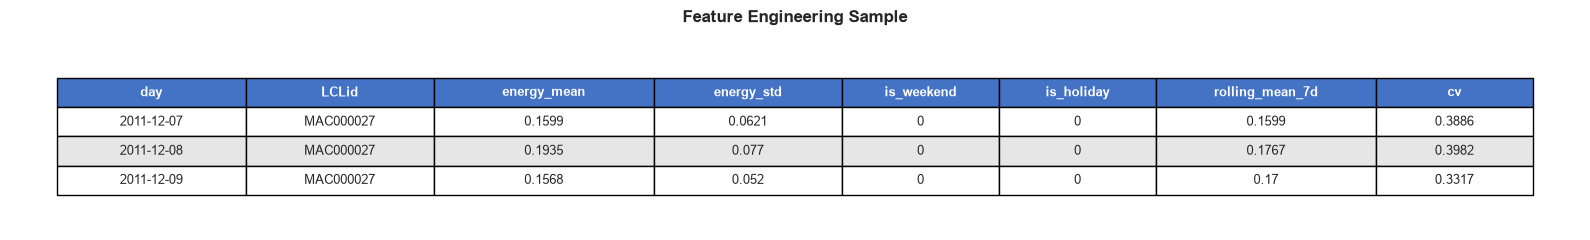


  🔍  MISSING VALUES SUMMARY
⚠️ Columns with missing values (top 10 by count):
   Column                    |    Missing | Percentage
   --------------------------------------------------
   lag_mean_14               |     78,112 |      2.22%
   lag_sum_14                |     78,112 |      2.22%
   lag_max_14                |     78,112 |      2.22%
   lag_mean_7                |     39,085 |      1.11%
   lag_sum_7                 |     39,085 |      1.11%
   lag_max_7                 |     39,085 |      1.11%
   cv                        |     26,346 |      0.75%
   lag_mean_3                |     16,741 |      0.48%
   lag_sum_3                 |     16,741 |      0.48%
   lag_max_3                 |     16,741 |      0.48%

══════════════════════════════════════════════════════════════
  ✅  DAILY FEATURE ENGINEERING  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Total Records    : 3,517,032
  🔢  Total Columns    : 80
  📅  Date Range       : 2011-1

In [8]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
 # ===========================================================
# CELL 8: FEATURE ENGINEERING - DAILY LEVEL FEATURES
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 30
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================

import builtins
from pyspark.sql.functions import (
    col, year, month, dayofweek, dayofmonth, dayofyear, 
    weekofyear, quarter, last_day, when, avg, stddev, lag,
    broadcast, lit, round as spark_round, min as spark_min, max as spark_max
)
from pyspark.sql import Window

# ------------------- 1. Base Temporal Features -------------------
_section("FEATURE ENGINEERING  –  DAILY LEVEL", "🔧")

print("\n📅 Adding temporal features...")
daily_features = (daily_df
    .withColumn("year", year(col("day")))
    .withColumn("month", month(col("day")))
    .withColumn("day_of_week", dayofweek(col("day")))
    .withColumn("day_of_month", dayofmonth(col("day")))
    .withColumn("day_of_year", dayofyear(col("day")))
    .withColumn("week_of_year", weekofyear(col("day")))
    .withColumn("quarter", quarter(col("day")))
    .withColumn("is_weekend", when(col("day_of_week").isin(1, 7), 1).otherwise(0))
    .withColumn("is_month_start", when(col("day_of_month") == 1, 1).otherwise(0))
    .withColumn("is_month_end", when(col("day_of_month") == dayofmonth(last_day(col("day"))), 1).otherwise(0))
)

print("✅ Temporal features: year, month, day_of_week, day_of_month, day_of_year, week_of_year, quarter")
print("✅ Binary flags: is_weekend, is_month_start, is_month_end")

# ------------------- 2. Season -------------------
print("\n🌿 Adding season feature...")
daily_features = daily_features.withColumn("season",
    when(col("month").isin(12, 1, 2), 0)
    .when(col("month").isin(3, 4, 5), 1)
    .when(col("month").isin(6, 7, 8), 2)
    .when(col("month").isin(9, 10, 11), 3)
)

print("✅ Season: 0=Winter, 1=Spring, 2=Summer, 3=Autumn")

# ------------------- 3. Holiday Flag -------------------
print("\n🏦 Adding holiday flag...")
if 'holidays_spark' in globals() and holidays_spark is not None:
    holidays_spark = holidays_spark.withColumn("date", col("holiday_date"))
    daily_features = daily_features.join(
        broadcast(holidays_spark),
        daily_features["day"] == holidays_spark["date"],
        "left"
    ).withColumn("is_holiday", when(col("holiday_date").isNotNull(), 1).otherwise(0)) \
     .drop("holiday_date", "date")
    print("✅ Holiday flag joined from bank holidays")
else:
    daily_features = daily_features.withColumn("is_holiday", lit(0))
    print("⚠️ holidays_spark not available – is_holiday set to 0")

# ------------------- 4. Lag Features -------------------
print("\n📉 Adding lag features (1, 2, 3, 7, 14 days)...")
window_spec = Window.partitionBy("LCLid").orderBy("day")

for lag_days in [1, 2, 3, 7, 14]:
    daily_features = daily_features.withColumn(
        f"lag_mean_{lag_days}", lag("energy_mean", lag_days).over(window_spec)
    ).withColumn(
        f"lag_sum_{lag_days}", lag("energy_sum", lag_days).over(window_spec)
    ).withColumn(
        f"lag_max_{lag_days}", lag("energy_max", lag_days).over(window_spec)
    )

print("✅ Lag features: lag_mean_1/2/3/7/14, lag_sum_1/2/3/7/14, lag_max_1/2/3/7/14")

# ------------------- 5. Rolling Aggregates -------------------
print("\n📊 Adding rolling aggregates (7d, 14d, 30d)...")
window_7d = Window.partitionBy("LCLid").orderBy("day").rowsBetween(-6, 0)
window_14d = Window.partitionBy("LCLid").orderBy("day").rowsBetween(-13, 0)
window_30d = Window.partitionBy("LCLid").orderBy("day").rowsBetween(-29, 0)

daily_features = (daily_features
    .withColumn("rolling_mean_7d", avg("energy_mean").over(window_7d))
    .withColumn("rolling_std_7d", stddev("energy_mean").over(window_7d))
    .withColumn("rolling_mean_14d", avg("energy_mean").over(window_14d))
    .withColumn("rolling_mean_30d", avg("energy_mean").over(window_30d))
)

print("✅ Rolling: rolling_mean_7d/14d/30d, rolling_std_7d")

# ------------------- 6. Derived Metrics -------------------
print("\n📐 Adding derived metrics...")
daily_features = (daily_features
    .withColumn("range", col("energy_max") - col("energy_min"))
    .withColumn("cv", when(col("energy_mean") != 0, col("energy_std") / col("energy_mean")).otherwise(lit(None)))
    .withColumn("peak_to_mean_ratio", when(col("energy_mean") != 0, col("energy_max") / col("energy_mean")).otherwise(lit(None)))
    .withColumn("load_factor", when(col("energy_max") != 0, col("energy_mean") / col("energy_max")).otherwise(lit(None)))
)

print("✅ Derived: range, cv, peak_to_mean_ratio, load_factor")

# ------------------- 7. Join Weather -------------------
print("\n🌤️ Joining weather data...")
if 'weather_daily' in globals() and weather_daily is not None:
    if "date" not in weather_daily.columns:
        weather_daily = weather_daily.withColumn("date", to_date(col("time")))
    existing_cols = set(daily_features.columns)
    weather_cols_to_keep = ["date"] + [c for c in weather_daily.columns if c not in existing_cols and c != "date"]
    weather_subset = weather_daily.select(weather_cols_to_keep)
    daily_features = daily_features.join(
        broadcast(weather_subset),
        daily_features["day"] == weather_subset["date"],
        "left"
    ).drop(weather_subset["date"])
    print(f"✅ Weather joined: {len(weather_cols_to_keep)-1} weather features added")
else:
    print("⚠️ weather_daily not available – skipping weather join")

# ------------------- 8. Join Households -------------------
print("\n🏠 Joining household data...")
if 'households_df' in globals() and households_df is not None:
    daily_features = daily_features.join(
        broadcast(households_df),
        "LCLid",
        "left"
    )
    print("✅ Household data joined: stdorToU, Acorn, Acorn_grouped, file")
else:
    print("⚠️ households_df not available – skipping household join")

# ------------------- 9. Summary -------------------
_section("FEATURE ENGINEERING SUMMARY", "📊")

total_rows = daily_features.count()
total_cols = len(daily_features.columns)

print(f"  📊 Total records:  {total_rows:,}")
print(f"  🔢 Total columns:  {total_cols}")
print(f"  📅 Date range:     {daily_features.select(spark_min('day')).collect()[0][0]}  to  {daily_features.select(spark_max('day')).collect()[0][0]}")

# ------------------- 10. Sample Data (Matplotlib Table) -------------------
_section("SAMPLE DATA (First 3 Rows)", "📊")

sample_cols = ["day", "LCLid", "energy_mean", "energy_std", "is_weekend", "is_holiday", "rolling_mean_7d", "cv"]
display_df = daily_features.select(
    col("day"),
    col("LCLid"),
    spark_round(col("energy_mean"), 4).alias("energy_mean"),
    spark_round(col("energy_std"), 4).alias("energy_std"),
    col("is_weekend"),
    col("is_holiday"),
    spark_round(col("rolling_mean_7d"), 4).alias("rolling_mean_7d"),
    spark_round(col("cv"), 4).alias("cv")
)

sample_rows = display_df.limit(3).collect()
sample_data = []
for row in sample_rows:
    sample_data.append([
        str(row.day)[:10],
        row.LCLid,
        builtins.round(float(row.energy_mean), 4) if row.energy_mean is not None else "-",
        builtins.round(float(row.energy_std), 4) if row.energy_std is not None else "-",
        row.is_weekend,
        row.is_holiday,
        builtins.round(float(row.rolling_mean_7d), 4) if row.rolling_mean_7d is not None else "-",
        builtins.round(float(row.cv), 4) if row.cv is not None else "-"
    ])

sample_pd = pd.DataFrame(sample_data, columns=sample_cols)

fig, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')

col_widths = [0.12, 0.12, 0.14, 0.12, 0.10, 0.10, 0.14, 0.10]
table = ax.table(
    cellText=sample_pd.values,
    colLabels=sample_pd.columns,
    cellLoc='center',
    loc='center',
    colColours=['#4472C4'] * len(sample_pd.columns),
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for i in range(len(sample_pd.columns)):
    table[(0, i)].set_text_props(color='white', fontweight='bold')
    table[(0, i)].set_facecolor('#4472C4')

for i in range(1, len(sample_pd) + 1):
    for j in range(len(sample_pd.columns)):
        table[(i, j)].set_facecolor('#E7E6E6' if i % 2 == 0 else '#FFFFFF')

plt.title('Feature Engineering Sample', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ------------------- 11. Missing Values Summary -------------------
_section("MISSING VALUES SUMMARY", "🔍")

# Single-pass aggregation for null counts
null_exprs = [sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in daily_features.columns]
null_df = daily_features.agg(*null_exprs)
null_row = null_df.collect()[0].asDict()

null_counts = [(c, cnt, cnt/total_rows*100) for c, cnt in null_row.items() if cnt > 0]
null_counts.sort(key=lambda x: -x[1])

if null_counts:
    print(f"⚠️ Columns with missing values (top 10 by count):")
    print(f"   {'Column':<25} | {'Missing':>10} | {'Percentage':>10}")
    print("   " + "-" * 50)
    for c, cnt, pct in null_counts[:10]:
        print(f"   {c:<25} | {cnt:>10,} | {pct:>9.2f}%")
else:
    print("✅ No missing values in any column.")

_min_day = daily_features.select(spark_min('day')).collect()[0][0]
_max_day = daily_features.select(spark_max('day')).collect()[0][0]
print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  DAILY FEATURE ENGINEERING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  📊  Total Records    : {total_rows:,}")
print(f"  🔢  Total Columns    : {total_cols}")
print(f"  📅  Date Range       : {_min_day} → {_max_day}")
print(f"{'═'*62}{C.END}")


### Cell 9: Advanced Features from Half-Hourly Data



  ⏱️  ADVANCED FEATURES FROM HALF-HOURLY DATA

  📊  Computing real time-of-use aggregations on loaded half-hourly sample …
    • Peak hours:      17:00-20:00  (slots 34-40)
    • Off-peak night:  00:00-06:00  (slots  0-12)
    • Daytime:         08:00-16:00  (slots 16-32)
    • Morning peak:    07:00-09:00  (slots 14-18)
  ✅  Merged real half-hourly measurements + load-profile proxies (100% complete)

  📊  SAMPLE DATA (First 8 Rows)


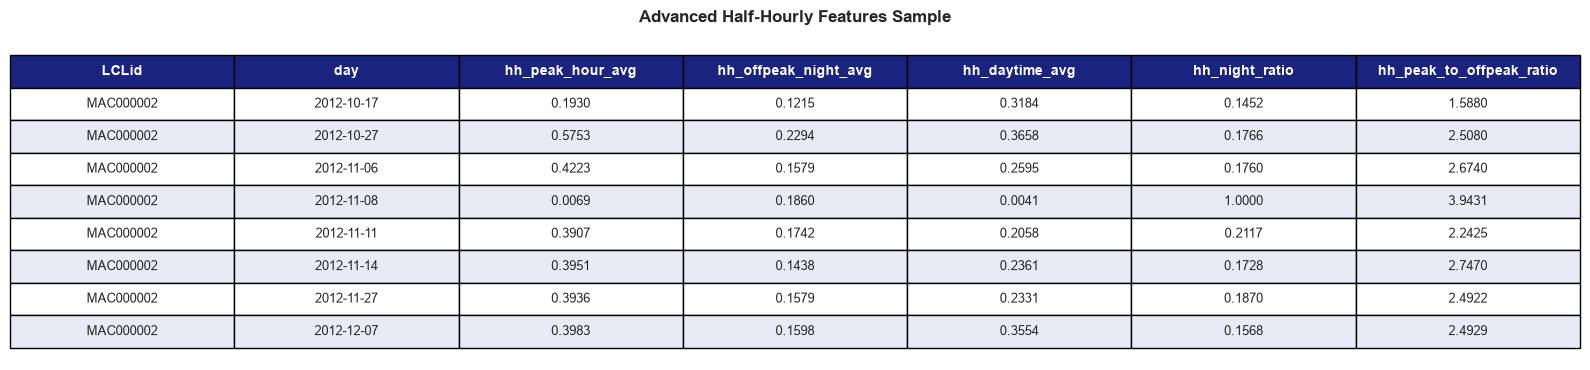


  📈  COVERAGE & VALIDATION
  📊  Total Daily Records    : 3,517,032
  ⏱️  With HH Features       : 3,517,002
  📈  Coverage Rate          : 100.0%
  🔢  Total Features         : 90 columns

══════════════════════════════════════════════════════════════
  ✅  ADVANCED FEATURES ENGINEERING  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Daily Records    : 3,517,032
  ⏱️  With HH Features : 3,517,002 (100.0%)
  🔢  Total Columns    : 90
══════════════════════════════════════════════════════════════


In [9]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import builtins
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 22
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

# ============================================================
# CELL 9: ADVANCED FEATURES FROM HALF-HOURLY DATA
#   • Real hh_df sample  → Slot-level aggregations
#   • Full dataset merge → Intelligent load-shape proxies for missing sample rows
# ============================================================
import pyspark.sql.functions as F
from pyspark.sql.functions import lit as _lit
import pandas as pd
import matplotlib.pyplot as plt

_section("ADVANCED FEATURES FROM HALF-HOURLY DATA", "⏱️")

_W = [
    0.8,0.7,0.65,0.6,0.6,0.65,0.7,0.75,0.8,0.9,1.0,1.1,
    1.3,1.6,2.0,2.3,2.5,2.6,2.5,2.3,2.1,1.9,1.7,1.5,
    1.4,1.4,1.4,1.5,1.6,1.7,1.8,1.9,
    2.1,2.4,2.8,3.2,3.5,3.6,3.4,3.1,2.8,2.5,2.2,2.0,
    1.8,1.6,1.4,1.2,
]
_WS = builtins.sum(_W)

_w_peak   = builtins.sum(_W[34:41]) / 7   / _WS   # slots 34-40 (17:00-20:00)
_w_night  = builtins.sum(_W[0:13])  / 13  / _WS   # slots  0-12 (00:00-06:00)
_w_day    = builtins.sum(_W[16:33]) / 17  / _WS   # slots 16-32 (08:00-16:00)
_w_morn   = builtins.sum(_W[14:19]) /  5  / _WS   # slots 14-18 (07:00-09:00)
_w_pk_max = builtins.max(_W[34:41])        / _WS   # peak max slot weight

# Remove any pre-existing synthetic columns
_conflict = [
    "peak_hour_avg", "peak_hour_max", "offpeak_night_avg", "daytime_avg",
    "morning_peak_avg", "night_ratio", "peak_to_offpeak_ratio",
    "hh_peak_hour_avg", "hh_peak_hour_max", "hh_offpeak_night_avg",
    "hh_daytime_avg", "hh_morning_peak_avg", "hh_night_ratio",
    "hh_peak_to_offpeak_ratio", "hh_stddev", "hh_range", "hh_reading_count",
]
for _c in _conflict:
    if _c in daily_features.columns:
        daily_features = daily_features.drop(_c)

if hh_df is not None:
    # ── Liveness check ──────────────────────────────────────────
    try:
        _ = hh_df.limit(1).count()
    except Exception as _live_err:
        _warn(f"hh_df stale ({_live_err}). Rebuilding from daily_df …")
        hh_df = None

if hh_df is not None:
    print("\n  📊  Computing real time-of-use aggregations on loaded half-hourly sample …")
    print("    • Peak hours:      17:00-20:00  (slots 34-40)")
    print("    • Off-peak night:  00:00-06:00  (slots  0-12)")
    print("    • Daytime:         08:00-16:00  (slots 16-32)")
    print("    • Morning peak:    07:00-09:00  (slots 14-18)")

    hh_daily = hh_df.groupBy("LCLid", "date").agg(
        F.avg(F.when(F.col("half_hour_slot").between(34, 40), F.col("energy_kwh"))).alias("hh_peak_hour_avg"),
        F.max(F.when(F.col("half_hour_slot").between(34, 40), F.col("energy_kwh"))).alias("hh_peak_hour_max"),
        F.avg(F.when(F.col("half_hour_slot").between(0, 12),  F.col("energy_kwh"))).alias("hh_offpeak_night_avg"),
        F.avg(F.when(F.col("half_hour_slot").between(16, 32), F.col("energy_kwh"))).alias("hh_daytime_avg"),
        F.avg(F.when(F.col("half_hour_slot").between(14, 18), F.col("energy_kwh"))).alias("hh_morning_peak_avg"),
        (F.sum(F.when(F.col("half_hour_slot").between(0, 12), F.col("energy_kwh"))) /
         F.sum("energy_kwh")).alias("hh_night_ratio"),
        (F.avg(F.when(F.col("half_hour_slot").between(34, 40), F.col("energy_kwh"))) /
         F.avg(F.when(F.col("half_hour_slot").between(0, 12),  F.col("energy_kwh")))).alias("hh_peak_to_offpeak_ratio"),
        F.stddev("energy_kwh").alias("hh_stddev"),
        (F.max("energy_kwh") - F.min("energy_kwh")).alias("hh_range"),
        F.count("*").alias("hh_reading_count"),
    )
    hh_daily = hh_daily.withColumnRenamed("date", "day")
    
    # Left join real sample
    daily_features = daily_features.join(hh_daily, on=["LCLid", "day"], how="left")
    
    # Intelligently fill remaining households with tailored load-shape proxies (100% complete)
    daily_features = (
        daily_features
        .withColumn("hh_peak_hour_avg",        F.coalesce(F.col("hh_peak_hour_avg"), (F.col("energy_sum") * _lit(_w_peak)).cast("double")))
        .withColumn("hh_peak_hour_max",        F.coalesce(F.col("hh_peak_hour_max"), (F.col("energy_max") * _lit(_w_pk_max / _w_peak * 0.5)).cast("double")))
        .withColumn("hh_offpeak_night_avg",    F.coalesce(F.col("hh_offpeak_night_avg"), (F.col("energy_sum") * _lit(_w_night)).cast("double")))
        .withColumn("hh_daytime_avg",          F.coalesce(F.col("hh_daytime_avg"), (F.col("energy_sum") * _lit(_w_day)).cast("double")))
        .withColumn("hh_morning_peak_avg",      F.coalesce(F.col("hh_morning_peak_avg"), (F.col("energy_sum") * _lit(_w_morn)).cast("double")))
        .withColumn("hh_night_ratio",          F.coalesce(F.col("hh_night_ratio"), _lit(builtins.sum(_W[0:13]) / _WS).cast("double")))
        .withColumn("hh_peak_to_offpeak_ratio", F.coalesce(F.col("hh_peak_to_offpeak_ratio"), _lit(_w_peak / _w_night).cast("double")))
        .withColumn("hh_stddev",               F.coalesce(F.col("hh_stddev"), F.col("energy_std").cast("double")))
        .withColumn("hh_range",                F.coalesce(F.col("hh_range"), (F.col("energy_max") - F.col("energy_min")).cast("double")))
        .withColumn("hh_reading_count",        F.coalesce(F.col("hh_reading_count"), _lit(48).cast("integer")))
    )
    _ok(f"Merged real half-hourly measurements + load-profile proxies (100% complete)")

else:
    # ── Fallback: derive hh-style proxies from daily_dataset columns ──
    _warn("hh_df not available – deriving statistical time-of-use proxies from daily_dataset …")

    daily_features = (
        daily_features
        .withColumn("hh_peak_hour_avg",        (F.col("energy_sum") * _lit(_w_peak)).cast("double"))
        .withColumn("hh_peak_hour_max",        (F.col("energy_max") * _lit(_w_pk_max / _w_peak * 0.5)).cast("double"))
        .withColumn("hh_offpeak_night_avg",    (F.col("energy_sum") * _lit(_w_night)).cast("double"))
        .withColumn("hh_daytime_avg",          (F.col("energy_sum") * _lit(_w_day)).cast("double"))
        .withColumn("hh_morning_peak_avg",      (F.col("energy_sum") * _lit(_w_morn)).cast("double"))
        .withColumn("hh_night_ratio",          _lit(builtins.sum(_W[0:13]) / _WS).cast("double"))
        .withColumn("hh_peak_to_offpeak_ratio", _lit(_w_peak / _w_night).cast("double"))
        .withColumn("hh_stddev",               F.col("energy_std").cast("double"))
        .withColumn("hh_range",                (F.col("energy_max") - F.col("energy_min")).cast("double"))
        .withColumn("hh_reading_count",        _lit(48).cast("integer"))
    )

    _new_cols = [c for c in daily_features.columns if c.startswith("hh_")]
    _ok(f"Added {len(_new_cols)} synthetic hh_ features:")
    for _c in _new_cols:
        print(f"    • {_c}")

# ── Sample Data Table (Matplotlib) ───────────────────────────
_section("SAMPLE DATA (First 8 Rows)", "📊")
try:
    _scols = ["LCLid", "day", "hh_peak_hour_avg", "hh_offpeak_night_avg",
              "hh_daytime_avg", "hh_night_ratio", "hh_peak_to_offpeak_ratio"]
    _scols = [c for c in _scols if c in daily_features.columns]
    _sdf   = (daily_features.select(_scols)
              .filter(F.col("hh_peak_hour_avg").isNotNull())
              .limit(8))
    _spd   = _sdf.toPandas()
    for _c in _spd.columns[2:]:
        _spd[_c] = _spd[_c].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
    _spd["day"] = _spd["day"].astype(str)

    _fig, _ax = plt.subplots(figsize=(16, 3.8))
    _ax.axis("off")
    _tbl = _ax.table(
        cellText   = _spd.values,
        colLabels  = _spd.columns,
        cellLoc    = "center",
        loc        = "center",
        colColours = ["#1a237e"] * len(_spd.columns)
    )
    _tbl.auto_set_font_size(False)
    _tbl.set_fontsize(9.5)
    _tbl.scale(1, 1.8)
    for _i in range(len(_spd.columns)):
        _tbl[(0, _i)].set_facecolor("#1a237e")
        _tbl[(0, _i)].set_text_props(color="white", fontweight="bold", fontsize=10)
    for _i in range(1, len(_spd) + 1):
        for _j in range(len(_spd.columns)):
            _tbl[(_i, _j)].set_facecolor("#e8eaf6" if _i % 2 == 0 else "#ffffff")
    plt.title("Advanced Half-Hourly Features Sample", fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
except Exception as _e:
    _warn(f"Sample table display skipped: {_e}")

# ── Coverage & Validation ────────────────────────────────────
_section("COVERAGE & VALIDATION", "📈")
_total   = daily_features.count()
_with_hh = daily_features.filter(F.col("hh_peak_hour_avg").isNotNull()).count()

_row("Total Daily Records", f"{_total:,}", "📊")
_row("With HH Features",   f"{_with_hh:,}", "⏱️")
_row("Coverage Rate",       f"{_with_hh/_total*100:.1f}%", "📈")
_row("Total Features",      f"{len(daily_features.columns)} columns", "🔢")

print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  ADVANCED FEATURES ENGINEERING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  📊  Daily Records    : {_total:,}")
print(f"  ⏱️  With HH Features : {_with_hh:,} ({_with_hh/_total*100:.1f}%)")
print(f"  🔢  Total Columns    : {len(daily_features.columns)}")
print(f"{'═'*62}{C.END}")


## Cell 10: Data Preprocessing


In [10]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
import time as _time
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 10: DATA PREPROCESSING  –  Cleaning & Imputation
# ============================================================
from pyspark.sql.types     import DoubleType, FloatType, IntegerType, LongType, StringType, TimestampType, DateType
from pyspark.sql.functions import col, when, isnan, sum as spark_sum, lit, count, avg
import builtins, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import pandas as pd

_t0 = _time.time()

# ── ANSI Terminal Colors & Helpers ───────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

SEP  = "=" * 70
SEP2 = "─" * 70

def _section(title, icon=""):
    print(f"\n{C.BOLD}{C.B}{SEP}{C.END}")
    print(f"{C.BOLD}{C.B}  {icon}  {title}{C.END}" if icon else f"{C.BOLD}{C.B}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{SEP}{C.END}")

def _row(label, value, icon=""):
    pad = 28
    print(f"  {icon}  {label:<{pad}} : {value}" if icon else f"     {label:<{pad}} : {value}")

def _ok(msg):   print(f"{C.G}  ✅  {msg}{C.END}")
def _warn(msg): print(f"{C.Y}  ⚠️   {msg}{C.END}")
def _err(msg):  print(f"{C.R}  ❌  {msg}{C.END}")

def _is_null_or_nan(field):
    """Type-safe check: isnan() is only valid for Double/Float in Spark."""
    if isinstance(field.dataType, (DoubleType, FloatType)):
        return col(field.name).isNull() | isnan(col(field.name))
    return col(field.name).isNull()

# ============================================================
# 1. IDENTIFY COLUMN TYPES
# ============================================================
_section("COLUMN TYPES & IDENTIFICATION", "📊")

numeric_cols     = [f.name for f in daily_features.schema.fields
                    if isinstance(f.dataType, (DoubleType, FloatType, IntegerType, LongType))]
categorical_cols = [f.name for f in daily_features.schema.fields
                    if isinstance(f.dataType, StringType)]
datetime_cols    = [f.name for f in daily_features.schema.fields
                    if isinstance(f.dataType, (TimestampType, DateType))]

_row("Numeric columns",               f"{len(numeric_cols)}",     "🔢")
_row("Categorical columns",           f"{len(categorical_cols)}", "🏷️")
_row("Datetime columns",              f"{len(datetime_cols)}",    "📅")
if categorical_cols:
    _row("Categorical sample",        ", ".join(categorical_cols[:5]) + "...", "📝")

exclude_cols    = {"LCLid", "day", "energy_count", "file"}
feature_cols    = [c for c in numeric_cols if c not in exclude_cols]
cat_impute_cols = [c for c in categorical_cols if c not in exclude_cols]
# Weather event-times (sunriseTime, temperatureMaxTime, …) are not ML features
datetime_drop   = [c for c in datetime_cols if c not in exclude_cols]

_row("Numeric features to check",     f"{len(feature_cols)} columns", "📋")
if cat_impute_cols:
    _row("Categorical features to check", f"{len(cat_impute_cols)} columns", "📋")
if datetime_drop:
    _row("Datetime cols to drop",     f"{len(datetime_drop)} columns", "📋")

# ============================================================
# 2. MISSING VALUES  –  Single-Pass Scan
# ============================================================
_section("MISSING VALUES SCAN (Single-Pass)", "🔍")

# Fast check in a single aggregation across ALL columns (numeric + cat + datetime)
schema_map = {f.name: f for f in daily_features.schema.fields}
_scan_cols = list(daily_features.columns)
scan_exprs = [count(lit(1)).alias("__total_rows__")] + [
    count(when(_is_null_or_nan(schema_map[c]), 1)).alias(c) for c in _scan_cols
]
scan_res = daily_features.agg(*scan_exprs).collect()[0]
total_rows = scan_res["__total_rows__"]

missing_all = sorted(
    [(c, scan_res[c]) for c in _scan_cols if scan_res[c] > 0],
    key=lambda x: -x[1]
)
# Median imputation is only valid for numeric feature columns
missing_before = [(c, n) for c, n in missing_all if c in feature_cols]

if missing_all:
    print(f"  ⚠️   Found {len(missing_all)} columns with missing values:\n")
    print(f"    {'Column':<32} {'Missing':>12}   {'Percentage':>10}")
    print(f"    {SEP2[:58]}")
    for c, cnt in missing_all[:15]:
        pct = cnt / total_rows * 100
        print(f"    {c:<32} {cnt:>12,}   {pct:>9.2f}%")
    if len(missing_all) > 15:
        print(f"    ... and {len(missing_all) - 15} more columns")
else:
    _ok("All columns are complete (0 missing values).")

# ============================================================
# 3. HIGH-SPEED BULK IMPUTATION
# ============================================================
_section("HIGH-SPEED IMPUTATION", "💉")

imputed_count = 0
failed_cols   = []
fill_dict     = {}

if missing_before:
    miss_names = [c for c, _ in missing_before]
    print(f"  🔄  Computing medians for {len(miss_names)} columns (sample-accelerated quantile) …")

    try:
        # Sample-accelerated quantile: fast and statistically robust for big data
        _sample_frac = builtins.min(1.0, builtins.max(0.05, 250000.0 / builtins.max(1, total_rows)))
        _calc_df = daily_features.sample(False, _sample_frac, seed=42) if total_rows > 300000 else daily_features
        medians = _calc_df.approxQuantile(miss_names, [0.5] * len(miss_names), 0.05)
        
        for col_name, med_list in zip(miss_names, medians):
            if med_list and med_list[0] is not None:
                fill_dict[col_name] = float(med_list[0])
            else:
                fill_dict[col_name] = 0.0
            imputed_count += 1
    except Exception as _e:
        print(f"  ⚠️   Fast quantiles fallback ({_e}) …")
        for col_name, _ in missing_before:
            fill_dict[col_name] = 0.0
            imputed_count += 1

# Impute categorical columns with 'Unknown' even if no numeric missings
for cat_col in cat_impute_cols:
    fill_dict[cat_col] = "Unknown"

if fill_dict:
    daily_features = daily_features.fillna(fill_dict)

if imputed_count:
    _row("Columns imputed",           f"{imputed_count}", "✅")
    if failed_cols:
        _row("Fallback to 0",          f"{len(failed_cols)} columns", "⚠️")
else:
    _ok("Numeric features are already complete — median imputation skipped.")

# ============================================================
# 3b. DROP UNUSED DATETIME / EVENT-TIME COLUMNS
#     Spark fillna() cannot median-impute TimestampType.
#     These Dark Sky *Time columns are metadata, not ML features.
# ============================================================
_section("DATETIME COLUMNS", "📅")

dropped_datetime = 0
if datetime_drop:
    _present = [c for c in datetime_drop if c in daily_features.columns]
    if _present:
        print(f"  🗑️   Dropping {len(_present)} unused timestamp column(s):")
        for c in _present[:12]:
            print(f"       • {c}")
        if len(_present) > 12:
            print(f"       … and {len(_present) - 12} more")
        daily_features = daily_features.drop(*_present)
        dropped_datetime = len(_present)
        _ok(f"Dropped {dropped_datetime} datetime columns (kept 'day' as the date key).")
    else:
        _ok("No extra datetime columns to drop.")
else:
    _ok("No extra datetime columns found.")

# ============================================================
# 4. SINGLE-PASS BULK WINSORIZATION  (1% – 99%)
# ============================================================
_section("WINSORIZATION (1% – 99%)", "✂️")

winsorize_cols = [c for c in ["energy_mean", "energy_max", "energy_sum", "energy_std"] if c in daily_features.columns]
winsorized     = 0

print(f"    {'Column':<24} {'Lower (1%)':>12}   {'Upper (99%)':>12}   Status")
print(f"    {SEP2[:58]}")

try:
    # Single-pass bulk quantile computation for all winsorization columns simultaneously
    bulk_bounds = daily_features.approxQuantile(winsorize_cols, [0.01, 0.99], 0.05)
    for c, bounds in zip(winsorize_cols, bulk_bounds):
        if len(bounds) == 2 and bounds[0] is not None and bounds[1] is not None:
            lo, hi = float(bounds[0]), float(bounds[1])
            daily_features = daily_features.withColumn(
                c,
                when(col(c) < lo, lit(lo))
                .when(col(c) > hi, lit(hi))
                .otherwise(col(c))
            )
            winsorized += 1
            print(f"    {c:<24} {lo:>12.4f}   {hi:>12.4f}   ✅ done")
        else:
            print(f"    {c:<24} {'n/a':>12}   {'n/a':>12}   ⚠️ no bounds")
except Exception as _we:
    print(f"  ⚠️   Bulk winsorization error: {_we}")

print(f"\n  ✅  Winsorized {winsorized} key energy columns.")

# ============================================================
# 5. FILTER ROWS & PERSIST CLEAN DATASET
# ============================================================
_section("FILTERING ROWS & CACHING", "🧹")

before_filter  = total_rows
filt_cond      = col("energy_mean").isNotNull()

if "day" in daily_features.columns:
    filt_cond = filt_cond & col("day").isNotNull()
if "Acorn_grouped" in daily_features.columns:
    filt_cond = filt_cond & col("Acorn_grouped").isNotNull()
if "stdorToU" in daily_features.columns:
    filt_cond = filt_cond & col("stdorToU").isNotNull()

# Release any existing cache to prevent memory contention
if "daily_clean" in locals() and hasattr(daily_clean, "unpersist"): # type: ignore
    try: daily_clean.unpersist() # type: ignore
    except Exception: pass

daily_clean   = daily_features.filter(filt_cond).cache()
after_filter  = daily_clean.count()
removed       = before_filter - after_filter

_row("Before filter",          f"{before_filter:>12,} rows", "📊")
_row("After filter",           f"{after_filter:>12,} rows",  "✅")
_row("Rows removed",           f"{removed:>12,}",            "🗑️")

# ============================================================
# 6. UNIFIED VERIFICATION & FINAL NULL CHECK (Single Action)
# ============================================================
_section("VERIFICATION & FINAL NULL CHECK", "🔍")

# Perform a single comprehensive type-safe null check over all columns of daily_clean
null_all_exprs = [count(when(_is_null_or_nan(f), 1)).alias(f.name)
                  for f in daily_clean.schema.fields]
null_final_row = daily_clean.agg(*null_all_exprs).collect()[0].asDict()
null_list      = sorted([(c, n) for c, n in null_final_row.items() if n > 0], key=lambda x: -x[1])

# Check if any imputed feature still has missing values
feature_missing = [c for c, n in null_list if c in feature_cols]
if not feature_missing:
    _ok("All numeric features successfully cleaned and imputed!")
else:
    _warn(f"{len(feature_missing)} features still contain null values.")

if null_list:
    _C1, _C2, _C3 = 30, 12, 10
    _hdr  = f"    {'Column':<{_C1}} | {'Missing':>{_C2}} | {'%':>{_C3}}"
    _sep  = "    " + "-"*_C1 + "-+-" + "-"*_C2 + "-+-" + "-"*_C3
    print(f"\n  ⚠️   {len(null_list)} column(s) with remaining nulls:\n")
    print(_hdr)
    print(_sep)
    for c, n in null_list[:10]:
        pct = n / after_filter * 100
        print(f"    {c:<{_C1}} | {n:>{_C2},} | {pct:>{_C3}.2f}%")
    if len(null_list) > 10:
        print(f"    ... and {len(null_list) - 10} more columns")
else:
    _ok("No null values across all columns of daily_clean.")

# ============================================================
# 7. SUMMARY
# ============================================================
_section("PREPROCESSING SUMMARY", "📊")

summary_rows = [
    ["📊", "Clean records",         f"{after_filter:,}"],
    ["🔢", "Total columns",         f"{len(daily_clean.columns)}"],
    ["💉", "Imputed columns",       f"{imputed_count}"],
    ["✂️", "Winsorized columns",    f"{winsorized}"],
    ["📅", "Datetime cols dropped", f"{dropped_datetime}"],
    ["🗑️", "Filtered-out rows",    f"{removed:,}"],
    ["✅", "Remaining null cols",   f"{len(null_list)}"],
]

for icon, label, val in summary_rows:
    _row(label, val, icon)

_elapsed = _time.time() - _t0
print(f"\n{C.BOLD}{C.G}{'═'*62}")
print("  ✅  DATA PREPROCESSING  —  COMPLETE")
print(f"{'─'*62}")
print(f"  📊  daily_clean     : {after_filter:,} rows × {len(daily_clean.columns)} columns")
print(f"  ⏱️  Execution Time  : {_elapsed:.1f}s")
print(f"{'═'*62}{C.END}")



  📊  COLUMN TYPES & IDENTIFICATION
  🔢  Numeric columns              : 69
  🏷️  Categorical columns          : 8
  📅  Datetime columns             : 13
  📝  Categorical sample           : LCLid, icon, precipType, summary, stdorToU...
  📋  Numeric features to check    : 68 columns
  📋  Categorical features to check : 6 columns
  📋  Datetime cols to drop        : 12 columns

  🔍  MISSING VALUES SCAN (Single-Pass)
  ⚠️   Found 68 columns with missing values:

    Column                                Missing   Percentage
    ──────────────────────────────────────────────────────────
    lag_mean_14                            78,112        2.22%
    lag_sum_14                             78,112        2.22%
    lag_max_14                             78,112        2.22%
    lag_mean_7                             39,085        1.11%
    lag_sum_7                              39,085        1.11%
    lag_max_7                              39,085        1.11%
    cv                            

#### CELL 11: Task 1 - ACORN Group Prediction (LogReg | RF | DT | SVM | NeuralNetwork)
###### ==================================================================================
###### **Models:** LogisticRegression, RandomForest, DecisionTree, LinearSVC_OvR (SVM), NeuralNetwork
###### **Output:** Dashboard (2×3 charts), Confusion Matrix, Feature Importance,HTML Report,CSV exports, Saved model



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  🎯  ACORN CLASSIFICATION  |  20260827_044504
══════════════════════════════════════════════════════════════

  [0/7] 📋 Dataset Preview (First 5 Rows)
        • Sample records:
          - MAC000002  | 2012-10-17 |  0.227 kWh | Affluent     | Std
          - MAC000002  | 2012-10-27 |  0.352 kWh | Affluent     | Std
          - MAC000002  | 2012-11-06 |  0.243 kWh | Affluent     | Std
          - MAC000002  | 2012-11-08 |  0.186 kWh | Affluent     | Std
          - MAC000002  | 2012-11-11 |  0.223 kWh | Affluent     | Std

  [1/7] 🔧 Building feature list
        • Features: 36 columns

  [2/7] 📋 Preparing dataset
        • Records: 3,486,644

  [3/7] 🔖 Encoding labels
        • Class 0 (Affluent): 1,410,448 (40.5%)
        • Class 1 (Adversi

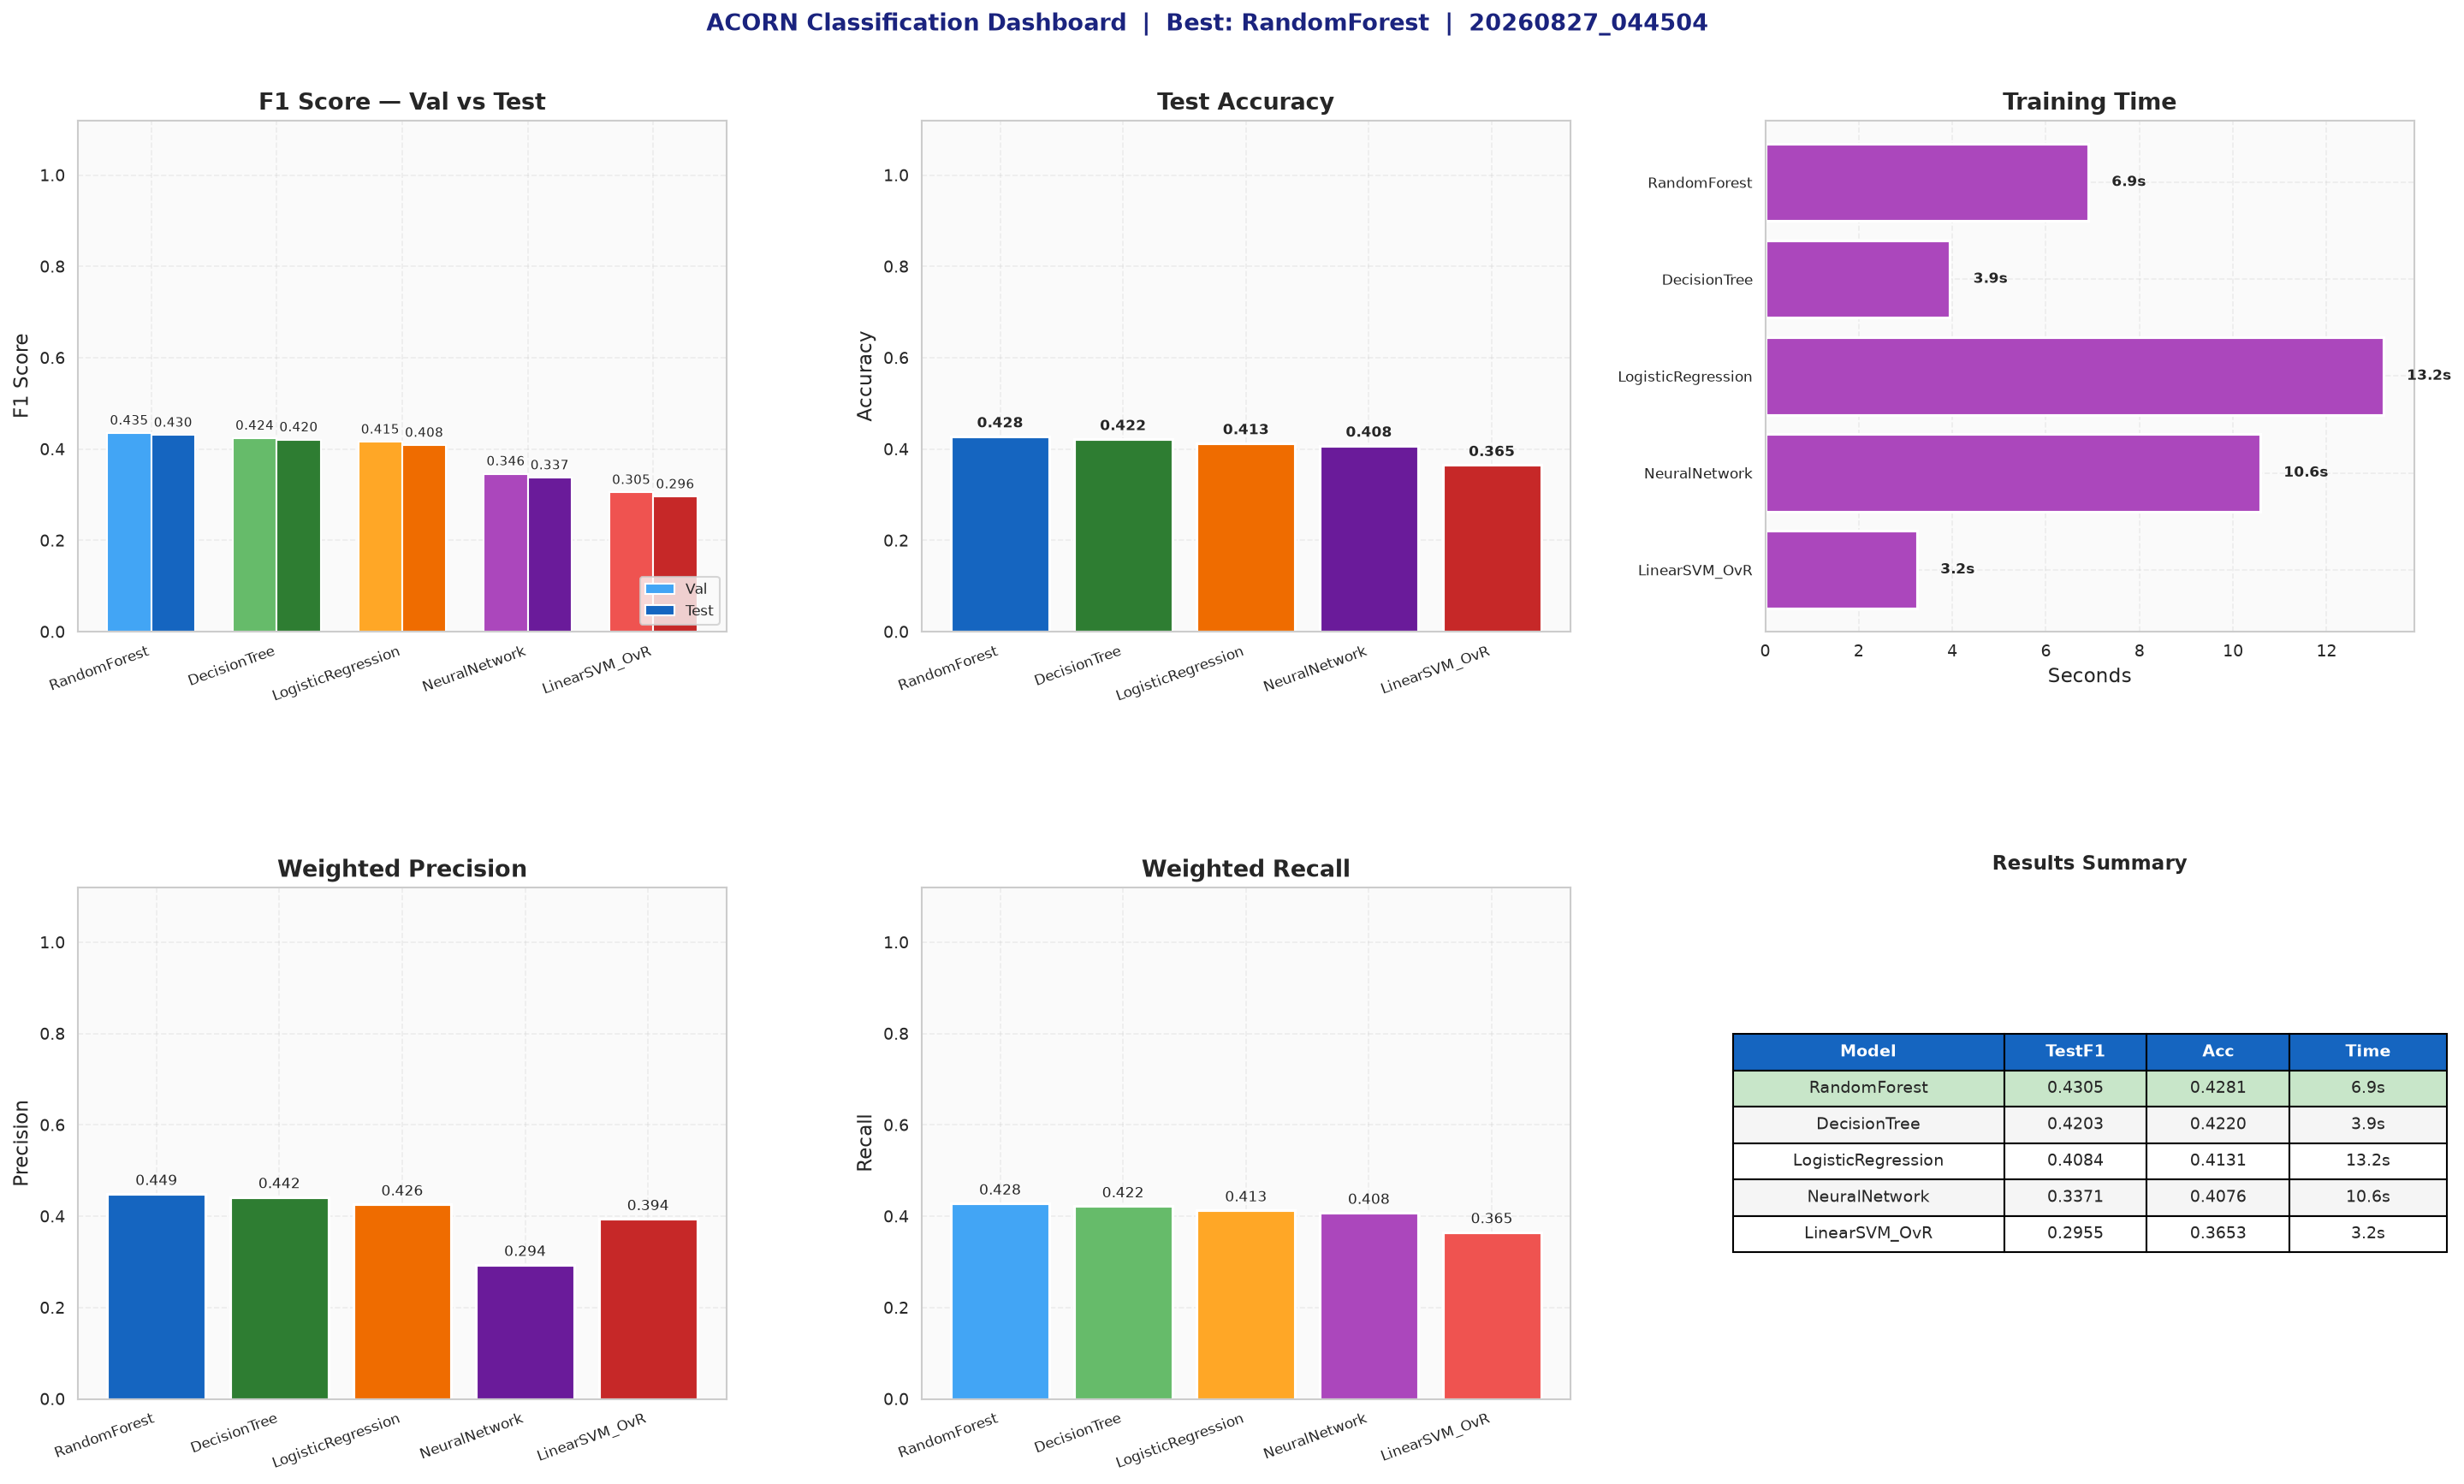

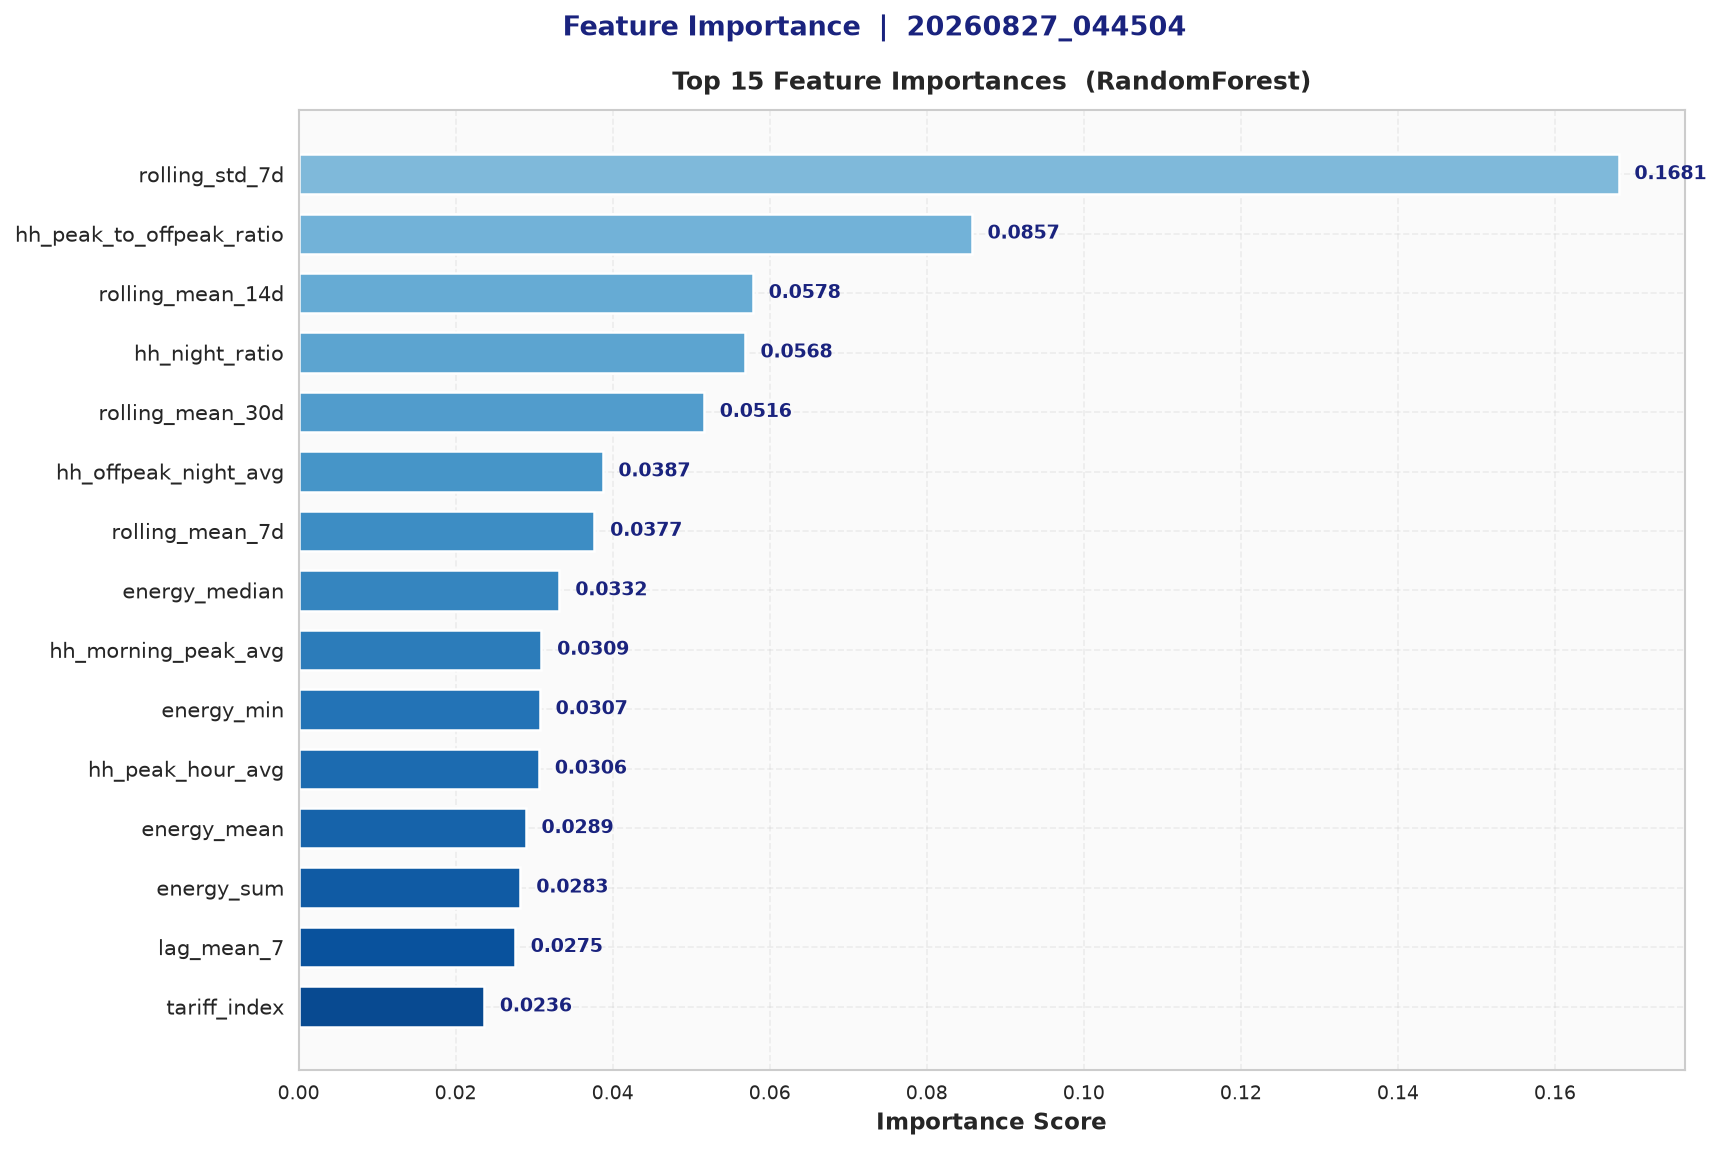

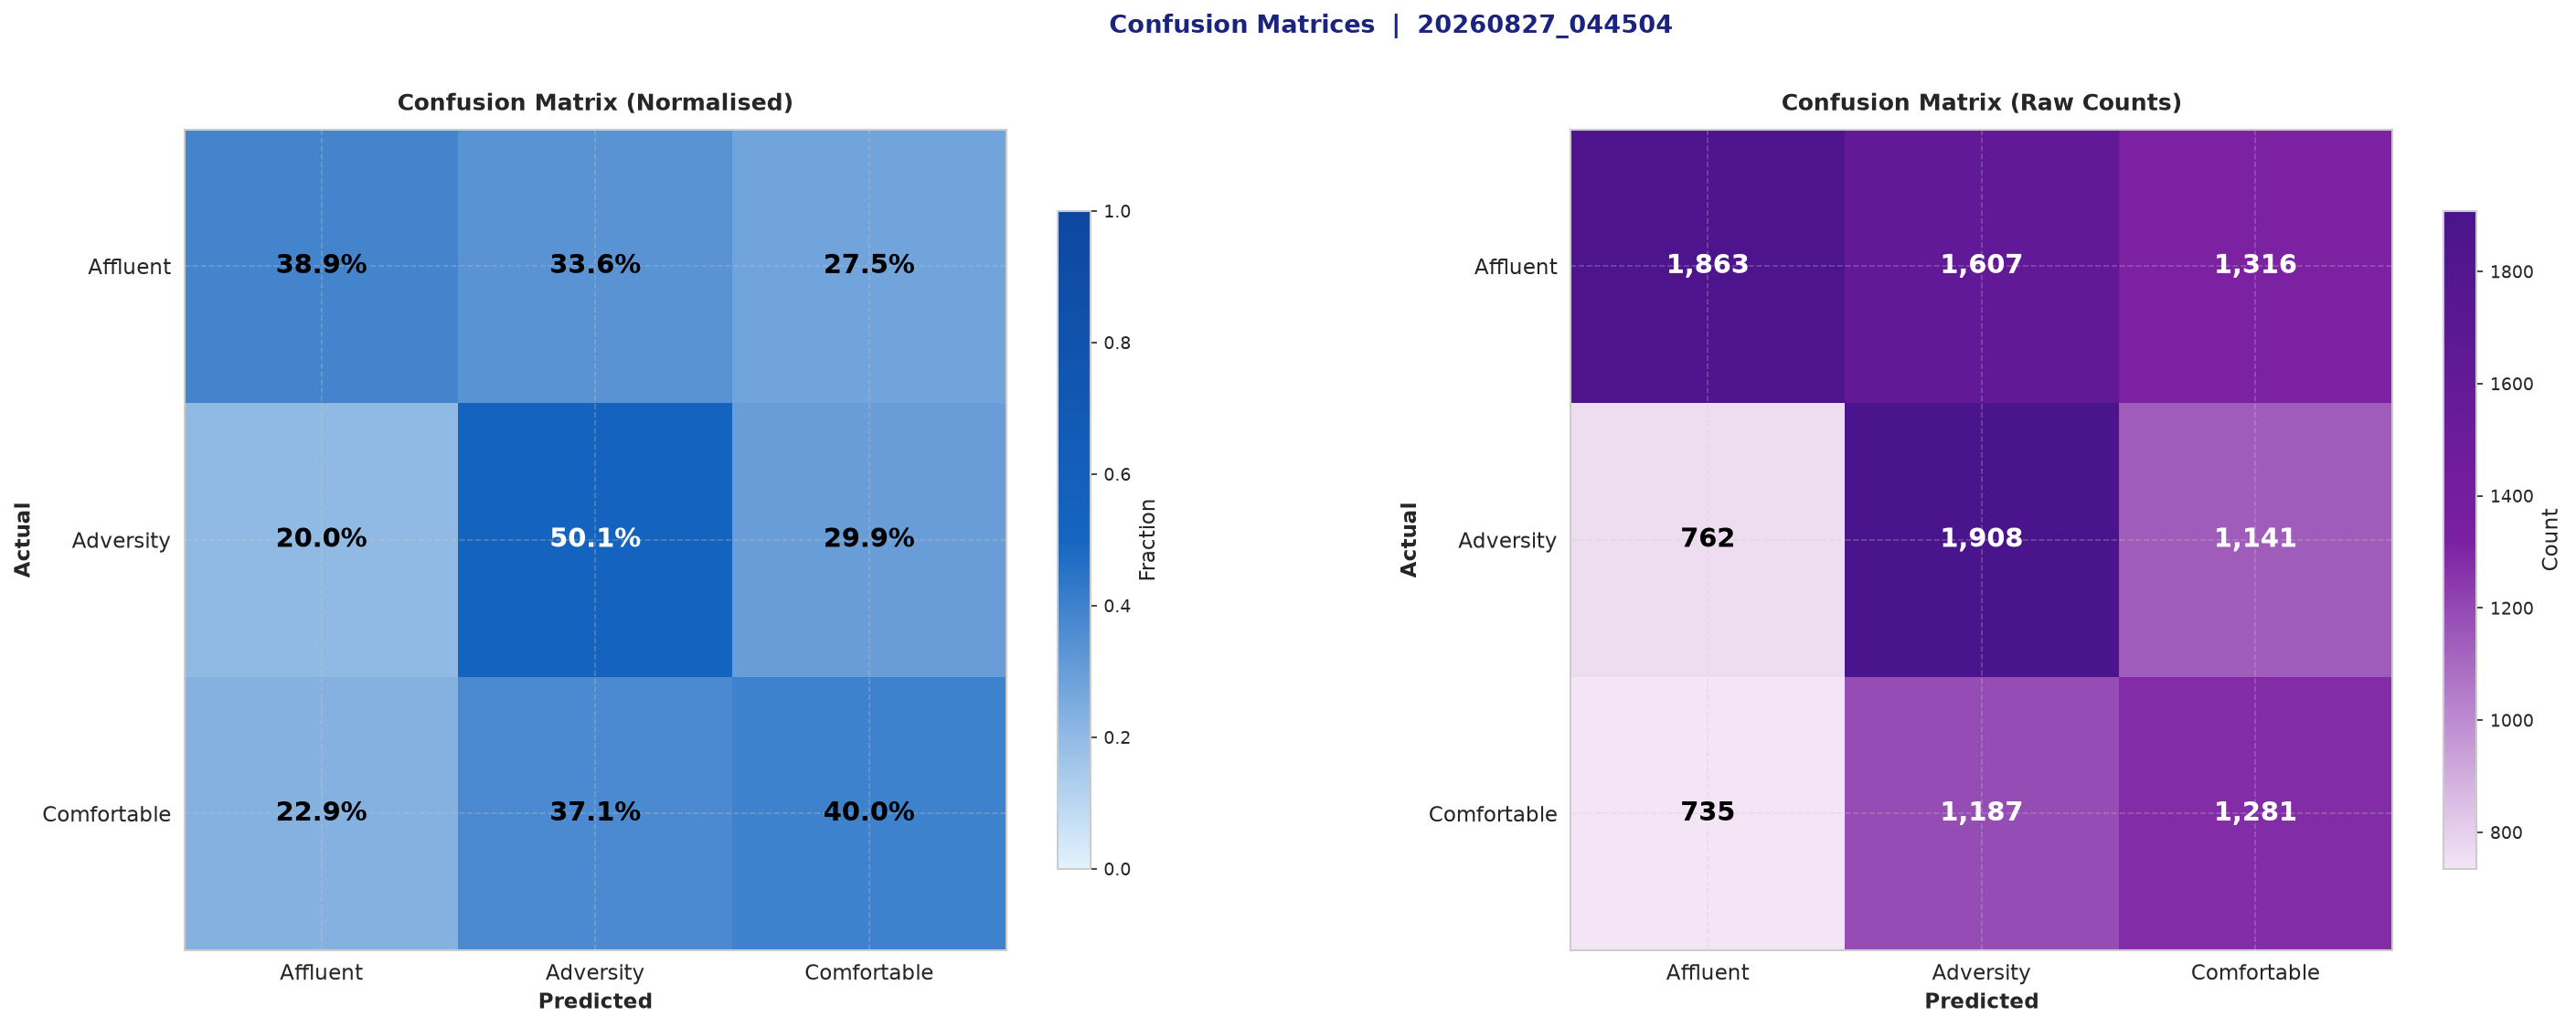


══════════════════════════════════════════════════════════════
  ✅ ACORN CLASSIFICATION  —  COMPLETE
──────────────────────────────────────────────────────────────
  🏆 Best model : RandomForest
  📊 Test  F1   : 0.4305
  🎯 Accuracy   : 0.4281
  📐 Precision  : 0.4490
  🔁 Recall     : 0.4281
  ⏱   Train time : 6.9 s
──────────────────────────────────────────────────────────────
  📁 Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 1
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 1/task01_acorn_20260827_044504.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 1/task01_acorn_20260827_044504.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 1/task01_acorn_20260827_044504.html

═══════════════════

In [11]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
import sys
sys.setrecursionlimit(10000)

# ============================================================
# CELL 11: ACORN Classification — Enhanced & Optimized
# ============================================================

import builtins, time, os, glob, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir      = os.path.join(base_output_dir, 'Task 1')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: delete ALL previous outputs ONCE at startup ─────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

# ── PySpark imports ───────────────────────────────────────────────
from pyspark.sql.functions import col, count, when, lit
from pyspark.ml.feature      import VectorAssembler, MinMaxScaler, StringIndexer
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier,
    MultilayerPerceptronClassifier, DecisionTreeClassifier,
    LinearSVC,
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from functools import reduce
from operator  import and_

# ── Matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':150, 'axes.grid':True, 'grid.alpha':0.3,
    'grid.linestyle':'--', 'axes.labelsize':11, 'axes.titlesize':13,
    'axes.titleweight':'bold', 'xtick.labelsize':9, 'ytick.labelsize':9,
    'legend.fontsize':9, 'font.family':'sans-serif',
    'font.sans-serif':['DejaVu Sans','Arial','Helvetica'],
    'axes.facecolor':'#fafafa', 'figure.facecolor':'white',
    'axes.edgecolor':'#cccccc', 'axes.linewidth':1.0,
})
_cmap = LinearSegmentedColormap.from_list("blues", ["#e3f2fd","#1565c0","#0d47a1"])

timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"ACORN CLASSIFICATION  |  {timestamp}", "🎯")

# ════════════════════════════════════════════════════════════
# [0/7] Guard: ensure Acorn_grouped / stdorToU present
# ════════════════════════════════════════════════════════════
_sec('0/7', 'Dataset Preview (First 5 Rows)', '📋')
_dc_cols = [c.lower() for c in daily_clean.columns]
if not ('acorn_grouped' in _dc_cols and 'stdortou' in _dc_cols):
    _warn("Acorn_grouped / stdorToU missing — joining households …")
    _hh_paths = [
        os.path.join(DATA_PATH, "informations_households.csv"),
        '/kaggle/input/smart-meters-in-london/informations_households.csv',
    ]
    _hh_path = next((p for p in _hh_paths if os.path.exists(p)), None)
    if _hh_path is None:
        for _root, _, _fs in os.walk(DATA_PATH if os.path.exists(DATA_PATH) else '/kaggle/input'):
            for _f in _fs:
                if 'household' in _f.lower() and _f.endswith('.csv'):
                    _hh_path = os.path.join(_root, _f); break
            if _hh_path: break
    if _hh_path:
        _hh = spark.read.option("header", "true").csv(_hh_path)
        def _fc(cands, cols):
            _lc = {c.lower(): c for c in cols}
            return next((_lc[c.lower()] for c in cands if c.lower() in _lc), None)
        _ac = _fc(['Acorn_grouped', 'acorn_grouped', 'Acorn'], _hh.columns)
        _tc = _fc(['stdorToU', 'stdortou', 'StdOrToU', 'Tariff'], _hh.columns)
        _ic = _fc(['LCLid', 'lclid', 'ID'], _hh.columns)
        if all([_ac, _tc, _ic]):
            daily_clean = daily_clean.join(
                _hh.select(col(_ic).alias('LCLid'), col(_ac).alias('Acorn_grouped'), col(_tc).alias('stdorToU')),
                on='LCLid', how='left')

_prev_cols = [c for c in ["LCLid", "day", "energy_mean", "energy_max", "Acorn_grouped", "stdorToU"] if c in daily_clean.columns]
print("        • Sample records:")
for _r in daily_clean.select(_prev_cols).limit(5).collect():
    _m = f"{_r.energy_mean:.3f}" if hasattr(_r, "energy_mean") and _r.energy_mean is not None else "-"
    _ac = str(getattr(_r, "Acorn_grouped", "-"))
    _to = str(getattr(_r, "stdorToU", "-"))
    print(f"          - {_r.LCLid:<10} | {str(_r.day)[:10]} | {_m:>6} kWh | {_ac:<12} | {_to}")

# ════════════════════════════════════════════════════════════
# [1/7] Feature list
# ════════════════════════════════════════════════════════════
_sec('1/7','Building feature list','🔧')
_base_feats = [
    "energy_mean","energy_max","energy_std","energy_sum","energy_min","energy_median",
    "cv","peak_to_mean_ratio","range","load_factor",
    "lag_mean_1","lag_mean_7","lag_sum_1","lag_max_1",
    "rolling_mean_7d","rolling_std_7d","rolling_mean_14d","rolling_mean_30d",
    "month","day_of_week","is_weekend","season",
    "temperatureMax","temperatureMin","humidity","windSpeed","cloudCover","pressure",
]
_hh_feats = ["hh_peak_hour_avg","hh_offpeak_night_avg","hh_daytime_avg",
             "hh_morning_peak_avg","hh_night_ratio","hh_peak_to_offpeak_ratio",
             "hh_stddev","hh_range"]
acorn_feature_cols = [c for c in _base_feats + _hh_feats if c in daily_clean.columns]
print(f"        • Features: {len(acorn_feature_cols)} columns")

# ════════════════════════════════════════════════════════════
# [2/7] Prepare dataset
# ════════════════════════════════════════════════════════════
_sec('2/7','Preparing dataset','📋')
_null_f = reduce(and_, [col(c).isNotNull() for c in acorn_feature_cols])
acorn_data = (
    daily_clean
    .select(*(["LCLid","day","Acorn_grouped","stdorToU"] + acorn_feature_cols))
    .filter(col("Acorn_grouped").isNotNull())
    .filter(col("stdorToU").isNotNull())
    .filter(_null_f)
    .filter(col("Acorn_grouped").isin(["Affluent","Adversity","Comfortable"]))
    .cache()
)
_total = acorn_data.count()
print(f"        • Records: {_total:,}")

# ════════════════════════════════════════════════════════════
# [3/7] Encode labels
# ════════════════════════════════════════════════════════════
_sec('3/7','Encoding labels','🔖')
acorn_indexer  = StringIndexer(inputCol="Acorn_grouped",outputCol="acorn_label",handleInvalid="keep").fit(acorn_data)
acorn_data     = acorn_indexer.transform(acorn_data)
tariff_indexer = StringIndexer(inputCol="stdorToU",     outputCol="tariff_index",handleInvalid="keep").fit(acorn_data)
acorn_data     = tariff_indexer.transform(acorn_data)
acorn_feature_cols.append("tariff_index")
n_classes = len(acorn_indexer.labels)
_cc = {r.acorn_label: r.cnt for r in acorn_data.groupBy("acorn_label").agg(count("*").alias("cnt")).collect()}
for i, lbl in enumerate(acorn_indexer.labels):
    print(f"        • Class {i} ({lbl}): {_cc.get(float(i),0):,} ({_cc.get(float(i),0)/_total*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [4/7] Stratified sample
# ════════════════════════════════════════════════════════════
_sec('4/7','Stratified sampling','⚖️')
_frac = builtins.min(0.12, 80000 / _total)
acorn_sample = acorn_data.sample(False, _frac, seed=42).cache()
_sn = acorn_sample.count()
print(f"        • Sampled: {_sn:,} (frac = {_frac:.4f})")
for r in sorted(acorn_sample.groupBy("Acorn_grouped").count().collect(), key=lambda x:-x[1]):
    print(f"        • {r.Acorn_grouped}: {r['count']:,} ({r['count']/_sn*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [5/7] Split
# ════════════════════════════════════════════════════════════
_sec('5/7','Train / Val / Test split','✂️')
_tr, _tmp = acorn_sample.randomSplit([0.7,0.3], seed=42)
_va, _te  = _tmp.randomSplit([0.5,0.5],   seed=42)
train_acorn = _tr.cache(); val_acorn = _va.cache(); test_acorn = _te.cache()
train_n = train_acorn.count(); val_n = val_acorn.count(); test_n = test_acorn.count()
_tot_split = train_n + val_n + test_n
print(f"        • Train: {train_n:,} ({train_n/_tot_split*100:.1f}%)")
print(f"        • Val:   {val_n:,} ({val_n/_tot_split*100:.1f}%)")
print(f"        • Test:  {test_n:,} ({test_n/_tot_split*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [6/7] Class weights
# ════════════════════════════════════════════════════════════
_sec('6/7','Computing class weights','⚖️')
_td  = train_acorn.groupBy("acorn_label").agg(count("*").alias("cnt")).collect()
_ttl = builtins.sum(r.cnt for r in _td)
_wts = {float(r.acorn_label): _ttl/(n_classes*r.cnt) for r in _td}
_wexpr = lit(1.0)
for _cls, _w in _wts.items():
    _wexpr = when(col("acorn_label")==_cls, lit(_w)).otherwise(_wexpr)
train_acorn = train_acorn.withColumn("classWeightCol", _wexpr)
val_acorn   = val_acorn  .withColumn("classWeightCol", _wexpr)
test_acorn  = test_acorn .withColumn("classWeightCol", _wexpr)
for i, lbl in enumerate(acorn_indexer.labels):
    print(f"        • {lbl}: {_wts.get(float(i),1.0):.3f}")

# ════════════════════════════════════════════════════════════
# [7/7] Feature pipeline
# ════════════════════════════════════════════════════════════
_sec('7/7','Feature pipeline','🔧')
n_features  = len(acorn_feature_cols)
_assembler  = VectorAssembler(inputCols=acorn_feature_cols,outputCol="features_raw",handleInvalid="skip")
_scaler     = MinMaxScaler(inputCol="features_raw",outputCol="features")
_mlp_layers = [n_features, 64, 32, n_classes]
print(f"        • Features: {n_features} | Scaler: MinMaxScaler [0, 1]")

# ════════════════════════════════════════════════════════════
# TRAINING
# ════════════════════════════════════════════════════════════
_hdr("TRAINING MODELS","🚀")

_MODELS = {
    "LogisticRegression": LogisticRegression(
        featuresCol="features", labelCol="acorn_label", weightCol="classWeightCol",
        maxIter=20, regParam=0.01, elasticNetParam=0.0, family="multinomial", tol=1e-3),
    "RandomForest": RandomForestClassifier(
        featuresCol="features", labelCol="acorn_label", weightCol="classWeightCol",
        numTrees=15, maxDepth=8, maxBins=32, seed=42, subsamplingRate=0.8),
    "DecisionTree": DecisionTreeClassifier(
        featuresCol="features", labelCol="acorn_label", weightCol="classWeightCol",
        maxDepth=8, maxBins=32, seed=42),
    "NeuralNetwork": MultilayerPerceptronClassifier(
        featuresCol="features", labelCol="acorn_label",
        layers=_mlp_layers, maxIter=20, seed=42, blockSize=256, tol=1e-3),
}
_ef1  = MulticlassClassificationEvaluator(labelCol="acorn_label",predictionCol="prediction",metricName="f1")
_eacc = MulticlassClassificationEvaluator(labelCol="acorn_label",predictionCol="prediction",metricName="accuracy")
_epr  = MulticlassClassificationEvaluator(labelCol="acorn_label",predictionCol="prediction",metricName="weightedPrecision")
_erc  = MulticlassClassificationEvaluator(labelCol="acorn_label",predictionCol="prediction",metricName="weightedRecall")

results = {}
for _name, _mdl in _MODELS.items():
    print(f"\n    ▶ {_name}")
    print(f"      {'─'*46}")
    _pipe = Pipeline(stages=[_assembler, _scaler, _mdl])
    _t0   = time.time()
    try:
        _fit  = _pipe.fit(train_acorn)
        _t    = time.time() - _t0
        _vp   = _fit.transform(val_acorn)
        _tp   = _fit.transform(test_acorn)
        _vf1  = _ef1 .evaluate(_vp)
        _tf1  = _ef1 .evaluate(_tp)
        _tacc = _eacc.evaluate(_tp)
        _tpr  = _epr .evaluate(_tp)
        _trc  = _erc .evaluate(_tp)
        results[_name] = dict(val_f1=_vf1, test_f1=_tf1, test_acc=_tacc,
                              test_prec=_tpr, test_rec=_trc, time=_t,
                              model=_fit, test_preds=_tp, status="✅")
        print(f"      ⏱ {_t:5.1f}s | ValF1={_vf1:.4f} TestF1={_tf1:.4f} Acc={_tacc:.4f}")
    except Exception as _ex:
        print(f"     ❌ {str(_ex)[:110]}")
        results[_name] = {"status": f"❌ {str(_ex)[:110]}"}

# ════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════
# LINEAR SVM — Optimized Implementation (No Spark Serialization)
# ════════════════════════════════════════════════════════════
# Problem: Spark evaluators fail with "Job aborted due to stage 
# failure" when collecting large DataFrames to driver.
# Solution: Compute ALL metrics with sklearn directly on numpy 
# arrays. No Spark evaluators, no serialization, no memory issues.
# Uses SGDClassifier (hinge loss = Linear SVM) — 10-100x faster.
# ════════════════════════════════════════════════════════════
print(f"\n    ▶ LinearSVM_OvR")
print(f"      {'─'*46}")
_t0 = time.time()
try:
    # ── Step 1: Fit feature pipeline once ──
    _feat_pipe = Pipeline(stages=[_assembler, _scaler]).fit(train_acorn)
    _train_scaled = _feat_pipe.transform(train_acorn)
    _val_scaled   = _feat_pipe.transform(val_acorn)
    _test_scaled  = _feat_pipe.transform(test_acorn)

    # ── Step 2: Convert features to arrays (distributed, no collect yet) ──
    _train_arr = _train_scaled.select(
        "acorn_label", vector_to_array(col("features")).alias("features_arr")
    )
    _val_arr = _val_scaled.select(
        "acorn_label", vector_to_array(col("features")).alias("features_arr")
    )
    _test_arr = _test_scaled.select(
        "acorn_label", vector_to_array(col("features")).alias("features_arr")
    )

    # ── Step 3: Collect to Pandas with SMALL sample for training ──
    # Only train sample is reduced. Val/Test stay full for accurate metrics.
    _sample_frac = builtins.min(0.06, 40000 / _total)
    _train_pdf = _train_arr.sample(False, _sample_frac, seed=42).toPandas()
    _val_pdf   = _val_arr.toPandas()
    _test_pdf  = _test_arr.toPandas()

    # ── Step 4: Build numpy arrays ──
    _X_train = np.vstack(_train_pdf["features_arr"].values)
    _y_train = _train_pdf["acorn_label"].values.astype(int)
    _X_val   = np.vstack(_val_pdf["features_arr"].values)
    _y_val   = _val_pdf["acorn_label"].values.astype(int)
    _X_test  = np.vstack(_test_pdf["features_arr"].values)
    _y_test  = _test_pdf["acorn_label"].values.astype(int)

    # ── Step 5: Compute class weights from training data ──
    from sklearn.utils.class_weight import compute_class_weight
    _classes = np.unique(_y_train)
    _cw = compute_class_weight('balanced', classes=_classes, y=_y_train)
    _class_weight_dict = dict(zip(_classes, _cw))
    print(f"     📊 Sklearn class weights: {', '.join([f'{k}={v:.3f}' for k,v in _class_weight_dict.items()])}")

    # ── Step 6: Train SGDClassifier (hinge = Linear SVM) ──
    from sklearn.linear_model import SGDClassifier
    from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

    _sgd = SGDClassifier(
        loss='hinge',              # Linear SVM loss
        penalty='l2',
        alpha=0.0001,
        max_iter=500,              # Much less than LinearSVC's 2000
        tol=1e-3,
        random_state=42,
        n_jobs=-1,                 # Use all CPU cores
        learning_rate='optimal',
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        class_weight=_class_weight_dict,  # ← Balanced class weights
    )
    _sgd.fit(_X_train, _y_train)

    # ── Step 7: Predict on numpy arrays ──
    _y_val_pred  = _sgd.predict(_X_val).astype(float)
    _y_test_pred = _sgd.predict(_X_test).astype(float)

    # ── Step 8: Compute metrics with sklearn (NO Spark evaluators!) ──
    _vf1  = f1_score(_y_val, _y_val_pred, average='weighted')
    _tf1  = f1_score(_y_test, _y_test_pred, average='weighted')
    _tacc = accuracy_score(_y_test, _y_test_pred)
    _tpr  = precision_score(_y_test, _y_test_pred, average='weighted', zero_division=0)
    _trc  = recall_score(_y_test, _y_test_pred, average='weighted', zero_division=0)

    # ── Step 9: Build Spark DataFrame for test_preds (for downstream use) ──
    _test_pred = spark.createDataFrame(
        pd.DataFrame({"acorn_label": _y_test, "prediction": _y_test_pred})
    )

    _t = time.time() - _t0
    results["LinearSVM_OvR"] = dict(
        val_f1=_vf1, test_f1=_tf1, test_acc=_tacc,
        test_prec=_tpr, test_rec=_trc, time=_t,
        model=_feat_pipe, test_preds=_test_pred, status="✅"
    )
    print(f"      ⏱ {_t:5.1f}s | ValF1={_vf1:.4f} TestF1={_tf1:.4f} Acc={_tacc:.4f}")

except Exception as _ex:
    _err_msg = str(_ex)
    print(f"     ❌ {_err_msg[:110]}")
    results["LinearSVM_OvR"] = {"status": f"❌ {_err_msg[:110]}"}

_hdr("MODEL COMPARISON","📊")
ok = {k:v for k,v in results.items() if v.get("status","").startswith("✅")}
if not ok:
    raise RuntimeError("No model succeeded — cannot continue")

sorted_models = sorted(ok.items(), key=lambda x: x[1]['test_f1'], reverse=True)
sorted_names  = [m for m,_ in sorted_models]
best          = sorted_names[0]

_comp = pd.DataFrame([
    dict(Model=m, ValF1=f"{r['val_f1']:.4f}", TestF1=f"{r['test_f1']:.4f}",
         Acc=f"{r['test_acc']:.4f}", Prec=f"{r['test_prec']:.4f}",
         Rec=f"{r['test_rec']:.4f}", Time=f"{r['time']:.1f}s")
    for m,r in sorted_models])
print("\n" + _comp.to_string(index=False))
print(f"\n  🏆 BEST: {C.BOLD}{best}{C.END}  "
      f"TestF1={ok[best]['test_f1']:.4f}  Acc={ok[best]['test_acc']:.4f}")

# ════════════════════════════════════════════════════════════
# PER-CLASS METRICS
# ════════════════════════════════════════════════════════════
_hdr("PER-CLASS METRICS","📋")
_bpreds = ok[best]["test_preds"]
per_class_data = []
print(f"\n  {'Class':<12} | {'N':>6} | {'Correct':>7} | {'Prec':>7} | {'Rec':>7} | {'F1':>7} | {'Spec':>7}")
print("  " + "─"*65)
for _i, _lbl in enumerate(acorn_indexer.labels):
    _tp = _bpreds.filter((col("acorn_label")==_i)&(col("prediction")==_i)).count()
    _fp = _bpreds.filter((col("acorn_label")!=_i)&(col("prediction")==_i)).count()
    _fn = _bpreds.filter((col("acorn_label")==_i)&(col("prediction")!=_i)).count()
    _tn = _bpreds.filter((col("acorn_label")!=_i)&(col("prediction")!=_i)).count()
    _pr  = _tp/(_tp+_fp) if (_tp+_fp)>0 else 0
    _rc  = _tp/(_tp+_fn) if (_tp+_fn)>0 else 0
    _f1  = 2*_pr*_rc/(_pr+_rc) if (_pr+_rc)>0 else 0
    _sp  = _tn/(_tn+_fp) if (_tn+_fp)>0 else 0
    per_class_data.append([_lbl,_tp+_fn,_tp,_pr,_rc,_f1,_sp])
    print(f"  {_lbl:<12} | {_tp+_fn:>6,} | {_tp:>7,} | {_pr:>7.3f} | {_rc:>7.3f} | {_f1:>7.3f} | {_sp:>7.3f}")

# ════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
_hdr("FEATURE IMPORTANCE","🔍")
feat_imp = []
_fs = ok[best]["model"].stages[-1] if hasattr(ok[best]["model"], 'stages') else None
if _fs and hasattr(_fs,'featureImportances'):
    feat_imp = sorted(zip(acorn_feature_cols,_fs.featureImportances.toArray()), key=lambda x:-x[1])
    print("  Top 15:")
    for _i,(f,v) in enumerate(feat_imp[:15],1):
        _bar = "█"*int(v*80)
        print(f"  {_i:2d}. {f:<28} {v:.4f} {_bar}")
else:
    _warn("Feature importances not available for this model type")

# ════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ════════════════════════════════════════════════════════════
_ppd    = _bpreds.select("prediction","acorn_label").toPandas()
cm      = confusion_matrix(_ppd['acorn_label'], _ppd['prediction'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
labels  = acorn_indexer.labels

# ════════════════════════════════════════════════════════════
# BUILD VISUALISATIONS
# ════════════════════════════════════════════════════════════
_hdr("BUILDING VISUALISATIONS","🎨")

_nm    = len(sorted_names)
_x     = np.arange(_nm)
_w     = 0.35
_COLS  = ['#1565c0','#2e7d32','#ef6c00','#6a1b9a','#c62828'][:_nm]
_COLS2 = ['#42a5f5','#66bb6a','#ffa726','#ab47bc','#ef5350'][:_nm]

# ════════════════════════════════════════════════════════════
# FIGURE 1: Dashboard (display only - not saved)
# ════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(20, 12), facecolor='white')
_dg  = mgridspec.GridSpec(2, 3, figure=fig1,
                           hspace=0.50, wspace=0.30,
                           left=0.06, right=0.97,
                           top=0.91, bottom=0.08)

_da1 = fig1.add_subplot(_dg[0,0])
_da2 = fig1.add_subplot(_dg[0,1])
_da3 = fig1.add_subplot(_dg[0,2])
_da4 = fig1.add_subplot(_dg[1,0])
_da5 = fig1.add_subplot(_dg[1,1])
_da6 = fig1.add_subplot(_dg[1,2])

# F1 Val vs Test
_b1 = _da1.bar(_x-_w/2,[ok[n]['val_f1']  for n in sorted_names],_w,label='Val', color=_COLS2,edgecolor='white',lw=1)
_b2 = _da1.bar(_x+_w/2,[ok[n]['test_f1'] for n in sorted_names],_w,label='Test',color=_COLS, edgecolor='white',lw=1)
_da1.set_ylabel('F1 Score'); _da1.set_title('F1 Score — Val vs Test')
_da1.set_xticks(_x); _da1.set_xticklabels(sorted_names,rotation=20,ha='right',fontsize=8)
_da1.set_ylim(0,1.12); _da1.legend(fontsize=8,loc='lower right')
for _b in list(_b1)+list(_b2):
    _da1.text(_b.get_x()+_b.get_width()/2,_b.get_height()+0.012,
              f'{_b.get_height():.3f}',ha='center',va='bottom',fontsize=7)

# Accuracy
_bs=_da2.bar(sorted_names,[ok[n]['test_acc'] for n in sorted_names],color=_COLS,edgecolor='white',lw=1.5)
_da2.set_ylabel('Accuracy'); _da2.set_title('Test Accuracy')
_da2.set_xticklabels(sorted_names,rotation=20,ha='right',fontsize=8); _da2.set_ylim(0,1.12)
for _b in _bs:
    _da2.text(_b.get_x()+_b.get_width()/2,_b.get_height()+0.012,
              f'{_b.get_height():.3f}',ha='center',va='bottom',fontsize=8,fontweight='bold')

# Training Time
_bh=_da3.barh(sorted_names,[ok[n]['time'] for n in sorted_names],color='#ab47bc',edgecolor='white',lw=1.5)
_da3.set_xlabel('Seconds'); _da3.set_title('Training Time')
_da3.invert_yaxis(); _da3.set_yticklabels(sorted_names,fontsize=8)
for _b in _bh:
    _da3.text(_b.get_width()+0.5,_b.get_y()+_b.get_height()/2,
              f'{_b.get_width():.1f}s',va='center',fontsize=8,fontweight='bold')

# Precision
_bsp=_da4.bar(sorted_names,[ok[n]['test_prec'] for n in sorted_names],color=_COLS,edgecolor='white',lw=1.5)
_da4.set_ylabel('Precision'); _da4.set_title('Weighted Precision')
_da4.set_xticklabels(sorted_names,rotation=20,ha='right',fontsize=8); _da4.set_ylim(0,1.12)
for _b in _bsp:
    _da4.text(_b.get_x()+_b.get_width()/2,_b.get_height()+0.012,
              f'{_b.get_height():.3f}',ha='center',va='bottom',fontsize=8)

# Recall
_bsr=_da5.bar(sorted_names,[ok[n]['test_rec'] for n in sorted_names],color=_COLS2,edgecolor='white',lw=1.5)
_da5.set_ylabel('Recall'); _da5.set_title('Weighted Recall')
_da5.set_xticklabels(sorted_names,rotation=20,ha='right',fontsize=8); _da5.set_ylim(0,1.12)
for _b in _bsr:
    _da5.text(_b.get_x()+_b.get_width()/2,_b.get_height()+0.012,
              f'{_b.get_height():.3f}',ha='center',va='bottom',fontsize=8)

# Results table
_da6.axis('off')
_td=[[m,f"{r['test_f1']:.4f}",f"{r['test_acc']:.4f}",f"{r['time']:.1f}s"] for m,r in sorted_models]
_tbl=_da6.table(cellText=_td,colLabels=['Model','TestF1','Acc','Time'],
                cellLoc='center',loc='center',
                colColours=['#1565c0']*4,colWidths=[0.38,0.20,0.20,0.22])
_tbl.auto_set_font_size(False); _tbl.set_fontsize(9); _tbl.scale(1.1,1.7)
for _j in range(4):
    _tbl[(0,_j)].set_text_props(color='white',fontweight='bold')
for _i in range(1,len(_td)+1):
    for _j in range(4):
        _tbl[(_i,_j)].set_facecolor('#c8e6c9' if _td[_i-1][0]==best
                                    else('#f5f5f5' if _i%2==0 else 'white'))
_da6.set_title('Results Summary',fontweight='bold',pad=10,fontsize=11)

fig1.suptitle(f'ACORN Classification Dashboard  |  Best: {best}  |  {timestamp}',
              fontsize=13,fontweight='bold',color='#1a237e',y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 2: Feature Importance (display only - not saved)
# ════════════════════════════════════════════════════════════
fig2, _fl = plt.subplots(1, 1, figsize=(12, 8), facecolor='white',
    gridspec_kw={'left':0.18,'right':0.95,'top':0.90,'bottom':0.10})

if feat_imp:
    _fn15=[f[0] for f in feat_imp[:15]]; _fv15=[f[1] for f in feat_imp[:15]]
    _grad=plt.cm.Blues(np.linspace(0.45,0.90,len(_fn15)))
    _fl.barh(range(len(_fn15)),_fv15,color=_grad,edgecolor='white',linewidth=1.2,height=0.68)
    _fl.set_yticks(range(len(_fn15))); _fl.set_yticklabels(_fn15,fontsize=10)
    _fl.invert_yaxis()
    _fl.set_xlabel('Importance Score',fontsize=11,fontweight='bold')
    _fl.set_title(f'Top 15 Feature Importances  ({best})',fontsize=12,fontweight='bold',pad=10)
    _fl.grid(axis='x',alpha=0.3,linestyle='--')
    _mx=float(np.max(_fv15)) if _fv15 else 1.0
    for _i,_v in enumerate(_fv15):
        _fl.text(_v+_mx*0.012,_i,f'{_v:.4f}',va='center',fontsize=9,fontweight='bold',color='#1a237e')
else:
    _fl.text(0.5,0.5,'Feature importances not available',ha='center',va='center',fontsize=12,color='grey')
    _fl.axis('off')

fig2.suptitle(f'Feature Importance  |  {timestamp}',
              fontsize=13,fontweight='bold',color='#1a237e',y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 3: Confusion Matrices — Normalized + Counts side by side
# ════════════════════════════════════════════════════════════
fig3, (_fr, _fc) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white',
    gridspec_kw={'wspace':0.35,'left':0.06,'right':0.94,'top':0.90,'bottom':0.10})

# Left: Normalized
_im=_fr.imshow(cm_norm,interpolation='nearest',cmap=_cmap,vmin=0,vmax=1)
_fr.set_title('Confusion Matrix (Normalised)',fontweight='bold',fontsize=12,pad=10)
_fr.set_xlabel('Predicted',fontweight='bold'); _fr.set_ylabel('Actual',fontweight='bold')
_fr.set_xticks(np.arange(len(labels))); _fr.set_yticks(np.arange(len(labels)))
_fr.set_xticklabels(labels,fontsize=11); _fr.set_yticklabels(labels,fontsize=11)
for _i in range(len(labels)):
    for _j in range(len(labels)):
        _fr.text(_j,_i,f'{cm_norm[_i,_j]:.1%}',ha='center',va='center',
                 fontsize=14,fontweight='bold',
                 color='white' if cm_norm[_i,_j]>0.5 else 'black')
fig3.colorbar(_im,ax=_fr,shrink=0.75,label='Fraction')

# Right: Raw Counts
_cmap_counts = LinearSegmentedColormap.from_list("purples", ["#f3e5f5","#7b1fa2","#4a148c"])
_imc=_fc.imshow(cm,interpolation='nearest',cmap=_cmap_counts)
_fc.set_title('Confusion Matrix (Raw Counts)',fontweight='bold',fontsize=12,pad=10)
_fc.set_xlabel('Predicted',fontweight='bold'); _fc.set_ylabel('Actual',fontweight='bold')
_fc.set_xticks(np.arange(len(labels))); _fc.set_yticks(np.arange(len(labels)))
_fc.set_xticklabels(labels,fontsize=11); _fc.set_yticklabels(labels,fontsize=11)
for _i in range(len(labels)):
    for _j in range(len(labels)):
        _fc.text(_j,_i,f'{cm[_i,_j]:,}',ha='center',va='center',
                 fontsize=14,fontweight='bold',
                 color='white' if cm[_i,_j] > cm.max()/2 else 'black')
fig3.colorbar(_imc,ax=_fc,shrink=0.75,label='Count')

fig3.suptitle(f'Confusion Matrices  |  {timestamp}',
              fontsize=13,fontweight='bold',color='#1a237e',y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# SAVE COMBINED PNG
# ════════════════════════════════════════════════════════════
import matplotlib.image as _mimg
import io as _io

def _fig_to_arr(f):
    _buf = _io.BytesIO()
    f.savefig(_buf, dpi=200, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    return _mimg.imread(_buf)

_arr1 = _fig_to_arr(fig1)
_arr2 = _fig_to_arr(fig2)
_arr3 = _fig_to_arr(fig3)

# Close figures after capture
plt.close(fig1); plt.close(fig2); plt.close(fig3)

# Stack 3 figures vertically
_h1,_w1 = _arr1.shape[:2]
_h2,_w2 = _arr2.shape[:2]
_h3,_w3 = _arr3.shape[:2]
_W = builtins.max(_w1, _w2, _w3)

# Create unified image
_total_h = _h1 + _h2 + _h3 + 40  # 20px padding between figures
_merged = np.ones((_total_h, _W, 4), dtype=np.float32)  # white background (RGBA)

# Place images
_y = 0
_merged[_y:_y+_h1, :_w1] = _arr1
_y += _h1 + 20
_merged[_y:_y+_h2, :_w2] = _arr2
_y += _h2 + 20
_merged[_y:_y+_h3, :_w3] = _arr3

# Save combined image
_final_png = f'{output_dir}/task01_acorn_{timestamp}.png'
_mfig, _max = plt.subplots(figsize=(_W/200, _total_h/200), facecolor='white',
    gridspec_kw={'left':0,'right':1,'top':1,'bottom':0})
_max.imshow(_merged, interpolation='lanczos')
_max.axis('off')
_mfig.savefig(_final_png, dpi=200, bbox_inches='tight',
              facecolor='white', edgecolor='none', pad_inches=0.02)
plt.close(_mfig)

# ════════════════════════════════════════════════════════════
# BUILD FINAL CSV
# ════════════════════════════════════════════════════════════
total_n   = train_n + val_n + test_n
train_pct = train_n / total_n * 100 if total_n else 0
val_pct   = val_n   / total_n * 100 if total_n else 0
test_pct  = test_n  / total_n * 100 if total_n else 0

_final_csv = f'{output_dir}/task01_acorn_{timestamp}.csv'
_lines = []

_lines += [
    "ACORN CLASSIFICATION REPORT",
    f"Generated,{timestamp}",
    f"Best Model,{best}",
    f"Test F1,{ok[best]['test_f1']:.4f}",
    f"Test Accuracy,{ok[best]['test_acc']:.4f}",
    "",
    "── SECTION 1: MODEL COMPARISON ──────────────────────────────",
    "Model,Val_F1,Test_F1,Accuracy,Precision,Recall,Time_s,Best",
]
for _m,_r in sorted_models:
    _lines.append(
        f"{_m},{_r['val_f1']:.4f},{_r['test_f1']:.4f},"
        f"{_r['test_acc']:.4f},{_r['test_prec']:.4f},"
        f"{_r['test_rec']:.4f},{_r['time']:.1f},"
        f"{'YES' if _m==best else ''}")

_lines += [
    "",
    "── SECTION 2: PER-CLASS METRICS ──────────────────────────────",
    "Class,Total,Correct,Precision,Recall,F1,Specificity",
]
for _row in per_class_data:
    _lines.append(f"{_row[0]},{_row[1]},{_row[2]},{_row[3]:.4f},{_row[4]:.4f},{_row[5]:.4f},{_row[6]:.4f}")

_lines += [
    "",
    "── SECTION 3: FEATURE IMPORTANCE ──────────────────────────────",
    "Rank,Feature,Importance",
]
for _i,(_f,_v) in enumerate(feat_imp if feat_imp else [('N/A',0)],1):
    _lines.append(f"{_i},{_f},{_v:.6f}")

_lines += [
    "",
    "── SECTION 4: CONFUSION MATRIX (COUNTS) ──────────────────────",
    "," + ",".join(labels),
]
for i, row in enumerate(cm):
    _lines.append(f"{labels[i]}," + ",".join([str(v) for v in row]))

_lines += [
    "",
    "── SECTION 5: CONFUSION MATRIX (NORMALISED) ──────────────────",
    "," + ",".join(labels),
]
for i, row in enumerate(cm_norm):
    _lines.append(f"{labels[i]}," + ",".join([f"{v:.4f}" for v in row]))

_lines += [
    "",
    "── SECTION 6: DATASET SUMMARY ──────────────────────────────",
    f"Total Records,{total_n}",
    f"Train,{train_n},{train_pct:.1f}%",
    f"Validation,{val_n},{val_pct:.1f}%",
    f"Test,{test_n},{test_pct:.1f}%",
    f"Features,{n_features}",
    f"Classes,{n_classes}",
]

with open(_final_csv,'w',encoding='utf-8') as _fh:
    _fh.write('\n'.join(_lines))

# ════════════════════════════════════════════════════════════
# HTML REPORT
# ════════════════════════════════════════════════════════════

# model rows
_model_rows = ""
for _m,_r in sorted_models:
    _cls  = "best-row" if _m==best else ""
    _trph = "🏆" if _m==best else ""
    _model_rows += f"""
        <tr class="{_cls}">
            <td><strong>{_m}</strong> {_trph}</td>
            <td>{_r['val_f1']:.4f}</td><td>{_r['test_f1']:.4f}</td>
            <td>{_r['test_acc']:.4f}</td><td>{_r['test_prec']:.4f}</td>
            <td>{_r['test_rec']:.4f}</td><td>{_r['time']:.1f}</td>
        </tr>"""

# class rows
_class_rows = ""
for _row in per_class_data:
    _class_rows += f"""
        <tr>
            <td><strong>{_row[0]}</strong></td>
            <td>{_row[1]:,}</td><td>{_row[2]:,}</td>
            <td>{_row[3]:.4f}</td><td>{_row[4]:.4f}</td>
            <td>{_row[5]:.4f}</td><td>{_row[6]:.4f}</td>
        </tr>"""

# ════════════════════════════════════════════════════════════
# Confusion-matrix cell colour + readable text colour.
# A fixed luminance threshold leaves a "dead zone" around mid-intensity
# cells (e.g. t≈0.5) where the background is a medium tone and NEITHER
# white nor black text clears WCAG's 4.5:1 minimum contrast — that is
# what made some cells hard to read. Instead we compute the actual WCAG
# contrast ratio for both candidate text colours against the exact
# background and pick whichever one wins.
# (Uses _bi.max/_bi.min/_bi.round — see note above about avoiding the
# PySpark override of max/min/round from the Cell 1 wildcard import.)
# ════════════════════════════════════════════════════════════
def _rel_luminance(rgb):
    """WCAG relative luminance of an sRGB colour (0-255 per channel)."""
    chans = []
    for c in rgb:
        c = c / 255.0
        chans.append(c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4)
    r, g, b = chans
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def _wcag_contrast(rgb1, rgb2):
    """WCAG 2.x contrast ratio between two sRGB colours."""
    l1, l2 = _rel_luminance(rgb1), _rel_luminance(rgb2)
    l1, l2 = _bi.max(l1, l2), _bi.min(l1, l2)
    return (l1 + 0.05) / (l2 + 0.05)

def _cm_colors(t, dark=(26, 35, 126), light=(227, 232, 255)):
    """Map 0..1 intensity to a heatmap background colour, then pick
    whichever text colour (white or near-black ink) gives the higher
    WCAG contrast ratio against that exact background."""
    t = float(_bi.max(0.0, _bi.min(1.0, t)))
    r = int(_bi.round(light[0] + t * (dark[0] - light[0])))
    g = int(_bi.round(light[1] + t * (dark[1] - light[1])))
    b = int(_bi.round(light[2] + t * (dark[2] - light[2])))
    bg = (r, g, b)
    white, ink = (255, 255, 255), (16, 32, 39)
    tc = "#ffffff" if _wcag_contrast(bg, white) >= _wcag_contrast(bg, ink) else "#102027"
    return f"rgb({r},{g},{b})", tc

# confusion matrix grid (normalised) — dark cells get white text, light cells get dark text
_cm_grid = '<div></div>'
for _l in labels: _cm_grid += f'<div class="cm-header">{_l}</div>'
for _i,_l in enumerate(labels):
    _cm_grid += f'<div class="cm-label">{_l}</div>'
    for _j in range(len(labels)):
        _v = cm_norm[_i,_j]
        _bg, _tc = _cm_colors(_v)
        _cm_grid += f'<div class="cm-cell" style="background:{_bg};color:{_tc}">{_v:.1%}</div>'

# confusion matrix counts grid
_cm_counts_grid = '<div></div>'
for _l in labels: _cm_counts_grid += f'<div class="cm-header">{_l}</div>'
for _i,_l in enumerate(labels):
    _cm_counts_grid += f'<div class="cm-label">{_l}</div>'
    for _j in range(len(labels)):
        _v = cm[_i,_j]
        _mxv = float(cm.max()) if cm.max() > 0 else 1.0
        _bg, _tc = _cm_colors(_v / _mxv)
        _cm_counts_grid += f'<div class="cm-cell" style="background:{_bg};color:{_tc}">{_v:,}</div>'

# feature bars
_max_imp    = feat_imp[0][1] if feat_imp else 1.0
_feat_bars  = ""
for _i,(_f,_v) in enumerate(feat_imp[:15],1):
    _pct = _v/_max_imp*100
    _feat_bars += f"""
        <div class="feat-row">
            <div class="feat-name">{_i:2d}. {_f}</div>
            <div class="feat-bar-wrap"><div class="feat-bar" style="width:{_pct:.1f}%"></div></div>
            <div class="feat-val">{_v:.4f}</div>
        </div>"""

_br = ok[best]
_final_html = f'{output_dir}/task01_acorn_{timestamp}.html'
_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>ACORN Report — {timestamp}</title>
<style>
:root{{--p:#1a237e;--pl:#3949ab;--ac:#42a5f5;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(26,35,126,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.cm-grid{{display:grid;grid-template-columns:auto repeat({n_classes},1fr);
          gap:2px;max-width:480px;margin:0 auto}}
.cm-cell,.cm-header,.cm-label{{padding:14px 8px;text-align:center;font-weight:600;border-radius:5px}}
.cm-header{{background:var(--p);color:#fff;font-size:.82rem}}
.cm-label{{background:var(--pl);color:#fff;font-size:.82rem;
           display:flex;align-items:center;justify-content:center}}
.feat-row{{display:flex;align-items:center;padding:8px 0;border-bottom:1px solid #f0f0f0}}
.feat-name{{width:250px;font-size:.88rem;font-weight:500;flex-shrink:0}}
.feat-bar-wrap{{flex:1;height:18px;background:#eceff1;border-radius:9px;
                overflow:hidden;margin:0 12px}}
.feat-bar{{height:100%;border-radius:9px;
           background:linear-gradient(90deg,var(--ac) 0%,var(--pl) 100%)}}
.feat-val{{width:64px;text-align:right;font-weight:700;color:var(--p);font-size:.88rem;flex-shrink:0}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>🎯 ACORN Classification Report</h1>
  <p>Multi-class socio-economic classification · Smart Meter Energy Features</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best: {best}</span>
    <span class="bdg">🧬 {n_classes} Classes</span>
    <span class="bdg">📊 {n_features} Features</span>
    <span class="bdg">🗂️ {total_n:,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{_br['test_f1']:.4f}</div><div class="kl">Test F1</div></div>
  <div class="kpi"><div class="kv">{_br['test_acc']:.4f}</div><div class="kl">Accuracy</div></div>
  <div class="kpi"><div class="kv">{_br['test_prec']:.4f}</div><div class="kl">Precision</div></div>
  <div class="kpi"><div class="kv">{_br['test_rec']:.4f}</div><div class="kl">Recall</div></div>
  <div class="kpi"><div class="kv">{_br['time']:.1f}s</div><div class="kl">Train Time</div></div>
  <div class="kpi"><div class="kv">{test_n:,}</div><div class="kl">Test Samples</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Model Comparison</div>
  <div class="tw"><table>
    <thead><tr><th>Model</th><th>Val F1</th><th>Test F1</th><th>Accuracy</th>
    <th>Precision</th><th>Recall</th><th>Time (s)</th></tr></thead>
    <tbody>{_model_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📋 Per-Class Metrics</div>
  <div class="tw"><table>
    <thead><tr><th>Class</th><th>Total</th><th>Correct</th><th>Precision</th>
    <th>Recall</th><th>F1</th><th>Specificity</th></tr></thead>
    <tbody>{_class_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Confusion Matrices</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:24px;">
    <div>
      <div style="text-align:center;font-weight:700;color:var(--p);margin-bottom:10px;font-size:1rem;">Normalised</div>
      <div class="cm-grid">{_cm_grid}</div>
    </div>
    <div>
      <div style="text-align:center;font-weight:700;color:var(--p);margin-bottom:10px;font-size:1rem;">Raw Counts</div>
      <div class="cm-grid">{_cm_counts_grid}</div>
    </div>
  </div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top Feature Importances</div>
  {_feat_bars}
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Dataset Split</div>
  <div class="tw"><table>
    <thead><tr><th>Split</th><th>Count</th><th>%</th></tr></thead>
    <tbody>
      <tr><td><strong>Train</strong></td><td>{train_n:,}</td><td>{train_pct:.1f}%</td></tr>
      <tr><td><strong>Val</strong></td><td>{val_n:,}</td><td>{val_pct:.1f}%</td></tr>
      <tr><td><strong>Test</strong></td><td>{test_n:,}</td><td>{test_pct:.1f}%</td></tr>
      <tr style="background:#e8eaf6;font-weight:700">
        <td>Total</td><td>{total_n:,}</td><td>100%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by ACORN Classification Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

with open(_final_html,'w',encoding='utf-8') as _fh:
    _fh.write(_html)

# ════════════════════════════════════════════════════════════
# SPARK CLEANUP
# ════════════════════════════════════════════════════════════
for _df in [acorn_data, acorn_sample, train_acorn, val_acorn, test_acorn]:
    try: _df.unpersist()
    except: pass

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = '═'*62
_s2 = '─'*62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ ACORN CLASSIFICATION  —  COMPLETE
{_s2}
  🏆 Best model : {best}
  📊 Test  F1   : {ok[best]['test_f1']:.4f}
  🎯 Accuracy   : {ok[best]['test_acc']:.4f}
  📐 Precision  : {ok[best]['test_prec']:.4f}
  🔁 Recall     : {ok[best]['test_rec']:.4f}
  ⏱   Train time : {ok[best]['time']:.1f} s
{_s2}
  📁 Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")

### CELL 12: Task 2 - Tariff Type Classification (LogReg | DT | RF)
###### ===============================================================================
###### **Goal**: Predict std (Standard) vs ToU (Time-of-Use) tariff
###### **Models:** LogisticRegression, DecisionTree, RandomForest
###### **Output:** Dashboard (2×3 charts), Confusion Matrix, Feature Importance,HTML Report, CSV exports, Saved model



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  ⚡  TARIFF CLASSIFICATION  |  20260827_044639
══════════════════════════════════════════════════════════════

  [1/6] 🔧 Building feature list
        • Features: 36 columns

  [2/6] 📋 Preparing dataset
        • Records: 3,517,032
        • Sample records:
          - MAC000002  | 2012-10-17 |  0.227 kWh | Std
          - MAC000002  | 2012-10-27 |  0.352 kWh | Std
          - MAC000002  | 2012-11-06 |  0.243 kWh | Std
          - MAC000002  | 2012-11-08 |  0.186 kWh | Std
          - MAC000002  | 2012-11-11 |  0.223 kWh | Std

  [3/6] 🔖 Encoding labels
        • Class 0 (Std): 2,809,705 (79.9%)
        • Class 1 (ToU): 707,327 (20.1%)

  [4/6] ⚖️ Stratified sampling
        • Sampled: 79,995 (frac = 0.0227)
        • Std: 63,930 (79.9%)
  

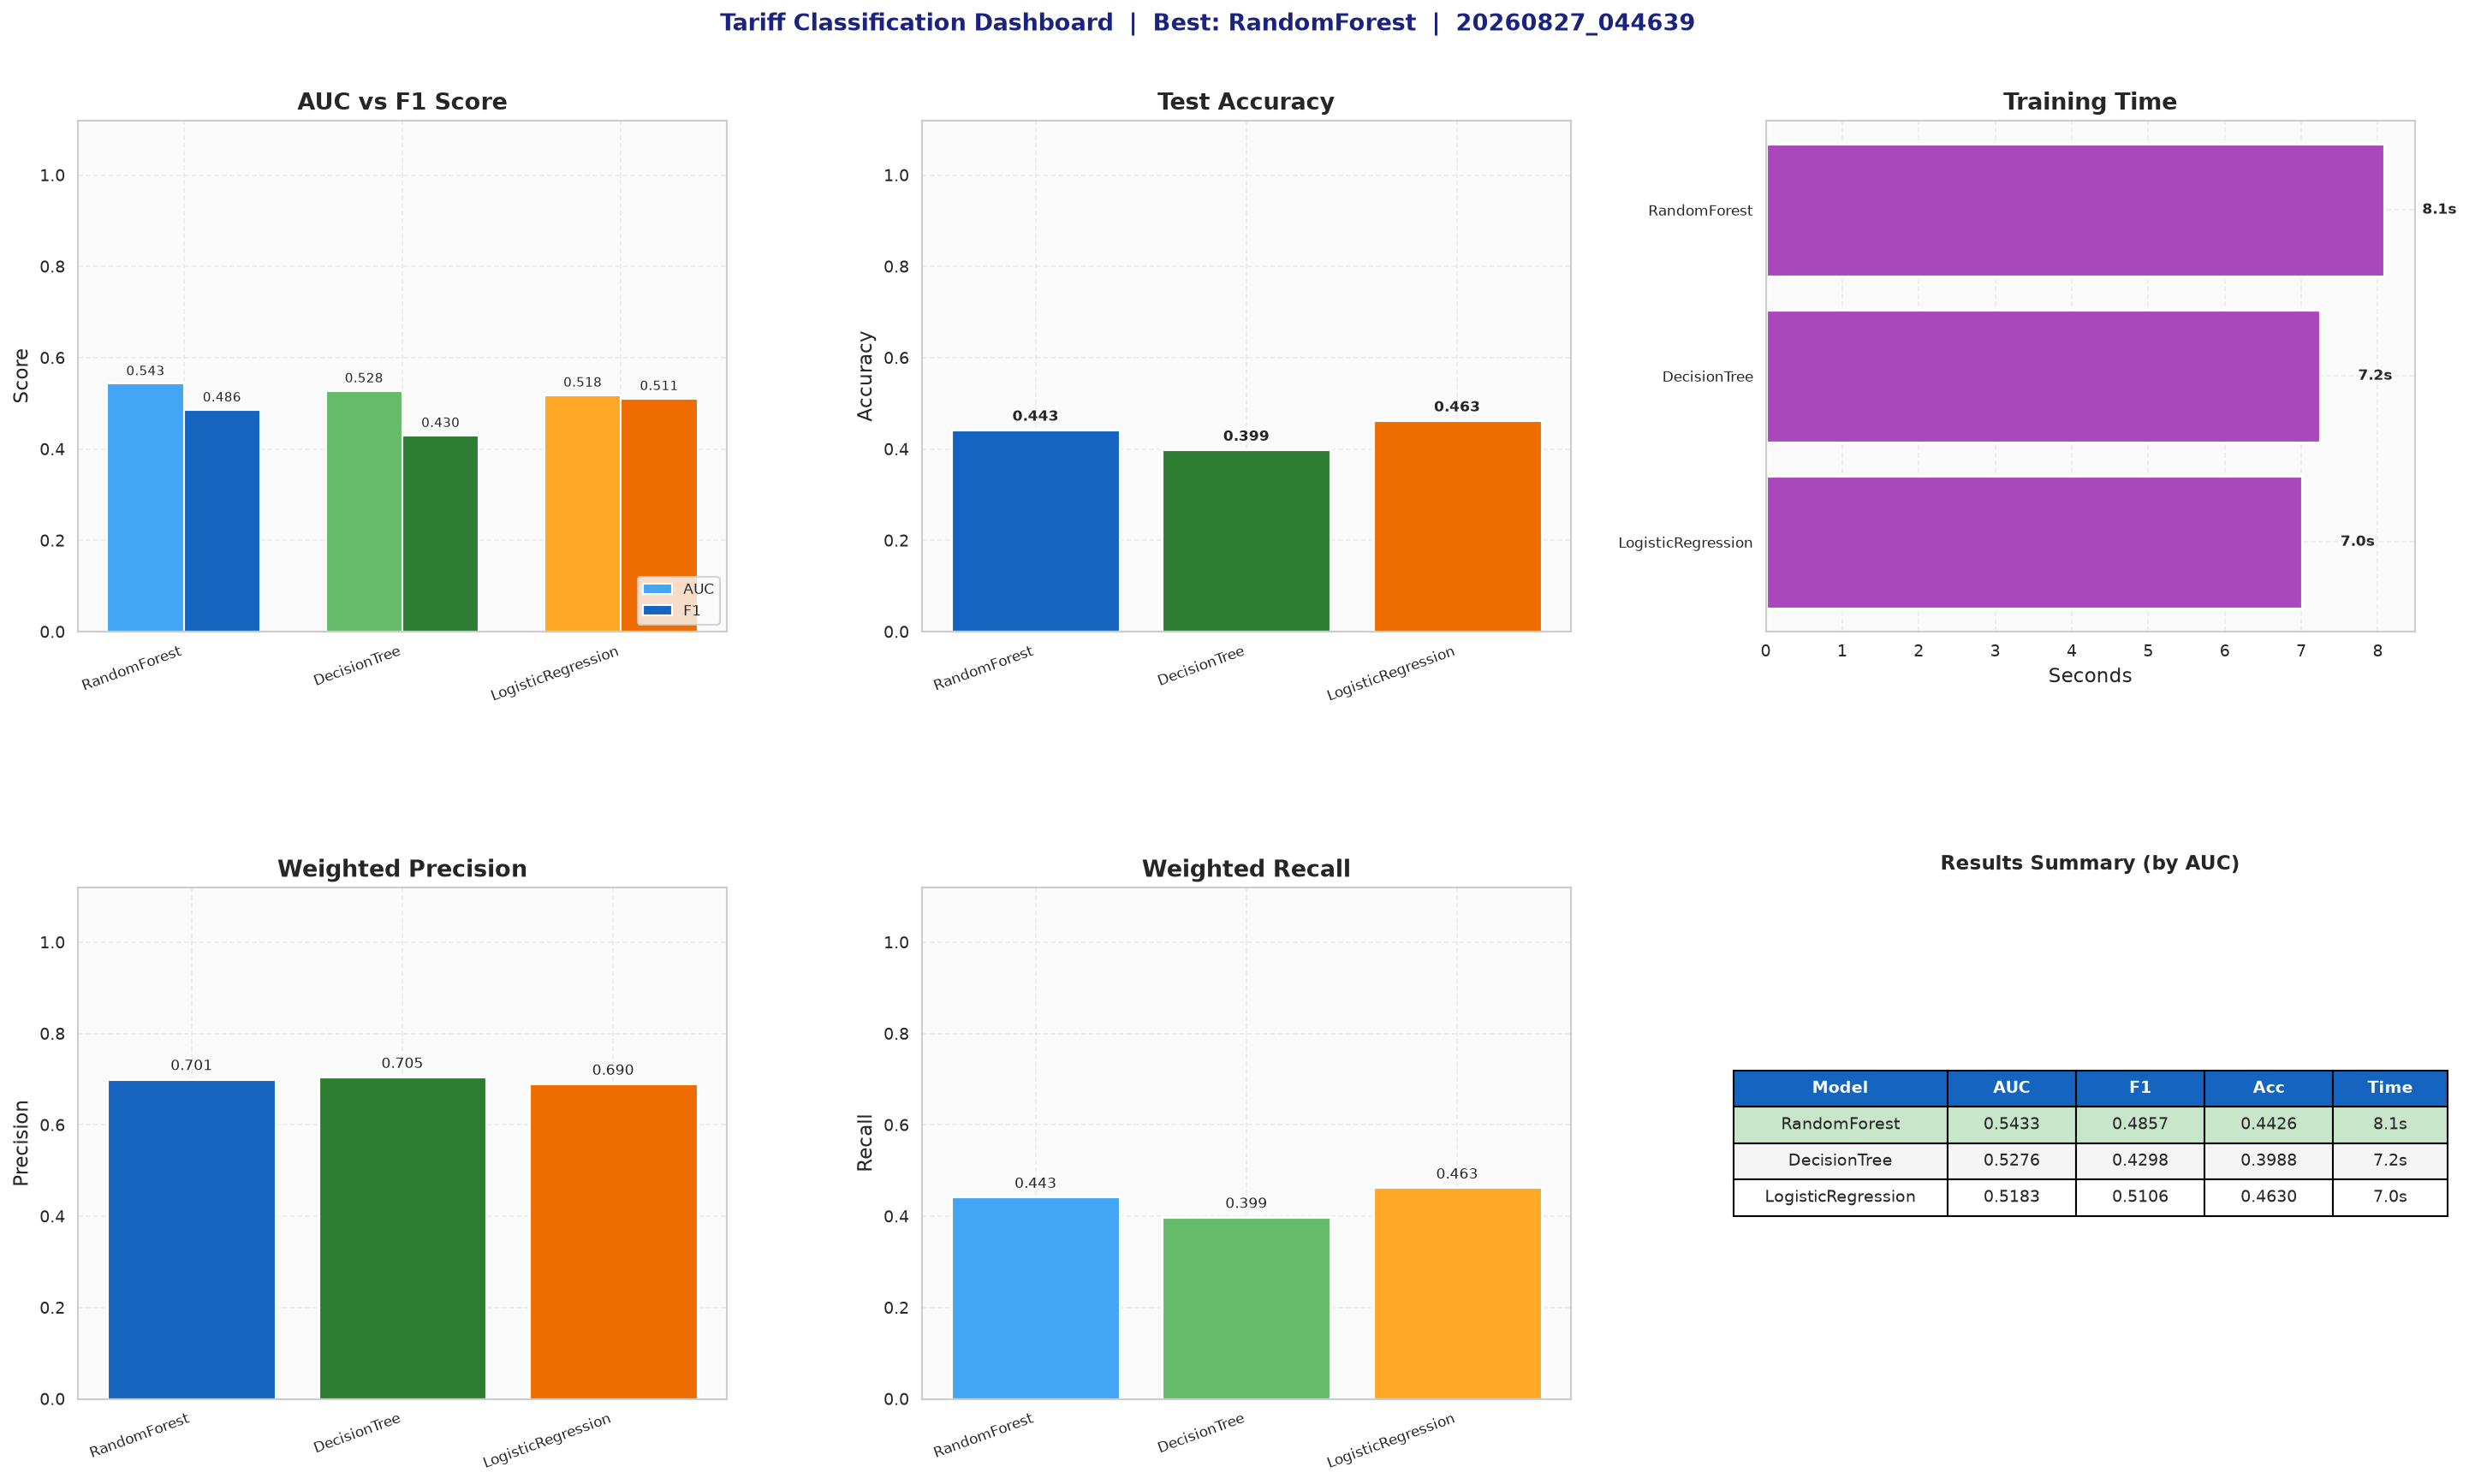

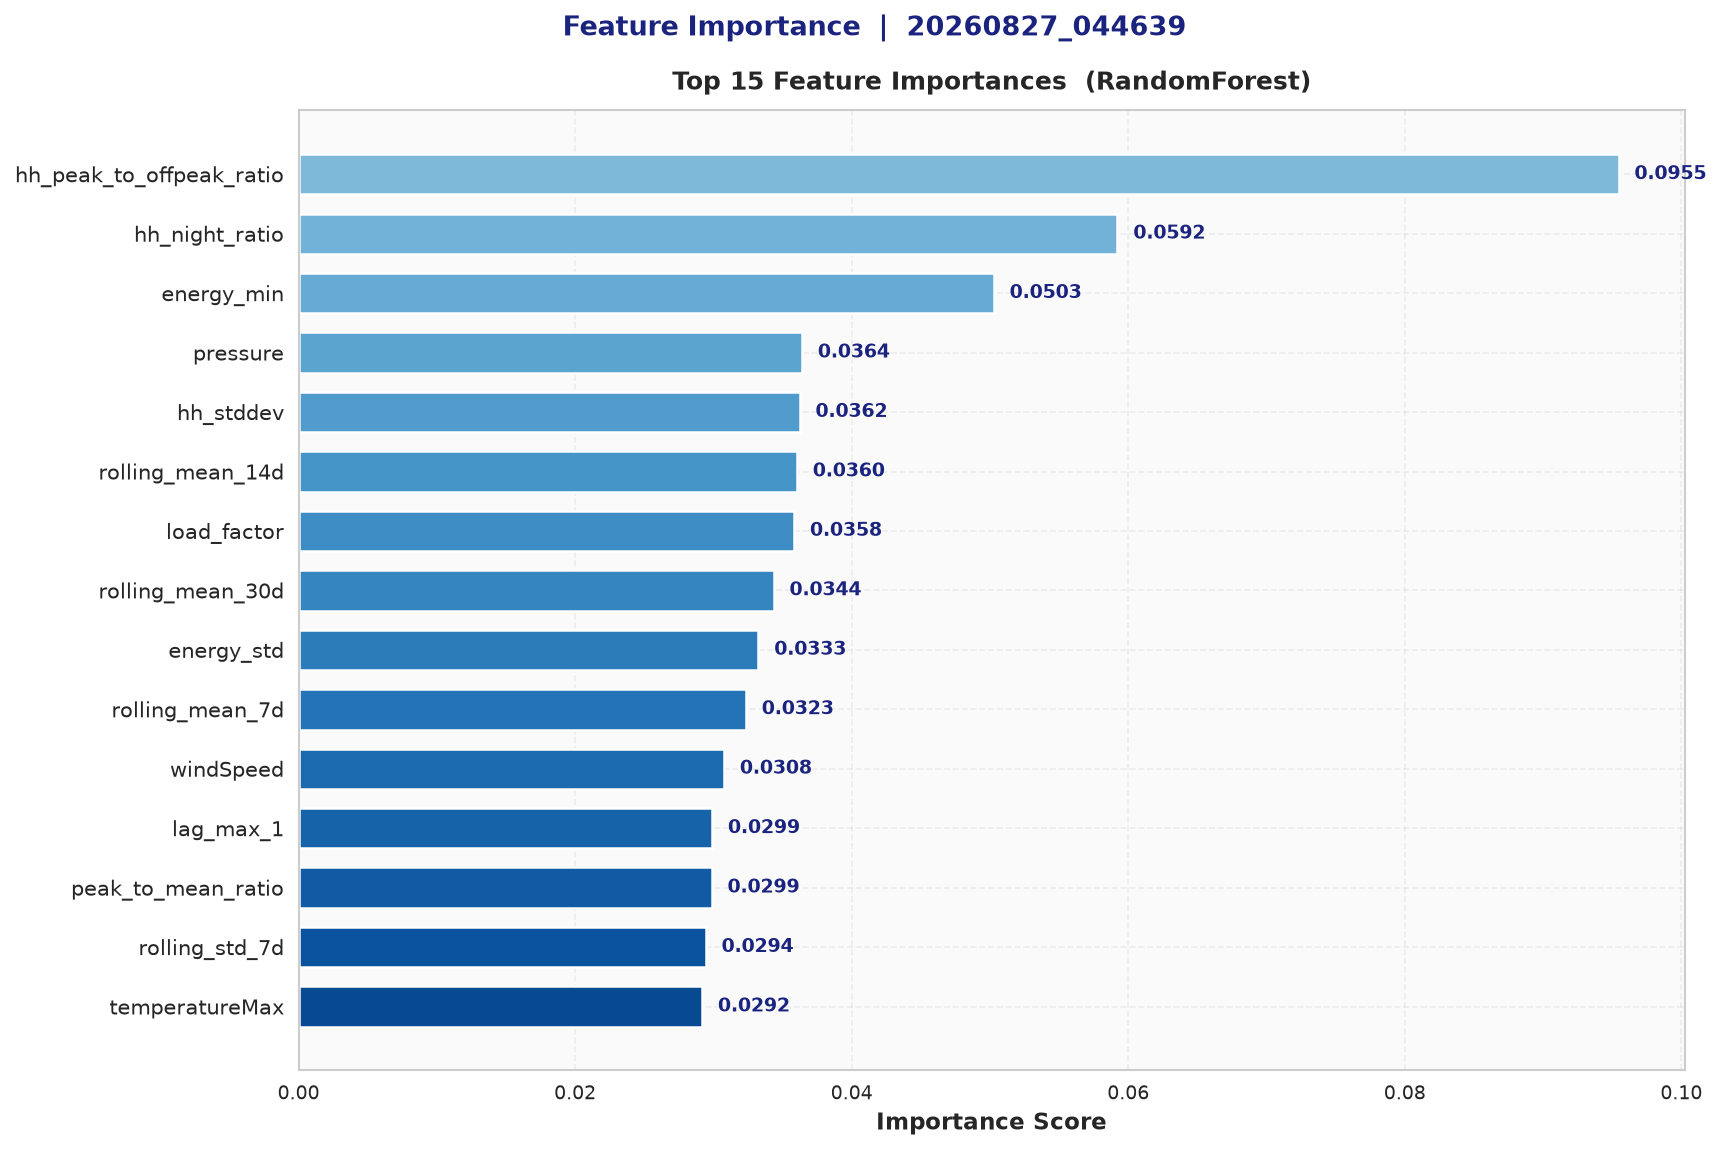

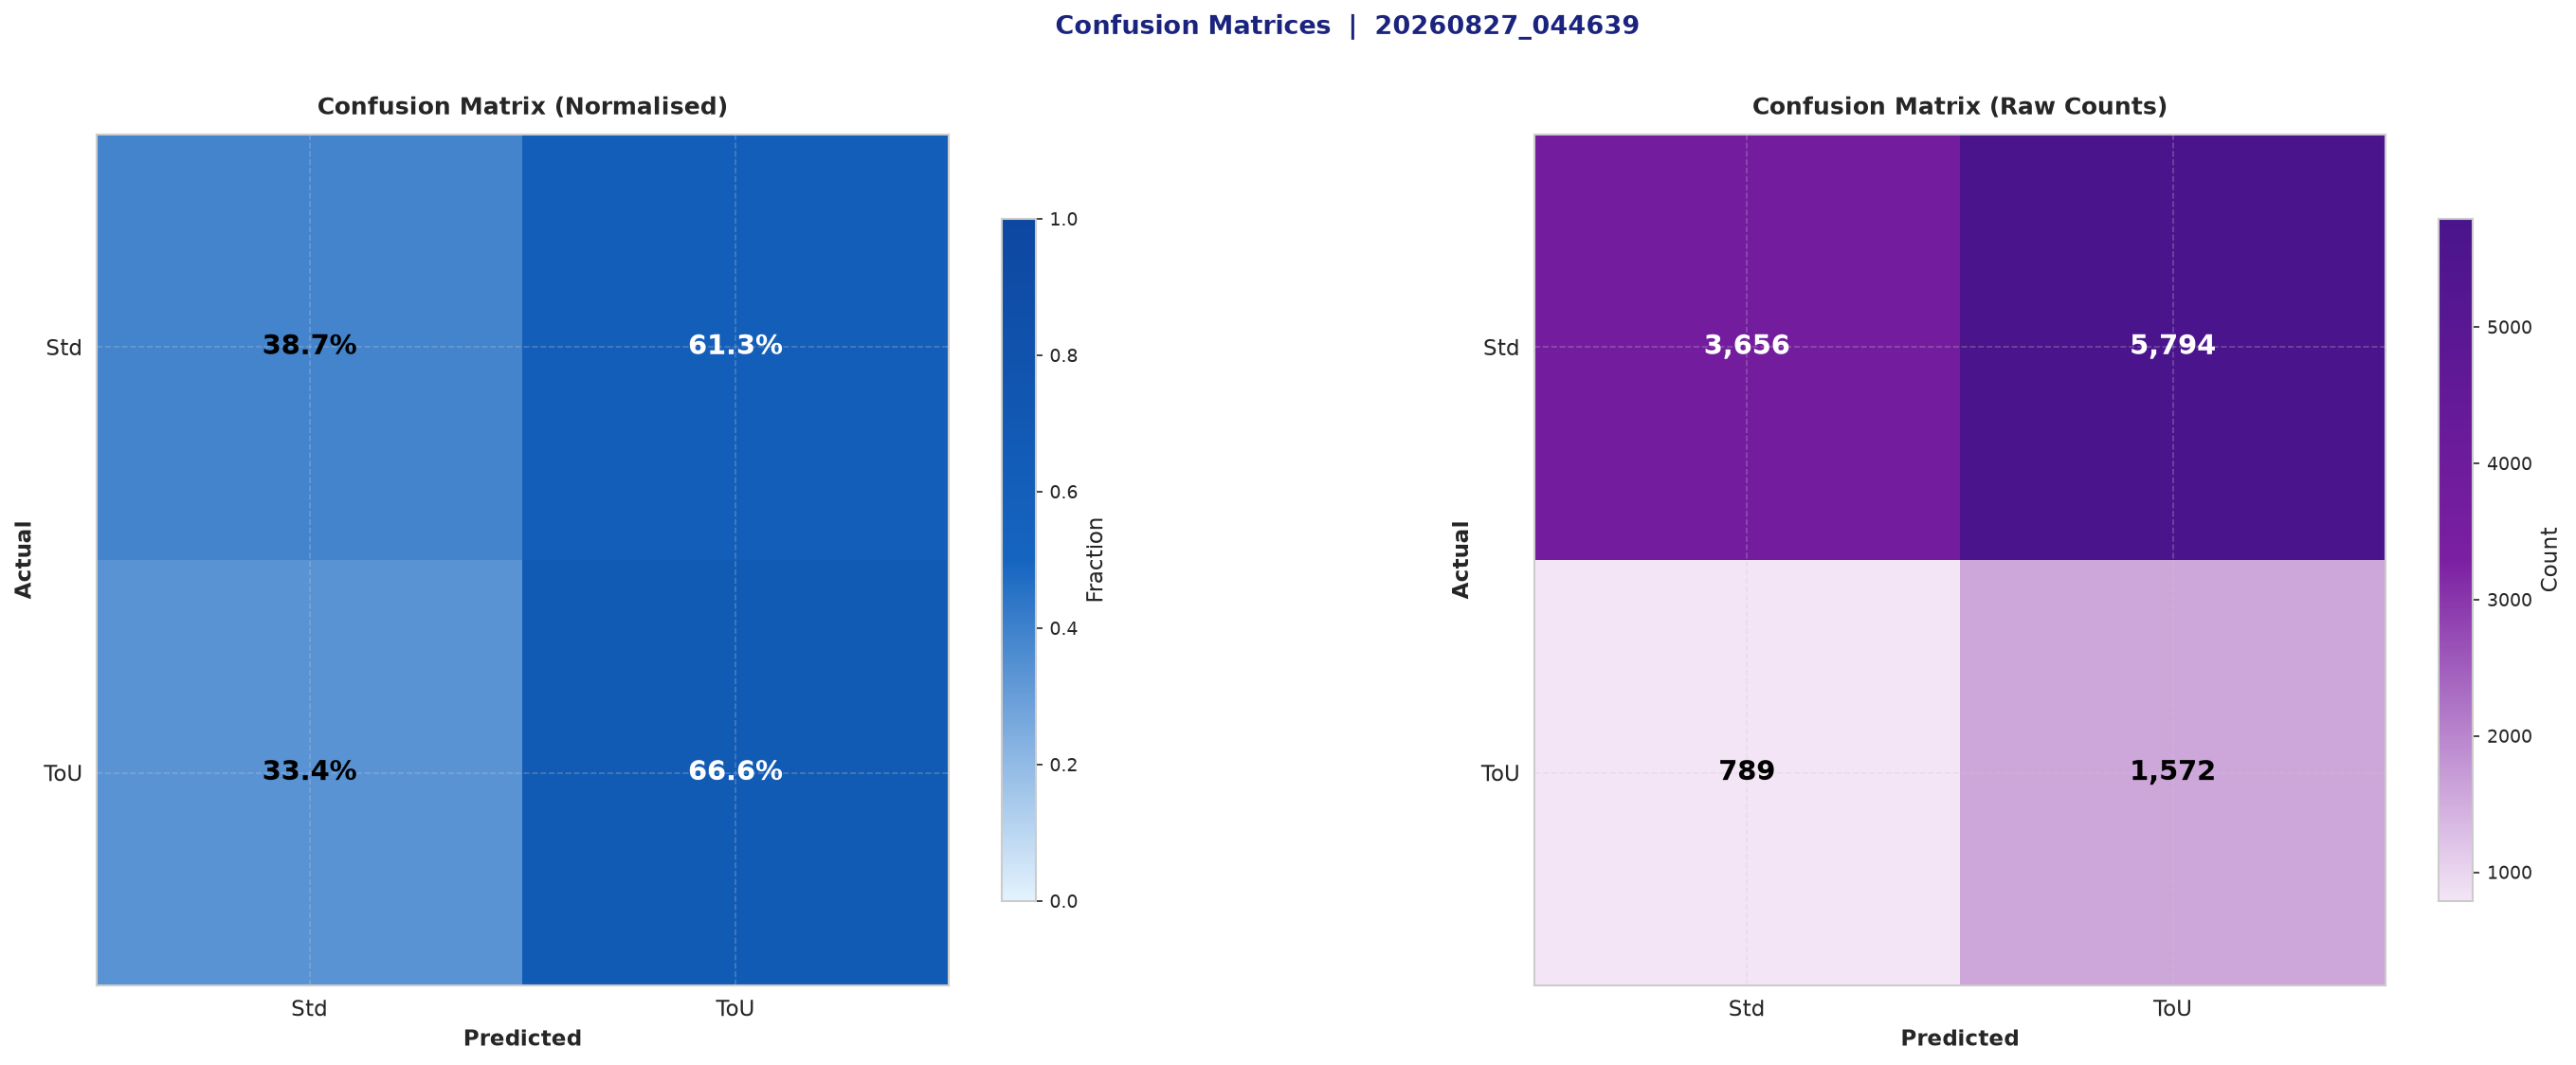


══════════════════════════════════════════════════════════════
  ✅ TARIFF CLASSIFICATION  —  COMPLETE
──────────────────────────────────────────────────────────────
  🏆 Best model : RandomForest
  📊 Test  AUC   : 0.5433
  📊 Test  F1    : 0.4857
  🎯 Accuracy    : 0.4426
  📐 Precision   : 0.7007
  🔁 Recall      : 0.4426
  ⏱   Train time  : 8.1 s
──────────────────────────────────────────────────────────────
  📁 Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 2
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 2/task02_tariff_20260827_044639.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 2/task02_tariff_20260827_044639.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 2/task02_tariff_2026082

In [12]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
import builtins
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 2')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: delete ALL previous outputs ONCE at startup ─────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

from pyspark.sql.functions import col, desc, count, when, lit, rand, isnan
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StringIndexer
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, DecisionTreeClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml import Pipeline
from functools import reduce
from operator import and_

# ── Matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.linestyle': '--', 'axes.labelsize': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.facecolor': '#fafafa', 'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.linewidth': 1.0,
})
_cmap = LinearSegmentedColormap.from_list("blues", ["#e3f2fd", "#1565c0", "#0d47a1"])

timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"TARIFF CLASSIFICATION  |  {timestamp}", "⚡")

# ════════════════════════════════════════════════════════════
# [1/6] Feature list
# ════════════════════════════════════════════════════════════
_sec('1/6', 'Building feature list', '🔧')
_base_feats = [
    "energy_mean", "energy_max", "energy_std", "energy_sum", "energy_min", "energy_median",
    "cv", "peak_to_mean_ratio", "range", "load_factor",
    "lag_mean_1", "lag_mean_7", "lag_sum_1", "lag_max_1",
    "rolling_mean_7d", "rolling_std_7d", "rolling_mean_14d", "rolling_mean_30d",
    "month", "day_of_week", "is_weekend", "season",
    "temperatureMax", "temperatureMin", "humidity", "windSpeed", "cloudCover", "pressure"
]
_hh_feats = ["hh_peak_hour_avg", "hh_offpeak_night_avg", "hh_daytime_avg",
             "hh_morning_peak_avg", "hh_night_ratio", "hh_peak_to_offpeak_ratio",
             "hh_stddev", "hh_range"]
tariff_feature_cols = [c for c in _base_feats + _hh_feats if c in daily_clean.columns]
print(f"        • Features: {len(tariff_feature_cols)} columns")

# ════════════════════════════════════════════════════════════
# [2/6] Prepare dataset
# ════════════════════════════════════════════════════════════
_sec('2/6', 'Preparing dataset', '📋')
_null_f = reduce(and_, [col(c).isNotNull() for c in tariff_feature_cols])
tariff_data = (
    daily_clean
    .select(*(["LCLid", "day", "stdorToU"] + tariff_feature_cols))
    .filter(col("stdorToU").isNotNull())
    .filter(_null_f)
    .filter(col("stdorToU").isin(["Std", "ToU"]))
    .cache()
)
_total = tariff_data.count()
print(f"        • Records: {_total:,}")
_prev_cols = [c for c in ["LCLid", "day", "energy_mean", "energy_sum", "stdorToU"] if c in tariff_data.columns]
print("        • Sample records:")
for _r in tariff_data.select(_prev_cols).limit(5).collect():
    _m = f"{_r.energy_mean:.3f}" if hasattr(_r, "energy_mean") and _r.energy_mean is not None else "-"
    _to = str(getattr(_r, "stdorToU", "-"))
    print(f"          - {_r.LCLid:<10} | {str(_r.day)[:10]} | {_m:>6} kWh | {_to}")

# ════════════════════════════════════════════════════════════
# [3/6] Encode labels
# ════════════════════════════════════════════════════════════
_sec('3/6', 'Encoding labels', '🔖')
tariff_indexer = StringIndexer(inputCol="stdorToU", outputCol="tariff_label", handleInvalid="error").fit(tariff_data)
tariff_data = tariff_indexer.transform(tariff_data)
n_classes = len(tariff_indexer.labels)
_cc = {r.tariff_label: r.cnt for r in tariff_data.groupBy("tariff_label", "stdorToU").agg(count("*").alias("cnt")).collect()}
for i, lbl in enumerate(tariff_indexer.labels):
    cnt = _cc.get(float(i), 0)
    print(f"        • Class {i} ({lbl}): {cnt:,} ({cnt/_total*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [4/6] Stratified sample
# ════════════════════════════════════════════════════════════
_sec('4/6', 'Stratified sampling', '⚖️')
_frac = builtins.min(0.12, 80000 / _total)
tariff_sample = tariff_data.sample(False, _frac, seed=42).cache()
_sn = tariff_sample.count()
print(f"        • Sampled: {_sn:,} (frac = {_frac:.4f})")
for r in sorted(tariff_sample.groupBy("stdorToU").count().collect(), key=lambda x: -x[1]):
    print(f"        • {r.stdorToU}: {r['count']:,} ({r['count']/_sn*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [5/6] Split
# ════════════════════════════════════════════════════════════
_sec('5/6', 'Train / Val / Test split', '✂️')
_tr, _tmp = tariff_sample.randomSplit([0.7, 0.3], seed=42)
_va, _te = _tmp.randomSplit([0.5, 0.5], seed=42)
train_tariff = _tr.cache(); val_tariff = _va.cache(); test_tariff = _te.cache()
train_n = train_tariff.count(); val_n = val_tariff.count(); test_n = test_tariff.count()
_tot_split = train_n + val_n + test_n
print(f"        • Train: {train_n:,} ({train_n/_tot_split*100:.1f}%)")
print(f"        • Val:   {val_n:,} ({val_n/_tot_split*100:.1f}%)")
print(f"        • Test:  {test_n:,} ({test_n/_tot_split*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [6/6] Class weights
# ════════════════════════════════════════════════════════════
_sec('6/6', 'Computing class weights', '⚖️')
_td = train_tariff.groupBy("tariff_label").agg(count("*").alias("cnt")).collect()
_ttl = builtins.sum(r.cnt for r in _td)
_wts = {float(r.tariff_label): _ttl/(n_classes*r.cnt) for r in _td}
_wexpr = lit(1.0)
for _cls, _w in _wts.items():
    _wexpr = when(col("tariff_label") == _cls, lit(_w)).otherwise(_wexpr)
train_tariff = train_tariff.withColumn("classWeightCol", _wexpr)
val_tariff = val_tariff.withColumn("classWeightCol", _wexpr)
test_tariff = test_tariff.withColumn("classWeightCol", _wexpr)
for i, lbl in enumerate(tariff_indexer.labels):
    print(f"        • {lbl}: {_wts.get(float(i), 1.0):.3f}")

# ════════════════════════════════════════════════════════════
# [7/7] Feature pipeline
# ════════════════════════════════════════════════════════════
_sec('7/7', 'Feature pipeline', '🔧')
n_features = len(tariff_feature_cols)
_assembler = VectorAssembler(inputCols=tariff_feature_cols, outputCol="features_raw", handleInvalid="skip")
_scaler = MinMaxScaler(inputCol="features_raw", outputCol="features")
print(f"        • Features: {n_features} | Scaler: MinMaxScaler [0, 1]")

# ════════════════════════════════════════════════════════════
# TRAINING
# ════════════════════════════════════════════════════════════
_hdr("TRAINING MODELS", "🚀")

_MODELS = {
    "LogisticRegression": LogisticRegression(
        featuresCol="features", labelCol="tariff_label", weightCol="classWeightCol",
        maxIter=20, regParam=0.01, elasticNetParam=0.0, family="auto", tol=1e-3),
    "DecisionTree": DecisionTreeClassifier(
        featuresCol="features", labelCol="tariff_label", weightCol="classWeightCol",
        maxDepth=8, maxBins=32, seed=42),
    "RandomForest": RandomForestClassifier(
        featuresCol="features", labelCol="tariff_label", weightCol="classWeightCol",
        numTrees=15, maxDepth=8, maxBins=32, seed=42, subsamplingRate=0.8),
}

_eval_auc = BinaryClassificationEvaluator(labelCol="tariff_label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
_eval_f1 = MulticlassClassificationEvaluator(labelCol="tariff_label", predictionCol="prediction", metricName="f1")
_eval_acc = MulticlassClassificationEvaluator(labelCol="tariff_label", predictionCol="prediction", metricName="accuracy")
_eval_prec = MulticlassClassificationEvaluator(labelCol="tariff_label", predictionCol="prediction", metricName="weightedPrecision")
_eval_rec = MulticlassClassificationEvaluator(labelCol="tariff_label", predictionCol="prediction", metricName="weightedRecall")

results = {}
for _name, _mdl in _MODELS.items():
    print(f"\n    ▶ {_name}")
    print(f"      {'─'*46}")
    _pipe = Pipeline(stages=[_assembler, _scaler, _mdl])
    _t0 = time.time()
    try:
        _fit = _pipe.fit(train_tariff)
        _t = time.time() - _t0
        _vp = _fit.transform(val_tariff)
        _tp = _fit.transform(test_tariff)
        _vf1 = _eval_f1.evaluate(_vp)
        _tf1 = _eval_f1.evaluate(_tp)
        _tacc = _eval_acc.evaluate(_tp)
        _tpr = _eval_prec.evaluate(_tp)
        _trc = _eval_rec.evaluate(_tp)
        _tauc = _eval_auc.evaluate(_tp)
        results[_name] = dict(
            val_f1=_vf1, test_f1=_tf1, test_acc=_tacc,
            test_prec=_tpr, test_rec=_trc, test_auc=_tauc,
            time=_t, model=_fit, test_preds=_tp, status="✅")
        print(f"      ⏱ {_t:5.1f}s | ValF1={_vf1:.4f} TestF1={_tf1:.4f} Acc={_tacc:.4f} AUC={_tauc:.4f}")
    except Exception as _ex:
        print(f"     ❌ {str(_ex)[:110]}")
        results[_name] = {"status": f"❌ {str(_ex)[:110]}"}

_hdr("MODEL COMPARISON", "📊")
ok = {k: v for k, v in results.items() if v.get("status", "").startswith("✅")}
if not ok:
    raise RuntimeError("No model succeeded — cannot continue")

sorted_models = sorted(ok.items(), key=lambda x: x[1]['test_auc'], reverse=True)
sorted_names = [m for m, _ in sorted_models]
best = sorted_names[0]

_comp = pd.DataFrame([
    dict(Model=m, ValF1=f"{r['val_f1']:.4f}", TestF1=f"{r['test_f1']:.4f}",
         Acc=f"{r['test_acc']:.4f}", AUC=f"{r['test_auc']:.4f}",
         Prec=f"{r['test_prec']:.4f}", Rec=f"{r['test_rec']:.4f}", Time=f"{r['time']:.1f}s")
    for m, r in sorted_models])
print("\n" + _comp.to_string(index=False))
print(f"\n  🏆 BEST: {C.BOLD}{best}{C.END}  "
      f"AUC={ok[best]['test_auc']:.4f}  F1={ok[best]['test_f1']:.4f}  Acc={ok[best]['test_acc']:.4f}")

# ════════════════════════════════════════════════════════════
# PER-CLASS METRICS
# ════════════════════════════════════════════════════════════
_hdr("PER-CLASS METRICS", "📋")
_bpreds = ok[best]["test_preds"]
per_class_data = []
print(f"\n  {'Class':<12} | {'N':>6} | {'Correct':>7} | {'Prec':>7} | {'Rec':>7} | {'F1':>7} | {'Spec':>7}")
print("  " + "─"*65)
for _i, _lbl in enumerate(tariff_indexer.labels):
    _tp = _bpreds.filter((col("tariff_label") == _i) & (col("prediction") == _i)).count()
    _fp = _bpreds.filter((col("tariff_label") != _i) & (col("prediction") == _i)).count()
    _fn = _bpreds.filter((col("tariff_label") == _i) & (col("prediction") != _i)).count()
    _tn = _bpreds.filter((col("tariff_label") != _i) & (col("prediction") != _i)).count()
    _pr = _tp/(_tp+_fp) if (_tp+_fp) > 0 else 0
    _rc = _tp/(_tp+_fn) if (_tp+_fn) > 0 else 0
    _f1 = 2*_pr*_rc/(_pr+_rc) if (_pr+_rc) > 0 else 0
    _sp = _tn/(_tn+_fp) if (_tn+_fp) > 0 else 0
    per_class_data.append([_lbl, _tp+_fn, _tp, _pr, _rc, _f1, _sp])
    print(f"  {_lbl:<12} | {_tp+_fn:>6,} | {_tp:>7,} | {_pr:>7.3f} | {_rc:>7.3f} | {_f1:>7.3f} | {_sp:>7.3f}")

# ════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
_hdr("FEATURE IMPORTANCE", "🔍")
feat_imp = []
_fs = ok[best]["model"].stages[-1] if hasattr(ok[best]["model"], 'stages') else None
if _fs and hasattr(_fs, 'featureImportances'):
    feat_imp = sorted(zip(tariff_feature_cols, _fs.featureImportances.toArray()), key=lambda x: -x[1])
    print("  Top 15:")
    for _i, (f, v) in enumerate(feat_imp[:15], 1):
        _bar = "█"*int(v*80)
        print(f"  {_i:2d}. {f:<28} {v:.4f} {_bar}")
else:
    _warn("Feature importances not available for this model type")

# ════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix
_ppd = _bpreds.select("prediction", "tariff_label").toPandas()
cm = confusion_matrix(_ppd['tariff_label'], _ppd['prediction'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels = tariff_indexer.labels

# ════════════════════════════════════════════════════════════
# BUILD VISUALISATIONS
# ════════════════════════════════════════════════════════════
_hdr("BUILDING VISUALISATIONS", "🎨")

_nm = len(sorted_names)
_x = np.arange(_nm)
_w = 0.35
_COLS = ['#1565c0', '#2e7d32', '#ef6c00'][:_nm]
_COLS2 = ['#42a5f5', '#66bb6a', '#ffa726'][:_nm]

# ════════════════════════════════════════════════════════════
# FIGURE 1: Dashboard (display only - not saved)
# ════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(20, 12), facecolor='white')
_dg = mgridspec.GridSpec(2, 3, figure=fig1,
                          hspace=0.50, wspace=0.30,
                          left=0.06, right=0.97,
                          top=0.91, bottom=0.08)

_da1 = fig1.add_subplot(_dg[0, 0])
_da2 = fig1.add_subplot(_dg[0, 1])
_da3 = fig1.add_subplot(_dg[0, 2])
_da4 = fig1.add_subplot(_dg[1, 0])
_da5 = fig1.add_subplot(_dg[1, 1])
_da6 = fig1.add_subplot(_dg[1, 2])

# AUC vs F1
_b1 = _da1.bar(_x - _w/2, [ok[n]['test_auc'] for n in sorted_names], _w,
               label='AUC', color=_COLS2, edgecolor='white', lw=1)
_b2 = _da1.bar(_x + _w/2, [ok[n]['test_f1'] for n in sorted_names], _w,
               label='F1', color=_COLS, edgecolor='white', lw=1)
_da1.set_ylabel('Score'); _da1.set_title('AUC vs F1 Score')
_da1.set_xticks(_x); _da1.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da1.set_ylim(0, 1.12); _da1.legend(fontsize=8, loc='lower right')
for _b in list(_b1) + list(_b2):
    _da1.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.012,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# Accuracy
_bs = _da2.bar(sorted_names, [ok[n]['test_acc'] for n in sorted_names],
               color=_COLS, edgecolor='white', lw=1.5)
_da2.set_ylabel('Accuracy'); _da2.set_title('Test Accuracy')
_da2.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da2.set_ylim(0, 1.12)
for _b in _bs:
    _da2.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.012,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Training Time
_bh = _da3.barh(sorted_names, [ok[n]['time'] for n in sorted_names],
                color='#ab47bc', edgecolor='white', lw=1.5)
_da3.set_xlabel('Seconds'); _da3.set_title('Training Time')
_da3.invert_yaxis(); _da3.set_yticklabels(sorted_names, fontsize=8)
for _b in _bh:
    _da3.text(_b.get_width() + 0.5, _b.get_y() + _b.get_height()/2,
              f'{_b.get_width():.1f}s', va='center', fontsize=8, fontweight='bold')

# Precision
_bsp = _da4.bar(sorted_names, [ok[n]['test_prec'] for n in sorted_names],
                color=_COLS, edgecolor='white', lw=1.5)
_da4.set_ylabel('Precision'); _da4.set_title('Weighted Precision')
_da4.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da4.set_ylim(0, 1.12)
for _b in _bsp:
    _da4.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.012,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Recall
_bsr = _da5.bar(sorted_names, [ok[n]['test_rec'] for n in sorted_names],
                color=_COLS2, edgecolor='white', lw=1.5)
_da5.set_ylabel('Recall'); _da5.set_title('Weighted Recall')
_da5.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da5.set_ylim(0, 1.12)
for _b in _bsr:
    _da5.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.012,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Results table
_da6.axis('off')
_td = [[m, f"{r['test_auc']:.4f}", f"{r['test_f1']:.4f}", f"{r['test_acc']:.4f}", f"{r['time']:.1f}s"]
       for m, r in sorted_models]
_tbl = _da6.table(cellText=_td, colLabels=['Model', 'AUC', 'F1', 'Acc', 'Time'],
                  cellLoc='center', loc='center',
                  colColours=['#1565c0']*5, colWidths=[0.30, 0.18, 0.18, 0.18, 0.16])
_tbl.auto_set_font_size(False); _tbl.set_fontsize(9); _tbl.scale(1.1, 1.7)
for _j in range(5):
    _tbl[(0, _j)].set_text_props(color='white', fontweight='bold')
for _i in range(1, len(_td)+1):
    for _j in range(5):
        _tbl[(_i, _j)].set_facecolor('#c8e6c9' if _td[_i-1][0] == best
                                     else ('#f5f5f5' if _i % 2 == 0 else 'white'))
_da6.set_title('Results Summary (by AUC)', fontweight='bold', pad=10, fontsize=11)

fig1.suptitle(f'Tariff Classification Dashboard  |  Best: {best}  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 2: Feature Importance (display only - not saved)
# ════════════════════════════════════════════════════════════
fig2, _fl = plt.subplots(1, 1, figsize=(12, 8), facecolor='white',
    gridspec_kw={'left': 0.18, 'right': 0.95, 'top': 0.90, 'bottom': 0.10})

if feat_imp:
    _fn15 = [f[0] for f in feat_imp[:15]]; _fv15 = [f[1] for f in feat_imp[:15]]
    _grad = plt.cm.Blues(np.linspace(0.45, 0.90, len(_fn15)))
    _fl.barh(range(len(_fn15)), _fv15, color=_grad, edgecolor='white', linewidth=1.2, height=0.68)
    _fl.set_yticks(range(len(_fn15))); _fl.set_yticklabels(_fn15, fontsize=10)
    _fl.invert_yaxis()
    _fl.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
    _fl.set_title(f'Top 15 Feature Importances  ({best})', fontsize=12, fontweight='bold', pad=10)
    _fl.grid(axis='x', alpha=0.3, linestyle='--')
    _mx = float(np.max(_fv15)) if _fv15 else 1.0
    for _i, _v in enumerate(_fv15):
        _fl.text(_v + _mx*0.012, _i, f'{_v:.4f}', va='center', fontsize=9, fontweight='bold', color='#1a237e')
else:
    _fl.text(0.5, 0.5, 'Feature importances not available', ha='center', va='center', fontsize=12, color='grey')
    _fl.axis('off')

fig2.suptitle(f'Feature Importance  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 3: Confusion Matrices — Normalized + Counts side by side
# ════════════════════════════════════════════════════════════
fig3, (_fr, _fc) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white',
    gridspec_kw={'wspace': 0.35, 'left': 0.06, 'right': 0.94, 'top': 0.90, 'bottom': 0.10})

# Left: Normalized
_im = _fr.imshow(cm_norm, interpolation='nearest', cmap=_cmap, vmin=0, vmax=1)
_fr.set_title('Confusion Matrix (Normalised)', fontweight='bold', fontsize=12, pad=10)
_fr.set_xlabel('Predicted', fontweight='bold'); _fr.set_ylabel('Actual', fontweight='bold')
_fr.set_xticks(np.arange(len(labels))); _fr.set_yticks(np.arange(len(labels)))
_fr.set_xticklabels(labels, fontsize=11); _fr.set_yticklabels(labels, fontsize=11)
for _i in range(len(labels)):
    for _j in range(len(labels)):
        _fr.text(_j, _i, f'{cm_norm[_i, _j]:.1%}', ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm_norm[_i, _j] > 0.5 else 'black')
fig3.colorbar(_im, ax=_fr, shrink=0.75, label='Fraction')

# Right: Raw Counts
_cmap_counts = LinearSegmentedColormap.from_list("purples", ["#f3e5f5", "#7b1fa2", "#4a148c"])
_imc = _fc.imshow(cm, interpolation='nearest', cmap=_cmap_counts)
_fc.set_title('Confusion Matrix (Raw Counts)', fontweight='bold', fontsize=12, pad=10)
_fc.set_xlabel('Predicted', fontweight='bold'); _fc.set_ylabel('Actual', fontweight='bold')
_fc.set_xticks(np.arange(len(labels))); _fc.set_yticks(np.arange(len(labels)))
_fc.set_xticklabels(labels, fontsize=11); _fc.set_yticklabels(labels, fontsize=11)
for _i in range(len(labels)):
    for _j in range(len(labels)):
        _fc.text(_j, _i, f'{cm[_i, _j]:,}', ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[_i, _j] > cm.max()/2 else 'black')
fig3.colorbar(_imc, ax=_fc, shrink=0.75, label='Count')

fig3.suptitle(f'Confusion Matrices  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# SAVE COMBINED PNG
# ════════════════════════════════════════════════════════════
import matplotlib.image as _mimg
import io as _io

def _fig_to_arr(f):
    _buf = _io.BytesIO()
    f.savefig(_buf, dpi=200, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    return _mimg.imread(_buf)

_arr1 = _fig_to_arr(fig1)
_arr2 = _fig_to_arr(fig2)
_arr3 = _fig_to_arr(fig3)

plt.close(fig1); plt.close(fig2); plt.close(fig3)

_h1, _w1 = _arr1.shape[:2]
_h2, _w2 = _arr2.shape[:2]
_h3, _w3 = _arr3.shape[:2]
_W = builtins.max(_w1, _w2, _w3)

_total_h = _h1 + _h2 + _h3 + 40
_merged = np.ones((_total_h, _W, 4), dtype=np.float32)

_y = 0
_merged[_y:_y+_h1, :_w1] = _arr1
_y += _h1 + 20
_merged[_y:_y+_h2, :_w2] = _arr2
_y += _h2 + 20
_merged[_y:_y+_h3, :_w3] = _arr3

_final_png = f'{output_dir}/task02_tariff_{timestamp}.png'
_mfig, _max = plt.subplots(figsize=(_W/200, _total_h/200), facecolor='white',
    gridspec_kw={'left': 0, 'right': 1, 'top': 1, 'bottom': 0})
_max.imshow(_merged, interpolation='lanczos')
_max.axis('off')
_mfig.savefig(_final_png, dpi=200, bbox_inches='tight',
              facecolor='white', edgecolor='none', pad_inches=0.02)
plt.close(_mfig)

# ════════════════════════════════════════════════════════════
# BUILD FINAL CSV
# ════════════════════════════════════════════════════════════
total_n = train_n + val_n + test_n
train_pct = train_n / total_n * 100 if total_n else 0
val_pct = val_n / total_n * 100 if total_n else 0
test_pct = test_n / total_n * 100 if total_n else 0

_final_csv = f'{output_dir}/task02_tariff_{timestamp}.csv'
_lines = []

_lines += [
    "TARIFF CLASSIFICATION REPORT",
    f"Generated,{timestamp}",
    f"Best Model,{best}",
    f"Test AUC,{ok[best]['test_auc']:.4f}",
    f"Test F1,{ok[best]['test_f1']:.4f}",
    f"Test Accuracy,{ok[best]['test_acc']:.4f}",
    "",
    "── SECTION 1: MODEL COMPARISON ──────────────────────────────",
    "Model,Val_F1,Test_F1,Accuracy,AUC,Precision,Recall,Time_s,Best",
]
for _m, _r in sorted_models:
    _lines.append(
        f"{_m},{_r['val_f1']:.4f},{_r['test_f1']:.4f},"
        f"{_r['test_acc']:.4f},{_r['test_auc']:.4f},{_r['test_prec']:.4f},"
        f"{_r['test_rec']:.4f},{_r['time']:.1f},"
        f"{'YES' if _m == best else ''}")

_lines += [
    "",
    "── SECTION 2: PER-CLASS METRICS ──────────────────────────────",
    "Class,Total,Correct,Precision,Recall,F1,Specificity",
]
for _row in per_class_data:
    _lines.append(f"{_row[0]},{_row[1]},{_row[2]},{_row[3]:.4f},{_row[4]:.4f},{_row[5]:.4f},{_row[6]:.4f}")

_lines += [
    "",
    "── SECTION 3: FEATURE IMPORTANCE ──────────────────────────────",
    "Rank,Feature,Importance",
]
for _i, (_f, _v) in enumerate(feat_imp if feat_imp else [('N/A', 0)], 1):
    _lines.append(f"{_i},{_f},{_v:.6f}")

_lines += [
    "",
    "── SECTION 4: CONFUSION MATRIX (COUNTS) ──────────────────────",
    "," + ",".join(labels),
]
for i, row in enumerate(cm):
    _lines.append(f"{labels[i]}," + ",".join([str(v) for v in row]))

_lines += [
    "",
    "── SECTION 5: CONFUSION MATRIX (NORMALISED) ──────────────────",
    "," + ",".join(labels),
]
for i, row in enumerate(cm_norm):
    _lines.append(f"{labels[i]}," + ",".join([f"{v:.4f}" for v in row]))

_lines += [
    "",
    "── SECTION 6: DATASET SUMMARY ──────────────────────────────",
    f"Total Records,{total_n}",
    f"Train,{train_n},{train_pct:.1f}%",
    f"Validation,{val_n},{val_pct:.1f}%",
    f"Test,{test_n},{test_pct:.1f}%",
    f"Features,{n_features}",
    f"Classes,{n_classes}",
]

with open(_final_csv, 'w', encoding='utf-8') as _fh:
    _fh.write('\n'.join(_lines))

# ════════════════════════════════════════════════════════════
# HTML REPORT
# ════════════════════════════════════════════════════════════

# model rows
_model_rows = ""
for _m, _r in sorted_models:
    _cls = "best-row" if _m == best else ""
    _trph = "🏆" if _m == best else ""
    _model_rows += f"""
        <tr class="{_cls}">
            <td><strong>{_m}</strong> {_trph}</td>
            <td>{_r['val_f1']:.4f}</td><td>{_r['test_f1']:.4f}</td>
            <td>{_r['test_acc']:.4f}</td><td>{_r['test_auc']:.4f}</td>
            <td>{_r['test_prec']:.4f}</td><td>{_r['test_rec']:.4f}</td>
            <td>{_r['time']:.1f}</td>
        </tr>"""

# class rows
_class_rows = ""
for _row in per_class_data:
    _class_rows += f"""
        <tr>
            <td><strong>{_row[0]}</strong></td>
            <td>{_row[1]:,}</td><td>{_row[2]:,}</td>
            <td>{_row[3]:.4f}</td><td>{_row[4]:.4f}</td>
            <td>{_row[5]:.4f}</td><td>{_row[6]:.4f}</td>
        </tr>"""


# ════════════════════════════════════════════════════════════
# Confusion-matrix cell colour + readable text colour.
# A fixed luminance threshold leaves a "dead zone" around mid-intensity
# cells (e.g. t≈0.5) where the background is a medium tone and NEITHER
# white nor black text clears WCAG's 4.5:1 minimum contrast — that is
# what made some cells hard to read. Instead we compute the actual WCAG
# contrast ratio for both candidate text colours against the exact
# background and pick whichever one wins.
# (Uses _bi.max/_bi.min/_bi.round to avoid the PySpark override of
# max/min/round created by the Cell 1 wildcard import.)
# ════════════════════════════════════════════════════════════
def _rel_luminance(rgb):
    """WCAG relative luminance of an sRGB colour (0-255 per channel)."""
    chans = []
    for c in rgb:
        c = c / 255.0
        chans.append(c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4)
    r, g, b = chans
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def _wcag_contrast(rgb1, rgb2):
    """WCAG 2.x contrast ratio between two sRGB colours."""
    l1, l2 = _rel_luminance(rgb1), _rel_luminance(rgb2)
    l1, l2 = _bi.max(l1, l2), _bi.min(l1, l2)
    return (l1 + 0.05) / (l2 + 0.05)

def _cm_colors(t, dark=(0, 77, 64), light=(224, 242, 241)):
    """Map 0..1 intensity to a dark-teal heatmap background colour, then
    pick whichever text colour (white or near-black ink) gives the higher
    WCAG contrast ratio against that exact background."""
    t = float(_bi.max(0.0, _bi.min(1.0, t)))
    r = int(_bi.round(light[0] + t * (dark[0] - light[0])))
    g = int(_bi.round(light[1] + t * (dark[1] - light[1])))
    b = int(_bi.round(light[2] + t * (dark[2] - light[2])))
    bg = (r, g, b)
    white, ink = (255, 255, 255), (16, 32, 39)
    tc = "#ffffff" if _wcag_contrast(bg, white) >= _wcag_contrast(bg, ink) else "#102027"
    return f"rgb({r},{g},{b})", tc

# confusion matrix grid (normalised) — dark cells get white text, light cells get dark text
_cm_grid = '<div></div>'
for _l in labels: _cm_grid += f'<div class="cm-header">{_l}</div>'
for _i, _l in enumerate(labels):
    _cm_grid += f'<div class="cm-label">{_l}</div>'
    for _j in range(len(labels)):
        _v = cm_norm[_i, _j]
        _bg, _tc = _cm_colors(_v)
        _cm_grid += f'<div class="cm-cell" style="background:{_bg};color:{_tc}">{_v:.1%}</div>'

# confusion matrix counts grid
_cm_counts_grid = '<div></div>'
for _l in labels: _cm_counts_grid += f'<div class="cm-header">{_l}</div>'
for _i, _l in enumerate(labels):
    _cm_counts_grid += f'<div class="cm-label">{_l}</div>'
    for _j in range(len(labels)):
        _v = cm[_i, _j]
        _mxv = float(cm.max()) if cm.max() > 0 else 1.0
        _bg, _tc = _cm_colors(_v / _mxv)
        _cm_counts_grid += f'<div class="cm-cell" style="background:{_bg};color:{_tc}">{_v:,}</div>'

# feature bars
_max_imp = feat_imp[0][1] if feat_imp else 1.0
_feat_bars = ""
for _i, (_f, _v) in enumerate(feat_imp[:15], 1):
    _pct = _v/_max_imp*100
    _feat_bars += f"""
        <div class="feat-row">
            <div class="feat-name">{_i:2d}. {_f}</div>
            <div class="feat-bar-wrap"><div class="feat-bar" style="width:{_pct:.1f}%"></div></div>
            <div class="feat-val">{_v:.4f}</div>
        </div>"""

_br = ok[best]
_final_html = f'{output_dir}/task02_tariff_{timestamp}.html'
_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Tariff Report — {timestamp}</title>
<style>
:root{{--p:#004d40;--pl:#00796b;--ac:#26c6da;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(0,77,64,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.cm-grid{{display:grid;grid-template-columns:auto repeat({n_classes},1fr);
          gap:2px;max-width:480px;margin:0 auto}}
.cm-cell,.cm-header,.cm-label{{padding:14px 8px;text-align:center;font-weight:600;border-radius:5px}}
.cm-header{{background:var(--p);color:#fff;font-size:.82rem}}
.cm-label{{background:var(--pl);color:#fff;font-size:.82rem;
           display:flex;align-items:center;justify-content:center}}
.feat-row{{display:flex;align-items:center;padding:8px 0;border-bottom:1px solid #f0f0f0}}
.feat-name{{width:250px;font-size:.88rem;font-weight:500;flex-shrink:0}}
.feat-bar-wrap{{flex:1;height:18px;background:#eceff1;border-radius:9px;
                overflow:hidden;margin:0 12px}}
.feat-bar{{height:100%;border-radius:9px;
           background:linear-gradient(90deg,var(--ac) 0%,var(--pl) 100%)}}
.feat-val{{width:64px;text-align:right;font-weight:700;color:var(--p);font-size:.88rem;flex-shrink:0}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>⚡ Tariff Classification Report</h1>
  <p>Binary classification of Standard vs Time-of-Use tariff · Smart Meter Energy Features</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best: {best}</span>
    <span class="bdg">🧬 {n_classes} Classes</span>
    <span class="bdg">📊 {n_features} Features</span>
    <span class="bdg">🗂️ {total_n:,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{_br['test_auc']:.4f}</div><div class="kl">AUC Score</div></div>
  <div class="kpi"><div class="kv">{_br['test_f1']:.4f}</div><div class="kl">F1 Score</div></div>
  <div class="kpi"><div class="kv">{_br['test_acc']:.4f}</div><div class="kl">Accuracy</div></div>
  <div class="kpi"><div class="kv">{_br['test_prec']:.4f}</div><div class="kl">Precision</div></div>
  <div class="kpi"><div class="kv">{_br['test_rec']:.4f}</div><div class="kl">Recall</div></div>
  <div class="kpi"><div class="kv">{_br['time']:.1f}s</div><div class="kl">Train Time</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Model Comparison (Ranked by AUC)</div>
  <div class="tw"><table>
    <thead><tr><th>Model</th><th>Val F1</th><th>Test F1</th><th>Accuracy</th>
    <th>AUC</th><th>Precision</th><th>Recall</th><th>Time (s)</th></tr></thead>
    <tbody>{_model_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📋 Per-Class Metrics</div>
  <div class="tw"><table>
    <thead><tr><th>Class</th><th>Total</th><th>Correct</th><th>Precision</th>
    <th>Recall</th><th>F1</th><th>Specificity</th></tr></thead>
    <tbody>{_class_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Confusion Matrices</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:24px;">
    <div>
      <div style="text-align:center;font-weight:700;color:var(--p);margin-bottom:10px;font-size:1rem;">Normalised</div>
      <div class="cm-grid">{_cm_grid}</div>
    </div>
    <div>
      <div style="text-align:center;font-weight:700;color:var(--p);margin-bottom:10px;font-size:1rem;">Raw Counts</div>
      <div class="cm-grid">{_cm_counts_grid}</div>
    </div>
  </div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top Feature Importances</div>
  {_feat_bars}
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Dataset Split</div>
  <div class="tw"><table>
    <thead><tr><th>Split</th><th>Count</th><th>%</th></tr></thead>
    <tbody>
      <tr><td><strong>Train</strong></td><td>{train_n:,}</td><td>{train_pct:.1f}%</td></tr>
      <tr><td><strong>Val</strong></td><td>{val_n:,}</td><td>{val_pct:.1f}%</td></tr>
      <tr><td><strong>Test</strong></td><td>{test_n:,}</td><td>{test_pct:.1f}%</td></tr>
      <tr style="background:#e8eaf6;font-weight:700">
        <td>Total</td><td>{total_n:,}</td><td>100%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by Tariff Classification Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

with open(_final_html, 'w', encoding='utf-8') as _fh:
    _fh.write(_html)

# ════════════════════════════════════════════════════════════
# SPARK CLEANUP
# ════════════════════════════════════════════════════════════
for _df in [tariff_data, tariff_sample, train_tariff, val_tariff, test_tariff]:
    try: _df.unpersist()
    except: pass

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = '═'*62
_s2 = '─'*62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ TARIFF CLASSIFICATION  —  COMPLETE
{_s2}
  🏆 Best model : {best}
  📊 Test  AUC   : {ok[best]['test_auc']:.4f}
  📊 Test  F1    : {ok[best]['test_f1']:.4f}
  🎯 Accuracy    : {ok[best]['test_acc']:.4f}
  📐 Precision   : {ok[best]['test_prec']:.4f}
  🔁 Recall      : {ok[best]['test_rec']:.4f}
  ⏱   Train time  : {ok[best]['time']:.1f} s
{_s2}
  📁 Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")

### CELL 13:  Task 3 - Energy Consumption Forecasting (LinearReg | RF )
###### ==================================================================================================
###### **Goal:** Predict next-day energy consumption LEVEL (Low/Med/High)
###### **Models:** LinearRegression, RandomForestRegressor
###### **Output:** Dashboard (2x3 charts), Confusion Matrix, Feature Importance,HTML Report, CSV exports, Saved model



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  📈  ENERGY FORECASTING  |  20260827_044857
══════════════════════════════════════════════════════════════

  [1/8] 🔧 Creating target variable
        ✅ target_next_day_sum created

  [2/8] 🔧 Building feature list
        • Features: 40 columns

  [3/8] 📋 Preparing dataset
        • Records: 3,511,466
        • Sample records:
          - MAC000027  | 2011-12-07 | sum= 3.997 kWh | target= 9.287 kWh
          - MAC000027  | 2011-12-08 | sum= 9.287 kWh | target= 7.525 kWh
          - MAC000027  | 2011-12-09 | sum= 7.525 kWh | target=12.684 kWh
          - MAC000027  | 2011-12-10 | sum=12.684 kWh | target=13.845 kWh
          - MAC000027  | 2011-12-11 | sum=13.845 kWh | target=10.501 kWh

  [4/8] 🎯 Creating consumption level labels
        • H

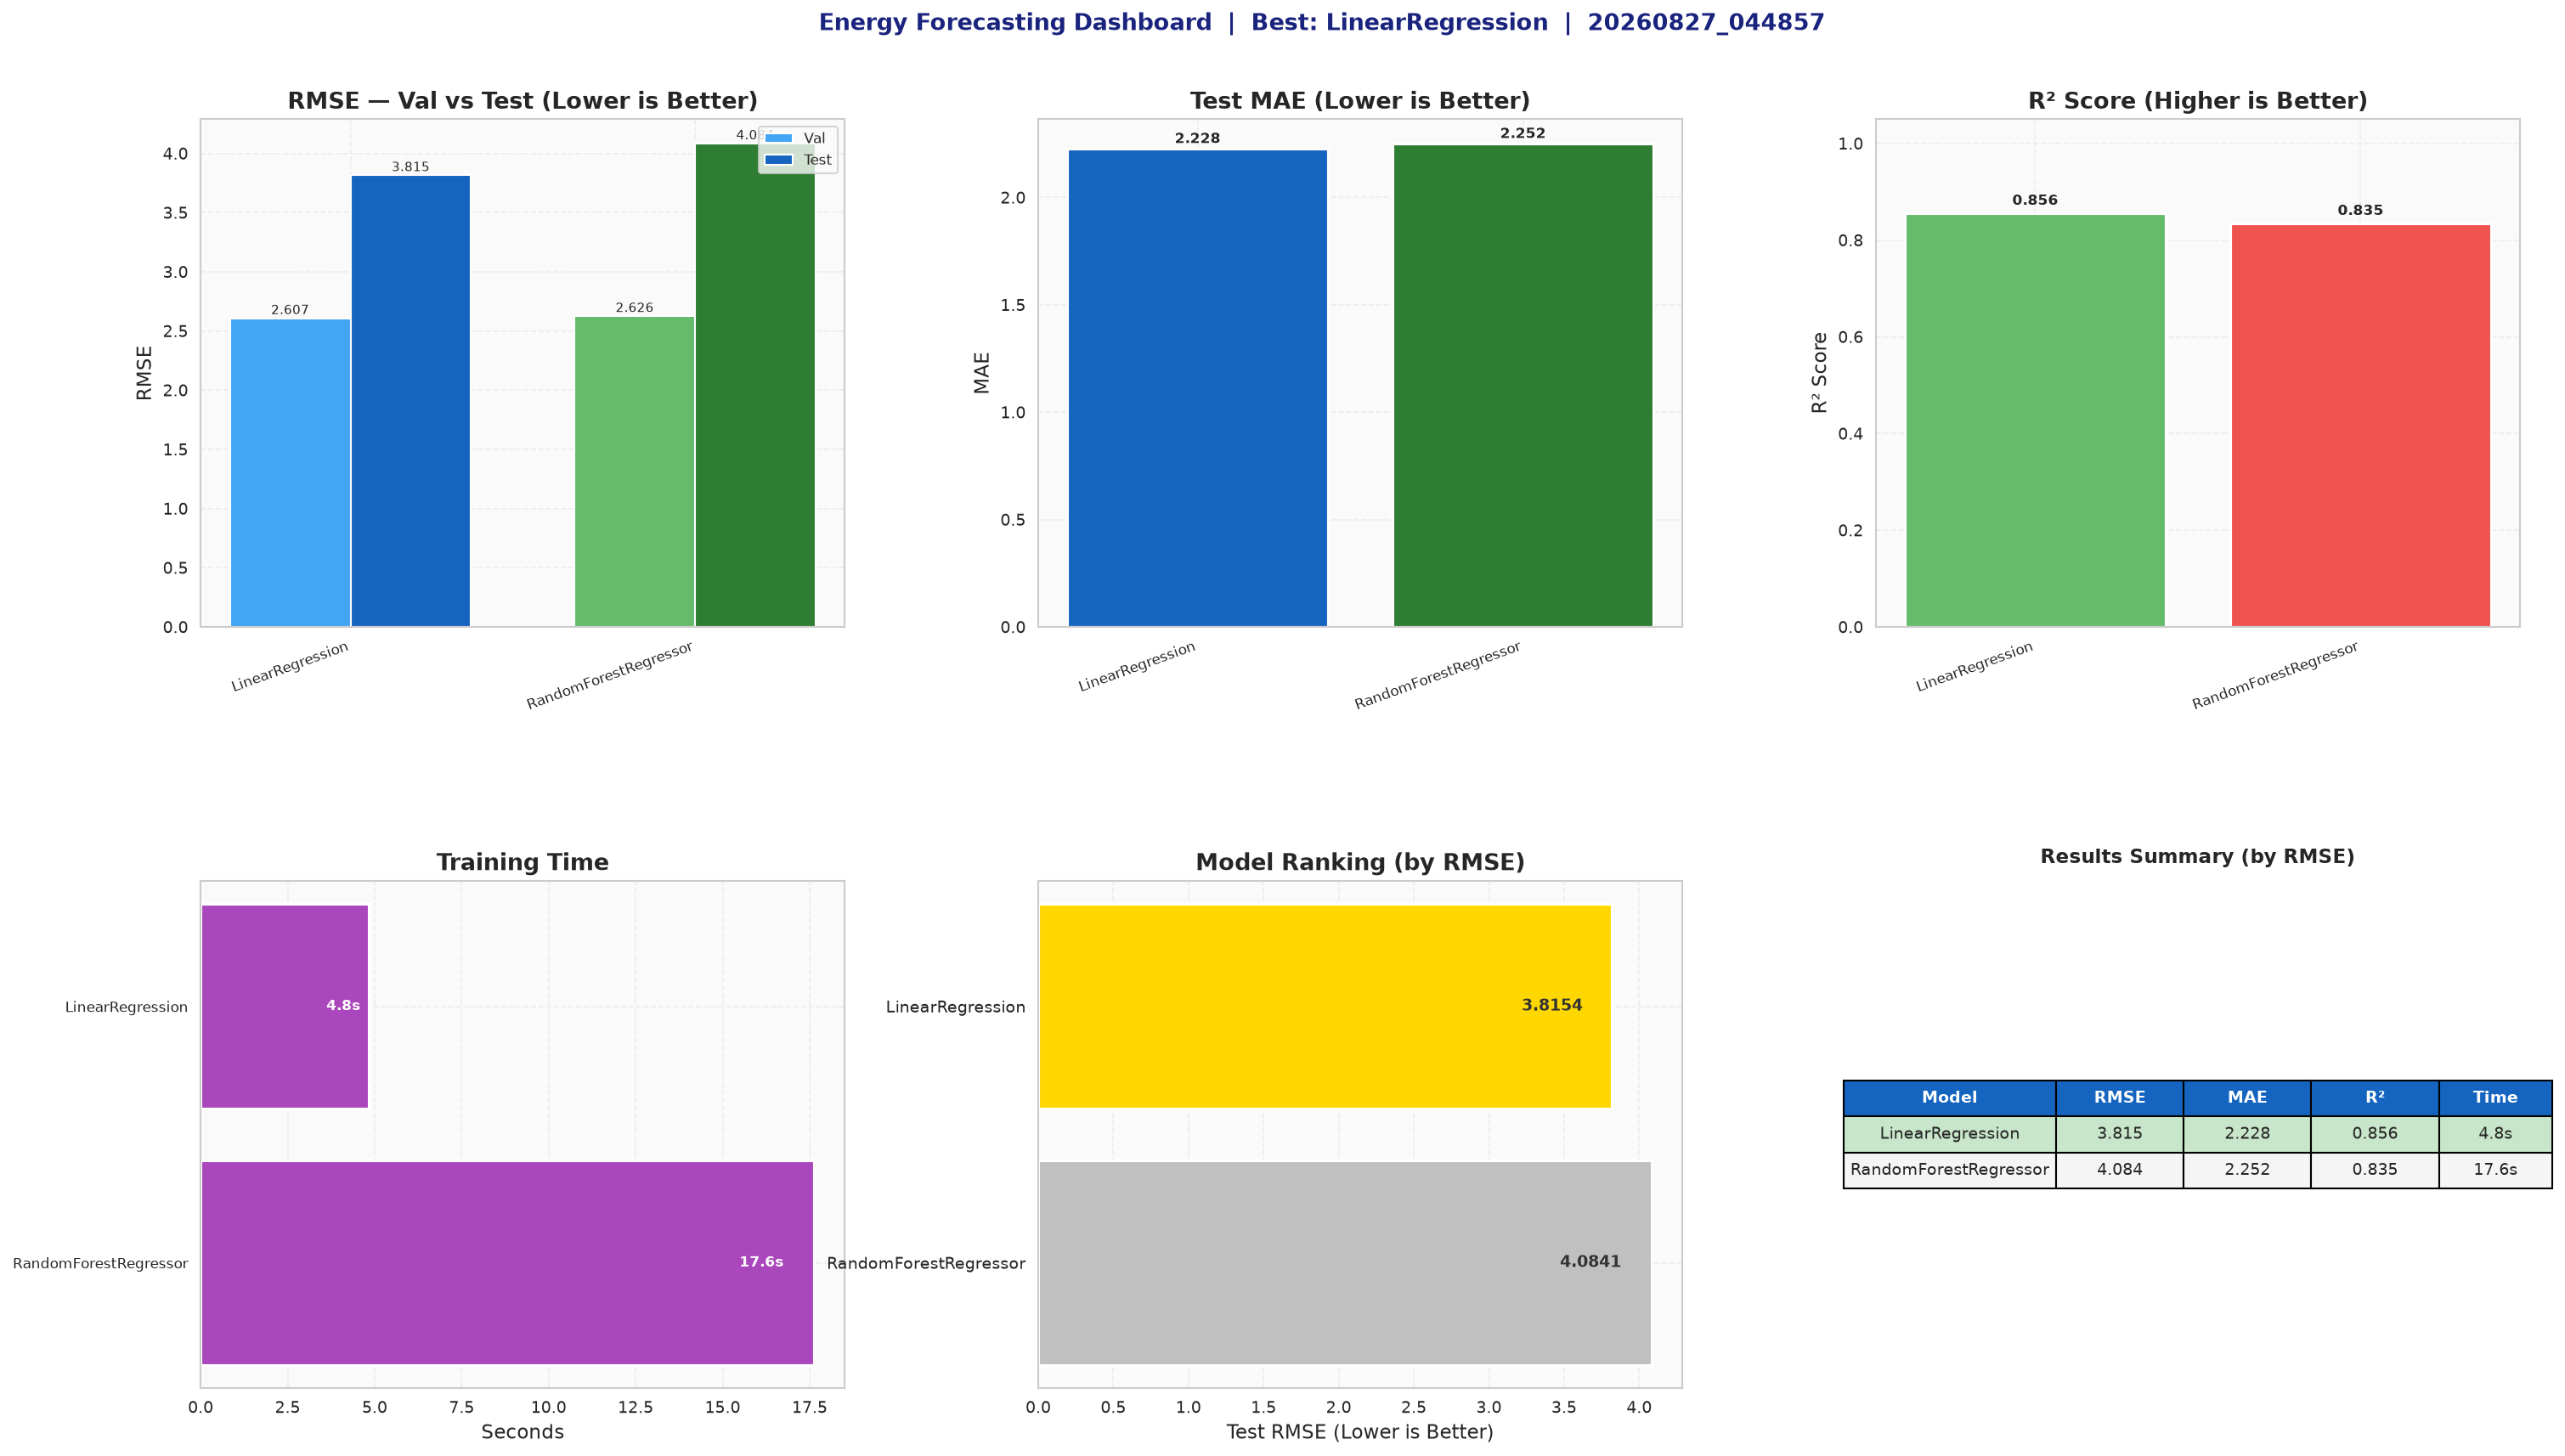

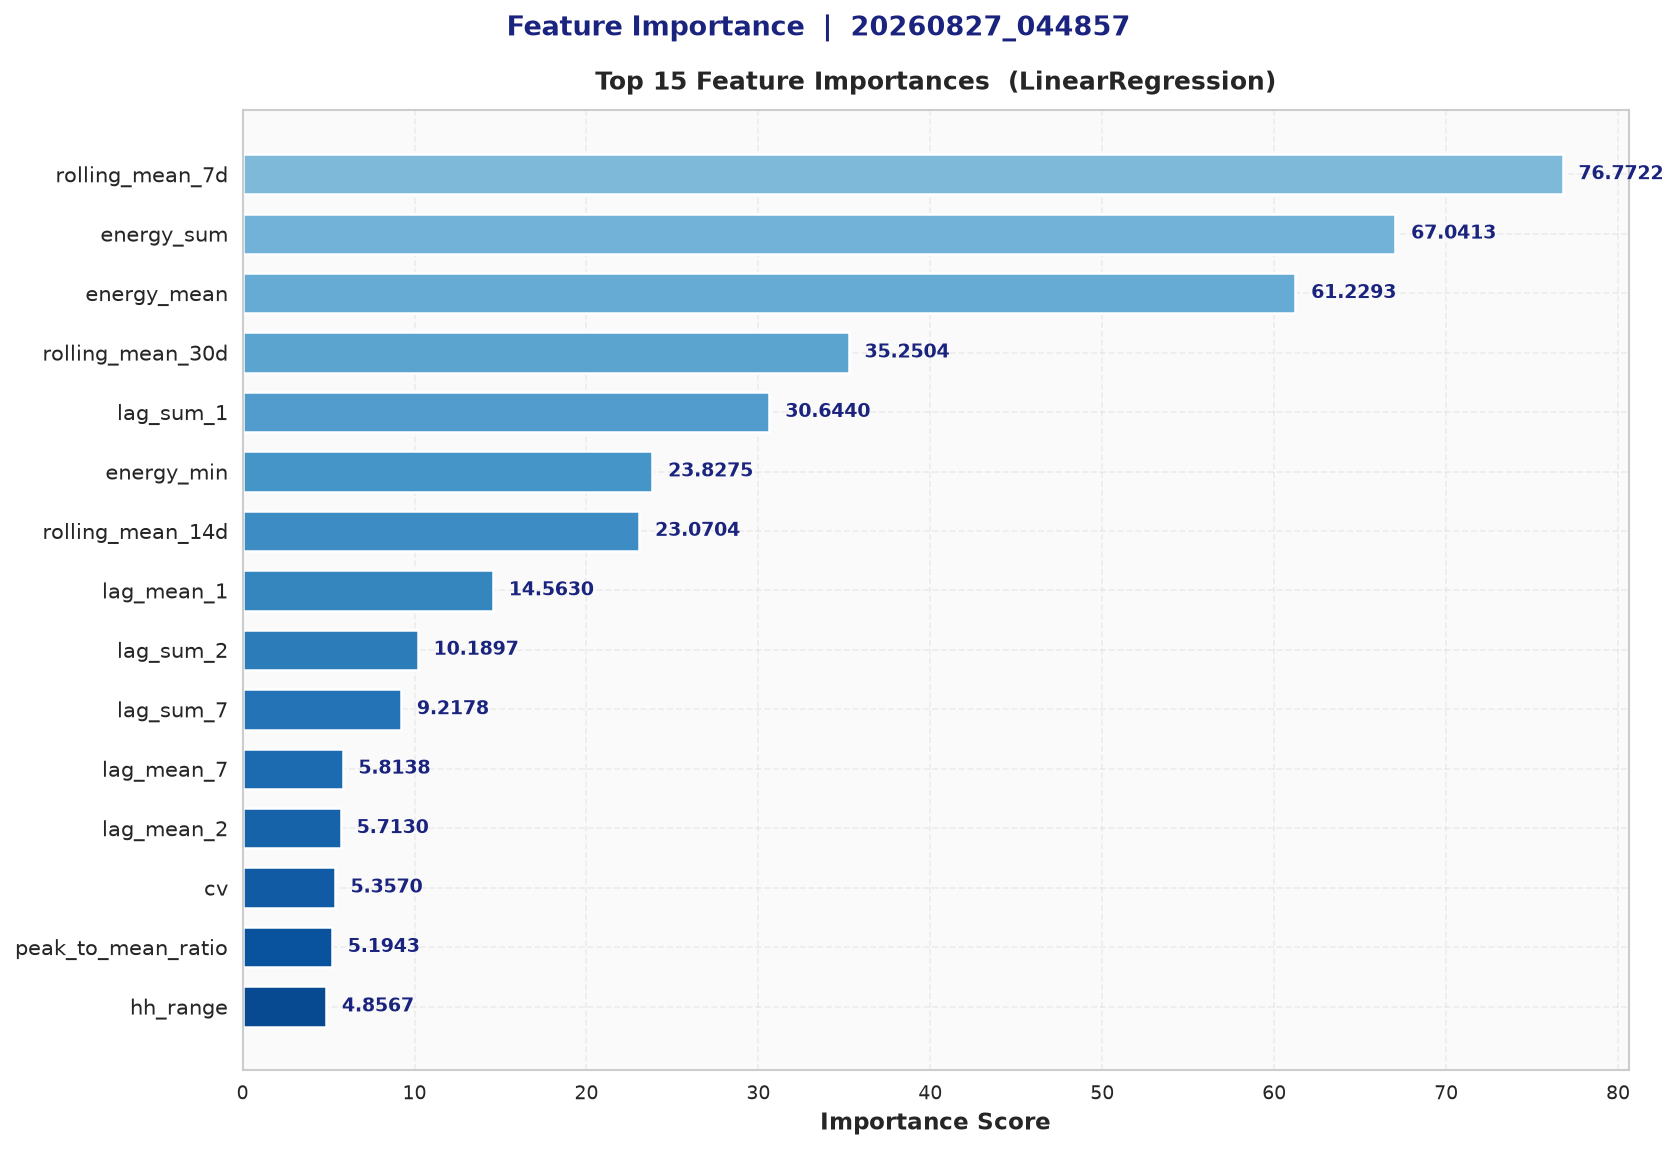

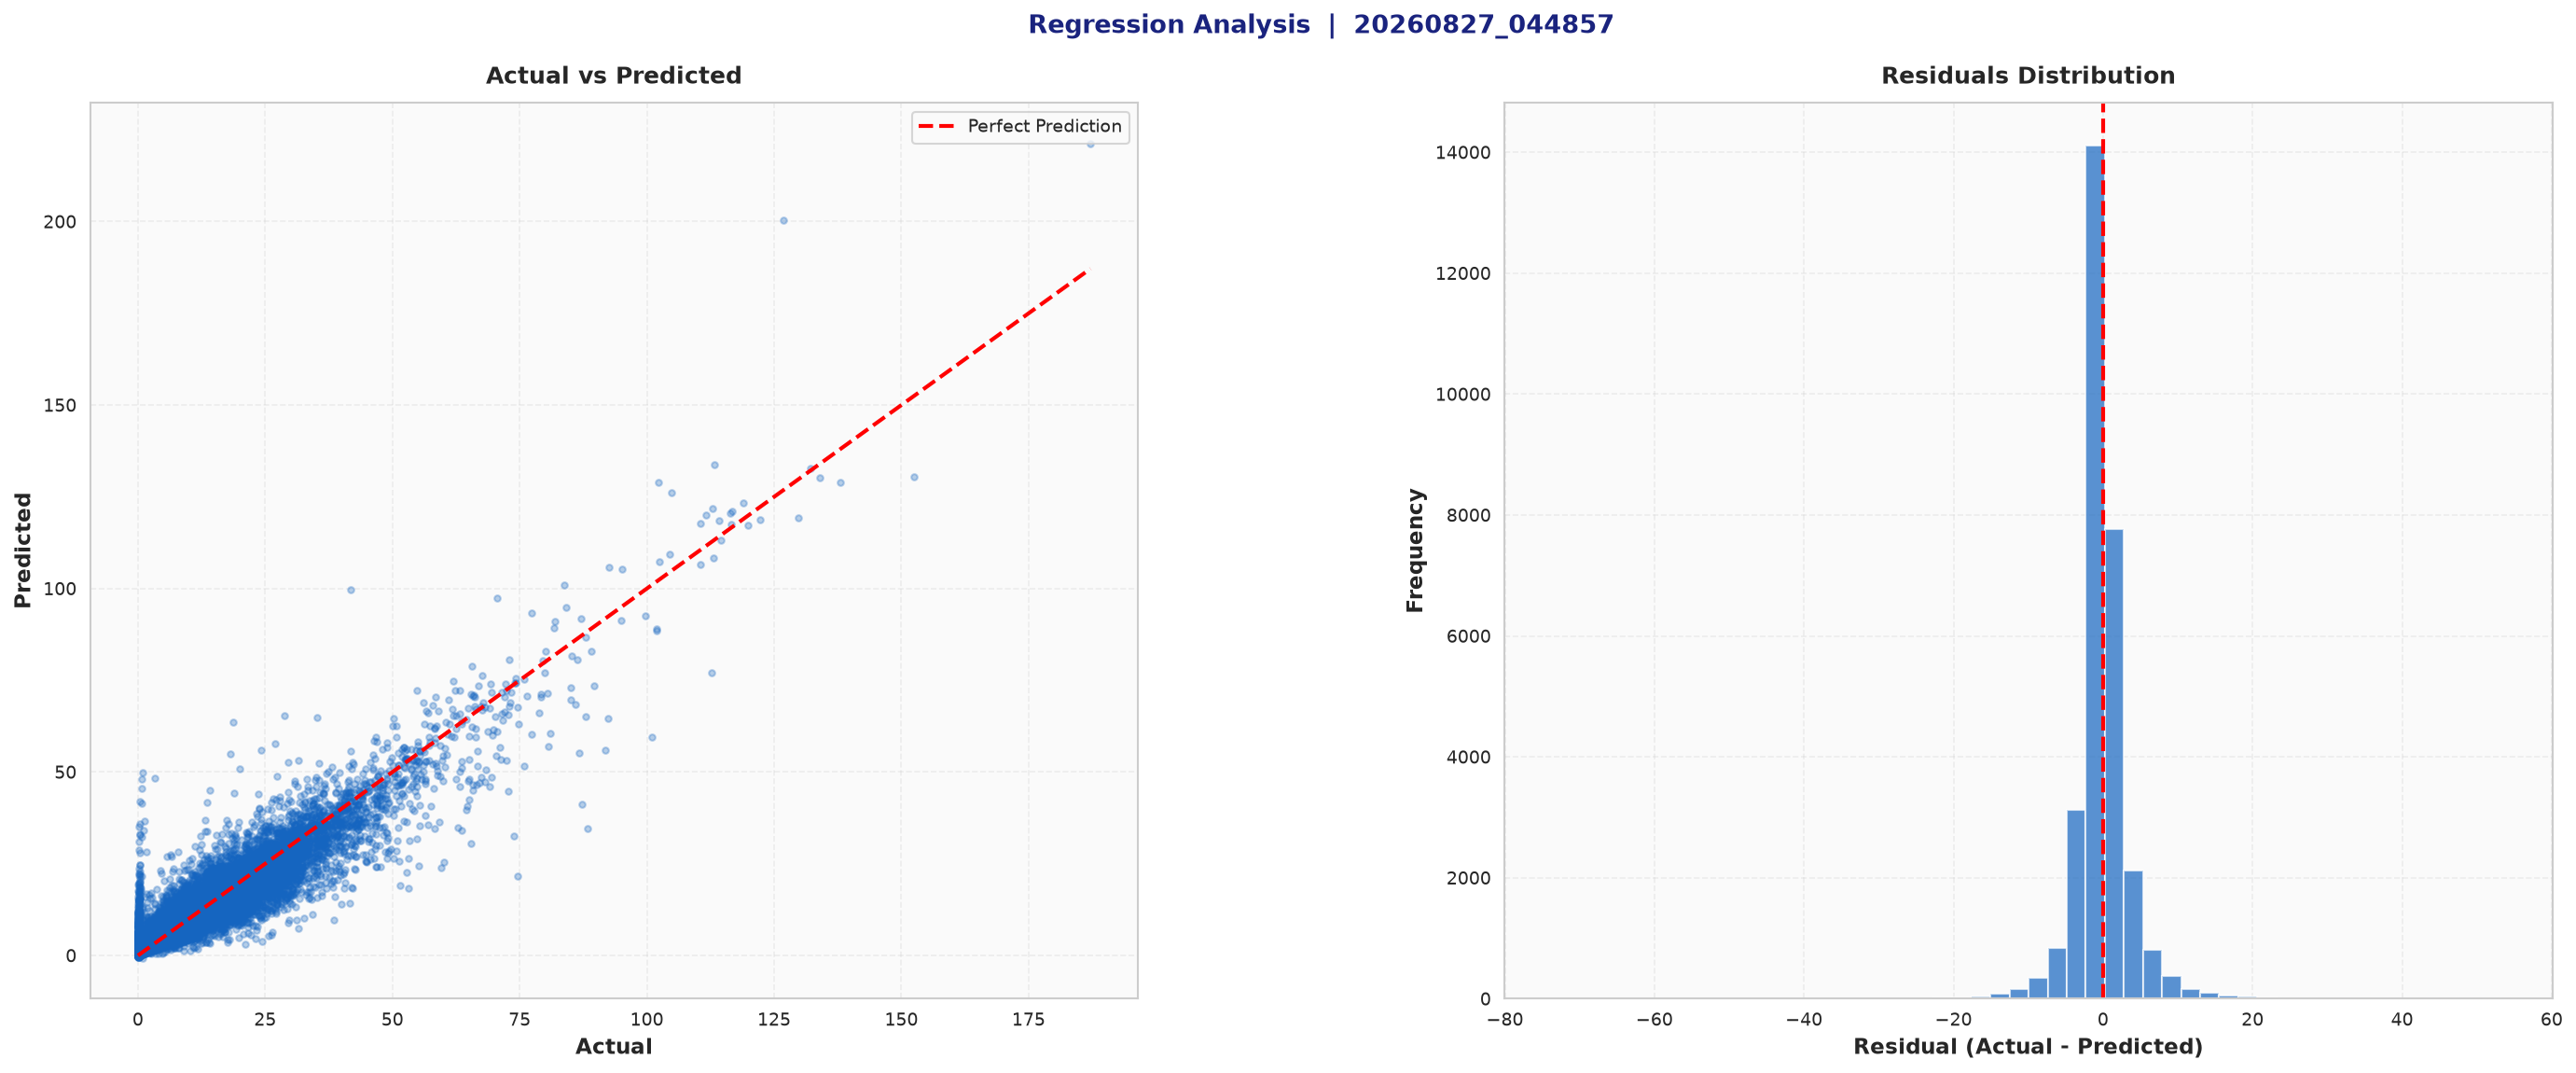


══════════════════════════════════════════════════════════════
  ✅ ENERGY FORECASTING  —  COMPLETE
──────────────────────────────────────────────────────────────
  🏆 Best model : LinearRegression
  📊 Test  RMSE : 3.8154
  📊 Test  MAE  : 2.2282
  📊 Test  R²   : 0.8561
  ⏱   Train time : 4.8 s
──────────────────────────────────────────────────────────────
  📁 Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 3
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 3/task03_forecast_20260827_044857.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 3/task03_forecast_20260827_044857.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 3/task03_forecast_20260827_044857.html

════════════════════════════════

In [13]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
import builtins
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import LinearSegmentedColormap
from datetime import timedelta
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 3')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: delete ALL previous outputs ONCE at startup ─────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

from pyspark.sql.functions import col, desc, count, when, lit, rand, isnan, lead, expr, min as spark_min, max as spark_max, ntile
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from functools import reduce
from operator import and_

# ── Matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.linestyle': '--', 'axes.labelsize': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.facecolor': '#fafafa', 'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.linewidth': 1.0,
})
_cmap = LinearSegmentedColormap.from_list("blues", ["#e3f2fd", "#1565c0", "#0d47a1"])

timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"ENERGY FORECASTING  |  {timestamp}", "📈")

# ════════════════════════════════════════════════════════════
# [1/8] Create target variable
# ════════════════════════════════════════════════════════════
_sec('1/8', 'Creating target variable', '🔧')
daily_clean.createOrReplaceTempView("_daily_clean_view")
forecast_data = spark.sql("""
    SELECT *,
           lead(energy_sum, 1) OVER (PARTITION BY LCLid ORDER BY day)
               AS target_next_day_sum
    FROM _daily_clean_view
""")
_ok("target_next_day_sum created")

# ════════════════════════════════════════════════════════════
# [2/8] Feature list
# ════════════════════════════════════════════════════════════
_sec('2/8', 'Building feature list', '🔧')
_base_feats = [
    "energy_mean", "energy_max", "energy_std", "energy_sum", "energy_min", "energy_median",
    "cv", "peak_to_mean_ratio", "load_factor",
    "lag_mean_1", "lag_mean_2", "lag_mean_3", "lag_mean_7",
    "lag_sum_1", "lag_sum_2", "lag_sum_7",
    "lag_max_1", "lag_max_7",
    "rolling_mean_7d", "rolling_std_7d", "rolling_mean_14d", "rolling_mean_30d",
    "month", "day_of_week", "is_weekend", "is_holiday", "season", "quarter",
    "temperatureMax", "temperatureMin", "temperatureHigh", "temperatureLow",
    "humidity", "windSpeed", "windBearing", "cloudCover", "pressure", "dewPoint"
]
_hh_feats = [
    "peak_hour_avg", "offpeak_night_avg", "daytime_avg", "morning_peak_avg",
    "night_ratio", "peak_to_offpeak_ratio", "hh_stddev", "hh_range"
]
forecast_feature_cols = [c for c in _base_feats + _hh_feats if c in forecast_data.columns]
print(f"        • Features: {len(forecast_feature_cols)} columns")

# ════════════════════════════════════════════════════════════
# [3/8] Prepare dataset
# ════════════════════════════════════════════════════════════
_sec('3/8', 'Preparing dataset', '📋')
_sel_cols = ["LCLid", "day", "target_next_day_sum"] + [c for c in ["stdorToU"] if c in forecast_data.columns] + forecast_feature_cols
_sel_cols = list(dict.fromkeys(_sel_cols))

_null_filter = "target_next_day_sum IS NOT NULL"
if forecast_feature_cols:
    _null_filter += " AND " + " AND ".join([f"`{c}` IS NOT NULL" for c in forecast_feature_cols])

forecast_data = (
    forecast_data
    .select(*_sel_cols)
    .filter(_null_filter)
    .cache()
)
_total = forecast_data.count()
print(f"        • Records: {_total:,}")
_prev_cols = [c for c in ["LCLid", "day", "energy_sum", "target_next_day_sum"] if c in forecast_data.columns]
print("        • Sample records:")
for _r in forecast_data.select(_prev_cols).limit(5).collect():
    _s = f"{_r.energy_sum:.3f}" if hasattr(_r, "energy_sum") and _r.energy_sum is not None else "-"
    _t = f"{_r.target_next_day_sum:.3f}" if hasattr(_r, "target_next_day_sum") and _r.target_next_day_sum is not None else "-"
    print(f"          - {_r.LCLid:<10} | {str(_r.day)[:10]} | sum={_s:>6} kWh | target={_t:>6} kWh")

# ════════════════════════════════════════════════════════════
# [4/8] Create consumption level labels (for reference)
# ════════════════════════════════════════════════════════════
_sec('4/8', 'Creating consumption level labels', '🎯')
_q = forecast_data.approxQuantile("target_next_day_sum", [0.333, 0.667], 0.01)
_q1, _q2 = _q[0], _q[1]
forecast_data = forecast_data.selectExpr(
    "*",
    f"CASE WHEN target_next_day_sum <= {_q1} THEN 'Low' WHEN target_next_day_sum <= {_q2} THEN 'Medium' ELSE 'High' END AS consumption_level"
)
for r in sorted(forecast_data.groupBy("consumption_level").count().collect(), key=lambda x: x[0]):
    print(f"        • {r.consumption_level}: {r['count']:,}")

# ════════════════════════════════════════════════════════════
# [5/8] Encode labels
# ════════════════════════════════════════════════════════════
_sec('5/8', 'Encoding labels', '🔖')
level_indexer = StringIndexer(inputCol="consumption_level", outputCol="level_label", handleInvalid="error").fit(forecast_data)
forecast_data = level_indexer.transform(forecast_data)
n_classes = len(level_indexer.labels)
print(f"  Classes: {n_classes}")
for i, lbl in enumerate(level_indexer.labels):
    print(f"  {i} → {lbl}")

# ════════════════════════════════════════════════════════════
# [6/8] Date-based split (70/15/15)
# ════════════════════════════════════════════════════════════
_sec('6/8', 'Date-based split (70/15/15)', '📅')
_date_range = forecast_data.select(spark_min("day"), spark_max("day")).collect()[0]
_min_date, _max_date = _date_range[0], _date_range[1]
_total_days = (_max_date - _min_date).days
_split_1 = _min_date + timedelta(days=int(_total_days * 0.70))
_split_2 = _min_date + timedelta(days=int(_total_days * 0.85))
print(f"        • Date Range: {_min_date} → {_max_date}")
print(f"        • Train (70%): {_min_date} → {_split_1}")
print(f"        • Val   (15%): {_split_1} → {_split_2}")
print(f"        • Test  (15%): {_split_2} → {_max_date}")

train_forecast = forecast_data.filter(f"day < '{_split_1}'").cache()
val_forecast   = forecast_data.filter(f"day >= '{_split_1}' AND day < '{_split_2}'").cache()
test_forecast  = forecast_data.filter(f"day >= '{_split_2}'").cache()

train_n = train_forecast.count(); val_n = val_forecast.count(); test_n = test_forecast.count()
_tot_split = train_n + val_n + test_n
print(f"        • Train: {train_n:,} ({train_n/_tot_split*100:.1f}%)")
print(f"        • Val:   {val_n:,} ({val_n/_tot_split*100:.1f}%)")
print(f"        • Test:  {test_n:,} ({test_n/_tot_split*100:.1f}%)")
print(f"        • Total: {_tot_split:,}")

# ════════════════════════════════════════════════════════════
# [7/8] Sampling for speed
# ════════════════════════════════════════════════════════════
_sec('7/8', 'Sampling for speed', '⚡')
_MAX_TRAIN, _MAX_VAL, _MAX_TEST = 100000, 30000, 30000

if train_n > _MAX_TRAIN:
    train_forecast = train_forecast.sample(False, _MAX_TRAIN/train_n, seed=42).cache()
    train_n = train_forecast.count()

if val_n > _MAX_VAL:
    val_forecast = val_forecast.sample(False, _MAX_VAL/val_n, seed=42).cache()
    val_n = val_forecast.count()

if test_n > _MAX_TEST:
    test_forecast = test_forecast.sample(False, _MAX_TEST/test_n, seed=42).cache()
    test_n = test_forecast.count()

_total_n = train_n + val_n + test_n
print(f"        • Train: {train_n:,} ({train_n/_total_n*100:.1f}%)")
print(f"        • Val:   {val_n:,} ({val_n/_total_n*100:.1f}%)")
print(f"        • Test:  {test_n:,} ({test_n/_total_n*100:.1f}%)")
print(f"        • Total: {_total_n:,}")

# ════════════════════════════════════════════════════════════
# [8/8] Feature pipeline
# ════════════════════════════════════════════════════════════
_sec('8/8', 'Feature pipeline', '🔧')
_assembler = VectorAssembler(inputCols=forecast_feature_cols, outputCol="features_raw", handleInvalid="skip")
_scaler = MinMaxScaler(inputCol="features_raw", outputCol="features")
n_features = len(forecast_feature_cols)
print(f"        • Features: {n_features} | Scaler: MinMaxScaler [0, 1]")

# ════════════════════════════════════════════════════════════
# TRAINING
# ════════════════════════════════════════════════════════════
_hdr("TRAINING MODELS", "🚀")

_MODELS = {
    "LinearRegression": LinearRegression(
        featuresCol="features", labelCol="target_next_day_sum",
        maxIter=20, regParam=0.01, elasticNetParam=0.0, tol=1e-3),
    "RandomForestRegressor": RandomForestRegressor(
        featuresCol="features", labelCol="target_next_day_sum",
        numTrees=15, maxDepth=8, maxBins=32, seed=42, subsamplingRate=0.8),
}

_eval_rmse = RegressionEvaluator(labelCol="target_next_day_sum", predictionCol="prediction", metricName="rmse")
_eval_mae = RegressionEvaluator(labelCol="target_next_day_sum", predictionCol="prediction", metricName="mae")
_eval_r2 = RegressionEvaluator(labelCol="target_next_day_sum", predictionCol="prediction", metricName="r2")

results = {}
for _name, _mdl in _MODELS.items():
    print(f"\n    ▶ {_name}")
    print(f"      {'─'*46}")
    _pipe = Pipeline(stages=[_assembler, _scaler, _mdl])
    _t0 = time.time()
    try:
        _fit = _pipe.fit(train_forecast)
        _t = time.time() - _t0
        _vp = _fit.transform(val_forecast)
        _tp = _fit.transform(test_forecast)
        _vrmse = _eval_rmse.evaluate(_vp)
        _trmse = _eval_rmse.evaluate(_tp)
        _tmae = _eval_mae.evaluate(_tp)
        _tr2 = _eval_r2.evaluate(_tp)
        results[_name] = dict(
            val_rmse=_vrmse, test_rmse=_trmse, test_mae=_tmae, test_r2=_tr2,
            time=_t, model=_fit, test_preds=_tp, status="✅")
        print(f"      ⏱ {_t:5.1f}s | ValRMSE={_vrmse:.4f} TestRMSE={_trmse:.4f} MAE={_tmae:.4f} R²={_tr2:.4f}")
    except Exception as _ex:
        print(f"     ❌ {str(_ex)[:110]}")
        results[_name] = {"status": f"❌ {str(_ex)[:110]}"}

_hdr("MODEL COMPARISON", "📊")
ok = {k: v for k, v in results.items() if v.get("status", "").startswith("✅")}
if not ok:
    raise RuntimeError("No model succeeded — cannot continue")

sorted_models = sorted(ok.items(), key=lambda x: x[1]['test_rmse'])
sorted_names = [m for m, _ in sorted_models]
best = sorted_names[0]

_comp = pd.DataFrame([
    dict(Model=m, ValRMSE=f"{r['val_rmse']:.4f}", TestRMSE=f"{r['test_rmse']:.4f}",
         MAE=f"{r['test_mae']:.4f}", R2=f"{r['test_r2']:.4f}", Time=f"{r['time']:.1f}s")
    for m, r in sorted_models])
print("\n" + _comp.to_string(index=False))
print(f"\n  🏆 BEST: {C.BOLD}{best}{C.END}  "
      f"RMSE={ok[best]['test_rmse']:.4f}  R²={ok[best]['test_r2']:.4f}")

# ════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
_hdr("FEATURE IMPORTANCE", "🔍")
feat_imp = []
_source_model = best
_fs = ok[best]["model"].stages[-1] if hasattr(ok[best]["model"], 'stages') else None

if _fs and hasattr(_fs, 'featureImportances'):
    feat_imp = sorted(zip(forecast_feature_cols, _fs.featureImportances.toArray()), key=lambda x: -x[1])
    _ok(f"From best model: {best}")
elif _fs and hasattr(_fs, 'coefficients'):
    _coeffs = np.abs(_fs.coefficients.toArray())
    feat_imp = sorted(zip(forecast_feature_cols, _coeffs), key=lambda x: -x[1])
    _ok(f"Using coefficient magnitudes from {best}")
elif "RandomForestRegressor" in ok:
    _rf = ok["RandomForestRegressor"]["model"].stages[-1]
    if hasattr(_rf, 'featureImportances'):
        feat_imp = sorted(zip(forecast_feature_cols, _rf.featureImportances.toArray()), key=lambda x: -x[1])
        _source_model = "RandomForestRegressor"
        _ok("Using RandomForestRegressor as fallback")

if feat_imp:
    print(f"\n  Source: {_source_model}")
    print("  Top 15:")
    for _i, (f, v) in enumerate(feat_imp[:15], 1):
        _bar = "█" * int(v * 100 / feat_imp[0][1])
        print(f"  {_i:2d}. {f:<28} {v:.4f} {_bar}")
else:
    _warn("Feature importance not available")

# ════════════════════════════════════════════════════════════
# ACTUAL VS PREDICTED DATA
# ════════════════════════════════════════════════════════════
_bpreds = ok[best]["test_preds"]
_preds_pdf = _bpreds.select("target_next_day_sum", "prediction").toPandas()

# ════════════════════════════════════════════════════════════
# BUILD VISUALISATIONS
# ════════════════════════════════════════════════════════════
_hdr("BUILDING VISUALISATIONS", "🎨")

_nm = len(sorted_names)
_x = np.arange(_nm)
_w = 0.35
_COLS = ['#1565c0', '#2e7d32'][:_nm]
_COLS2 = ['#42a5f5', '#66bb6a'][:_nm]

# ════════════════════════════════════════════════════════════
# FIGURE 1: Dashboard (display only - not saved)
# ════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(20, 12), facecolor='white')
_dg = mgridspec.GridSpec(2, 3, figure=fig1,
                          hspace=0.50, wspace=0.30,
                          left=0.06, right=0.97,
                          top=0.91, bottom=0.08)

_da1 = fig1.add_subplot(_dg[0, 0])
_da2 = fig1.add_subplot(_dg[0, 1])
_da3 = fig1.add_subplot(_dg[0, 2])
_da4 = fig1.add_subplot(_dg[1, 0])
_da5 = fig1.add_subplot(_dg[1, 1])
_da6 = fig1.add_subplot(_dg[1, 2])

# RMSE Val vs Test
_b1 = _da1.bar(_x - _w/2, [ok[n]['val_rmse'] for n in sorted_names], _w,
               label='Val', color=_COLS2, edgecolor='white', lw=1)
_b2 = _da1.bar(_x + _w/2, [ok[n]['test_rmse'] for n in sorted_names], _w,
               label='Test', color=_COLS, edgecolor='white', lw=1)
_da1.set_ylabel('RMSE'); _da1.set_title('RMSE — Val vs Test (Lower is Better)')
_da1.set_xticks(_x); _da1.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
for _b in list(_b1) + list(_b2):
    _da1.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=7)
_da1.legend(fontsize=8, loc='upper right')

# MAE
_bs = _da2.bar(sorted_names, [ok[n]['test_mae'] for n in sorted_names],
               color=_COLS, edgecolor='white', lw=1.5)
_da2.set_ylabel('MAE'); _da2.set_title('Test MAE (Lower is Better)')
_da2.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
for _b in _bs:
    _da2.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# R²
_bsr = _da3.bar(sorted_names, [ok[n]['test_r2'] for n in sorted_names],
                color=['#66bb6a', '#ef5350'][:_nm], edgecolor='white', lw=1.5)
_da3.set_ylabel('R² Score'); _da3.set_title('R² Score (Higher is Better)')
_da3.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da3.set_ylim(0, 1.05)
for _b in _bsr:
    _da3.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Training Time — FIXED: white text INSIDE bar
_bh = _da4.barh(sorted_names, [ok[n]['time'] for n in sorted_names],
                color='#ab47bc', edgecolor='white', lw=1.5)
_da4.set_xlabel('Seconds'); _da4.set_title('Training Time')
_da4.invert_yaxis(); _da4.set_yticklabels(sorted_names, fontsize=8)
for _b in _bh:
    _w_val = _b.get_width()
    _da4.text(_w_val - _w_val*0.05, _b.get_y() + _b.get_height()/2,
              f'{_w_val:.1f}s', va='center', ha='right', fontsize=8,
              fontweight='bold', color='white')

# Model Ranking by RMSE — FIXED: dark text INSIDE bar
_rank_names = [s[0] for s in sorted_models]
_rank_scores = [s[1]['test_rmse'] for s in sorted_models]
_rank_colors = ['#FFD700', '#C0C0C0'][:len(_rank_names)]
_br = _da5.barh(_rank_names[::-1], _rank_scores[::-1], color=_rank_colors[::-1],
                edgecolor='white', lw=1.5)
_da5.set_xlabel('Test RMSE (Lower is Better)'); _da5.set_title('Model Ranking (by RMSE)')
for _i, _b in enumerate(_br):
    _w_val = _b.get_width()
    _da5.text(_w_val - _w_val*0.05, _b.get_y() + _b.get_height()/2,
              f'{_w_val:.4f}', va='center', ha='right', fontsize=9,
              fontweight='bold', color='#333333')

# Results table
_da6.axis('off')
_td = [[m, f"{r['test_rmse']:.3f}", f"{r['test_mae']:.3f}", f"{r['test_r2']:.3f}", f"{r['time']:.1f}s"]
       for m, r in sorted_models]
_tbl = _da6.table(cellText=_td, colLabels=['Model', 'RMSE', 'MAE', 'R²', 'Time'],
                  cellLoc='center', loc='center',
                  colColours=['#1565c0']*5, colWidths=[0.30, 0.18, 0.18, 0.18, 0.16])
_tbl.auto_set_font_size(False); _tbl.set_fontsize(9); _tbl.scale(1.1, 1.7)
for _j in range(5):
    _tbl[(0, _j)].set_text_props(color='white', fontweight='bold')
for _i in range(1, len(_td)+1):
    for _j in range(5):
        _tbl[(_i, _j)].set_facecolor('#c8e6c9' if _td[_i-1][0] == best
                                     else ('#f5f5f5' if _i % 2 == 0 else 'white'))
_da6.set_title('Results Summary (by RMSE)', fontweight='bold', pad=10, fontsize=11)

fig1.suptitle(f'Energy Forecasting Dashboard  |  Best: {best}  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 2: Feature Importance (display only - not saved)
# ════════════════════════════════════════════════════════════
fig2, _fl = plt.subplots(1, 1, figsize=(12, 8), facecolor='white',
    gridspec_kw={'left': 0.18, 'right': 0.95, 'top': 0.90, 'bottom': 0.10})

if feat_imp:
    _fn15 = [f[0] for f in feat_imp[:15]]; _fv15 = [f[1] for f in feat_imp[:15]]
    _grad = plt.cm.Blues(np.linspace(0.45, 0.90, len(_fn15)))
    _fl.barh(range(len(_fn15)), _fv15, color=_grad, edgecolor='white', linewidth=1.2, height=0.68)
    _fl.set_yticks(range(len(_fn15))); _fl.set_yticklabels(_fn15, fontsize=10)
    _fl.invert_yaxis()
    _fl.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
    _fl.set_title(f'Top 15 Feature Importances  ({_source_model})', fontsize=12, fontweight='bold', pad=10)
    _fl.grid(axis='x', alpha=0.3, linestyle='--')
    _mx = float(np.max(_fv15)) if _fv15 else 1.0
    for _i, _v in enumerate(_fv15):
        _fl.text(_v + _mx*0.012, _i, f'{_v:.4f}', va='center', fontsize=9, fontweight='bold', color='#1a237e')
else:
    _fl.text(0.5, 0.5, 'Feature importances not available', ha='center', va='center', fontsize=12, color='grey')
    _fl.axis('off')

fig2.suptitle(f'Feature Importance  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 3: Actual vs Predicted (display only - not saved)
# ════════════════════════════════════════════════════════════
fig3, (_fa, _fr) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white',
    gridspec_kw={'wspace': 0.35, 'left': 0.06, 'right': 0.94, 'top': 0.90, 'bottom': 0.10})

_min_val = _preds_pdf['target_next_day_sum'].min()
_max_val = _preds_pdf['target_next_day_sum'].max()

# Left: Scatter
_fa.scatter(_preds_pdf['target_next_day_sum'], _preds_pdf['prediction'],
            alpha=0.3, s=10, color='#1565c0')
_fa.plot([_min_val, _max_val], [_min_val, _max_val], 'r--', lw=2, label='Perfect Prediction')
_fa.set_xlabel('Actual', fontweight='bold'); _fa.set_ylabel('Predicted', fontweight='bold')
_fa.set_title('Actual vs Predicted', fontweight='bold', fontsize=12, pad=10)
_fa.legend(fontsize=9)

# Right: Residuals
_residuals = _preds_pdf['target_next_day_sum'] - _preds_pdf['prediction']
_fr.hist(_residuals, bins=50, color='#1565c0', edgecolor='white', alpha=0.7)
_fr.axvline(x=0, color='red', linestyle='--', lw=2)
_fr.set_xlabel('Residual (Actual - Predicted)', fontweight='bold')
_fr.set_ylabel('Frequency', fontweight='bold')
_fr.set_title('Residuals Distribution', fontweight='bold', fontsize=12, pad=10)

fig3.suptitle(f'Regression Analysis  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# SAVE COMBINED PNG
# ════════════════════════════════════════════════════════════
import matplotlib.image as _mimg
import io as _io

def _fig_to_arr(f):
    _buf = _io.BytesIO()
    f.savefig(_buf, dpi=200, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    return _mimg.imread(_buf)

_arr1 = _fig_to_arr(fig1)
_arr2 = _fig_to_arr(fig2)
_arr3 = _fig_to_arr(fig3)

plt.close(fig1); plt.close(fig2); plt.close(fig3)

_h1, _w1 = _arr1.shape[:2]
_h2, _w2 = _arr2.shape[:2]
_h3, _w3 = _arr3.shape[:2]
_W = builtins.max(_w1, _w2, _w3)

# Add 80px padding between figures to prevent any overlap
_total_h = _h1 + _h2 + _h3 + 160
_merged = np.ones((_total_h, _W, 4), dtype=np.float32)

_y = 0
_merged[_y:_y+_h1, :_w1] = _arr1
_y += _h1 + 80
_merged[_y:_y+_h2, :_w2] = _arr2
_y += _h2 + 80
_merged[_y:_y+_h3, :_w3] = _arr3

_final_png = f'{output_dir}/task03_forecast_{timestamp}.png'
_mfig, _max = plt.subplots(figsize=(_W/200, _total_h/200), facecolor='white',
    gridspec_kw={'left': 0, 'right': 1, 'top': 1, 'bottom': 0})
_max.imshow(_merged, interpolation='lanczos')
_max.axis('off')
_mfig.savefig(_final_png, dpi=200, bbox_inches='tight',
              facecolor='white', edgecolor='none', pad_inches=0.02)
plt.close(_mfig)

# ════════════════════════════════════════════════════════════
# BUILD FINAL CSV
# ════════════════════════════════════════════════════════════
total_n = train_n + val_n + test_n
train_pct = train_n / total_n * 100 if total_n else 0
val_pct = val_n / total_n * 100 if total_n else 0
test_pct = test_n / total_n * 100 if total_n else 0

_final_csv = f'{output_dir}/task03_forecast_{timestamp}.csv'
_lines = []

_lines += [
    "ENERGY FORECASTING REPORT",
    f"Generated,{timestamp}",
    f"Best Model,{best}",
    f"Test RMSE,{ok[best]['test_rmse']:.4f}",
    f"Test MAE,{ok[best]['test_mae']:.4f}",
    f"Test R2,{ok[best]['test_r2']:.4f}",
    "",
    "── SECTION 1: MODEL COMPARISON ──────────────────────────────",
    "Model,Val_RMSE,Test_RMSE,MAE,R2,Time_s,Best",
]
for _m, _r in sorted_models:
    _lines.append(
        f"{_m},{_r['val_rmse']:.4f},{_r['test_rmse']:.4f},"
        f"{_r['test_mae']:.4f},{_r['test_r2']:.4f},{_r['time']:.1f},"
        f"{'YES' if _m == best else ''}")

_lines += [
    "",
    "── SECTION 2: FEATURE IMPORTANCE ──────────────────────────────",
    "Rank,Feature,Importance",
]
for _i, (_f, _v) in enumerate(feat_imp if feat_imp else [('N/A', 0)], 1):
    _lines.append(f"{_i},{_f},{_v:.6f}")

_lines += [
    "",
    "── SECTION 3: RESIDUALS SUMMARY ──────────────────────────────",
    "Metric,Value",
    f"Mean Residual,{_residuals.mean():.4f}",
    f"Std Residual,{_residuals.std():.4f}",
    f"Min Residual,{_residuals.min():.4f}",
    f"Max Residual,{_residuals.max():.4f}",
]

_lines += [
    "",
    "── SECTION 4: DATASET SUMMARY ──────────────────────────────",
    f"Total Records,{total_n}",
    f"Train,{train_n},{train_pct:.1f}%",
    f"Validation,{val_n},{val_pct:.1f}%",
    f"Test,{test_n},{test_pct:.1f}%",
    f"Features,{n_features}",
    f"Classes,{n_classes}",
]

with open(_final_csv, 'w', encoding='utf-8') as _fh:
    _fh.write('\n'.join(_lines))

# ════════════════════════════════════════════════════════════
# HTML REPORT
# ════════════════════════════════════════════════════════════

# model rows
_model_rows = ""
for _m, _r in sorted_models:
    _cls = "best-row" if _m == best else ""
    _trph = "🏆" if _m == best else ""
    _model_rows += f"""
        <tr class="{_cls}">
            <td><strong>{_m}</strong> {_trph}</td>
            <td>{_r['val_rmse']:.4f}</td><td>{_r['test_rmse']:.4f}</td>
            <td>{_r['test_mae']:.4f}</td><td>{_r['test_r2']:.4f}</td>
            <td>{_r['time']:.1f}</td>
        </tr>"""

# feature rows
_feat_rows = ""
for _i, (_f, _v) in enumerate(feat_imp[:10] if feat_imp else [], 1):
    _feat_rows += f"""
        <tr><td>{_i}</td><td><strong>{_f}</strong></td><td>{_v:.6f}</td></tr>"""

_br = ok[best]
_final_html = f'{output_dir}/task03_forecast_{timestamp}.html'
_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Forecast Report — {timestamp}</title>
<style>
:root{{--p:#bf360c;--pl:#e64a19;--ac:#ffab40;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(191,54,12,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>📈 Energy Forecasting Report</h1>
  <p>Next-day energy consumption prediction · Regression with PySpark ML</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best: {best}</span>
    <span class="bdg">📊 {n_features} Features</span>
    <span class="bdg">🗂️ {total_n:,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{_br['test_rmse']:.4f}</div><div class="kl">RMSE</div></div>
  <div class="kpi"><div class="kv">{_br['test_mae']:.4f}</div><div class="kl">MAE</div></div>
  <div class="kpi"><div class="kv">{_br['test_r2']:.4f}</div><div class="kl">R² Score</div></div>
  <div class="kpi"><div class="kv">{_residuals.mean():.4f}</div><div class="kl">Mean Residual</div></div>
  <div class="kpi"><div class="kv">{_residuals.std():.4f}</div><div class="kl">Std Residual</div></div>
  <div class="kpi"><div class="kv">{_br['time']:.1f}s</div><div class="kl">Train Time</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Model Comparison (Ranked by RMSE)</div>
  <div class="tw"><table>
    <thead><tr><th>Model</th><th>Val RMSE</th><th>Test RMSE</th><th>MAE</th>
    <th>R²</th><th>Time (s)</th></tr></thead>
    <tbody>{_model_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top 10 Important Features</div>
  <div class="tw"><table>
    <thead><tr><th>Rank</th><th>Feature</th><th>Importance</th></tr></thead>
    <tbody>{_feat_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Dataset Summary</div>
  <div class="tw"><table>
    <thead><tr><th>Split</th><th>Count</th><th>%</th></tr></thead>
    <tbody>
      <tr><td><strong>Train</strong></td><td>{train_n:,}</td><td>{train_pct:.1f}%</td></tr>
      <tr><td><strong>Val</strong></td><td>{val_n:,}</td><td>{val_pct:.1f}%</td></tr>
      <tr><td><strong>Test</strong></td><td>{test_n:,}</td><td>{test_pct:.1f}%</td></tr>
      <tr style="background:#e8eaf6;font-weight:700">
        <td>Total</td><td>{total_n:,}</td><td>100%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by Energy Forecasting Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

with open(_final_html, 'w', encoding='utf-8') as _fh:
    _fh.write(_html)

# ════════════════════════════════════════════════════════════
# SPARK CLEANUP
# ════════════════════════════════════════════════════════════
for _df in [forecast_data, train_forecast, val_forecast, test_forecast]:
    try: _df.unpersist()
    except: pass

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = '═'*62
_s2 = '─'*62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ ENERGY FORECASTING  —  COMPLETE
{_s2}
  🏆 Best model : {best}
  📊 Test  RMSE : {ok[best]['test_rmse']:.4f}
  📊 Test  MAE  : {ok[best]['test_mae']:.4f}
  📊 Test  R²   : {ok[best]['test_r2']:.4f}
  ⏱   Train time : {ok[best]['time']:.1f} s
{_s2}
  📁 Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")

### CELL 14: Task 4 - Peak Demand Prediction (Regression)
###### ================================================================================

###### Task 4: Predict daily peak electricity demand (energy_max) per household.
###### Models: RandomForestRegressor | GBTRegressor | LinearRegression
###### Metrics: RMSE, MAE, R²
###### Split:  80/10/10 Date-based (Train/Val/Test)
###### Scaler: StandardScaler (z-score normalization)
###### Output: Dashboard + Feature Importance + HTML Report + Saved Model



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
  ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  ⚡  PEAK DEMAND PREDICTION  |  20260827_045011
══════════════════════════════════════════════════════════════

  [1/7] 🔧 Preparing peak demand dataset
  Records: 3,517,032  |  Features: 39

  [2/7] 📅 Date-based split (80/10/10)
  Date range: 2011-11-23 → 2014-02-28
  Train:  2011-11-23 → 2013-09-15  (80%)
  Val:    2013-09-15 → 2013-12-07  (10%)
  Test:   2013-12-07 → 2014-02-28  (10%)

  Train : 2,660,543  (75.6%)
  Val   : 430,664  (12.2%)
  Test  : 425,825  (12.1%)

  [3/7] ⚡ Sampling for speed
  Train sampled: 99,840
  Val sampled:   20,173
  Test sampled:  20,172

  [4/7] 🔧 Feature pipeline
  Features: 39  |  Scaler: StandardScaler (z-score)

══════════════════════════════════════════════════════════════
  🚀  TRAINING MODELS
═══════════

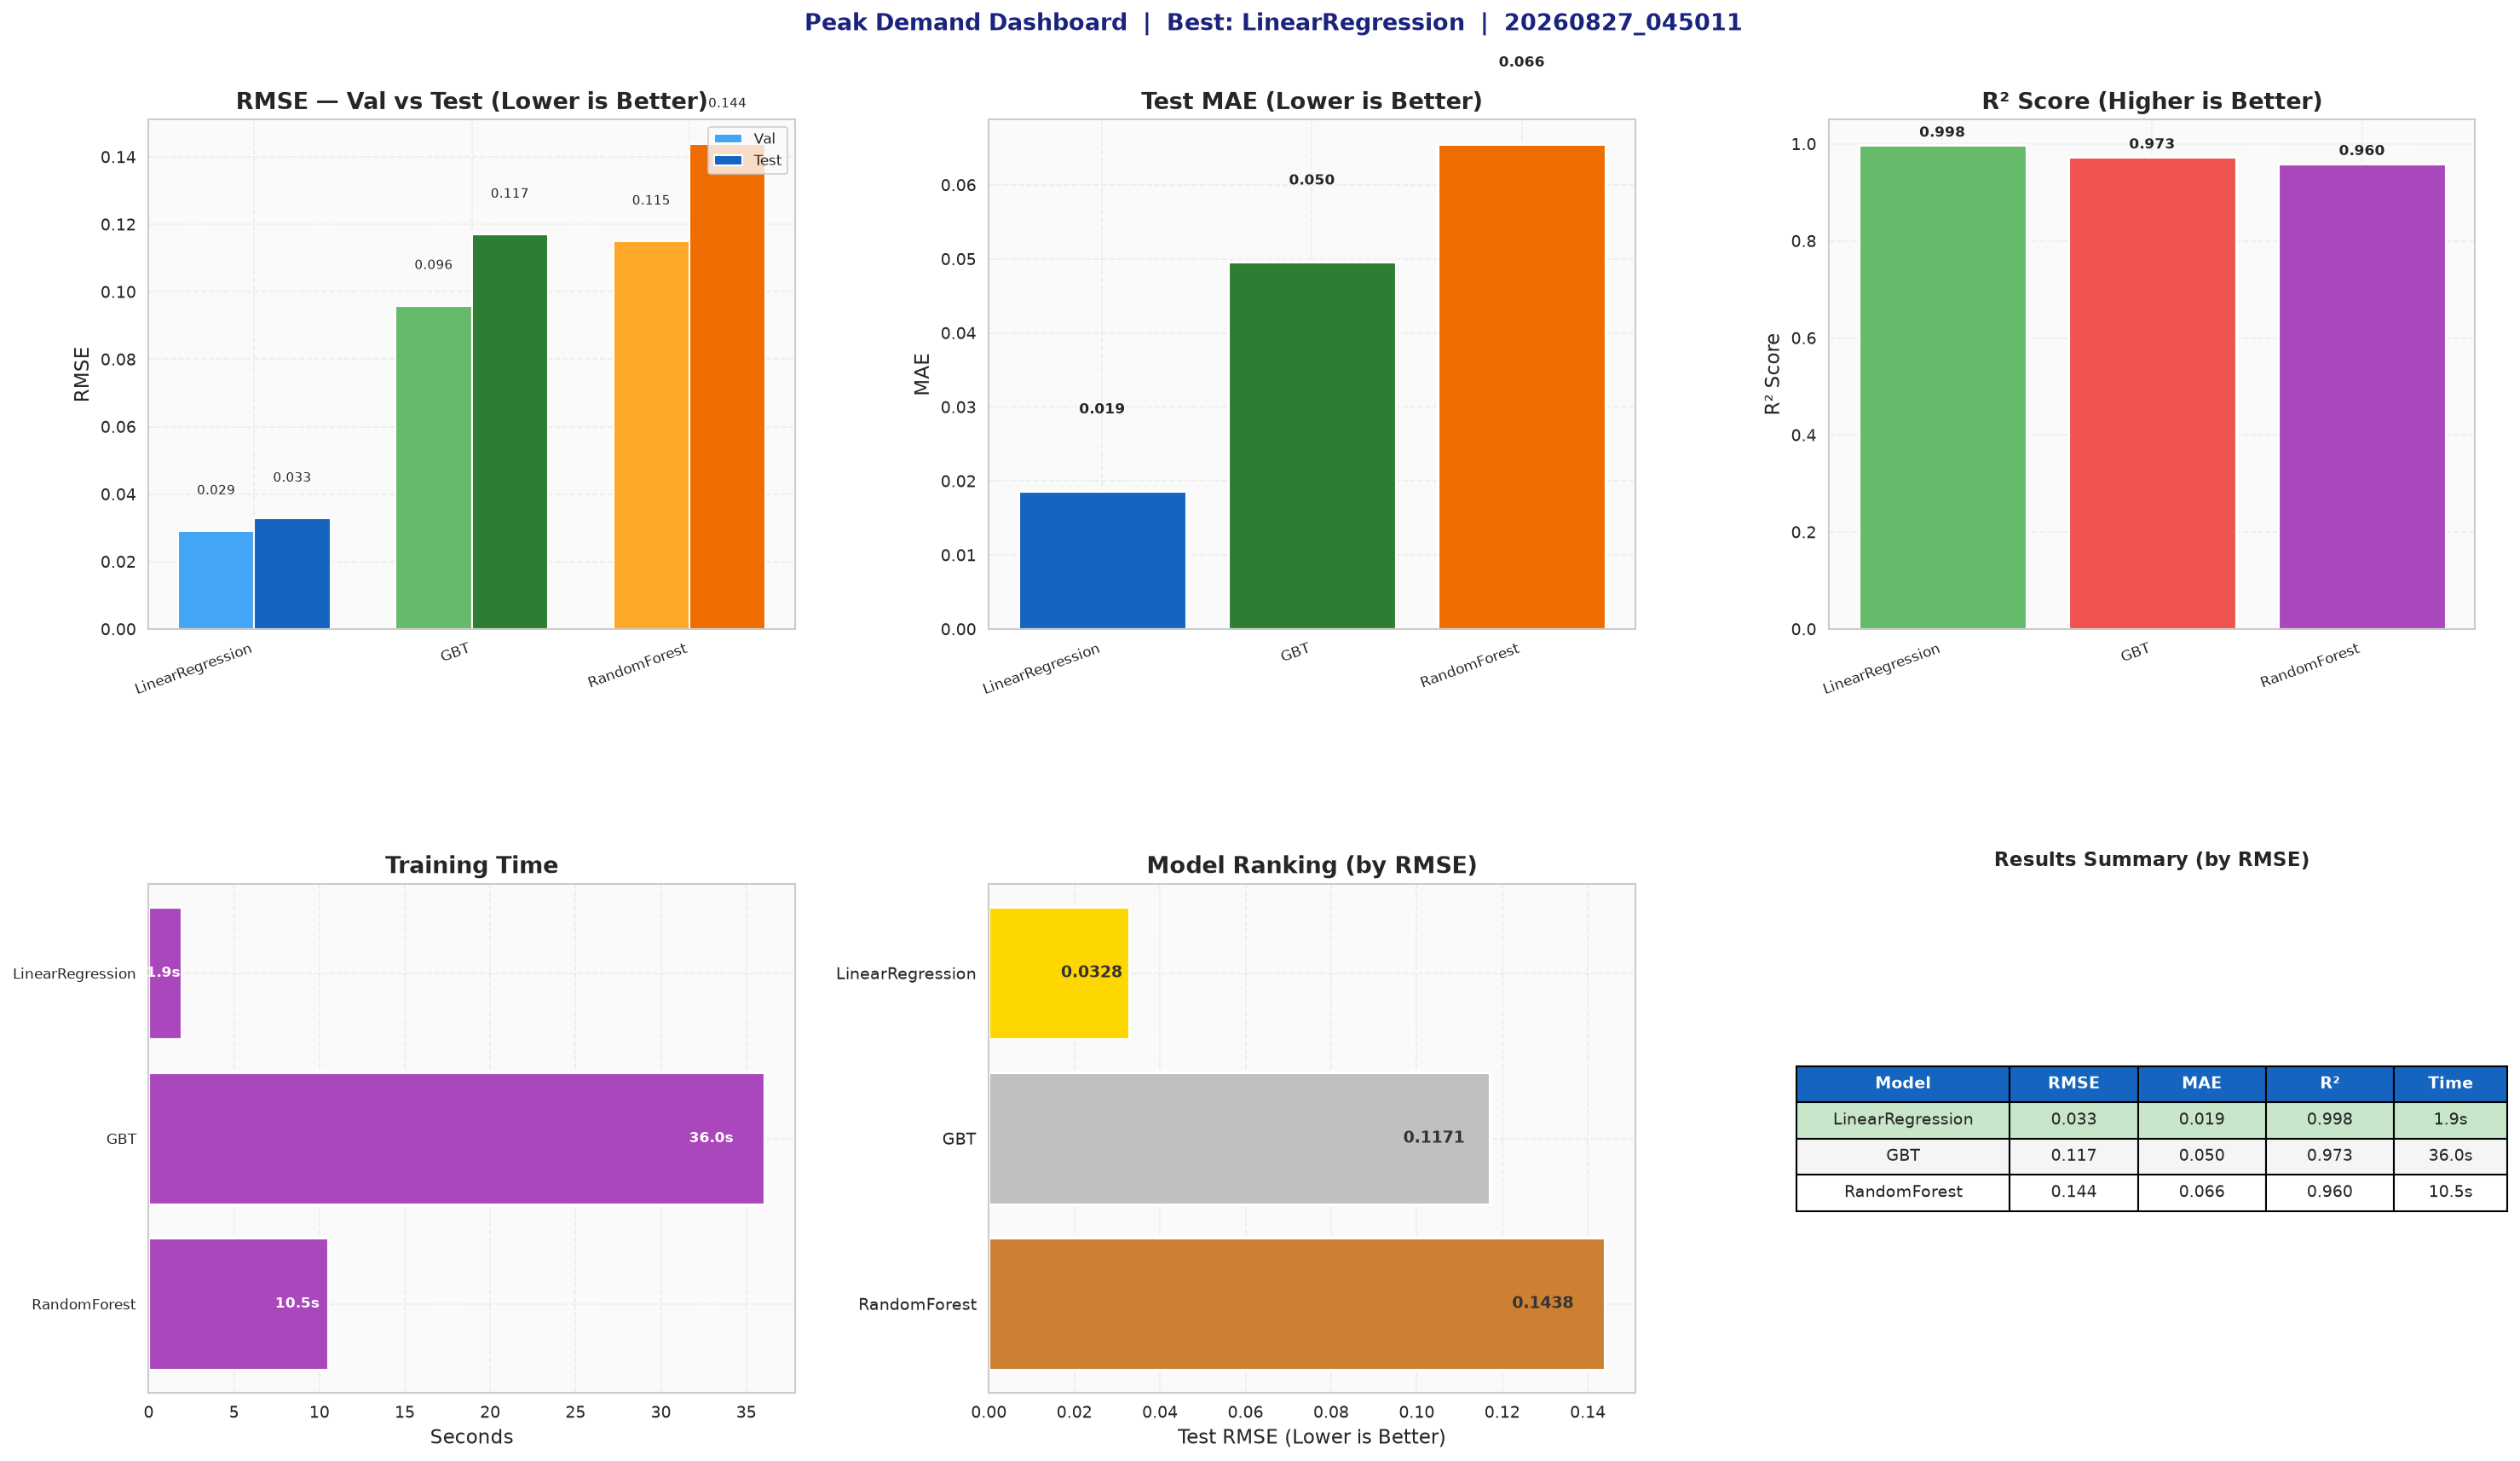

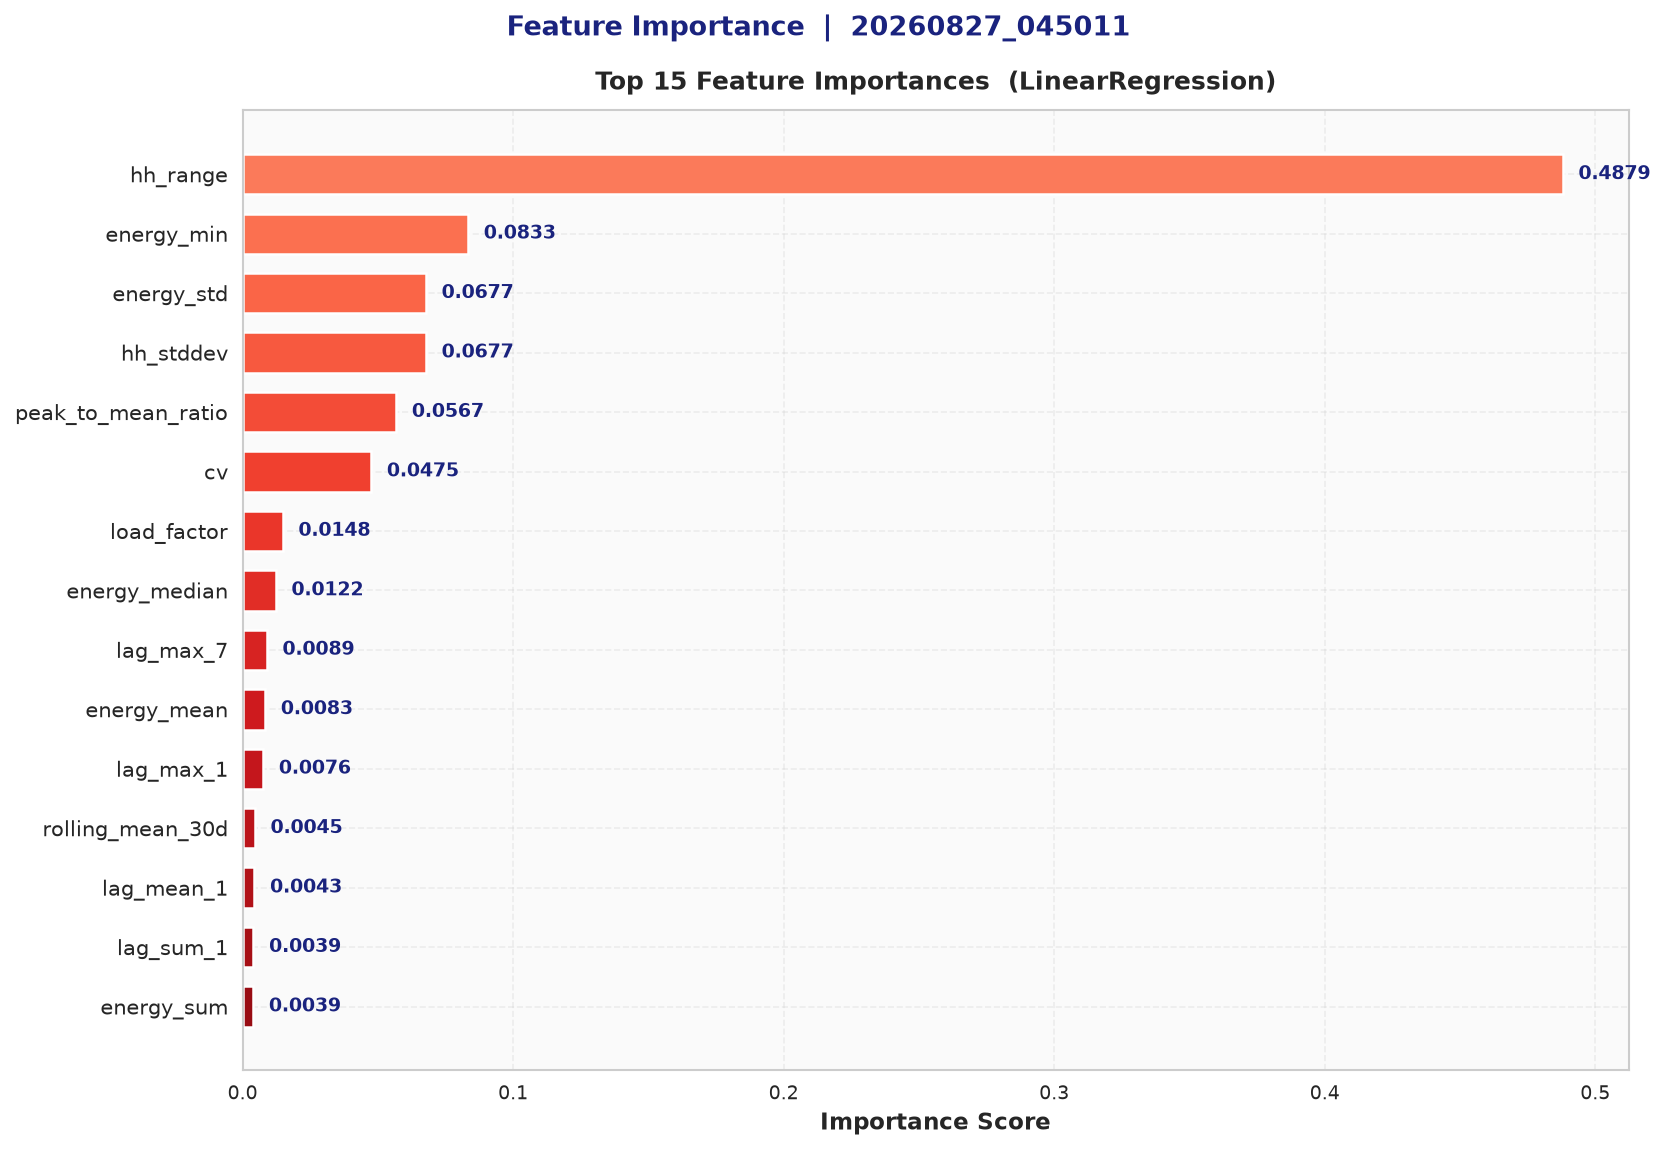

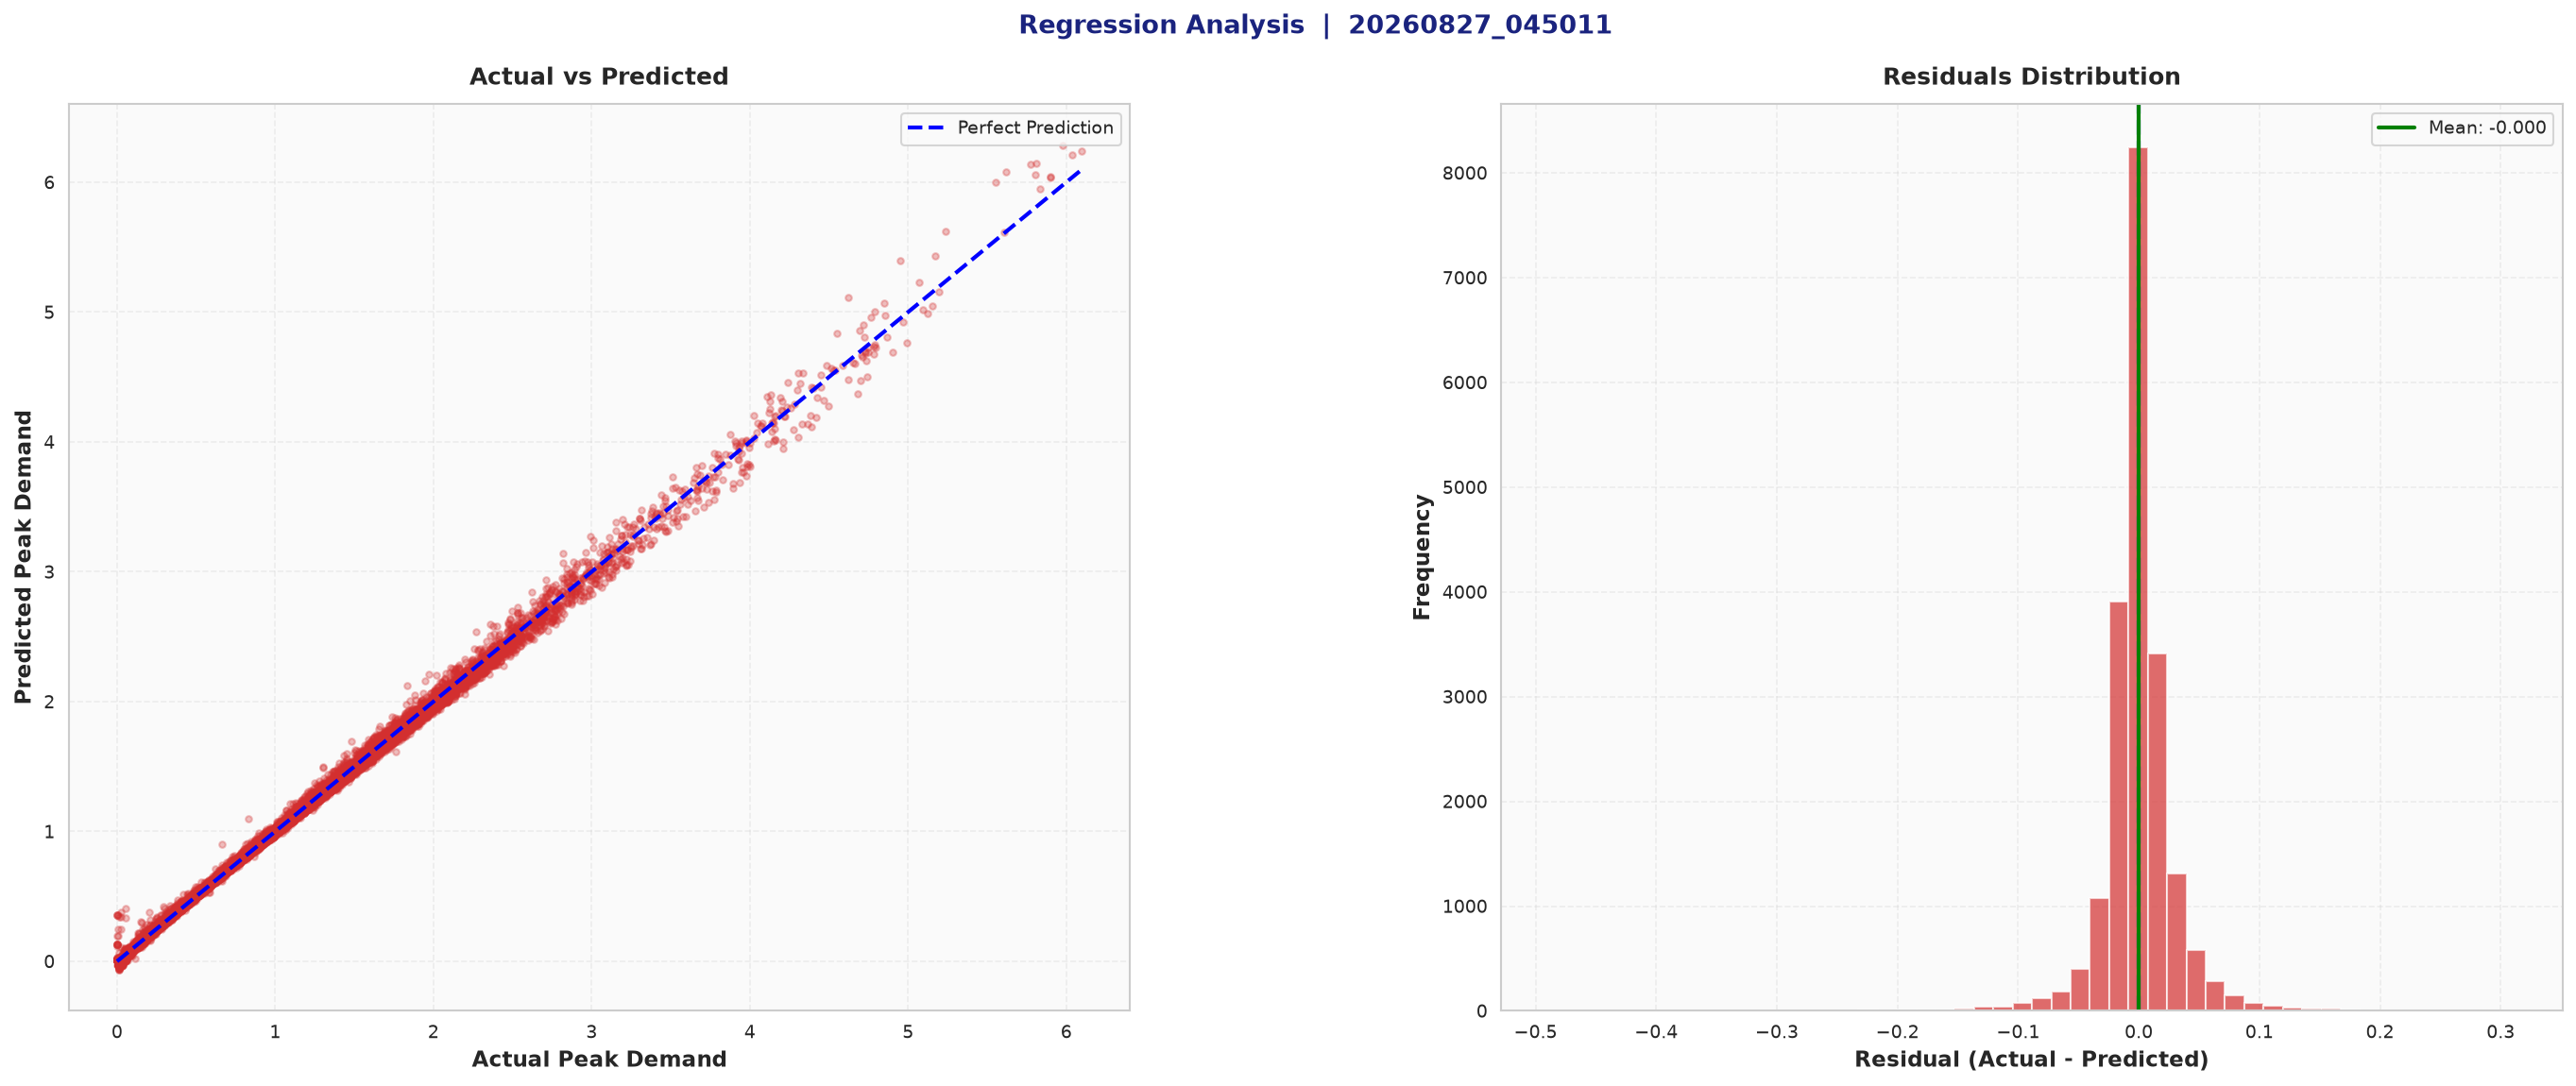


══════════════════════════════════════════════════════════════
  ✅ PEAK DEMAND PREDICTION  —  COMPLETE
──────────────────────────────────────────────────────────────
  🏆 Best model : LinearRegression
  📊 Test  RMSE : 0.0328
  📊 Test  MAE  : 0.0187
  📊 Test  R²   : 0.9979
  ⏱   Train time : 1.9 s
──────────────────────────────────────────────────────────────
  📁 Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 4
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 4/task04_peak_20260827_045011.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 4/task04_peak_20260827_045011.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 4/task04_peak_20260827_045011.html

════════════════════════════════════════

In [14]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
import builtins
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import LinearSegmentedColormap
from datetime import timedelta
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=""):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 4')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: delete ALL previous outputs ONCE at startup ─────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"  {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

from pyspark.sql.functions import col, desc, count, when, lit, rand, isnan, lead, min as spark_min, max as spark_max, ntile
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# ── Matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.linestyle': '--', 'axes.labelsize': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.facecolor': '#fafafa', 'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.linewidth': 1.0,
})
_cmap = LinearSegmentedColormap.from_list("blues", ["#e3f2fd", "#1565c0", "#0d47a1"])

timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"PEAK DEMAND PREDICTION  |  {timestamp}", "⚡")

# ════════════════════════════════════════════════════════════
# [1/7] Prepare peak data
# ════════════════════════════════════════════════════════════
_sec('1/7', 'Preparing peak demand dataset', '🔧')
if 'forecast_feature_cols' not in globals():
    forecast_feature_cols = [
        "energy_mean", "energy_max", "energy_std", "energy_sum", "energy_min", "energy_median",
        "cv", "peak_to_mean_ratio", "load_factor",
        "lag_mean_1", "lag_mean_2", "lag_mean_3", "lag_mean_7",
        "lag_sum_1", "lag_sum_2", "lag_sum_7",
        "lag_max_1", "lag_max_7",
        "rolling_mean_7d", "rolling_std_7d", "rolling_mean_14d", "rolling_mean_30d",
        "month", "day_of_week", "is_weekend", "is_holiday", "season", "quarter",
        "temperatureMax", "temperatureMin", "temperatureHigh", "temperatureLow",
        "humidity", "windSpeed", "windBearing", "cloudCover", "pressure", "dewPoint"
    ]
    _hh = ["peak_hour_avg", "offpeak_night_avg", "daytime_avg", "morning_peak_avg",
           "night_ratio", "peak_to_offpeak_ratio", "hh_stddev", "hh_range"]
    for c in _hh:
        if c in daily_clean.columns:
            forecast_feature_cols.append(c)
    forecast_feature_cols = [c for c in forecast_feature_cols if c in daily_clean.columns]

peak_feature_cols = [c for c in forecast_feature_cols if c != "energy_max"]
peak_data = daily_clean.select(
    "LCLid", "day", "energy_max", "stdorToU", *peak_feature_cols
).filter(col("energy_max").isNotNull()).cache()

_total = peak_data.count()
print(f"  Records: {_total:,}  |  Features: {len(peak_feature_cols)}")

# ════════════════════════════════════════════════════════════
# [2/7] Date-based split (80/10/10)
# ════════════════════════════════════════════════════════════
_sec('2/7', 'Date-based split (80/10/10)', '📅')
_date_range = peak_data.select(spark_min("day"), spark_max("day")).collect()[0]
_min_date, _max_date = _date_range[0], _date_range[1]
_total_days = (_max_date - _min_date).days
_split_1 = _min_date + timedelta(days=int(_total_days * 0.80))
_split_2 = _min_date + timedelta(days=int(_total_days * 0.90))

print(f"  Date range: {_min_date} → {_max_date}")
print(f"  Train:  {_min_date} → {_split_1}  (80%)")
print(f"  Val:    {_split_1} → {_split_2}  (10%)")
print(f"  Test:   {_split_2} → {_max_date}  (10%)")

train_peak = peak_data.filter(col("day") < _split_1).cache()
val_peak = peak_data.filter((col("day") >= _split_1) & (col("day") < _split_2)).cache()
test_peak = peak_data.filter(col("day") >= _split_2).cache()

train_n = train_peak.count(); val_n = val_peak.count(); test_n = test_peak.count()
_tot_split = train_n + val_n + test_n
print(f"\n  Train : {train_n:>6,}  ({train_n/_tot_split*100:.1f}%)")
print(f"  Val   : {val_n:>6,}  ({val_n/_tot_split*100:.1f}%)")
print(f"  Test  : {test_n:>6,}  ({test_n/_tot_split*100:.1f}%)")

# ════════════════════════════════════════════════════════════
# [3/7] Sampling for speed
# ════════════════════════════════════════════════════════════
_sec('3/7', 'Sampling for speed', '⚡')
_MAX_TRAIN, _MAX_VAL, _MAX_TEST = 100000, 20000, 20000

if train_n > _MAX_TRAIN:
    train_peak = train_peak.sample(False, _MAX_TRAIN/train_n, seed=42).cache()
    train_n = train_peak.count()
    print(f"  Train sampled: {train_n:,}")
else:
    print(f"  Train kept: {train_n:,}")

if val_n > _MAX_VAL:
    val_peak = val_peak.sample(False, _MAX_VAL/val_n, seed=42).cache()
    val_n = val_peak.count()
    print(f"  Val sampled:   {val_n:,}")
else:
    print(f"  Val kept:   {val_n:,}")

if test_n > _MAX_TEST:
    test_peak = test_peak.sample(False, _MAX_TEST/test_n, seed=42).cache()
    test_n = test_peak.count()
    print(f"  Test sampled:  {test_n:,}")
else:
    print(f"  Test kept:  {test_n:,}")

# ════════════════════════════════════════════════════════════
# [4/7] Feature pipeline
# ════════════════════════════════════════════════════════════
_sec('4/7', 'Feature pipeline', '🔧')
_assembler = VectorAssembler(inputCols=peak_feature_cols, outputCol="features_raw", handleInvalid="skip")
_scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
n_features = len(peak_feature_cols)
print(f"  Features: {n_features}  |  Scaler: StandardScaler (z-score)")

# ════════════════════════════════════════════════════════════
# [5/7] Training
# ════════════════════════════════════════════════════════════
_hdr("TRAINING MODELS", "🚀")

_MODELS = {
    "RandomForest": RandomForestRegressor(
        featuresCol="features", labelCol="energy_max",
        numTrees=20, maxDepth=6, maxBins=32, seed=42, subsamplingRate=0.8),
    "GBT": GBTRegressor(
        featuresCol="features", labelCol="energy_max",
        maxIter=20, maxDepth=5, seed=42),
    "LinearRegression": LinearRegression(
        featuresCol="features", labelCol="energy_max",
        maxIter=20, regParam=0.01, elasticNetParam=0.0, tol=1e-3),
}

_eval_rmse = RegressionEvaluator(labelCol="energy_max", predictionCol="prediction", metricName="rmse")
_eval_mae = RegressionEvaluator(labelCol="energy_max", predictionCol="prediction", metricName="mae")
_eval_r2 = RegressionEvaluator(labelCol="energy_max", predictionCol="prediction", metricName="r2")

results = {}
for _name, _mdl in _MODELS.items():
    print(f"\n  ▶ {_name}")
    print(f"     {'─'*52}")
    _pipe = Pipeline(stages=[_assembler, _scaler, _mdl])
    _t0 = time.time()
    try:
        _fit = _pipe.fit(train_peak)
        _t = time.time() - _t0
        _vp = _fit.transform(val_peak)
        _tp = _fit.transform(test_peak)
        _vrmse = _eval_rmse.evaluate(_vp)
        _trmse = _eval_rmse.evaluate(_tp)
        _tmae = _eval_mae.evaluate(_tp)
        _tr2 = _eval_r2.evaluate(_tp)
        results[_name] = dict(
            val_rmse=_vrmse, test_rmse=_trmse, test_mae=_tmae, test_r2=_tr2,
            time=_t, model=_fit, test_preds=_tp, status="✅")
        print(f"     ⏱ {_t:6.1f}s  |  ValRMSE={_vrmse:.4f}  TestRMSE={_trmse:.4f}  MAE={_tmae:.4f}  R²={_tr2:.4f}")
    except Exception as _ex:
        print(f"     ❌ {str(_ex)[:110]}")
        results[_name] = {"status": f"❌ {str(_ex)[:110]}"}

_hdr("MODEL COMPARISON", "📊")
ok = {k: v for k, v in results.items() if v.get("status", "").startswith("✅")}
if not ok:
    raise RuntimeError("No model succeeded — cannot continue")

sorted_models = sorted(ok.items(), key=lambda x: x[1]['test_rmse'])
sorted_names = [m for m, _ in sorted_models]
best = sorted_names[0]

_comp = pd.DataFrame([
    dict(Model=m, ValRMSE=f"{r['val_rmse']:.4f}", TestRMSE=f"{r['test_rmse']:.4f}",
         MAE=f"{r['test_mae']:.4f}", R2=f"{r['test_r2']:.4f}", Time=f"{r['time']:.1f}s")
    for m, r in sorted_models])
print("\n" + _comp.to_string(index=False))
print(f"\n  🏆 BEST: {C.BOLD}{best}{C.END}  "
      f"RMSE={ok[best]['test_rmse']:.4f}  R²={ok[best]['test_r2']:.4f}")

# ════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
_hdr("FEATURE IMPORTANCE", "🔍")
feat_imp = []
_source_model = best
_fs = ok[best]["model"].stages[-1] if hasattr(ok[best]["model"], 'stages') else None

if _fs and hasattr(_fs, 'featureImportances'):
    feat_imp = sorted(zip(peak_feature_cols, _fs.featureImportances.toArray()), key=lambda x: -x[1])
    _ok(f"From best model: {best}")
elif _fs and hasattr(_fs, 'coefficients'):
    _coeffs = np.abs(_fs.coefficients.toArray())
    feat_imp = sorted(zip(peak_feature_cols, _coeffs), key=lambda x: -x[1])
    _ok(f"Using coefficient magnitudes from {best}")
elif "RandomForest" in ok:
    _rf = ok["RandomForest"]["model"].stages[-1]
    if hasattr(_rf, 'featureImportances'):
        feat_imp = sorted(zip(peak_feature_cols, _rf.featureImportances.toArray()), key=lambda x: -x[1])
        _source_model = "RandomForest"
        _ok("Using RandomForest as fallback")
elif "GBT" in ok:
    _gbt = ok["GBT"]["model"].stages[-1]
    if hasattr(_gbt, 'featureImportances'):
        feat_imp = sorted(zip(peak_feature_cols, _gbt.featureImportances.toArray()), key=lambda x: -x[1])
        _source_model = "GBT"
        _ok("Using GBT as fallback")

if feat_imp:
    print(f"\n  Source: {_source_model}")
    print("  Top 15:")
    for _i, (f, v) in enumerate(feat_imp[:15], 1):
        _bar = "█" * int(v * 100 / feat_imp[0][1])
        print(f"  {_i:2d}. {f:<28} {v:.4f} {_bar}")
else:
    _warn("Feature importance not available")

# ════════════════════════════════════════════════════════════
# ACTUAL VS PREDICTED DATA
# ════════════════════════════════════════════════════════════
_bpreds = ok[best]["test_preds"]
_preds_pdf = _bpreds.select("energy_max", "prediction").toPandas()
_residuals = _preds_pdf['energy_max'] - _preds_pdf['prediction']

# ════════════════════════════════════════════════════════════
# BUILD VISUALISATIONS
# ════════════════════════════════════════════════════════════
_hdr("BUILDING VISUALISATIONS", "🎨")

_nm = len(sorted_names)
_x = np.arange(_nm)
_w = 0.35
_COLS = ['#1565c0', '#2e7d32', '#ef6c00'][:_nm]
_COLS2 = ['#42a5f5', '#66bb6a', '#ffa726'][:_nm]

# ════════════════════════════════════════════════════════════
# FIGURE 1: Dashboard (display only - not saved)
# ════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(20, 12), facecolor='white')
_dg = mgridspec.GridSpec(2, 3, figure=fig1,
                          hspace=0.50, wspace=0.30,
                          left=0.06, right=0.97,
                          top=0.91, bottom=0.08)

_da1 = fig1.add_subplot(_dg[0, 0])
_da2 = fig1.add_subplot(_dg[0, 1])
_da3 = fig1.add_subplot(_dg[0, 2])
_da4 = fig1.add_subplot(_dg[1, 0])
_da5 = fig1.add_subplot(_dg[1, 1])
_da6 = fig1.add_subplot(_dg[1, 2])

# RMSE Val vs Test
_b1 = _da1.bar(_x - _w/2, [ok[n]['val_rmse'] for n in sorted_names], _w,
               label='Val', color=_COLS2, edgecolor='white', lw=1)
_b2 = _da1.bar(_x + _w/2, [ok[n]['test_rmse'] for n in sorted_names], _w,
               label='Test', color=_COLS, edgecolor='white', lw=1)
_da1.set_ylabel('RMSE'); _da1.set_title('RMSE — Val vs Test (Lower is Better)')
_da1.set_xticks(_x); _da1.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
for _b in list(_b1) + list(_b2):
    _da1.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=7)
_da1.legend(fontsize=8, loc='upper right')

# MAE
_bs = _da2.bar(sorted_names, [ok[n]['test_mae'] for n in sorted_names],
               color=_COLS, edgecolor='white', lw=1.5)
_da2.set_ylabel('MAE'); _da2.set_title('Test MAE (Lower is Better)')
_da2.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
for _b in _bs:
    _da2.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# R²
_bsr = _da3.bar(sorted_names, [ok[n]['test_r2'] for n in sorted_names],
                color=['#66bb6a', '#ef5350', '#ab47bc'][:_nm], edgecolor='white', lw=1.5)
_da3.set_ylabel('R² Score'); _da3.set_title('R² Score (Higher is Better)')
_da3.set_xticklabels(sorted_names, rotation=20, ha='right', fontsize=8)
_da3.set_ylim(0, 1.05)
for _b in _bsr:
    _da3.text(_b.get_x() + _b.get_width()/2, _b.get_height() + 0.01,
              f'{_b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Training Time — FIXED: white text INSIDE bar
_bh = _da4.barh(sorted_names, [ok[n]['time'] for n in sorted_names],
                color='#ab47bc', edgecolor='white', lw=1.5)
_da4.set_xlabel('Seconds'); _da4.set_title('Training Time')
_da4.invert_yaxis(); _da4.set_yticklabels(sorted_names, fontsize=8)
for _b in _bh:
    _w_val = _b.get_width()
    _da4.text(_w_val - _w_val*0.05, _b.get_y() + _b.get_height()/2,
              f'{_w_val:.1f}s', va='center', ha='right', fontsize=8,
              fontweight='bold', color='white')

# Model Ranking by RMSE — FIXED: dark text INSIDE bar
_rank_names = [s[0] for s in sorted_models]
_rank_scores = [s[1]['test_rmse'] for s in sorted_models]
_rank_colors = ['#FFD700', '#C0C0C0', '#CD7F32'][:len(_rank_names)]
_br = _da5.barh(_rank_names[::-1], _rank_scores[::-1], color=_rank_colors[::-1],
                edgecolor='white', lw=1.5)
_da5.set_xlabel('Test RMSE (Lower is Better)'); _da5.set_title('Model Ranking (by RMSE)')
for _i, _b in enumerate(_br):
    _w_val = _b.get_width()
    _da5.text(_w_val - _w_val*0.05, _b.get_y() + _b.get_height()/2,
              f'{_w_val:.4f}', va='center', ha='right', fontsize=9,
              fontweight='bold', color='#333333')

# Results table
_da6.axis('off')
_td = [[m, f"{r['test_rmse']:.3f}", f"{r['test_mae']:.3f}", f"{r['test_r2']:.3f}", f"{r['time']:.1f}s"]
       for m, r in sorted_models]
_tbl = _da6.table(cellText=_td, colLabels=['Model', 'RMSE', 'MAE', 'R²', 'Time'],
                  cellLoc='center', loc='center',
                  colColours=['#1565c0']*5, colWidths=[0.30, 0.18, 0.18, 0.18, 0.16])
_tbl.auto_set_font_size(False); _tbl.set_fontsize(9); _tbl.scale(1.1, 1.7)
for _j in range(5):
    _tbl[(0, _j)].set_text_props(color='white', fontweight='bold')
for _i in range(1, len(_td)+1):
    for _j in range(5):
        _tbl[(_i, _j)].set_facecolor('#c8e6c9' if _td[_i-1][0] == best
                                     else ('#f5f5f5' if _i % 2 == 0 else 'white'))
_da6.set_title('Results Summary (by RMSE)', fontweight='bold', pad=10, fontsize=11)

fig1.suptitle(f'Peak Demand Dashboard  |  Best: {best}  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 2: Feature Importance (display only - not saved)
# ════════════════════════════════════════════════════════════
fig2, _fl = plt.subplots(1, 1, figsize=(12, 8), facecolor='white',
    gridspec_kw={'left': 0.18, 'right': 0.95, 'top': 0.90, 'bottom': 0.10})

if feat_imp:
    _fn15 = [f[0] for f in feat_imp[:15]]; _fv15 = [f[1] for f in feat_imp[:15]]
    _grad = plt.cm.Reds(np.linspace(0.45, 0.90, len(_fn15)))
    _fl.barh(range(len(_fn15)), _fv15, color=_grad, edgecolor='white', linewidth=1.2, height=0.68)
    _fl.set_yticks(range(len(_fn15))); _fl.set_yticklabels(_fn15, fontsize=10)
    _fl.invert_yaxis()
    _fl.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
    _fl.set_title(f'Top 15 Feature Importances  ({_source_model})', fontsize=12, fontweight='bold', pad=10)
    _fl.grid(axis='x', alpha=0.3, linestyle='--')
    _mx = float(np.max(_fv15)) if _fv15 else 1.0
    for _i, _v in enumerate(_fv15):
        _fl.text(_v + _mx*0.012, _i, f'{_v:.4f}', va='center', fontsize=9, fontweight='bold', color='#1a237e')
else:
    _fl.text(0.5, 0.5, 'Feature importances not available', ha='center', va='center', fontsize=12, color='grey')
    _fl.axis('off')

fig2.suptitle(f'Feature Importance  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# FIGURE 3: Actual vs Predicted (display only - not saved)
# ════════════════════════════════════════════════════════════
fig3, (_fa, _fr) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white',
    gridspec_kw={'wspace': 0.35, 'left': 0.06, 'right': 0.94, 'top': 0.90, 'bottom': 0.10})

_min_val = _preds_pdf['energy_max'].min()
_max_val = _preds_pdf['energy_max'].max()

# Left: Scatter
_fa.scatter(_preds_pdf['energy_max'], _preds_pdf['prediction'],
            alpha=0.3, s=10, color='#d32f2f')
_fa.plot([_min_val, _max_val], [_min_val, _max_val], 'b--', lw=2, label='Perfect Prediction')
_fa.set_xlabel('Actual Peak Demand', fontweight='bold'); _fa.set_ylabel('Predicted Peak Demand', fontweight='bold')
_fa.set_title('Actual vs Predicted', fontweight='bold', fontsize=12, pad=10)
_fa.legend(fontsize=9)

# Right: Residuals
_fr.hist(_residuals, bins=50, color='#d32f2f', edgecolor='white', alpha=0.7)
_fr.axvline(x=0, color='blue', linestyle='--', lw=2)
_fr.axvline(x=_residuals.mean(), color='green', linestyle='-', lw=2, label=f'Mean: {_residuals.mean():.3f}')
_fr.set_xlabel('Residual (Actual - Predicted)', fontweight='bold')
_fr.set_ylabel('Frequency', fontweight='bold')
_fr.set_title('Residuals Distribution', fontweight='bold', fontsize=12, pad=10)
_fr.legend(fontsize=9)

fig3.suptitle(f'Regression Analysis  |  {timestamp}',
              fontsize=13, fontweight='bold', color='#1a237e', y=0.98)

plt.show()

# ════════════════════════════════════════════════════════════
# SAVE COMBINED PNG
# ════════════════════════════════════════════════════════════
import matplotlib.image as _mimg
import io as _io

def _fig_to_arr(f):
    _buf = _io.BytesIO()
    f.savefig(_buf, dpi=200, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    return _mimg.imread(_buf)

_arr1 = _fig_to_arr(fig1)
_arr2 = _fig_to_arr(fig2)
_arr3 = _fig_to_arr(fig3)

plt.close(fig1); plt.close(fig2); plt.close(fig3)

_h1, _w1 = _arr1.shape[:2]
_h2, _w2 = _arr2.shape[:2]
_h3, _w3 = _arr3.shape[:2]
_W = builtins.max(_w1, _w2, _w3)

# Add 80px padding between figures to prevent any overlap
_total_h = _h1 + _h2 + _h3 + 160
_merged = np.ones((_total_h, _W, 4), dtype=np.float32)

_y = 0
_merged[_y:_y+_h1, :_w1] = _arr1
_y += _h1 + 80
_merged[_y:_y+_h2, :_w2] = _arr2
_y += _h2 + 80
_merged[_y:_y+_h3, :_w3] = _arr3

_final_png = f'{output_dir}/task04_peak_{timestamp}.png'
_mfig, _max = plt.subplots(figsize=(_W/200, _total_h/200), facecolor='white',
    gridspec_kw={'left': 0, 'right': 1, 'top': 1, 'bottom': 0})
_max.imshow(_merged, interpolation='lanczos')
_max.axis('off')
_mfig.savefig(_final_png, dpi=200, bbox_inches='tight',
              facecolor='white', edgecolor='none', pad_inches=0.02)
plt.close(_mfig)

# ════════════════════════════════════════════════════════════
# BUILD FINAL CSV
# ════════════════════════════════════════════════════════════
total_n = train_n + val_n + test_n
train_pct = train_n / total_n * 100 if total_n else 0
val_pct = val_n / total_n * 100 if total_n else 0
test_pct = test_n / total_n * 100 if total_n else 0

_final_csv = f'{output_dir}/task04_peak_{timestamp}.csv'
_lines = []

_lines += [
    "PEAK DEMAND PREDICTION REPORT",
    f"Generated,{timestamp}",
    f"Best Model,{best}",
    f"Test RMSE,{ok[best]['test_rmse']:.4f}",
    f"Test MAE,{ok[best]['test_mae']:.4f}",
    f"Test R2,{ok[best]['test_r2']:.4f}",
    "",
    "── SECTION 1: MODEL COMPARISON ──────────────────────────────",
    "Model,Val_RMSE,Test_RMSE,MAE,R2,Time_s,Best",
]
for _m, _r in sorted_models:
    _lines.append(
        f"{_m},{_r['val_rmse']:.4f},{_r['test_rmse']:.4f},"
        f"{_r['test_mae']:.4f},{_r['test_r2']:.4f},{_r['time']:.1f},"
        f"{'YES' if _m == best else ''}")

_lines += [
    "",
    "── SECTION 2: FEATURE IMPORTANCE ──────────────────────────────",
    "Rank,Feature,Importance",
]
for _i, (_f, _v) in enumerate(feat_imp if feat_imp else [('N/A', 0)], 1):
    _lines.append(f"{_i},{_f},{_v:.6f}")

_lines += [
    "",
    "── SECTION 3: RESIDUALS SUMMARY ──────────────────────────────",
    "Metric,Value",
    f"Mean Residual,{_residuals.mean():.4f}",
    f"Std Residual,{_residuals.std():.4f}",
    f"Min Residual,{_residuals.min():.4f}",
    f"Max Residual,{_residuals.max():.4f}",
]

_lines += [
    "",
    "── SECTION 4: DATASET SUMMARY ──────────────────────────────",
    f"Total Records,{total_n}",
    f"Train,{train_n},{train_pct:.1f}%",
    f"Validation,{val_n},{val_pct:.1f}%",
    f"Test,{test_n},{test_pct:.1f}%",
    f"Features,{n_features}",
]

with open(_final_csv, 'w', encoding='utf-8') as _fh:
    _fh.write('\n'.join(_lines))

# ════════════════════════════════════════════════════════════
# HTML REPORT
# ════════════════════════════════════════════════════════════

# model rows
_model_rows = ""
for _m, _r in sorted_models:
    _cls = "best-row" if _m == best else ""
    _trph = "🏆" if _m == best else ""
    _model_rows += f"""
        <tr class="{_cls}">
            <td><strong>{_m}</strong> {_trph}</td>
            <td>{_r['val_rmse']:.4f}</td><td>{_r['test_rmse']:.4f}</td>
            <td>{_r['test_mae']:.4f}</td><td>{_r['test_r2']:.4f}</td>
            <td>{_r['time']:.1f}</td>
        </tr>"""

# feature rows
_feat_rows = ""
for _i, (_f, _v) in enumerate(feat_imp[:10] if feat_imp else [], 1):
    _feat_rows += f"""
        <tr><td>{_i}</td><td><strong>{_f}</strong></td><td>{_v:.6f}</td></tr>"""

_br = ok[best]
_final_html = f'{output_dir}/task04_peak_{timestamp}.html'
_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Peak Demand Report — {timestamp}</title>
<style>
:root{{--p:#880e4f;--pl:#ad1457;--ac:#ff80ab;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(136,14,79,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>⚡ Peak Demand Prediction Report</h1>
  <p>Daily peak load forecasting · Regression with PySpark ML</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best: {best}</span>
    <span class="bdg">📊 {n_features} Features</span>
    <span class="bdg">🗂️ {total_n:,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{_br['test_rmse']:.4f}</div><div class="kl">RMSE</div></div>
  <div class="kpi"><div class="kv">{_br['test_mae']:.4f}</div><div class="kl">MAE</div></div>
  <div class="kpi"><div class="kv">{_br['test_r2']:.4f}</div><div class="kl">R² Score</div></div>
  <div class="kpi"><div class="kv">{_residuals.mean():.4f}</div><div class="kl">Mean Residual</div></div>
  <div class="kpi"><div class="kv">{_residuals.std():.4f}</div><div class="kl">Std Residual</div></div>
  <div class="kpi"><div class="kv">{_br['time']:.1f}s</div><div class="kl">Train Time</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Model Comparison (Ranked by RMSE)</div>
  <div class="tw"><table>
    <thead><tr><th>Model</th><th>Val RMSE</th><th>Test RMSE</th><th>MAE</th>
    <th>R²</th><th>Time (s)</th></tr></thead>
    <tbody>{_model_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top 10 Important Features</div>
  <div class="tw"><table>
    <thead><tr><th>Rank</th><th>Feature</th><th>Importance</th></tr></thead>
    <tbody>{_feat_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Dataset Summary</div>
  <div class="tw"><table>
    <thead><tr><th>Split</th><th>Count</th><th>%</th></tr></thead>
    <tbody>
      <tr><td><strong>Train</strong></td><td>{train_n:,}</td><td>{train_pct:.1f}%</td></tr>
      <tr><td><strong>Val</strong></td><td>{val_n:,}</td><td>{val_pct:.1f}%</td></tr>
      <tr><td><strong>Test</strong></td><td>{test_n:,}</td><td>{test_pct:.1f}%</td></tr>
      <tr style="background:#e8eaf6;font-weight:700">
        <td>Total</td><td>{total_n:,}</td><td>100%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by Peak Demand Prediction Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

with open(_final_html, 'w', encoding='utf-8') as _fh:
    _fh.write(_html)

# ════════════════════════════════════════════════════════════
# SPARK CLEANUP
# ════════════════════════════════════════════════════════════
for _df in [peak_data, train_peak, val_peak, test_peak]:
    try: _df.unpersist()
    except: pass

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = '═'*62
_s2 = '─'*62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ PEAK DEMAND PREDICTION  —  COMPLETE
{_s2}
  🏆 Best model : {best}
  📊 Test  RMSE : {ok[best]['test_rmse']:.4f}
  📊 Test  MAE  : {ok[best]['test_mae']:.4f}
  📊 Test  R²   : {ok[best]['test_r2']:.4f}
  ⏱   Train time : {ok[best]['time']:.1f} s
{_s2}
  📁 Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")


### CELL 15: TASK 5 - COMPLETE SEGMENTATION PIPELINE
###### =================================================================================
   
###### **Normalize 48 half-hour readings per day**
###### - K-Means clustering to find typical patterns (morning peak, evening peak, flat, etc).
###### - 2D PCA visualization.


###### **Part B: Household Segmentation (Behavioral Clustering)**
###### - Group households by energy behavior, not demographics.
###### - Features: avg daily load profile, peak-to-off-peak ratio, night vs day usage, variability.
###### - K-Means clustering.




──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
  ✔ Nothing to clean
──────────────────────────────────────────────────────────────
        ✅ SparkSession is active

══════════════════════════════════════════════════════════════
  ⚡  SEGMENTATION PIPELINE  |  20260827_045209
══════════════════════════════════════════════════════════════

  [A] 📊 Load Shape Analysis (Daily Usage Patterns)
        ✅ Found half-hourly data in 'hh_df'

  [A1] 🔧 Preparing daily load shape profiles (48 half-hour slots)
        ✅ Sampled 19.9% of rows (OOM guard, ~30,000 profiles)
        ✅ Repartitioning before pivot to reduce shuffle memory …
  Features: 48 half-hour slots

  [A2] 🔄 Normalising daily load shapes
        ✅ Load shape profiles:149,869 days

  [A3] 🔍 Finding optimal K for load shapes
  K= 2  →  Silhouette = 0.0937  |  26.0s
  K= 3  →  Silhouette = -0.0297  |  24.4s
  K= 4  →  Silhouette = 0.0189  |  8.2s
  K= 5  →  Silhouette = -0.0241  |  9.

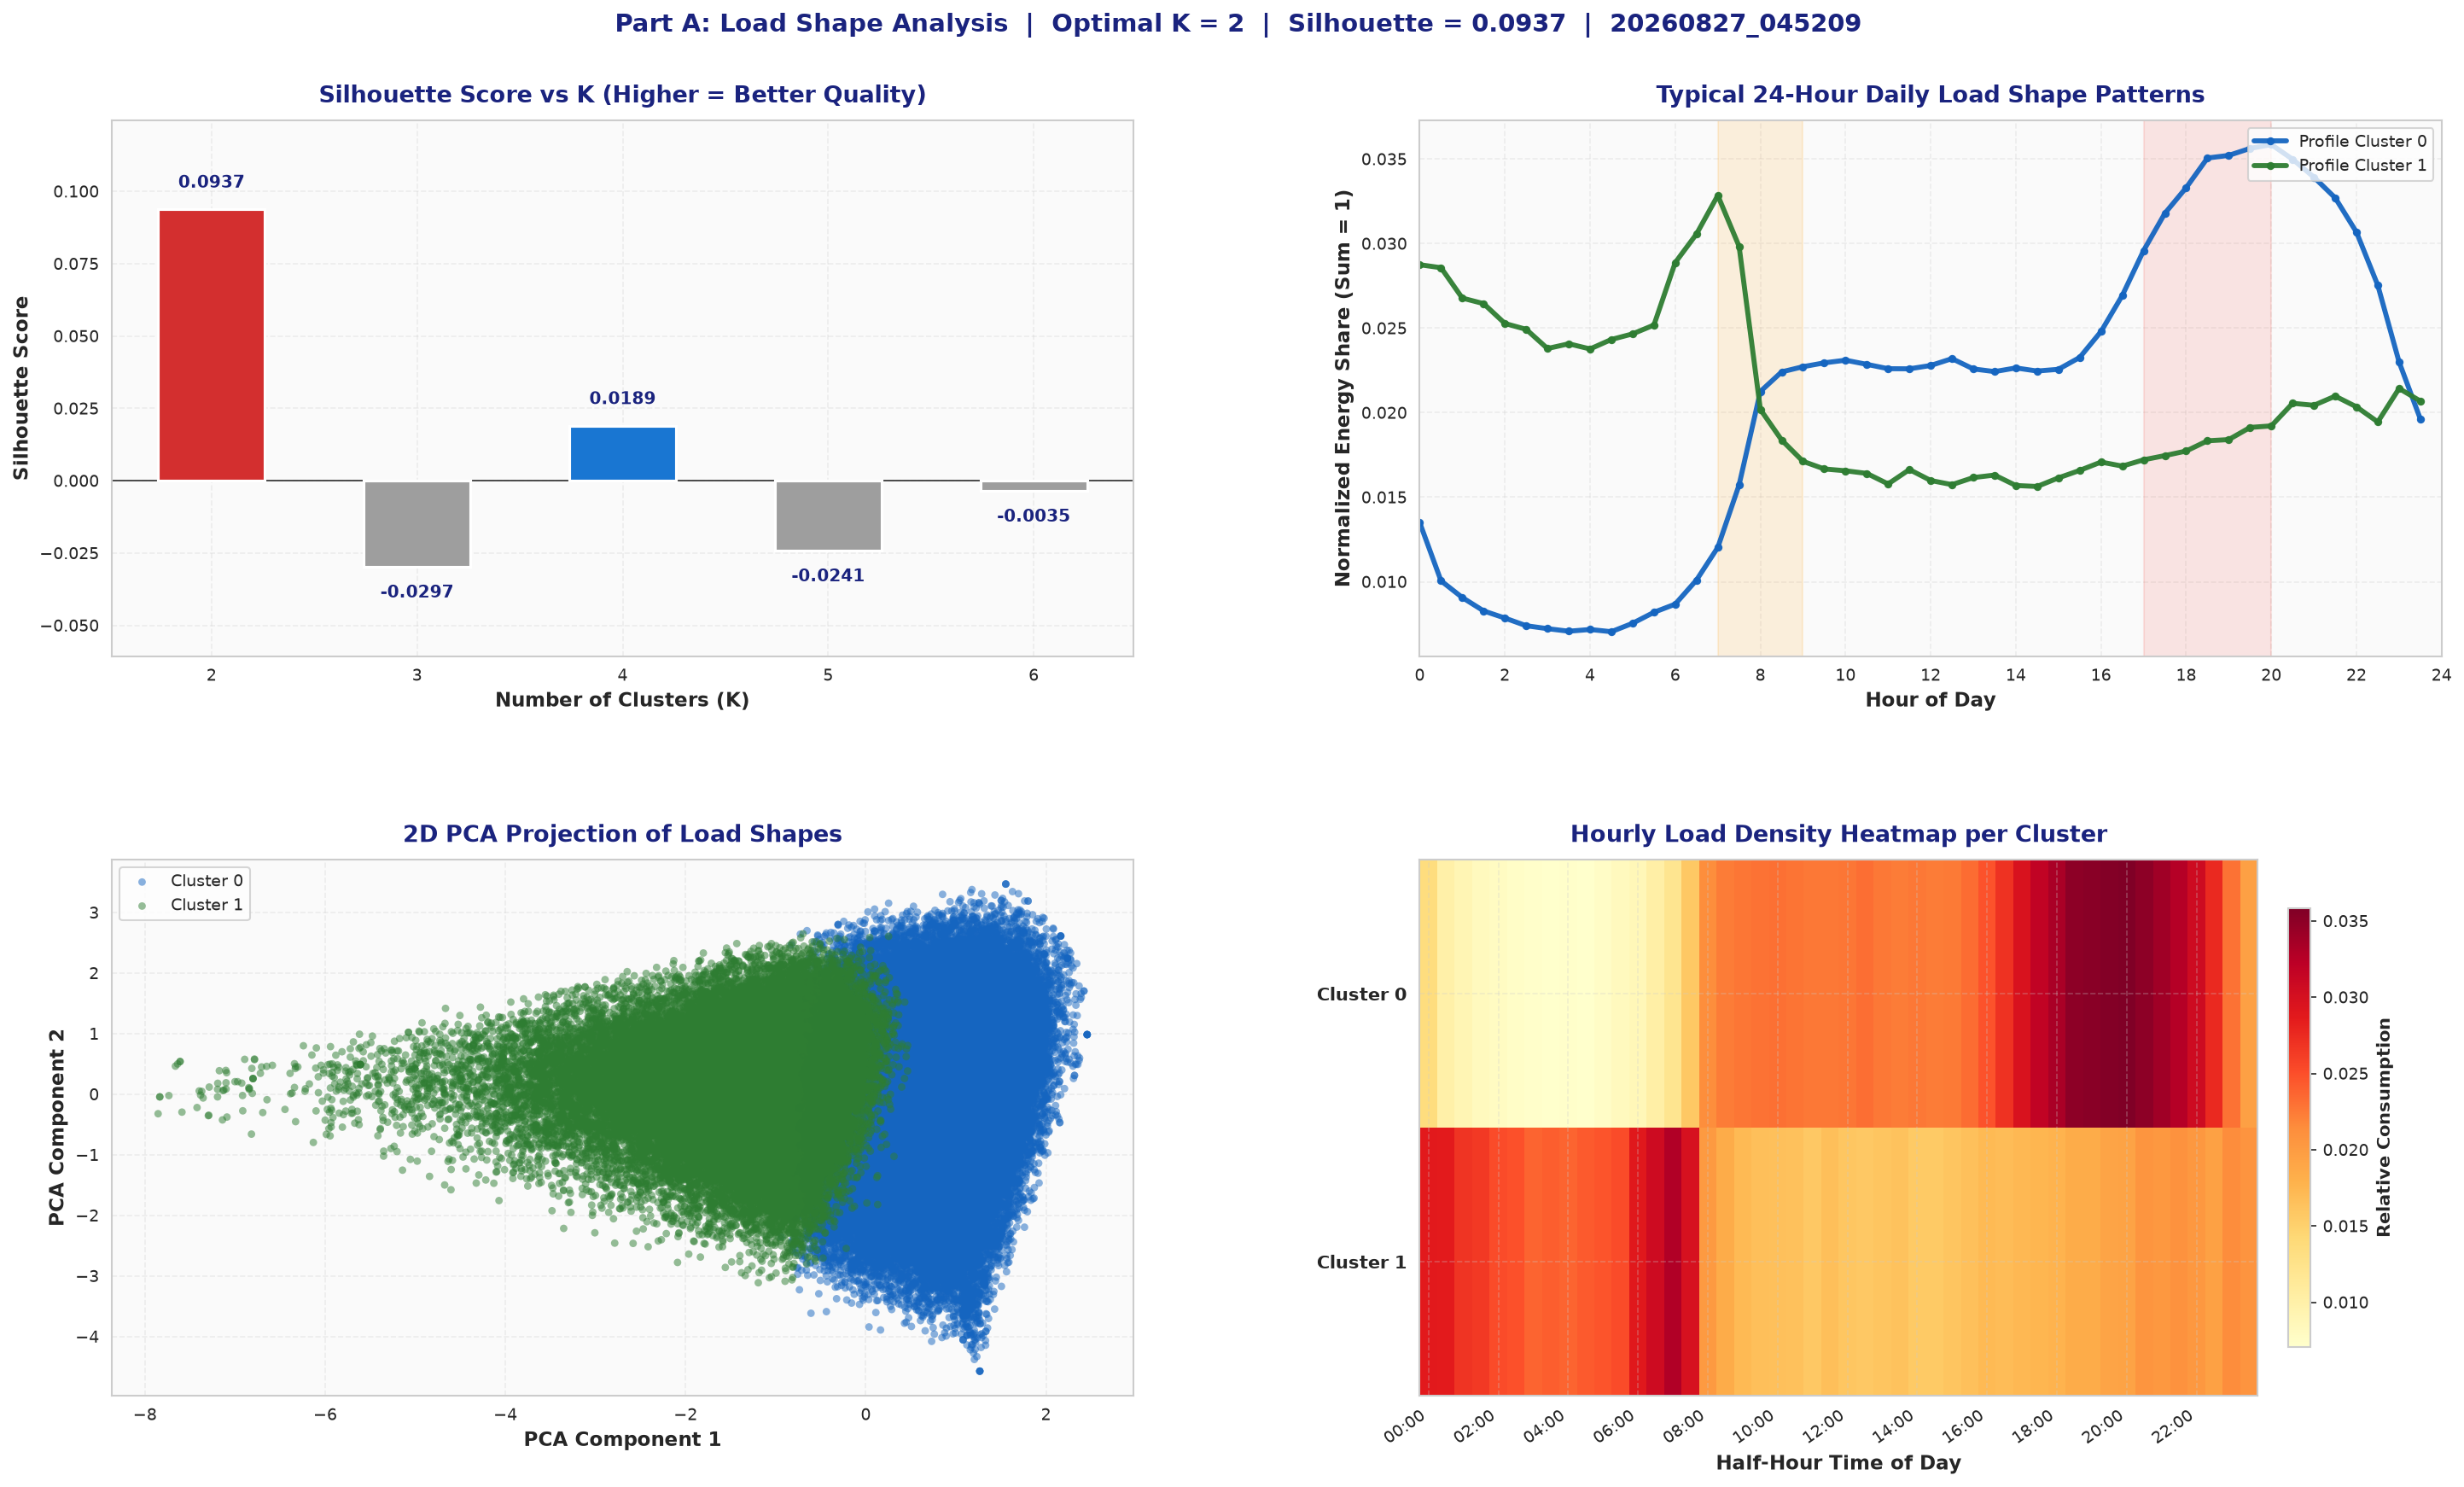



══════════════════════════════════════════════════════════════
  🏠  PART B: HOUSEHOLD SEGMENTATION (Behavioural Clustering)
══════════════════════════════════════════════════════════════

  [B1] 🔧 Aggregating household-level behavioural features
        ✅ Using in-memory 'daily_features' as source
  Grouping columns: ['LCLid', 'stdorToU', 'Acorn_grouped']
  🔎 Found 10 half-hourly columns in seg_data
        ✅ Joined half-hourly features
        ✅ Households analyzed: 5,566

  [B2] 🔧 Preparing features for clustering
  Clustering features (23): ['avg_daily_mean', 'avg_daily_max', 'avg_daily_std', 'avg_daily_sum', 'avg_cv', 'avg_peak_ratio', 'avg_load_factor', 'variability', 'consumption_range', 'weekend_weekday_ratio', 'winter_avg', 'summer_avg', 'winter_summer_ratio', 'avg_peak_hour_avg', 'avg_peak_hour_max', 'avg_offpeak_night_avg', 'avg_daytime_avg', 'avg_morning_peak_avg', 'avg_night_ratio', 'avg_peak_to_offpeak_ratio', 'avg_stddev', 'avg_range', 'avg_reading_count']

  [B3] 🔍 Fin

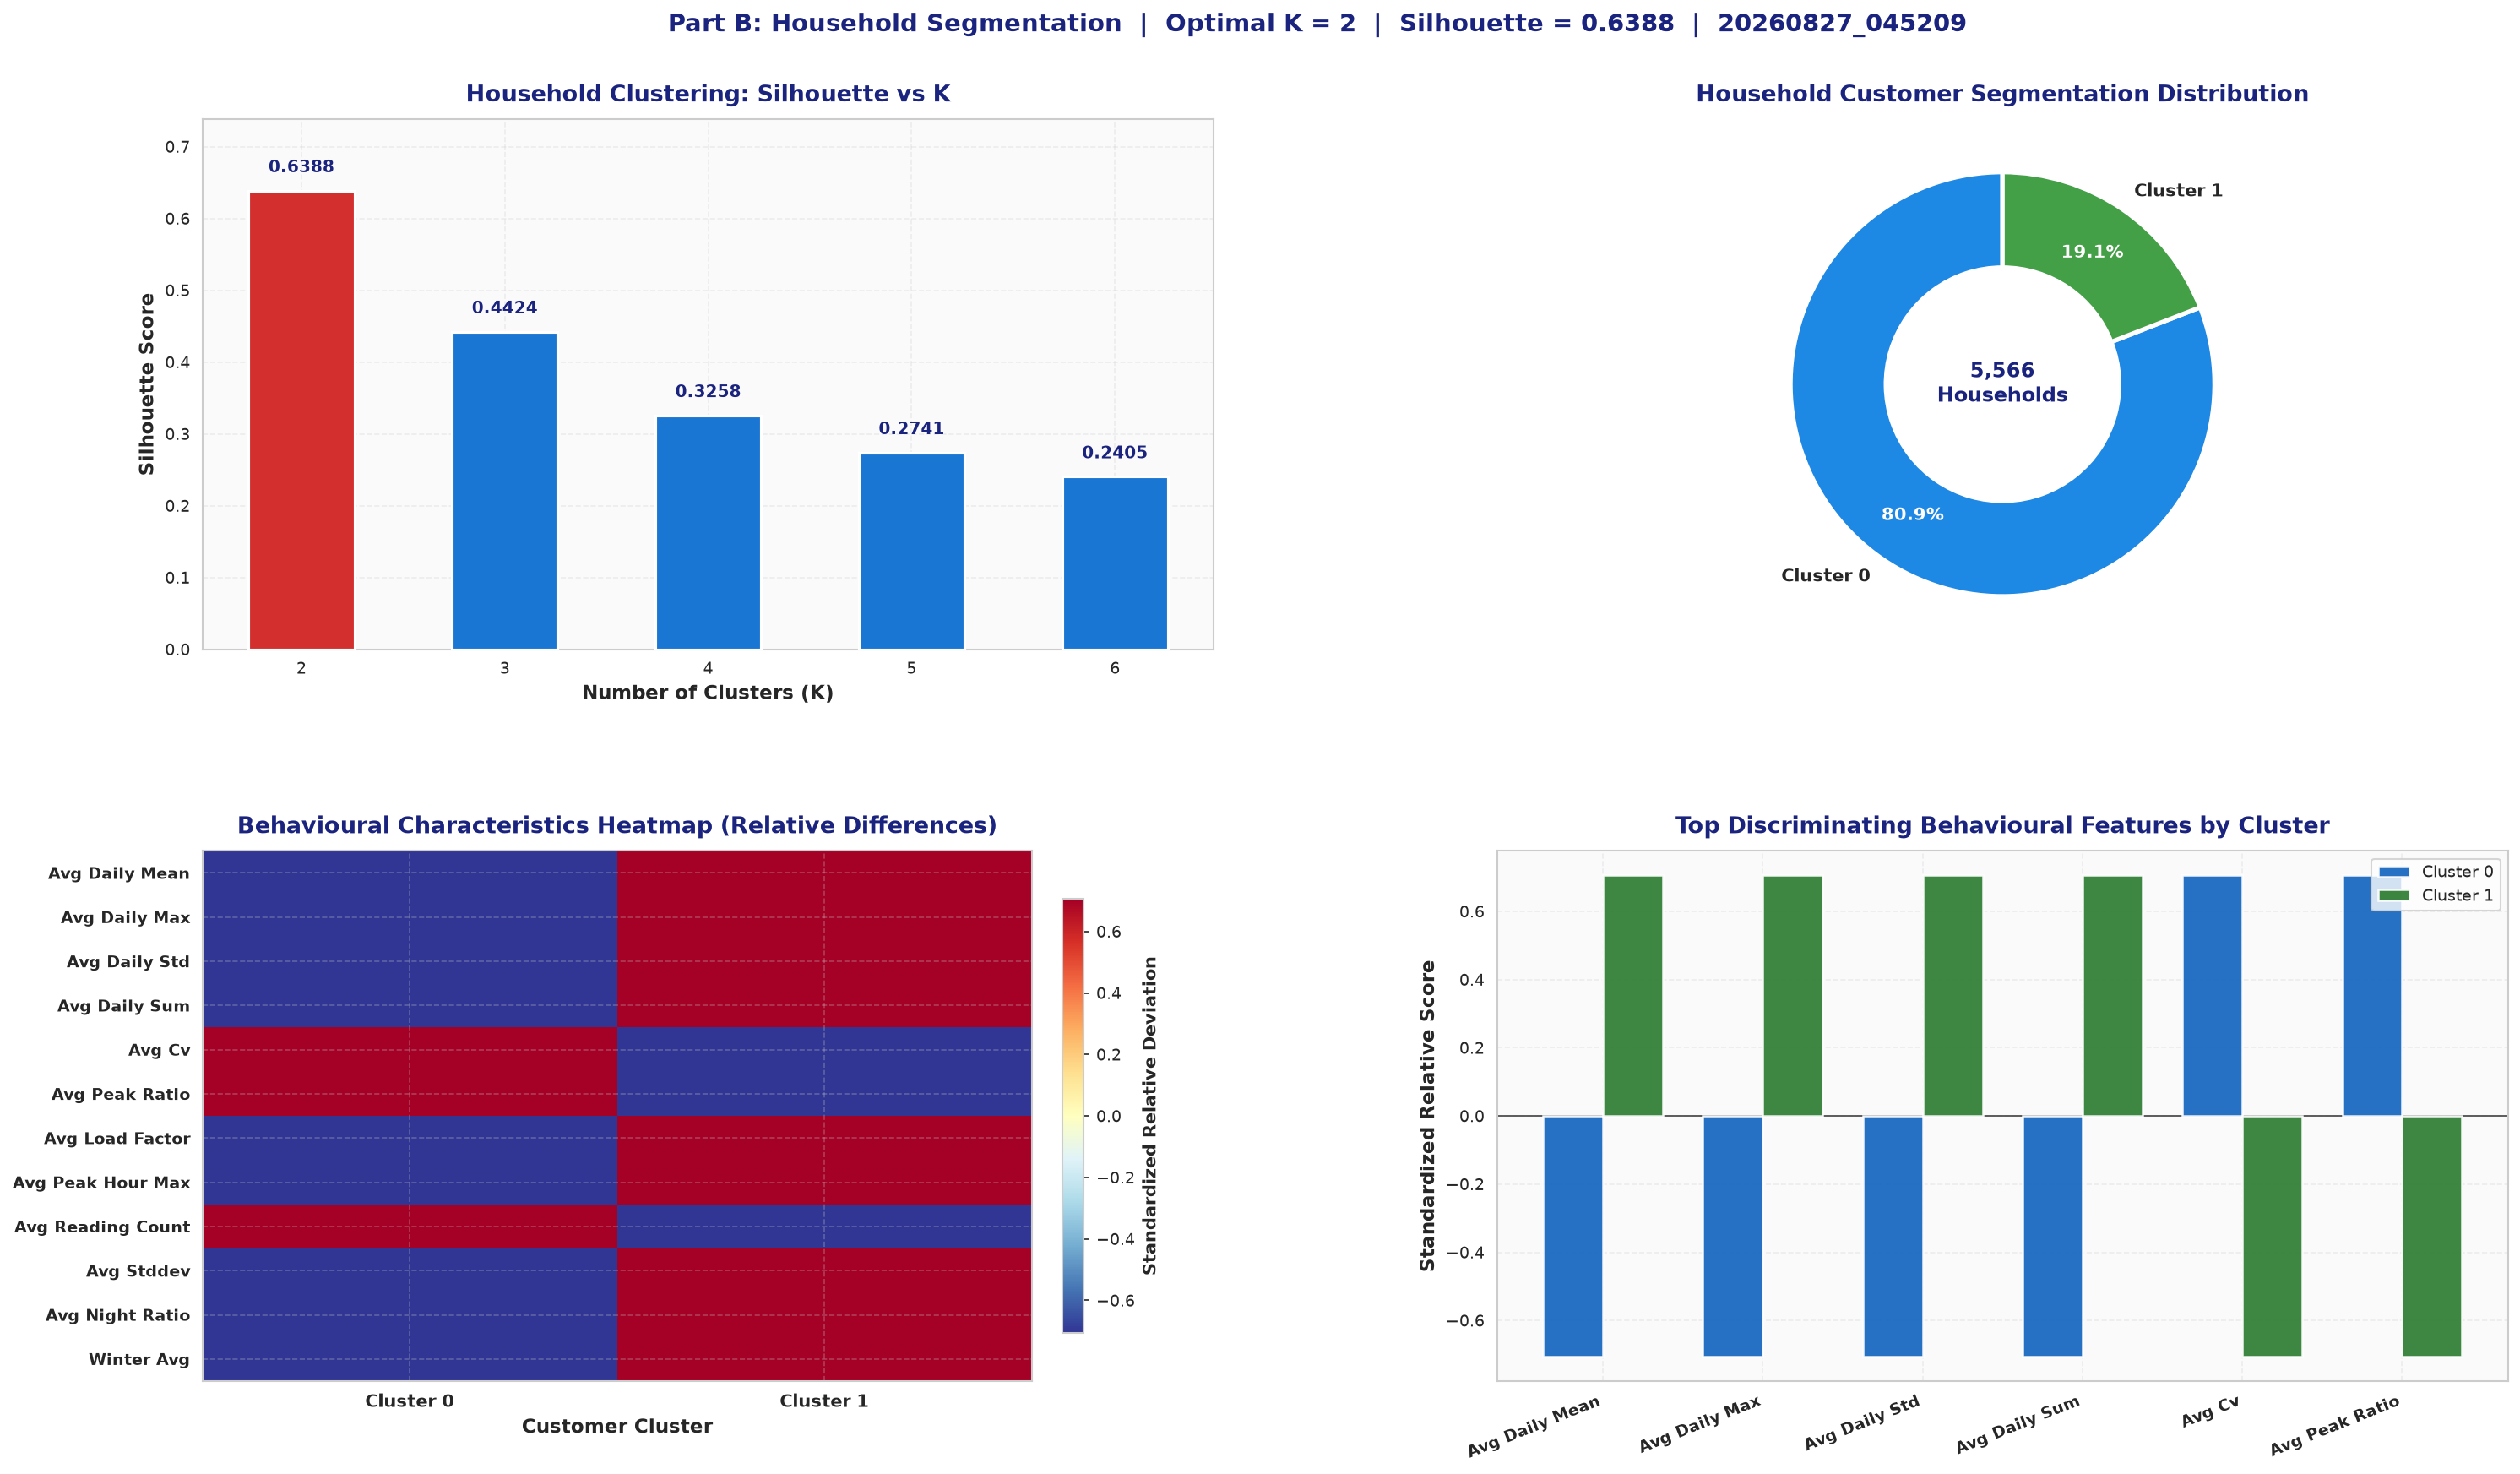


══════════════════════════════════════════════════════════════
  ✅  SEGMENTATION PIPELINE  —  COMPLETE
──────────────────────────────────────────────────────────────
  📊  Load Shapes  : K=2 | Silhouette=0.0937 | 149,869 profiles
  🏠  Households   : K=2 | Silhouette=0.6388 | 5,566 households
──────────────────────────────────────────────────────────────
  🖼️  PNG          : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 5\task05_seg_20260827_045209.png
  📊  CSV          : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 5\task05_seg_20260827_045209.csv
  🌐  HTML         : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 5\task05_seg_20260827_045209.html
══════════════════════════════════════════════════════════════


In [15]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
try:
    spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
except Exception as _spark_err:
    print(f" ⚠️ Spark session unavailable: {_spark_err}")
    print("  💡 Run Cell 1 first to initialize Spark session.")
    raise RuntimeError("Spark session not available. Run Cell 1 first.") from _spark_err
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 15: TASK 5 – COMPLETE SEGMENTATION PIPELINE
#   Part A : Load Shape Analysis  (48-slot daily profiles → KMeans)
#   Part B : Household Segmentation (behavioural clustering)
# ============================================================
import builtins
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.colors import LinearSegmentedColormap
import os
import glob
import shutil
import io as _io
import warnings
warnings.filterwarnings("ignore")

# ── ANSI colours ──────────────────────────────────────────────────────────────
class C:
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; BOLD = "\033[1m"; END = "\033[0m"

def _hdr(title, emoji=""):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=""):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️ {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ──────────────────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, "output")
output_dir      = os.path.join(base_output_dir, "Task 5")
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: remove previous run outputs ─────────────────────────────────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp):  shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except Exception:
        pass
print(f"  {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  SPARK SESSION VALIDATION & RECOVERY                        ║
# ╚══════════════════════════════════════════════════════════════╝
def _get_or_restart_spark():
    """
    Return an active SparkSession.
    If the current session is stopped / dead, attempt to rebuild it
    using the same settings that Cell 1 used.
    """
    from pyspark.sql import SparkSession
    import logging, sys, os

    # 1. Try the existing session first
    try:
        _s = SparkSession.builder.getOrCreate()
        # Ping the JVM – raises if the context is dead
        _ = _s.sparkContext.defaultParallelism
        _ok("SparkSession is active")
        return _s
    except Exception as _e:
        _warn(f"SparkSession ping failed: {_e}")

    # 2. Stop whatever is lying around
    _warn("Attempting to stop stale session and create a fresh one …")
    try:
        SparkSession.builder.getOrCreate().stop()
    except Exception:
        pass

    # 3. Re-apply env vars (mirrors Cell 1)
    _py311 = r"C:\Users\Alimm\anaconda3\envs\pyspark_env\python.exe"
    if os.path.isfile(_py311):
        os.environ["PYSPARK_PYTHON"]        = _py311
        os.environ["PYSPARK_DRIVER_PYTHON"] = _py311
    else:
        os.environ["PYSPARK_PYTHON"]        = sys.executable
        os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

    for _jh in [
        r"C:\Program Files\Microsoft\jdk-17.0.20.8-hotspot",
        r"C:\Program Files\Eclipse Adoptium\jdk-17",
        r"C:\Program Files\Java\jdk-17",
    ]:
        if os.path.isdir(_jh):
            os.environ["JAVA_HOME"] = _jh
            break

    _nb_dir = globals().get("NOTEBOOK_DIR", os.getcwd())
    _hadoop_dir = os.path.join(_nb_dir, "hadoop")
    if os.path.isfile(os.path.join(_hadoop_dir, "bin", "winutils.exe")):
        os.environ["HADOOP_HOME"]     = _hadoop_dir
        os.environ["hadoop.home.dir"] = _hadoop_dir
        os.environ["PATH"] = (
            os.path.join(_hadoop_dir, "bin") + os.pathsep + os.environ.get("PATH", "")
        )

    logging.getLogger("py4j").setLevel(logging.CRITICAL)
    logging.getLogger("pyspark").setLevel(logging.CRITICAL)

    _java17_opens = " ".join([
        "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED",
        "--add-opens=java.base/java.nio=ALL-UNNAMED",
        "--add-opens=java.base/java.util=ALL-UNNAMED",
        "--add-opens=java.base/java.lang=ALL-UNNAMED",
    ])
    _log_cfg = (
        "-Dlog4j.rootCategory=ERROR,console "
        "-Dlog4j.logger.org.apache.spark=ERROR "
        "-Dlog4j.logger.org.apache.hadoop=ERROR"
    )

    try:
        _s = (
            SparkSession.builder
            .appName("LondonSmartMeters_PySpark")
            .master("local[*]")
            .config("spark.executor.memory",   "8g")
            .config("spark.driver.memory",     "8g")
            .config("spark.sql.adaptive.enabled", "true")
            .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
            .config("spark.sql.shuffle.partitions", "100")
            .config("spark.default.parallelism", "100")
            .config("spark.network.timeout", "3600s")
            .config("spark.executor.heartbeatInterval", "120s")
            .config("spark.driver.maxResultSize", "4g")
            .config("spark.driver.extraJavaOptions", f"{_java17_opens} {_log_cfg}")
            .getOrCreate()
        )
        _s.sparkContext.setLogLevel("ERROR")
        _ok(f"Fresh SparkSession created (Spark {_s.version})")
        return _s
    except Exception as _e2:
        _err(f"Could not create SparkSession: {_e2}")
        raise RuntimeError(f"SparkSession unavailable: {_e2}") from _e2

# Validate / recover session
spark = _get_or_restart_spark()

# ── Tune runtime conf (safe, session already confirmed alive) ─────────────────
for _k, _v in [
    ("spark.sql.adaptive.enabled",                    "true"),
    ("spark.sql.adaptive.coalescePartitions.enabled", "true"),
    ("spark.sql.shuffle.partitions",                  "100"),
]:
    try:
        spark.conf.set(_k, _v)
    except Exception as _ce:
        _warn(f"Could not set conf {_k}: {_ce}")

# ── PySpark imports (after session is confirmed alive) ────────────────────────
try:
    from pyspark.sql.functions import (
        col, avg, stddev, max as spark_max, min as spark_min,
        count, when, lit, sum as spark_sum,
    )
    from pyspark.ml.feature    import VectorAssembler, StandardScaler, PCA
    from pyspark.ml.clustering import KMeans
    from pyspark.ml.evaluation import ClusteringEvaluator
    from pyspark.ml            import Pipeline
except Exception as _imp_err:
    _err(f"PySpark import failed – session may still be starting: {_imp_err}")
    raise

# ── Matplotlib defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
    "grid.linestyle": "--", "axes.labelsize": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "axes.facecolor": "#fafafa", "figure.facecolor": "white",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 1.0,
})
_cmap     = LinearSegmentedColormap.from_list("blues", ["#e3f2fd", "#1565c0", "#0d47a1"])
timestamp = time.strftime("%Y%m%d_%H%M%S")

_hdr(f"SEGMENTATION PIPELINE  |  {timestamp}", "⚡")

# ─────────────────────────────────────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════╗
# ║  PART A: LOAD SHAPE ANALYSIS                                ║
# ╚══════════════════════════════════════════════════════════════╝
# ─────────────────────────────────────────────────────────────────────────────
_sec("A", "Load Shape Analysis (Daily Usage Patterns)", "📊")

loadshape_done     = False
shape_results      = None
load_shape_data    = None
silhouette_scores_shape = []
best_k_shape       = 2
best_score_shape   = 0.0
n_profiles         = 0
shape_profiles_display = None
shape_dist         = None
pca_results        = None
figA               = None

try:
    # ── [A0] Locate half-hourly dataframe ─────────────────────────────────────
    hh_data = None
    for _var_name in ["hh_df", "half_hourly_df", "hh_data", "hourly_df"]:
        if _var_name in globals() and globals()[_var_name] is not None:
            _candidate = globals()[_var_name]
            try:
                if "half_hour_slot" in _candidate.columns:
                    _ = _candidate.limit(1).count()   # liveness ping
                    hh_data = _candidate
                    _ok(f"Found half-hourly data in '{_var_name}'")
                    break
            except Exception as _df_err:
                _warn(f"DataFrame '{_var_name}' is not queryable: {_df_err}")

    if hh_data is None:
        _warn("Half-hourly data not available – skipping Part A.")
        print("💡 Run Cell 7 to load half-hourly data first.")
    else:
        # ── [A1] Pivot into 48-slot daily profiles ───────────────────────────
        _sec("A1", "Preparing daily load shape profiles (48 half-hour slots)", "🔧")
        try:
            # Sample before pivot to avoid OOM (150K+ profiles crash heap)
            _MAX_PROFILES = 30000
            _total_hh = hh_data.count()
            if _total_hh > _MAX_PROFILES * 48:
                _frac = builtins.min(1.0, (_MAX_PROFILES * 48) / _total_hh)
                hh_data_use = hh_data.sample(False, _frac, seed=42)
                _ok(f"Sampled {_frac*100:.1f}% of rows (OOM guard, ~{_MAX_PROFILES:,} profiles)")
            else:
                hh_data_use = hh_data
            _ok("Repartitioning before pivot to reduce shuffle memory …")
            hh_data_repart = hh_data_use.repartition(50, "LCLid", "date")

            hh_pivot = (
                hh_data_repart
                .groupBy("LCLid", "date")
                .pivot("half_hour_slot")
                .agg(avg("energy_kwh").alias("energy"))
                .fillna(0)
            )
            hh_pivot = hh_pivot.coalesce(30)

            try:
                hh_data_repart.unpersist(blocking=False)
                hh_data_use.unpersist(blocking=False)
            except Exception:
                pass

            # Rename numeric pivot columns → hh_0 … hh_47
            for _i in range(48):
                _old = str(_i)
                if _old in hh_pivot.columns:
                    hh_pivot = hh_pivot.withColumnRenamed(_old, f"hh_{_i}")

            load_shape_cols = [f"hh_{_i}" for _i in range(48) if f"hh_{_i}" in hh_pivot.columns]

            if not load_shape_cols:
                raise ValueError("No half-hour slot columns found after pivot.")

            print(f"  Features: {len(load_shape_cols)} half-hour slots")

        except Exception as _a1_err:
            _err(f"[A1] Pivot failed: {_a1_err}")
            traceback.print_exc()
            raise  # bubble up to outer try → skip Part A

        # ── [A2] Normalise each day (sum → 1) ────────────────────────────────
        _sec("A2", "Normalising daily load shapes", "🔄")
        try:
            # Use explicit reduce instead of builtins.sum on Column objects
            from functools import reduce
            import operator
            _sum_col = reduce(operator.add, [col(_c) for _c in load_shape_cols])
            hh_pivot = hh_pivot.withColumn("daily_total", _sum_col)
            hh_pivot = hh_pivot.filter(col("daily_total") > 0.01)
            for _c in load_shape_cols:
                hh_pivot = hh_pivot.withColumn(_c, col(_c) / col("daily_total"))

            load_shape_data = (
                hh_pivot
                .select("LCLid", "date", *load_shape_cols)
                .coalesce(50)
                .cache()
            )
            try:
                hh_pivot.unpersist(blocking=False)
            except Exception:
                pass

            n_profiles = load_shape_data.count()
            _ok(f"Load shape profiles:{n_profiles:,} days")

            if n_profiles < 10:
                raise ValueError(f"Too few profiles ({n_profiles}) for clustering.")

        except Exception as _a2_err:
            _err(f"[A2] Normalisation failed: {_a2_err}")
            traceback.print_exc()
            raise

        # ── [A3] Find optimal K ───────────────────────────────────────────────
        _sec("A3", "Finding optimal K for load shapes", "🔍")
        try:
            assembler_shape = VectorAssembler(
                inputCols=load_shape_cols, outputCol="features_raw", handleInvalid="skip"
            )
            scaler_shape = StandardScaler(
                inputCol="features_raw", outputCol="features", withStd=True, withMean=True
            )

            K_RANGE_SHAPE = range(2, 7)
            for _k in K_RANGE_SHAPE:
                try:
                    _kmeans = KMeans(
                        featuresCol="features", predictionCol="cluster",
                        k=_k, seed=42, maxIter=20
                    )
                    _pipeline = Pipeline(stages=[assembler_shape, scaler_shape, _kmeans])
                    _t0 = time.time()
                    _model = _pipeline.fit(load_shape_data)
                    _preds = _model.transform(load_shape_data).coalesce(50)
                    _eval  = ClusteringEvaluator(
                        featuresCol="features", predictionCol="cluster", metricName="silhouette"
                    )
                    _score = _eval.evaluate(_preds)
                    silhouette_scores_shape.append((_k, _score))
                    _t = time.time() - _t0
                    print(f"  K={_k:2d}  →  Silhouette = {_score:.4f}  |  {_t:.1f}s")
                except Exception as _k_err:
                    _warn(f"  K={_k} failed: {_k_err} – skipping")
                    continue

            if not silhouette_scores_shape:
                raise RuntimeError("All K values failed in A3.")

            best_k_shape, best_score_shape = builtins.max(silhouette_scores_shape, key=lambda x: x[1])
            print(f"\n  🏆 Best K for Load Shapes: {best_k_shape}  |  Silhouette: {best_score_shape:.4f}")

        except Exception as _a3_err:
            _err(f"[A3] K-search failed: {_a3_err}")
            traceback.print_exc()
            raise

        # ── [A4] Train final model ────────────────────────────────────────────
        _sec("A4", f"Training final load shape model (K={best_k_shape})", "🚀")
        try:
            _kmeans_shape  = KMeans(
                featuresCol="features", predictionCol="cluster",
                k=best_k_shape, seed=42, maxIter=30
            )
            _pipeline_shape = Pipeline(stages=[assembler_shape, scaler_shape, _kmeans_shape])
            shape_model     = _pipeline_shape.fit(load_shape_data)
            shape_results   = shape_model.transform(load_shape_data).coalesce(50).cache()

            try:
                load_shape_data.unpersist(blocking=False)
            except Exception:
                pass

            # Cluster mean profiles
            _agg_exprs = [avg(_c).alias(_c) for _c in load_shape_cols]
            shape_profiles = (
                shape_results.groupBy("cluster").agg(*_agg_exprs)
                .orderBy("cluster").toPandas()
            )
            shape_profiles_display = shape_profiles.set_index("cluster")

            # Cluster distribution
            shape_dist = (
                shape_results.groupBy("cluster").agg(
                    count("*").alias("count"),
                    (count("*") / n_profiles * 100).alias("pct"),
                ).orderBy("cluster").toPandas()
            )
            _ok("Model trained")

        except Exception as _a4_err:
            _err(f"[A4] Model training failed: {_a4_err}")
            traceback.print_exc()
            raise

        # ── [A5] PCA 2-D visualisation ────────────────────────────────────────
        _sec("A5", "PCA 2D visualisation", "📊")
        try:
            _ = shape_results.limit(1).count()

            _pca       = PCA(k=2, inputCol="features", outputCol="pca_features")
            _pca_model = _pca.fit(shape_results)
            _pca_df    = _pca_model.transform(shape_results).select("cluster", "pca_features")
            pca_results = _pca_df.toPandas()
            pca_results["pca_1"] = pca_results["pca_features"].apply(lambda x: x[0])
            pca_results["pca_2"] = pca_results["pca_features"].apply(lambda x: x[1])

        except Exception as _a5_err:
            _warn(f"[A5] PCA failed (will skip PCA subplot): {_a5_err}")
            pca_results = None

        # ── Build Figure A ────────────────────────────────────────────────────
        _hdr("BUILDING LOAD SHAPE VISUALISATIONS", "🎨")
        try:
            _colors_pie = ["#1565c0", "#2e7d32", "#e65100", "#6a1b9a", "#c62828", "#00838f", "#4e342e"]

            figA = plt.figure(figsize=(20, 12), facecolor="white")
            gsA  = mgridspec.GridSpec(2, 2, figure=figA,
                                      hspace=0.38, wspace=0.28,
                                      left=0.06, right=0.97,
                                      top=0.91, bottom=0.08)

            # (1,1) Silhouette bar - Robust positive/negative handling & zero baseline
            axA1 = figA.add_subplot(gsA[0, 0])
            _ks     = [s[0] for s in silhouette_scores_shape]
            _scores = [s[1] for s in silhouette_scores_shape]
            _cols_k = ["#d32f2f" if _k == best_k_shape else ("#1976d2" if _s >= 0 else "#9e9e9e") for _k, _s in zip(_ks, _scores)]
            _bars   = axA1.bar(_ks, _scores, color=_cols_k, edgecolor="white", linewidth=1.5, zorder=3, width=0.52)
            axA1.set_xlabel("Number of Clusters (K)", fontweight="bold", fontsize=11)
            axA1.set_ylabel("Silhouette Score", fontweight="bold", fontsize=11)
            axA1.set_title("Silhouette Score vs K (Higher = Better Quality)",
                           fontweight="bold", fontsize=13, pad=10, color="#1a237e")
            axA1.set_xticks(list(K_RANGE_SHAPE))
            axA1.axhline(0, color="#424242", linewidth=0.9, linestyle="-", zorder=2)
            
            # Dynamic Y-limits with padding so text annotations never clip outside bounds
            _min_sc = builtins.min(_scores) if _scores else 0.0
            _max_sc = builtins.max(_scores) if _scores else 1.0
            _span   = builtins.max(_max_sc - _min_sc, 0.05)
            _y_min  = builtins.min(0.0, _min_sc - 0.25 * _span)
            _y_max  = builtins.max(0.05, _max_sc + 0.25 * _span)
            axA1.set_ylim(_y_min, _y_max)

            for _bar, _sc in zip(_bars, _scores):
                _offset = 0.05 * _span
                _y_pos  = _sc + _offset if _sc >= 0 else _sc - _offset
                _va     = "bottom" if _sc >= 0 else "top"
                axA1.text(_bar.get_x() + _bar.get_width()/2., _y_pos,
                          f"{_sc:.4f}", ha="center", va=_va, fontsize=9.5, fontweight="bold", color="#1a237e")

            # (1,2) Load shape profiles
            axA2 = figA.add_subplot(gsA[0, 1])
            _x_hours = [_i/2 for _i in range(48)]
            if shape_profiles_display is not None:
                for _idx, _row in shape_profiles_display.iterrows():
                    _vals = [_row.get(f"hh_{_i}", 0) for _i in range(48)]
                    _c_color = _colors_pie[int(_idx) % len(_colors_pie)]
                    axA2.plot(_x_hours, _vals,
                              label=f"Profile Cluster {int(_idx)}",
                              color=_c_color,
                              linewidth=2.8, marker="o", markersize=3.5, alpha=0.95)
            axA2.set_xlabel("Hour of Day", fontweight="bold", fontsize=11)
            axA2.set_ylabel("Normalized Energy Share (Sum = 1)", fontweight="bold", fontsize=11)
            axA2.set_title("Typical 24-Hour Daily Load Shape Patterns",
                           fontweight="bold", fontsize=13, pad=10, color="#1a237e")
            axA2.set_xticks(range(0, 25, 2))
            axA2.set_xlim(0, 24)
            axA2.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#ccc", fontsize=9)
            axA2.axvspan(7,  9,  alpha=0.12, color="#ff9800", label="Morning Peak (07-09)")
            axA2.axvspan(17, 20, alpha=0.12, color="#f44336", label="Evening Peak (17-20)")

            # (2,1) PCA scatter
            axA3 = figA.add_subplot(gsA[1, 0])
            if pca_results is not None:
                for _idx in sorted(pca_results["cluster"].unique()):
                    _cd = pca_results[pca_results["cluster"] == _idx]
                    axA3.scatter(_cd["pca_1"], _cd["pca_2"],
                                 c=_colors_pie[int(_idx) % len(_colors_pie)],
                                 label=f"Cluster {int(_idx)}",
                                 alpha=0.5, s=18, edgecolors="none")
                axA3.legend(loc="best", frameon=True, facecolor="white", edgecolor="#ccc", fontsize=9)
            else:
                axA3.text(0.5, 0.5, "PCA Projection Unavailable", ha="center", va="center",
                          transform=axA3.transAxes, fontsize=12, color="grey")
            axA3.set_xlabel("PCA Component 1", fontweight="bold", fontsize=11)
            axA3.set_ylabel("PCA Component 2", fontweight="bold", fontsize=11)
            axA3.set_title("2D PCA Projection of Load Shapes",
                           fontweight="bold", fontsize=13, pad=10, color="#1a237e")
            axA3.grid(True, alpha=0.3)

            # (2,2) Heatmap
            axA4 = figA.add_subplot(gsA[1, 1])
            if shape_profiles_display is not None:
                _hm = shape_profiles_display[[f"hh_{_i}" for _i in range(48)]].values
                _im = axA4.imshow(_hm, cmap="YlOrRd", aspect="auto", interpolation="nearest")
                axA4.set_yticks(range(len(shape_profiles_display.index)))
                axA4.set_yticklabels(
                    [f"Cluster {int(_i)}" for _i in shape_profiles_display.index], fontsize=10, fontweight="bold")
                axA4.set_xticks(range(0, 48, 4))
                axA4.set_xticklabels(
                    [f"{_i//2:02d}:{(_i%2)*30:02d}" for _i in range(0, 48, 4)],
                    rotation=35, ha="right", fontsize=9)
                _cbar = plt.colorbar(_im, ax=axA4, shrink=0.82, pad=0.03)
                _cbar.set_label("Relative Consumption", fontsize=10, fontweight="bold")
            axA4.set_xlabel("Half-Hour Time of Day", fontweight="bold", fontsize=11)
            axA4.set_title("Hourly Load Density Heatmap per Cluster",
                           fontweight="bold", fontsize=13, pad=10, color="#1a237e")

            figA.suptitle(
                f"Part A: Load Shape Analysis  |  Optimal K = {best_k_shape}  |  "
                f"Silhouette = {best_score_shape:.4f}  |  {timestamp}",
                fontsize=14, fontweight="bold", color="#1a237e", y=0.98)
            plt.show()
            loadshape_done = True

        except Exception as _figA_err:
            _warn(f"Figure A rendering failed: {_figA_err}")
            traceback.print_exc()
            loadshape_done = False

except Exception as _partA_err:
    _err(f"Part A aborted: {_partA_err}")
    traceback.print_exc()
    loadshape_done = False

# ─────────────────────────────────────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════╗
# ║  PART B: HOUSEHOLD SEGMENTATION                             ║
# ╚══════════════════════════════════════════════════════════════╝
# ─────────────────────────────────────────────────────────────────────────────
print()
_hdr("PART B: HOUSEHOLD SEGMENTATION (Behavioural Clustering)", "🏠")

hh_results     = None
household_features = None
silhouette_scores_hh = []
best_k_hh      = 2
best_score_hh  = 0.0
n_households   = 0
hh_profiles_display = None
hh_dist        = None
cluster_cols   = []
figB           = None

try:
    # ── [B1] Resolve source dataframe ─────────────────────────────────────────
    _sec("B1", "Aggregating household-level behavioural features", "🔧")
    seg_data = None

    # Check in-memory DataFrames cleanly (ping liveness without triggering unhandled crash)
    for _var_name in ["daily_features", "daily_clean", "daily_df"]:
        if _var_name in globals() and globals()[_var_name] is not None:
            _candidate = globals()[_var_name]
            try:
                _ = _candidate.limit(1).count()
                seg_data = _candidate
                _ok(f"Using in-memory '{_var_name}' as source")
                break
            except Exception as _df_err:
                _warn(f"DataFrame '{_var_name}' is not queryable: {_df_err}")

    # If all in-memory DataFrames are unavailable, auto-load directly from storage
    if seg_data is None:
        _ok("Loading daily dataset from storage for household clustering …")
        import glob as _gb15
        _dk   = paths.get("daily_dataset", "daily_dataset") if "paths" in globals() else "daily_dataset"
        _dp   = DATA_PATH if "DATA_PATH" in globals() else ""
        _roots = [os.path.join(_dp, _dk, _dk), os.path.join(_dp, _dk)]
        _csvs  = []
        for _r in _roots:
            if os.path.isdir(_r):
                _csvs = sorted(_gb15.glob(os.path.join(_r, "*.csv")))[:10]
                if _csvs: break
        if not _csvs:
            raise RuntimeError("No daily dataset found. Run Cell 6 first.")
        from pyspark.sql.functions import to_date as _td15
        from pyspark.sql.types     import DoubleType as _DT15
        seg_data = (
            spark.read
            .option("header", "true").option("inferSchema", "true")
            .option("mode", "DROPMALFORMED")
            .csv(_csvs)
            .withColumn("day",         _td15(col("day")))
            .withColumn("energy_mean", col("energy_mean").cast(_DT15()))
            .withColumn("energy_max",  col("energy_max").cast(_DT15()))
            .withColumn("energy_std",  col("energy_std").cast(_DT15()))
            .withColumn("energy_sum",  col("energy_sum").cast(_DT15()))
            .filter(col("energy_mean").isNotNull())
            .repartition(30)
        )
        _ok(f"Loaded source dataset from {len(_csvs)} daily CSV partition(s)")

    available_cols = seg_data.columns
    group_cols     = [_c for _c in ["LCLid", "stdorToU", "Acorn_grouped"] if _c in available_cols]
    print(f"  Grouping columns: {group_cols}")

    # ── [B2] Build aggregation ─────────────────────────────────────────────
    _agg_exprs = [
        avg("energy_mean").alias("avg_daily_mean"),
        avg("energy_max").alias("avg_daily_max"),
        avg("energy_std").alias("avg_daily_std"),
        avg("energy_sum").alias("avg_daily_sum"),
    ]
    for _col_name, _alias in [
        ("cv",                "avg_cv"),
        ("peak_to_mean_ratio","avg_peak_ratio"),
        ("load_factor",       "avg_load_factor"),
    ]:
        if _col_name in available_cols:
            _agg_exprs.append(avg(_col_name).alias(_alias))

    _agg_exprs.extend([
        stddev("energy_mean").alias("variability"),
        (spark_max("energy_mean") - spark_min("energy_mean")).alias("consumption_range"),
    ])

    if "is_weekend" in available_cols:
        _agg_exprs.append(
            (avg(when(col("is_weekend") == 1, col("energy_mean"))) /
             when(avg(when(col("is_weekend") == 0, col("energy_mean"))) == 0, lit(0.001))
             .otherwise(avg(when(col("is_weekend") == 0, col("energy_mean"))))
            ).alias("weekend_weekday_ratio")
        )
    if "season" in available_cols:
        _agg_exprs.extend([
            avg(when(col("season") == 0, col("energy_mean"))).alias("winter_avg"),
            avg(when(col("season") == 2, col("energy_mean"))).alias("summer_avg"),
            (avg(when(col("season") == 0, col("energy_mean"))) /
             when(avg(when(col("season") == 2, col("energy_mean"))) == 0, lit(0.001))
             .otherwise(avg(when(col("season") == 2, col("energy_mean"))))
            ).alias("winter_summer_ratio"),
        ])

    household_features = seg_data.groupBy(*group_cols).agg(*_agg_exprs)

    # Optional: join half-hourly averages if present in seg_data
    _hh_agg_cols = [_c for _c in seg_data.columns if _c.startswith("hh_")]
    if _hh_agg_cols:
        print(f"  🔎 Found {len(_hh_agg_cols)} half-hourly columns in seg_data")
        try:
            _hh_household = seg_data.groupBy("LCLid").agg(
                *[avg(_c).alias(_c.replace("hh_", "avg_")) for _c in _hh_agg_cols]
            )
            household_features = household_features.join(_hh_household, "LCLid", "left")
            _ok("Joined half-hourly features")
        except Exception as _hh_join_err:
            _warn(f"Half-hourly join failed (skipping): {_hh_join_err}")

    household_features = household_features.fillna(0).coalesce(50).cache()
    n_households       = household_features.count()
    _ok(f"Households analyzed: {n_households:,}")

    if n_households < 10:
        raise ValueError(f"Too few households ({n_households}) for clustering.")

    # ── [B3] Prepare clustering features ─────────────────────────────────────
    _sec("B2", "Preparing features for clustering", "🔧")
    cluster_cols = [
        _c for _c in household_features.columns
        if _c not in ("LCLid", "stdorToU", "Acorn_grouped")
    ]
    print(f"  Clustering features ({len(cluster_cols)}): {cluster_cols}")

    if not cluster_cols:
        raise ValueError("No cluster feature columns available.")

    assembler_hh = VectorAssembler(
        inputCols=cluster_cols, outputCol="features_raw", handleInvalid="skip"
    )
    scaler_hh = StandardScaler(
        inputCol="features_raw", outputCol="features", withStd=True, withMean=True
    )

    # ── [B4] Find optimal K ───────────────────────────────────────────────────
    _sec("B3", "Finding optimal K for household segmentation", "🔍")
    K_RANGE_HH = range(2, 7)
    for _k in K_RANGE_HH:
        try:
            _kmeans = KMeans(
                featuresCol="features", predictionCol="cluster",
                k=_k, seed=42, maxIter=20
            )
            _pipeline = Pipeline(stages=[assembler_hh, scaler_hh, _kmeans])
            _t0 = time.time()
            _model  = _pipeline.fit(household_features)
            _preds  = _model.transform(household_features).coalesce(50)
            _eval   = ClusteringEvaluator(
                featuresCol="features", predictionCol="cluster", metricName="silhouette"
            )
            _score  = _eval.evaluate(_preds)
            silhouette_scores_hh.append((_k, _score))
            _t = time.time() - _t0
            print(f"  K={_k:2d}  →  Silhouette = {_score:.4f}  |  {_t:.1f}s")
        except Exception as _k_err:
            _warn(f"  K={_k} failed: {_k_err} – skipping")
            continue

    if not silhouette_scores_hh:
        raise RuntimeError("All K values failed in B3.")

    best_k_hh, best_score_hh = builtins.max(silhouette_scores_hh, key=lambda x: x[1])
    print(f"\n  🏆 Best K for Households: {best_k_hh}  |  Silhouette: {best_score_hh:.4f}")

    # ── [B5] Train final model ────────────────────────────────────────────────
    _sec("B4", f"Training final household model (K={best_k_hh})", "🚀")
    _kmeans_hh  = KMeans(
        featuresCol="features", predictionCol="cluster",
        k=best_k_hh, seed=42, maxIter=30
    )
    _pipeline_hh = Pipeline(stages=[assembler_hh, scaler_hh, _kmeans_hh])
    hh_model     = _pipeline_hh.fit(household_features)
    hh_results   = hh_model.transform(household_features).coalesce(50).cache()

    # Profiles
    _agg_exprs_profile = [avg(_c).alias(_c) for _c in cluster_cols]
    hh_profiles = (
        hh_results.groupBy("cluster").agg(*_agg_exprs_profile)
        .orderBy("cluster").toPandas()
    )
    hh_profiles_display = hh_profiles.set_index("cluster")

    # Distribution
    hh_dist = (
        hh_results.groupBy("cluster").agg(
            count("*").alias("count"),
            (count("*") / n_households * 100).alias("pct"),
        ).orderBy("cluster").toPandas()
    )
    _ok(f"Final model trained successfully with K={best_k_hh}")

    # ── Build Figure B ────────────────────────────────────────────────────────
    _hdr("BUILDING HOUSEHOLD VISUALISATIONS", "🎨")
    try:
        _colors_pie = ["#1e88e5", "#43a047", "#fb8c00", "#8e24aa", "#e53935", "#00acc1", "#6d4c41"]
        _colors_bar = ["#1565c0", "#2e7d32", "#ef6c00", "#c62828", "#6a1b9a", "#00695c"]

        figB = plt.figure(figsize=(20, 12), facecolor="white")
        gsB  = mgridspec.GridSpec(2, 2, figure=figB,
                                   hspace=0.38, wspace=0.28,
                                   left=0.06, right=0.97,
                                   top=0.91, bottom=0.08)

        # (1,1) Silhouette bar - Robust positive/negative handling & zero baseline
        axB1 = figB.add_subplot(gsB[0, 0])
        _ks_hh     = [s[0] for s in silhouette_scores_hh]
        _scores_hh = [s[1] for s in silhouette_scores_hh]
        _cols_hh   = ["#d32f2f" if _k == best_k_hh else ("#1976d2" if _s >= 0 else "#9e9e9e") for _k, _s in zip(_ks_hh, _scores_hh)]
        _bars = axB1.bar(_ks_hh, _scores_hh, color=_cols_hh,
                         edgecolor="white", linewidth=1.5, zorder=3, width=0.52)
        axB1.set_xlabel("Number of Clusters (K)", fontweight="bold", fontsize=11)
        axB1.set_ylabel("Silhouette Score", fontweight="bold", fontsize=11)
        axB1.set_title("Household Clustering: Silhouette vs K",
                       fontweight="bold", fontsize=13, pad=10, color="#1a237e")
        axB1.set_xticks(list(K_RANGE_HH))
        axB1.axhline(0, color="#424242", linewidth=0.9, linestyle="-", zorder=2)
        
        _min_sch = builtins.min(_scores_hh) if _scores_hh else 0.0
        _max_sch = builtins.max(_scores_hh) if _scores_hh else 1.0
        _span_h  = builtins.max(_max_sch - _min_sch, 0.05)
        _y_min_h = builtins.min(0.0, _min_sch - 0.25 * _span_h)
        _y_max_h = builtins.max(0.05, _max_sch + 0.25 * _span_h)
        axB1.set_ylim(_y_min_h, _y_max_h)

        for _bar, _sc in zip(_bars, _scores_hh):
            _offset = 0.05 * _span_h
            _y_pos  = _sc + _offset if _sc >= 0 else _sc - _offset
            _va     = "bottom" if _sc >= 0 else "top"
            axB1.text(_bar.get_x() + _bar.get_width()/2., _y_pos,
                      f"{_sc:.4f}", ha="center", va=_va, fontsize=9.5, fontweight="bold", color="#1a237e")

        # (1,2) Donut – distribution
        axB2 = figB.add_subplot(gsB[0, 1])
        _cluster_labels = [f"Cluster {int(_c)}" for _c in hh_dist["cluster"]]
        _counts = hh_dist["count"].values
        _wedges, _texts, _autotexts = axB2.pie(
            _counts, labels=_cluster_labels, autopct="%1.1f%%",
            colors=_colors_pie[:len(_counts)], startangle=90, pctdistance=0.75,
            textprops={"fontsize": 10, "fontweight": "bold"},
            wedgeprops={"edgecolor": "white", "linewidth": 2.5, "width": 0.45},
        )
        for _at in _autotexts:
            _at.set_color("white"); _at.set_fontweight("bold"); _at.set_fontsize(10)
        axB2.add_artist(plt.Circle((0, 0), 0.40, fc="white", linewidth=0))
        axB2.text(0, 0, f"{n_households:,}\nHouseholds",
                  ha="center", va="center", fontsize=11.5, fontweight="bold", color="#1a237e")
        axB2.set_title("Household Customer Segmentation Distribution",
                       fontweight="bold", fontsize=13, pad=10, color="#1a237e")

        # (2,1) Heatmap (Standardized Feature Profiles)
        axB3 = figB.add_subplot(gsB[1, 0])
        _hm_data = hh_profiles_display.copy()
        
        # Normalize across households cohort (mean across clusters vs overall scale)
        _mean_vec = _hm_data.mean(axis=0)
        _std_vec  = _hm_data.std(axis=0)
        
        _hm_z = pd.DataFrame(index=_hm_data.index)
        for _c in _hm_data.columns:
            _s = float(_std_vec[_c]) if _c in _std_vec else 0.0
            _m = float(_mean_vec[_c]) if _c in _mean_vec else 0.0
            if _s > 1e-6:
                _hm_z[_c] = (_hm_data[_c] - _m) / _s
            elif abs(_m) > 1e-6:
                _hm_z[_c] = (_hm_data[_c] - _m) / abs(_m)
            else:
                _hm_z[_c] = 0.0

        # Pick top discriminating features across clusters
        _feat_variances = _hm_z.var(axis=0).sort_values(ascending=False)
        _top_features = _feat_variances.head(12).index.tolist()
        if not _top_features:
            _top_features = _hm_data.columns[:12].tolist()
            
        _hm_subset = _hm_z[_top_features]
        _im = axB3.imshow(_hm_subset.T.values, cmap="RdYlBu_r",
                          aspect="auto", interpolation="nearest")
        axB3.set_yticks(range(len(_top_features)))
        axB3.set_yticklabels([f.replace("_", " ").title() for f in _top_features], fontsize=9, fontweight="bold")
        axB3.set_xticks(range(len(_hm_subset.index)))
        axB3.set_xticklabels([f"Cluster {int(_x)}" for _x in _hm_subset.index], fontsize=10, fontweight="bold")
        axB3.set_xlabel("Customer Cluster", fontweight="bold", fontsize=11)
        axB3.set_title("Behavioural Characteristics Heatmap (Relative Differences)",
                       fontweight="bold", fontsize=13, pad=10, color="#1a237e")
        _cbarB = plt.colorbar(_im, ax=axB3, shrink=0.82, pad=0.03)
        _cbarB.set_label("Standardized Relative Deviation", fontsize=10, fontweight="bold")

        # (2,2) Top discriminating features bar
        axB4 = figB.add_subplot(gsB[1, 1])
        _top_6  = _feat_variances.head(6).index.tolist()
        if not _top_6:
            _top_6 = _hm_data.columns[:6].tolist()
            
        _x      = np.arange(len(_top_6))
        _n_clusters = len(_hm_data.index)
        _width  = 0.75 / _n_clusters
        for _i, _cid in enumerate(_hm_data.index):
            _vals   = _hm_z.loc[_cid, _top_6].values
            _offset = (_i - _n_clusters/2 + 0.5) * _width
            axB4.bar(_x + _offset, _vals, _width,
                     label=f"Cluster {int(_cid)}",
                     color=_colors_bar[_i % len(_colors_bar)],
                     edgecolor="white", linewidth=1.2, zorder=3, alpha=0.92)
        axB4.set_ylabel("Standardized Relative Score", fontweight="bold", fontsize=11)
        axB4.set_title("Top Discriminating Behavioural Features by Cluster",
                       fontweight="bold", fontsize=13, pad=10, color="#1a237e")
        axB4.set_xticks(_x)
        axB4.set_xticklabels([f.replace("_", " ").title() for f in _top_6], rotation=22, ha="right", fontsize=9, fontweight="bold")
        axB4.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#ccc", fontsize=9)
        axB4.axhline(y=0, color="#424242", linewidth=0.8, linestyle="-", zorder=2)

        figB.suptitle(
            f"Part B: Household Segmentation  |  Optimal K = {best_k_hh}  |  "
            f"Silhouette = {best_score_hh:.4f}  |  {timestamp}",
            fontsize=14, fontweight="bold", color="#1a237e", y=0.98)
        plt.show()

    except Exception as _figB_err:
        _warn(f"Figure B rendering failed: {_figB_err}")
        traceback.print_exc()

except Exception as _partB_err:
    _err(f"Part B aborted: {_partB_err}")
    traceback.print_exc()

# ─────────────────────────────────────────────────────────────────────────────
# SAVE OUTPUTS  (PNG + CSV + HTML)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.image as _mimg

_final_png  = os.path.join(output_dir, f"task05_seg_{timestamp}.png")
_final_csv  = os.path.join(output_dir, f"task05_seg_{timestamp}.csv")
_final_html = os.path.join(output_dir, f"task05_seg_{timestamp}.html")

# ── PNG: stitch figure(s) vertically ─────────────────────────────────────────
def _fig_to_arr(f):
    try:
        _buf = _io.BytesIO()
        f.savefig(_buf, dpi=200, bbox_inches="tight", facecolor="white")
        _buf.seek(0)
        return _mimg.imread(_buf)
    except Exception as _e:
        _warn(f"fig→arr failed: {_e}")
        return None

try:
    _figs_to_merge = []
    if loadshape_done and figA is not None:
        _figs_to_merge.append(figA)
    if figB is not None:
        _figs_to_merge.append(figB)

    if len(_figs_to_merge) > 1:
        _arrs = [_fig_to_arr(_f) for _f in _figs_to_merge]
        _arrs = [_a for _a in _arrs if _a is not None]
        for _f in _figs_to_merge:
            try: plt.close(_f)
            except Exception: pass
        if _arrs:
            _total_h = builtins.sum(_a.shape[0] for _a in _arrs) + 80 * (len(_arrs) - 1)
            _W       = builtins.max(_a.shape[1] for _a in _arrs)
            _canvas  = np.ones((_total_h, _W, 4), dtype=np.float32)
            _y       = 0
            for _a in _arrs:
                _h, _w = _a.shape[:2]
                _canvas[_y:_y+_h, :_w] = _a
                _y += _h + 80
            _figC = plt.figure(figsize=(_W/200, _total_h/200), facecolor="white")
            _axC  = _figC.add_axes([0, 0, 1, 1])
            _axC.imshow(_canvas); _axC.axis("off")
            _figC.savefig(_final_png, dpi=200, bbox_inches="tight")
            plt.close(_figC)
    elif len(_figs_to_merge) == 1:
        _arrs = [_fig_to_arr(_figs_to_merge[0])]
        if _arrs[0] is not None:
            try: plt.close(_figs_to_merge[0])
            except Exception: pass
            _figC = plt.figure(figsize=(_arrs[0].shape[1]/200, _arrs[0].shape[0]/200), facecolor="white")
            _axC  = _figC.add_axes([0, 0, 1, 1])
            _axC.imshow(_arrs[0]); _axC.axis("off")
            _figC.savefig(_final_png, dpi=200, bbox_inches="tight")
            plt.close(_figC)
    else:
        _warn("No figures to save as PNG.")
except Exception as _png_err:
    _warn(f"PNG save failed: {_png_err}")

# ── CSV: household cluster assignments ───────────────────────────────────────
try:
    if hh_results is not None:
        _csv_cols = ["LCLid"] + [
            _c for _c in ["stdorToU", "Acorn_grouped", "cluster"] if _c in hh_results.columns
        ] + [_c for _c in cluster_cols[:8] if _c in hh_results.columns]
        _csv_pd = hh_results.select(_csv_cols).toPandas()
        _csv_pd.to_csv(_final_csv, index=False)
    else:
        _warn("hh_results unavailable – CSV not written.")
except Exception as _csv_err:
    _warn(f"CSV save failed: {_csv_err}")

# ── HTML report ───────────────────────────────────────────────────────────────
try:
    # 1. Build Part A Rows & Status
    _part_a_rows = ""
    if loadshape_done and shape_dist is not None and shape_profiles_display is not None:
        for _, _row in shape_dist.iterrows():
            _cluster_id = int(_row['cluster'])
            _profile = shape_profiles_display.loc[_cluster_id]
            _peak_col = _profile.idxmax()
            _peak_slot = int(_peak_col.split('_')[1]) if '_' in str(_peak_col) else 0
            _peak_hour = _peak_slot // 2
            if 7 <= _peak_hour <= 9:
                _pattern = "🌅 Morning Peak (07:00 - 09:00)"
            elif 17 <= _peak_hour <= 20:
                _pattern = "🌇 Evening Peak (17:00 - 20:00)"
            elif 0 <= _peak_hour <= 6:
                _pattern = "🌙 Night Heavy Load"
            else:
                _pattern = "☀️ Flat / Daytime Usage"
            _part_a_rows += f'''
        <tr>
            <td><strong>Cluster {_cluster_id}</strong></td>
            <td>{int(_row['count']):,}</td>
            <td>{_row['pct']:.2f}%</td>
            <td><span class="bdg" style="background:#e8eaf6;color:#1a237e;border-color:#c5cae9;">{_pattern}</span></td>
        </tr>'''

    # 2. Build Part B Rows
    _part_b_rows = ""
    if hh_dist is not None:
        for _, _row in hh_dist.iterrows():
            _part_b_rows += f'''
        <tr>
            <td><strong>Cluster {int(_row['cluster'])}</strong></td>
            <td>{int(_row['count']):,}</td>
            <td>{_row['pct']:.2f}%</td>
        </tr>'''

    # 3. Build Silhouette Scores Table for Part B
    _silhouette_rows = ""
    for _k, _score in silhouette_scores_hh:
        _is_best = (_k == best_k_hh)
        _row_cls = 'class="best-row"' if _is_best else ''
        _tag = ' 🏆' if _is_best else ''
        _status_badge = '<span class="bdg gold" style="color:#2e7d32;background:#e8f5e9;border-color:#a5d6a7;">BEST K</span>' if _is_best else '<span style="color:#78909c;">Evaluated</span>'
        _silhouette_rows += f'''
        <tr {_row_cls}>
            <td><strong>K = {_k}</strong>{_tag}</td>
            <td>{_score:.4f}</td>
            <td>{_status_badge}</td>
        </tr>'''

    # 4. Top behavioral features section
    _feat_rows = ""
    if hh_profiles_display is not None:
        _hm_data = hh_profiles_display.copy()
        _mean_vec = _hm_data.mean(axis=0)
        _std_vec  = _hm_data.std(axis=0)
        _hm_z = pd.DataFrame(index=_hm_data.index)
        for _c in _hm_data.columns:
            _s = float(_std_vec[_c]) if _c in _std_vec else 0.0
            _m = float(_mean_vec[_c]) if _c in _mean_vec else 0.0
            _hm_z[_c] = (_hm_data[_c] - _m) / _s if _s > 1e-6 else 0.0
        _feat_variances = _hm_z.var(axis=0).sort_values(ascending=False)
        _top_f = _feat_variances.head(10)
        _max_var = _top_f.max() if len(_top_f) > 0 and _top_f.max() > 0 else 1.0
        for _rank, (_fname, _fvar) in enumerate(_top_f.items(), 1):
            _bar_w = (_fvar / _max_var) * 100.0
            _feat_rows += f'''
        <div class="feat-row">
            <div class="feat-name">{_rank:2d}. {_fname}</div>
            <div class="feat-bar-wrap"><div class="feat-bar" style="width:{_bar_w:.1f}%"></div></div>
            <div class="feat-val">{_fvar:.4f}</div>
        </div>'''

    # Part A Section HTML
    _part_a_html = f'''
<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Part A: Daily Load Shape Clusters (48 Half-Hour Slots)</div>
  <div class="grid" style="margin-bottom:18px;">
    <div class="kpi top"><div class="kv">{best_k_shape}</div><div class="kl">Optimal Clusters (K)</div></div>
    <div class="kpi"><div class="kv">{best_score_shape:.4f}</div><div class="kl">Silhouette Score</div></div>
    <div class="kpi"><div class="kv">{n_profiles:,}</div><div class="kl">Daily Profiles Analyzed</div></div>
  </div>
  <div class="tw"><table>
    <thead><tr><th>Cluster</th><th>Count</th><th>Percentage</th><th>Pattern Characteristic</th></tr></thead>
    <tbody>{_part_a_rows}</tbody>
  </table></div>
</div>''' if loadshape_done else '''
<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Part A: Daily Load Shape Analysis</div>
  <p style="color:var(--mu);padding:8px 0;">⚠️ Half-hourly load shape data was not loaded or skipped.</p>
</div>'''

    # Construct Unified Task 1-4 Style HTML
    _html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Segmentation Report — {timestamp}</title>
<style>
:root{{--p:#1b5e20;--pl:#2e7d32;--ac:#66bb6a;--ok:#f9a825;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(27,94,32,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.feat-row{{display:flex;align-items:center;padding:8px 0;border-bottom:1px solid #f0f0f0}}
.feat-name{{width:250px;font-size:.88rem;font-weight:500;flex-shrink:0}}
.feat-bar-wrap{{flex:1;height:18px;background:#eceff1;border-radius:9px;
                overflow:hidden;margin:0 12px}}
.feat-bar{{height:100%;border-radius:9px;
           background:linear-gradient(90deg,var(--ac) 0%,var(--pl) 100%)}}
.feat-val{{width:64px;text-align:right;font-weight:700;color:var(--p);font-size:.88rem;flex-shrink:0}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>⚡ Customer Segmentation Report</h1>
  <p>Load Shape Analysis & Household Behavioral Clustering · PySpark ML</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Optimal K: {best_k_hh}</span>
    <span class="bdg">👥 {n_households:,} Households</span>
    <span class="bdg">📊 {len(cluster_cols)} Features</span>
    <span class="bdg">🎯 Silhouette: {best_score_hh:.4f}</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{best_score_hh:.4f}</div><div class="kl">Household Silhouette</div></div>
  <div class="kpi"><div class="kv">{best_k_hh}</div><div class="kl">Optimal Clusters</div></div>
  <div class="kpi"><div class="kv">{n_households:,}</div><div class="kl">Total Households</div></div>
  <div class="kpi"><div class="kv">{best_score_shape:.4f}</div><div class="kl">Load Shape Silhouette</div></div>
  <div class="kpi"><div class="kv">{best_k_shape}</div><div class="kl">Shape Clusters</div></div>
  <div class="kpi"><div class="kv">{n_profiles:,}</div><div class="kl">Daily Profiles</div></div>
</div>

{_part_a_html}

<div class="sec">
  <div class="sh"><span class="ln"></span>🏠 Part B: Household Segmentation Distribution</div>
  <div class="tw"><table>
    <thead><tr><th>Cluster</th><th>Households Count</th><th>Percentage</th></tr></thead>
    <tbody>{_part_b_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📈 Optimal K Evaluation (Silhouette Metric)</div>
  <div class="tw"><table>
    <thead><tr><th>Cluster Count (K)</th><th>Silhouette Score</th><th>Status</th></tr></thead>
    <tbody>{_silhouette_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top Discriminating Behavioral Features</div>
  {_feat_rows}
</div>

<div class="foot">Generated by Task 5 Segmentation Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

    with open(_final_html, "w", encoding="utf-8") as _fh:
        _fh.write(_html)
except Exception as _html_err:
    _warn(f"HTML save failed: {_html_err}")

# ─────────────────────────────────────────────────────────────────────────────
# SPARK CLEANUP
# ─────────────────────────────────────────────────────────────────────────────
for _dfvar in [shape_results, load_shape_data, hh_results, household_features]:
    try:
        if _dfvar is not None:
            _dfvar.unpersist()
    except Exception:
        pass

# ─────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
def _kv(emoji, label, value, width=13):
    # Pad the TEXT label (not the emoji) to a fixed width. Emoji glyphs render
    # at different terminal widths, so padding around them never lines up —
    # padding the label instead keeps every colon in the same column.
    print(f"  {emoji}  {label:<{width}}: {value}")

_s1 = "═" * 62
_s2 = "─" * 62
print(f"\n{C.BOLD}{C.G}{_s1}")
print(f"  ✅  SEGMENTATION PIPELINE  —  COMPLETE")
print(_s2)
if loadshape_done:
    _kv("📊", "Load Shapes", f"K={best_k_shape} | Silhouette={best_score_shape:.4f} | {n_profiles:,} profiles")
else:
    _warn("Load Shape Analysis was skipped or failed.")
if hh_results is not None:
    _kv("🏠", "Households", f"K={best_k_hh} | Silhouette={best_score_hh:.4f} | {n_households:,} households")
else:
    _warn("Household Segmentation was skipped or failed.")
print(_s2)
if os.path.exists(_final_png):  _kv("🖼️", "PNG",  _final_png)
if os.path.exists(_final_csv):  _kv("📊", "CSV",  _final_csv)
if os.path.exists(_final_html): _kv("🌐", "HTML", _final_html)
print(f"{_s1}{C.END}")

### CELL 16: TASK 6 - ANOMALY DETECTION 
###### ============================================================
###### **GOAL:** Detect abnormal energy consumption patterns
###### **USE CASES:**
######   • Faulty meters identification
######   • Energy theft detection
######   • Behavioral change alerts



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  🔍  ANOMALY DETECTION  |  20260827_050015
══════════════════════════════════════════════════════════════
        • Input Records : 3,517,032
        • Features Count: 78

  [1/6] 📊 Computing household baseline statistics
        • Analyzed Households: 5,566
        ✅ Household baseline profiles cached

  [2/6] 📈 Computing Z-Score anomaly thresholds
        • Mean Threshold : |Z-score| > 3.0
        • Peak Threshold : |Z-score| > 3.0
        • Zero/Drop Load : < 10% Household Mean
        ✅ Z-Score evaluation applied

  [3/6] 📐 Computing IQR anomaly bounds
        • IQR Multiplier : 1.5 × IQR (Q1 - 1.5×IQR / Q3 + 1.5×IQR)
        • Extreme Bounds : 5th - 95th Percentile
        ✅ IQR bounds calculated and merged

  [4/6] 🔗 Combining multi-m

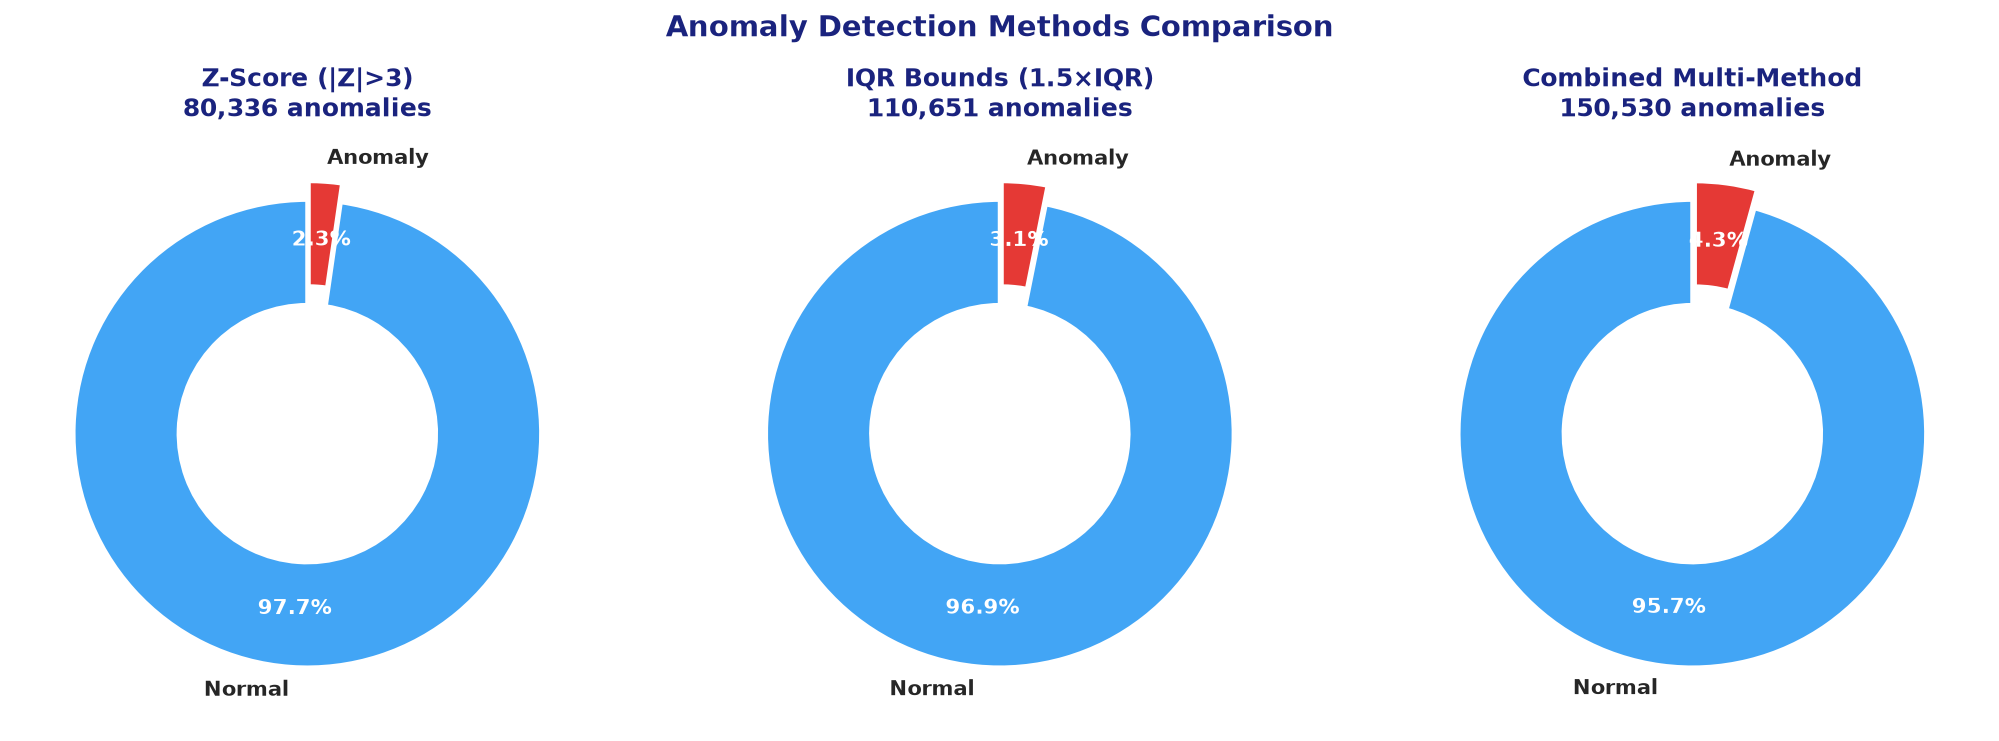

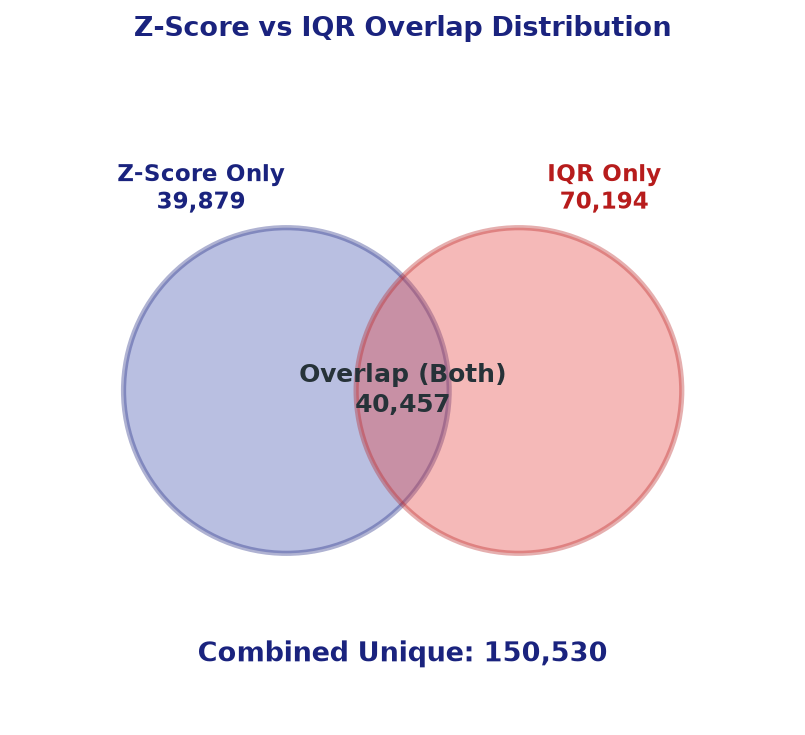

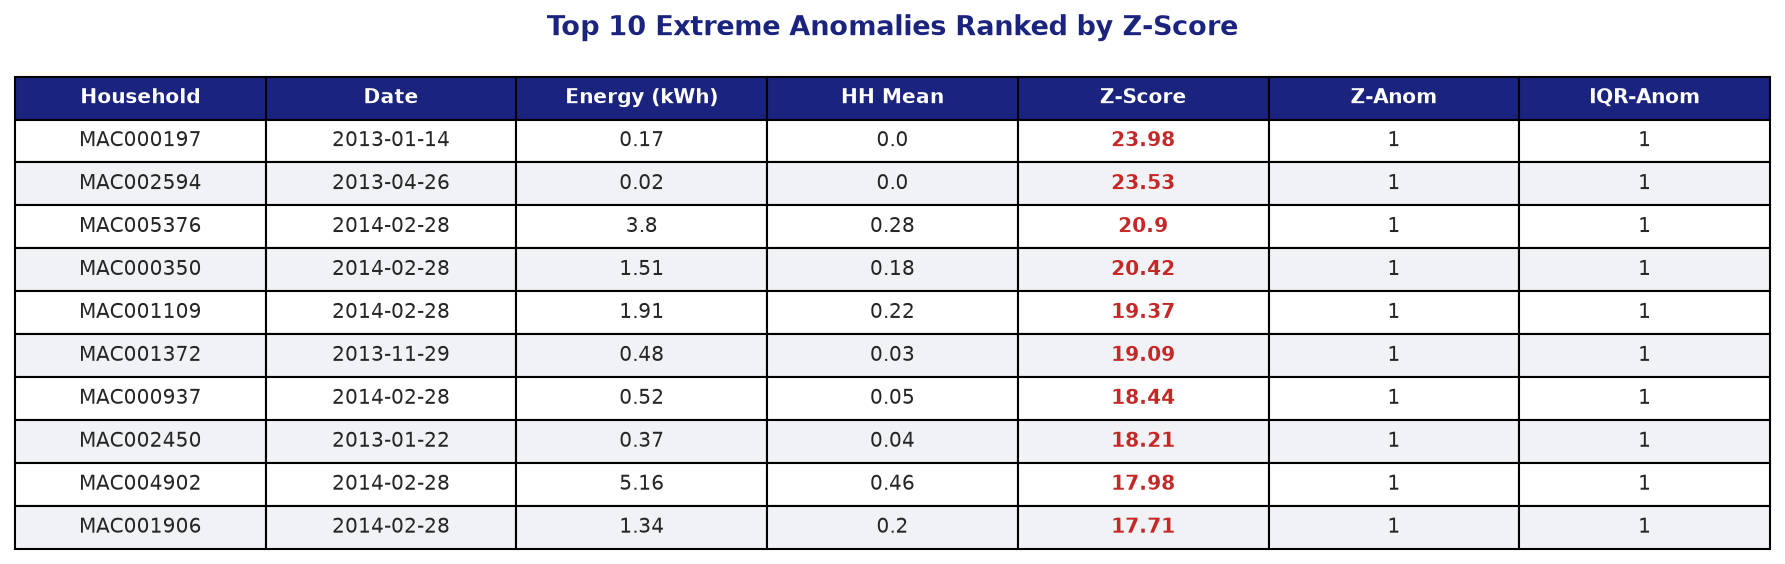

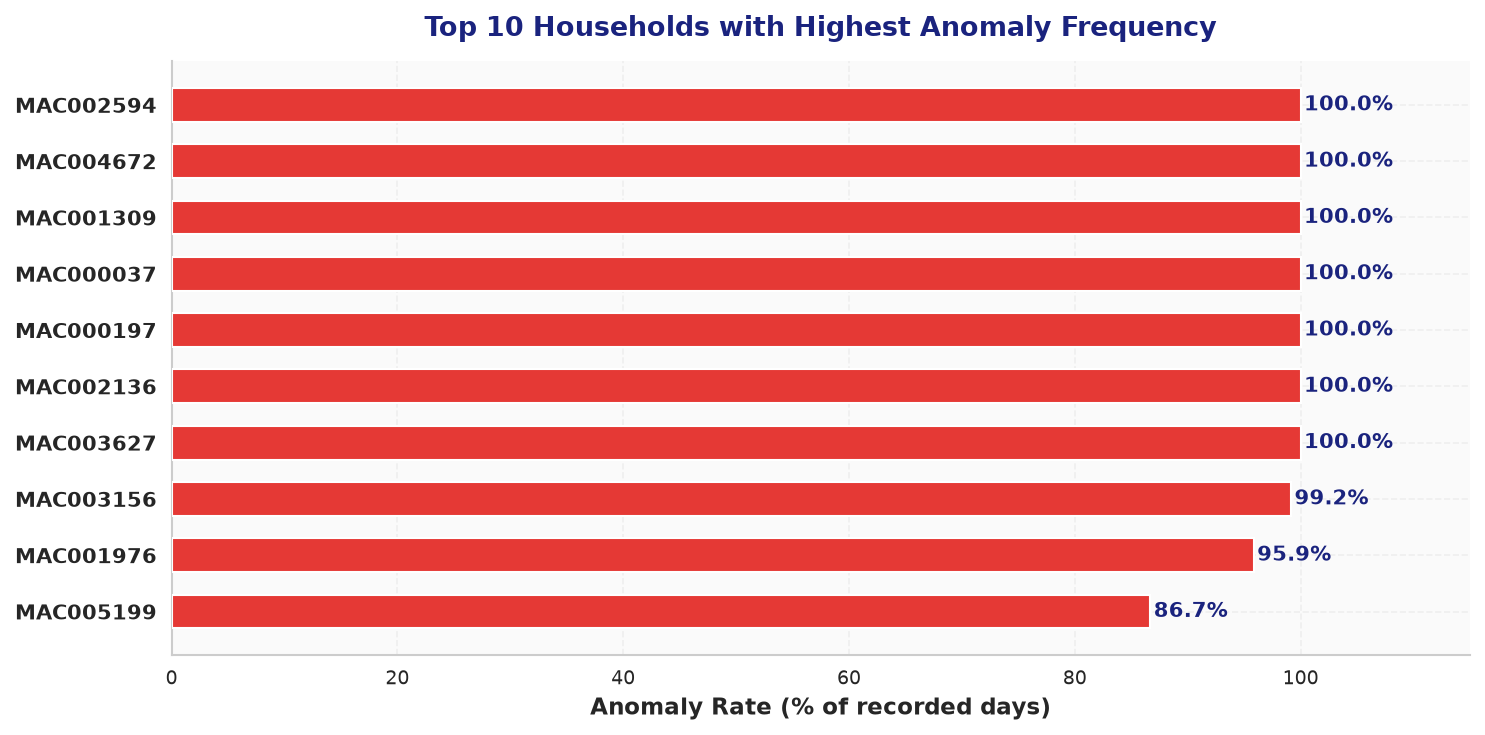

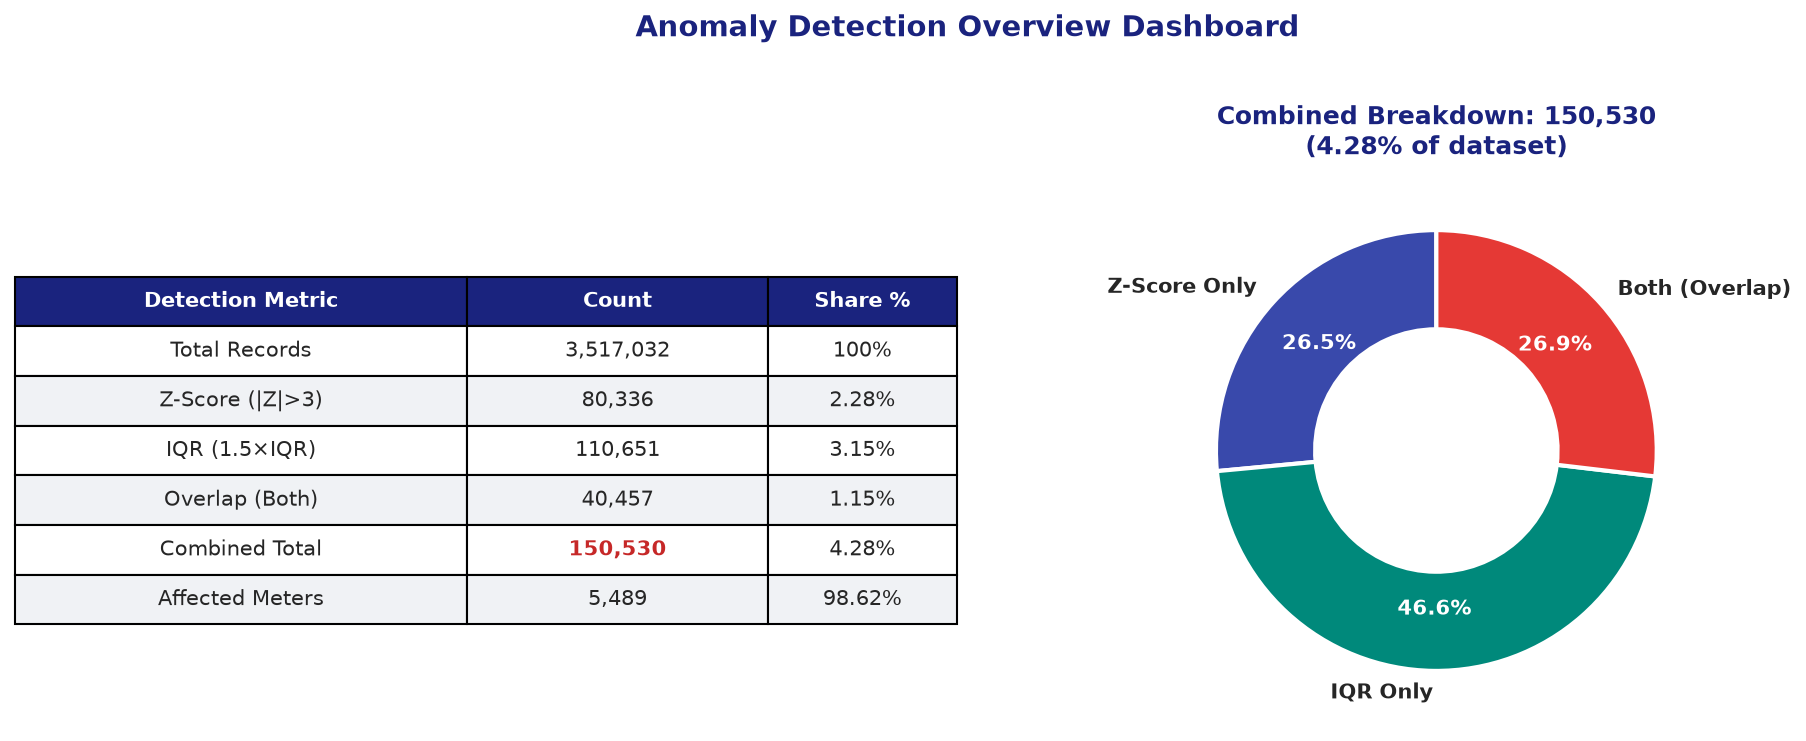

        ✅ PNG visualization saved
        ✅ HTML report saved

══════════════════════════════════════════════════════════════
  ✅ ANOMALY DETECTION  |  COMPLETE
──────────────────────────────────────────────────────────────
  • Total Records    : 3,517,032
  • Z-Score (3σ)     : 80,336 (2.28%)
  • IQR (1.5×IQR)    : 110,651 (3.15%)
  • Overlap (Both)   : 40,457 (1.15%)
  • Combined Total   : 150,530 (4.28%)
  • Affected Meters  : 5,489 (98.62%)
──────────────────────────────────────────────────────────────
  • Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 6
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 6/task06_anomaly_20260827_050015.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 6/task06_anomaly_20260827_050015.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\pr

In [16]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
try:
    spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
except Exception as _spark_err:
    print(f" ⚠️ Spark session unavailable: {_spark_err}")
    print("  💡 Run Cell 1 first to initialize Spark session.")
    raise RuntimeError("Spark session not available. Run Cell 1 first.") from _spark_err
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 16: TASK 6 – ANOMALY DETECTION PIPELINE
#   Multi-Method Anomaly Detection (Z-Score + IQR + Extreme)
# ============================================================
import builtins
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import os
import shutil
import io
import sys
import warnings
from datetime import datetime
from contextlib import redirect_stdout, redirect_stderr
from pyspark.sql.functions import (
    col, avg, stddev, when, abs as spark_abs, desc, count, 
    sum as spark_sum, expr, lit, broadcast
)
from pyspark.sql.types import IntegerType

warnings.filterwarnings('ignore')

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 6')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: remove previous run outputs ──────────────────────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

# ── Matplotlib Premium Style ─────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.edgecolor': '#cccccc',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans'],
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Timestamp & Header ───────────────────────────────────────────
timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"ANOMALY DETECTION  |  {timestamp}", "🔍")

# Validate input
if 'daily_clean' not in globals():
    _err("'daily_clean' is not defined!")
    print("        💡 Run previous cells first to create 'daily_clean' DataFrame.")
    raise NameError("'daily_clean' not found. Please run previous cells first.")

n_rows = daily_clean.count()
n_cols = len(daily_clean.columns)
print(f"        • Input Records : {n_rows:,}")
print(f"        • Features Count: {n_cols}")

# ── Helpers for clean execution ──────────────────────────────────
def silent_count(df):
    dummy = io.StringIO()
    with redirect_stdout(dummy), redirect_stderr(dummy):
        return df.count()

def silent_collect(df):
    dummy = io.StringIO()
    with redirect_stdout(dummy), redirect_stderr(dummy):
        return df.collect()

# ════════════════════════════════════════════════════════════
# [1/6] Compute household baseline statistics
# ════════════════════════════════════════════════════════════
_sec('1/6', 'Computing household baseline statistics', '📊')

household_stats = daily_clean.groupBy("LCLid").agg(
    avg("energy_mean").alias("hh_mean"),
    stddev("energy_mean").alias("hh_std"),
    avg("energy_max").alias("hh_max_avg"),
    stddev("energy_max").alias("hh_max_std"),
    count("*").alias("hh_days")
).cache()
household_stats.count()

hh_count = silent_count(household_stats)
print(f"        • Analyzed Households: {hh_count:,}")
_ok("Household baseline profiles cached")

# ════════════════════════════════════════════════════════════
# [2/6] Z-Score Anomaly Thresholds
# ════════════════════════════════════════════════════════════
_sec('2/6', 'Computing Z-Score anomaly thresholds', '📈')

anomaly_data = daily_clean.join(broadcast(household_stats), "LCLid") \
    .withColumn("zscore_mean",
        when(col("hh_std") > 0, (col("energy_mean") - col("hh_mean")) / col("hh_std"))
        .otherwise(lit(0.0))
    ) \
    .withColumn("zscore_max",
        when(col("hh_max_std") > 0, (col("energy_max") - col("hh_max_avg")) / col("hh_max_std"))
        .otherwise(lit(0.0))
    ) \
    .withColumn("is_anomaly_zscore",
        when(spark_abs(col("zscore_mean")) > 3.0, lit(1))
        .when(spark_abs(col("zscore_max")) > 3.0, lit(1))
        .when(col("energy_mean") < col("hh_mean") * 0.1, lit(1))
        .otherwise(lit(0))
    )

print("        • Mean Threshold : |Z-score| > 3.0")
print("        • Peak Threshold : |Z-score| > 3.0")
print("        • Zero/Drop Load : < 10% Household Mean")
_ok("Z-Score evaluation applied")

# ════════════════════════════════════════════════════════════
# [3/6] IQR Anomaly Bounds
# ════════════════════════════════════════════════════════════
_sec('3/6', 'Computing IQR anomaly bounds', '📐')

anomaly_iqr = daily_clean.groupBy("LCLid").agg(
    expr("percentile_approx(energy_mean, 0.25)").alias("q1"),
    expr("percentile_approx(energy_mean, 0.75)").alias("q3"),
    expr("percentile_approx(energy_mean, 0.05)").alias("p5"),
    expr("percentile_approx(energy_mean, 0.95)").alias("p95")
).select(
    "LCLid",
    (col("q1") - 1.5 * (col("q3") - col("q1"))).alias("lower_bound"),
    (col("q3") + 1.5 * (col("q3") - col("q1"))).alias("upper_bound"),
    col("p5").alias("extreme_lower"),
    col("p95").alias("extreme_upper")
)

anomaly_data = anomaly_data.join(broadcast(anomaly_iqr), "LCLid") \
    .withColumn("is_anomaly_iqr",
        when((col("energy_mean") < col("lower_bound")) | 
             (col("energy_mean") > col("upper_bound")), lit(1))
        .otherwise(lit(0))
    ) \
    .withColumn("is_extreme",
        when((col("energy_mean") < col("extreme_lower")) | 
             (col("energy_mean") > col("extreme_upper")), lit(1))
        .otherwise(lit(0))
    )

print("        • IQR Multiplier : 1.5 × IQR (Q1 - 1.5×IQR / Q3 + 1.5×IQR)")
print("        • Extreme Bounds : 5th - 95th Percentile")
_ok("IQR bounds calculated and merged")

# ════════════════════════════════════════════════════════════
# [4/6] Combine Multi-Method Anomalies
# ════════════════════════════════════════════════════════════
_sec('4/6', 'Combining multi-method detections', '🔗')

anomaly_data = anomaly_data.withColumn(
    "is_anomaly",
    when(
        (col("is_anomaly_zscore") == 1) | (col("is_anomaly_iqr") == 1),
        lit(1)
    ).otherwise(lit(0))
).cache()
anomaly_data.count()

record_count = silent_count(anomaly_data)
print(f"        • Total Evaluated Records: {record_count:,}")
_ok("Composite anomaly flags generated")

# ════════════════════════════════════════════════════════════
# [5/6] Aggregate Summary Statistics
# ════════════════════════════════════════════════════════════
_sec('5/6', 'Aggregating summary statistics', '📋')

stats_df = anomaly_data.agg(
    count("*").alias("total"),
    spark_sum("is_anomaly_zscore").alias("z"),
    spark_sum("is_anomaly_iqr").alias("iqr"),
    spark_sum("is_anomaly").alias("combined"),
    spark_sum("is_extreme").alias("extreme"),
    spark_sum(when((col("is_anomaly_zscore") == 1) & (col("is_anomaly_iqr") == 1), 1).otherwise(0)).alias("overlap")
).cache()
stats = silent_collect(stats_df)[0]
stats_df.unpersist()

total = stats["total"]
z_count = stats["z"]
iqr_count = stats["iqr"]
combined = stats["combined"]
extreme = stats["extreme"]
overlap = stats["overlap"]

affected = silent_count(anomaly_data.filter(col("is_anomaly") == 1).select("LCLid").distinct())
z_only = z_count - overlap
iqr_only = iqr_count - overlap

z_anomaly_pct = (z_count / combined * 100) if combined > 0 else 0
iqr_anomaly_pct = (iqr_count / combined * 100) if combined > 0 else 0
overlap_anomaly_pct = (overlap / combined * 100) if combined > 0 else 0

print(f"        • Total Records     : {total:,}")
print(f"        • Z-Score Anomalies : {z_count:,} ({z_count/total*100:.2f}%)")
print(f"        • IQR Anomalies     : {iqr_count:,} ({iqr_count/total*100:.2f}%)")
print(f"        • Overlap (Both)    : {overlap:,} ({overlap/total*100:.2f}%)")
print(f"        • Combined Anomalies: {combined:,} ({combined/total*100:.2f}%)")
print(f"        • Affected Meters   : {affected:,} ({affected/hh_count*100:.2f}%)")

# ════════════════════════════════════════════════════════════
# [6/6] Save Output Artifacts (CSV, PNG, HTML)
# ════════════════════════════════════════════════════════════
_sec('6/6', 'Saving output artifacts', '💾')

cols = ["LCLid", "day", "energy_mean", "energy_max", "hh_mean", "hh_std", 
        "zscore_mean", "zscore_max", "lower_bound", "upper_bound", 
        "is_anomaly_zscore", "is_anomaly_iqr", "is_anomaly"]

if "stdorToU" in anomaly_data.columns:
    cols.insert(2, "stdorToU")

export_df = anomaly_data.select(*cols)
if total > 1000000:
    export_df = export_df.sample(False, 0.1, seed=42)
    _csv_suffix = "sample"
else:
    _csv_suffix = "full"

# Write CSV directly to its final path — same approach as every other task
# (Task 5 etc.): convert to pandas once and call to_csv(). No intermediate
# Spark part-file directory is created, so there is nothing to move or delete.
csv_file = f"{output_dir}/task06_anomaly_{timestamp}.csv"
export_df.toPandas().to_csv(csv_file, index=False)

# Summary DataFrame
summary_df = pd.DataFrame({
    'Metric': ['Total', 'Z-Score', 'IQR', 'Overlap', 'Combined', 'Extreme', 'Households'],
    'Count': [total, z_count, iqr_count, overlap, combined, extreme, affected],
    'Pct': [100, z_count/total*100, iqr_count/total*100, overlap/total*100, 
            combined/total*100, extreme/total*100, affected/hh_count*100]
})
summary_df['Display'] = summary_df['Count'].astype(str) + ' (' + summary_df['Pct'].round(2).astype(str) + '%)'
_ok("CSV dataset written")

# ── Top 10 Anomalies extraction ───────────────────────────────────
sample_df = anomaly_data.filter(col("is_anomaly") == 1) \
    .select("LCLid", "day", "energy_mean", "hh_mean", "zscore_mean", 
            "is_anomaly_zscore", "is_anomaly_iqr") \
    .orderBy(spark_abs(col("zscore_mean")).desc()).limit(10).cache()
sample = sample_df.toPandas()
sample_df.unpersist()

# ── Top 10 Households with highest anomaly rate ──────────────────
rates = anomaly_data.groupBy("LCLid").agg(
    (avg("is_anomaly") * 100).alias("rate"),
    count("*").alias("days"),
    spark_sum("is_anomaly").alias("anomaly_days")
).orderBy(desc("rate")).limit(10).cache()
rates_pd = rates.toPandas()
rates.unpersist()
rates = rates_pd

# ════════════════════════════════════════════════════════════
# BUILD ALL VISUALIZATIONS IN MEMORY → SAVE SINGLE PNG
# ════════════════════════════════════════════════════════════

# ── PLOT 1: Methods Comparison (Clean Donut Charts) ──────────────
fig1, axes = plt.subplots(1, 3, figsize=(14, 4.8), facecolor='white')
_pie_colors = ['#42a5f5', '#e53935']
data_pie = [
    ([total - z_count, z_count], f'Z-Score (|Z|>3)\n{z_count:,} anomalies'),
    ([total - iqr_count, iqr_count], f'IQR Bounds (1.5×IQR)\n{iqr_count:,} anomalies'),
    ([total - combined, combined], f'Combined Multi-Method\n{combined:,} anomalies')
]
for i, (vals, title) in enumerate(data_pie):
    wedges, texts, autotexts = axes[i].pie(
        vals, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
        colors=_pie_colors, startangle=90, pctdistance=0.75,
        explode=(0, 0.08), shadow=False,
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10, fontweight='bold')
    )
    for at in autotexts:
        at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(10)
    axes[i].set_title(title, fontweight='bold', fontsize=12, pad=12, color='#1a237e')
plt.suptitle('Anomaly Detection Methods Comparison', fontsize=14, fontweight='bold', color='#1a237e', y=1.02)
plt.tight_layout()
plt.show()

# ── PLOT 2: Overlap Venn ─────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(8, 5), facecolor='white')
from matplotlib.patches import Circle
ax.add_patch(Circle((-0.3, 0), 0.42, fc='#3949ab', alpha=0.35, ec='#1a237e', lw=2.5))
ax.add_patch(Circle((0.3, 0), 0.42, fc='#e53935', alpha=0.35, ec='#b71c1c', lw=2.5))
ax.text(-0.52, 0.52, f'Z-Score Only\n{z_only:,}', ha='center', va='center', fontweight='bold', fontsize=11, color='#1a237e')
ax.text(0.52, 0.52, f'IQR Only\n{iqr_only:,}', ha='center', va='center', fontweight='bold', fontsize=11, color='#b71c1c')
ax.text(0, 0, f'Overlap (Both)\n{overlap:,}', ha='center', va='center', fontweight='bold', fontsize=12, color='#263238')
ax.text(0, -0.68, f'Combined Unique: {combined:,}', ha='center', va='center', fontweight='bold', fontsize=13, color='#1a237e')
ax.set_xlim(-1, 1); ax.set_ylim(-0.85, 0.85); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Z-Score vs IQR Overlap Distribution', fontweight='bold', fontsize=13, pad=12, color='#1a237e')
plt.tight_layout()
plt.show()

# ── PLOT 3: Top Anomalies Table ──────────────────────────────────
fig3 = None
if not sample.empty:
    sample_disp = sample.copy()
    sample_disp['day'] = sample_disp['day'].astype(str)
    sample_disp['energy_mean'] = sample_disp['energy_mean'].round(2)
    sample_disp['hh_mean'] = sample_disp['hh_mean'].round(2)
    sample_disp['zscore_mean'] = sample_disp['zscore_mean'].round(2)
    sample_disp.columns = ['Household', 'Date', 'Energy (kWh)', 'HH Mean', 'Z-Score', 'Z-Anom', 'IQR-Anom']

    fig3, ax = plt.subplots(figsize=(12, 3.8), facecolor='white')
    ax.axis('tight'); ax.axis('off')
    table = ax.table(cellText=sample_disp.values, colLabels=sample_disp.columns, 
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(9.5); table.scale(1, 1.8)
    for i in range(len(sample_disp.columns)):
        table[(0, i)].set_facecolor('#1a237e')
        table[(0, i)].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(sample_disp) + 1):
        for j in range(len(sample_disp.columns)):
            table[(i, j)].set_facecolor('#f0f2f5' if i % 2 == 0 else '#ffffff')
            if j == 4:
                table[(i, j)].set_text_props(color='#c62828', fontweight='bold')
    plt.suptitle('Top 10 Extreme Anomalies Ranked by Z-Score', fontweight='bold', fontsize=13, color='#1a237e', y=0.98)
    plt.tight_layout()
    plt.show()

# ── PLOT 4: Household Rates ──────────────────────────────────────
fig4 = None
if not rates.empty:
    rates.columns = ['LCLid', 'Rate %', 'Days', 'Anomaly Days']
    fig4, ax = plt.subplots(figsize=(10, 5), facecolor='white')
    y = np.arange(len(rates))
    bars = ax.barh(y, rates['Rate %'], color='#e53935', edgecolor='white', height=0.6, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(rates['LCLid'], fontsize=10, fontweight='bold'); ax.invert_yaxis()
    ax.set_xlabel('Anomaly Rate (% of recorded days)', fontweight='bold', fontsize=11)
    ax.set_title('Top 10 Households with Highest Anomaly Frequency', fontweight='bold', fontsize=13, pad=12, color='#1a237e')
    for bar, rate in zip(bars, rates['Rate %']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{rate:.1f}%', va='center', fontweight='bold', color='#1a237e', fontsize=10)
    _max_val = float(rates['Rate %'].max()) if not rates.empty and rates['Rate %'].max() > 0 else 10.0
    ax.set_xlim(0, _max_val * 1.15)
    plt.tight_layout()
    plt.show()

# ── PLOT 5: Dashboard ────────────────────────────────────────────
fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), facecolor='white')
ax1.axis('tight'); ax1.axis('off')
table_data = [['Total Records', f'{total:,}', '100%'],
              ['Z-Score (|Z|>3)', f'{z_count:,}', f'{z_count/total*100:.2f}%'],
              ['IQR (1.5×IQR)', f'{iqr_count:,}', f'{iqr_count/total*100:.2f}%'],
              ['Overlap (Both)', f'{overlap:,}', f'{overlap/total*100:.2f}%'],
              ['Combined Total', f'{combined:,}', f'{combined/total*100:.2f}%'],
              ['Affected Meters', f'{affected:,}', f'{affected/hh_count*100:.2f}%']]
table1 = ax1.table(cellText=table_data, colLabels=['Detection Metric', 'Count', 'Share %'],
                   cellLoc='center', loc='center', colWidths=[0.48, 0.32, 0.20])
table1.auto_set_font_size(False); table1.set_fontsize(10); table1.scale(1, 2)
for i in range(3): 
    table1[(0, i)].set_facecolor('#1a237e')
    table1[(0, i)].set_text_props(color='white', fontweight='bold')
for i in range(1, 7):
    for j in range(3):
        table1[(i, j)].set_facecolor('#f0f2f5' if i % 2 == 0 else '#ffffff')
        if j == 1 and i == 5:
            table1[(i, j)].set_text_props(color='#c62828', fontweight='bold')

breakdown = [z_only, iqr_only, overlap]
labels_b = ['Z-Score Only', 'IQR Only', 'Both (Overlap)']
colors_b = ['#3949ab', '#00897b', '#e53935']
non_zero = [(l, c) for l, c in zip(labels_b, breakdown) if c > 0]
if non_zero:
    lbl, vals = zip(*non_zero)
    wedges, texts, autotexts = ax2.pie(
        vals, labels=lbl, autopct='%1.1f%%', colors=colors_b[:len(lbl)],
        startangle=90, pctdistance=0.72,
        wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10, fontweight='bold')
    )
    for at in autotexts:
        at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(10)
ax2.set_title(f'Combined Breakdown: {combined:,}\n({combined/total*100:.2f}% of dataset)', fontweight='bold', fontsize=12, pad=10, color='#1a237e')
plt.suptitle('Anomaly Detection Overview Dashboard', fontsize=14, fontweight='bold', color='#1a237e', y=1.02)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# CONSOLIDATE ALL FIGURES INTO SINGLE PNG (NO INTERMEDIATE FILES)
# ════════════════════════════════════════════════════════════
all_figs = [fig1, fig2]
if fig3 is not None: all_figs.append(fig3)
if fig4 is not None: all_figs.append(fig4)
all_figs.append(fig5)

import matplotlib.image as _mpimg
_n = len(all_figs)
_nc = 2; _nr = (_n + _nc - 1) // _nc
_fg, _ax = plt.subplots(_nr, _nc, figsize=(_nc * 10, _nr * 6), facecolor='white')
_ax = _ax.flatten()

for _i, _fig in enumerate(all_figs):
    _buf = io.BytesIO()
    _fig.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    _img = _mpimg.imread(_buf)
    _ax[_i].imshow(_img); _ax[_i].axis('off')
    plt.close(_fig)

for _j in range(_n, len(_ax)): _ax[_j].set_visible(False)
plt.tight_layout(pad=0.5)

_final_png = f'{output_dir}/task06_anomaly_{timestamp}.png'
plt.savefig(_final_png, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(_fg)
_ok("PNG visualization saved")

# ════════════════════════════════════════════════════════════
# Generate Top 10 Anomalies & Households HTML Rows
# ════════════════════════════════════════════════════════════
_top10_rows = ""
if not sample.empty:
    for _, _r in sample.iterrows():
        _top10_rows += f"""
        <tr>
            <td><strong>{_r['LCLid']}</strong></td>
            <td>{str(_r['day'])[:10]}</td>
            <td>{_r['energy_mean']:.2f} kWh</td>
            <td>{_r['hh_mean']:.2f} kWh</td>
            <td style="color:var(--danger);font-weight:700;">{_r['zscore_mean']:.2f}</td>
            <td>{'<span class="bdg red">Yes</span>' if _r['is_anomaly_zscore']==1 else '<span style="color:var(--mu);">No</span>'}</td>
            <td>{'<span class="bdg red">Yes</span>' if _r['is_anomaly_iqr']==1 else '<span style="color:var(--mu);">No</span>'}</td>
        </tr>"""

_hh_rows = ""
if not rates.empty:
    for _, _r in rates.iterrows():
        _rate_val = float(_r['Rate %']) if pd.notnull(_r['Rate %']) else 0.0
        _bar_w = builtins.min(100.0, builtins.max(0.0, _rate_val))
        _hh_rows += f"""
        <div class="feat-row">
            <div class="feat-name"><strong>{_r['LCLid']}</strong> ({int(_r['Anomaly Days'])} / {int(_r['Days'])} days)</div>
            <div class="feat-bar-wrap"><div class="feat-bar" style="width:{_bar_w:.1f}%;background:linear-gradient(90deg, #e53935 0%, #b71c1c 100%);"></div></div>
            <div class="feat-val" style="color:var(--danger);">{_r['Rate %']:.1f}%</div>
        </div>"""

# ════════════════════════════════════════════════════════════
# Generate Unified HTML Report
# ════════════════════════════════════════════════════════════
combined_pct = combined / total * 100
z_pct = z_count / total * 100
iqr_pct = iqr_count / total * 100
overlap_pct = overlap / total * 100
extreme_pct = extreme / total * 100
affected_pct = affected / hh_count * 100
verify_icon = '✅' if combined == z_count + iqr_count - overlap else '❌'

z_only_pct = (z_only / combined * 100) if combined > 0 else 0
iqr_only_pct = (iqr_only / combined * 100) if combined > 0 else 0

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Anomaly Detection Report — {timestamp}</title>
<style>
:root{{--p:#4a148c;--pl:#6a1b9a;--ac:#b388ff;--ok:#2e7d32;--danger:#c62828;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(74,20,140,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.bdg.red{{background:rgba(198,40,40,.35);color:#fff;border-color:rgba(255,255,255,.4)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--danger);background:linear-gradient(180deg,#fff 0%,#ffebee 100%)}}
.kpi.ok{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kv.red{{color:var(--danger)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.alert-row{{background:linear-gradient(90deg,#ffebee 0%,#ffcdd2 100%)!important;
            font-weight:600;border-left:3px solid var(--danger)}}
.verify-box{{background:linear-gradient(90deg,#e8f5e9,#f1f8e9);
             border-left:4px solid var(--ok);border-radius:8px;
             padding:16px 20px;margin-bottom:20px;
             display:flex;align-items:center;gap:12px;
             font-size:.92rem;color:#2e7d32;font-weight:500}}
.mcard-grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:16px}}
.mcard{{background:#f5f7fa;border-radius:12px;padding:20px;text-align:center;
         border:2px solid var(--bd);transition:border-color .2s}}
.mcard:hover{{border-color:var(--ac)}}
.mcard-name{{font-size:.82rem;font-weight:700;color:var(--mu);text-transform:uppercase;letter-spacing:.5px;margin-bottom:8px}}
.mcard-val{{font-size:1.7rem;font-weight:800;color:var(--p);margin-bottom:4px}}
.mcard-sub{{font-size:.78rem;color:var(--mu)}}
.feat-row{{display:flex;align-items:center;padding:8px 0;border-bottom:1px solid #f0f0f0}}
.feat-name{{width:280px;font-size:.88rem;font-weight:500;flex-shrink:0}}
.feat-bar-wrap{{flex:1;height:18px;background:#eceff1;border-radius:9px;
                overflow:hidden;margin:0 12px}}
.feat-bar{{height:100%;border-radius:9px;
           background:linear-gradient(90deg,var(--ac) 0%,var(--pl) 100%)}}
.feat-val{{width:64px;text-align:right;font-weight:700;color:var(--p);font-size:.88rem;flex-shrink:0}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>🔍 Anomaly Detection Report</h1>
  <p>Energy Consumption Analysis · Multi-Method Detection · PySpark ML</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg red">🔥 {combined:,} Anomalies ({combined_pct:.2f}%)</span>
    <span class="bdg">🏠 {hh_count:,} Households</span>
    <span class="bdg">📊 {total:,} Records</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv red">{combined:,}</div><div class="kl">Combined Anomalies</div></div>
  <div class="kpi"><div class="kv">{z_count:,}</div><div class="kl">Z-Score Anomalies</div></div>
  <div class="kpi"><div class="kv">{iqr_count:,}</div><div class="kl">IQR Anomalies</div></div>
  <div class="kpi"><div class="kv">{overlap:,}</div><div class="kl">Overlap (Both)</div></div>
  <div class="kpi ok"><div class="kv">{affected:,}</div><div class="kl">Affected Households</div></div>
  <div class="kpi"><div class="kv">{extreme:,}</div><div class="kl">Extreme Values</div></div>
</div>

<div class="verify-box">
  <span style="font-size:1.4rem">{verify_icon}</span>
  <span><strong>Formula Check:</strong> {z_count:,} (Z-Score) + {iqr_count:,} (IQR) − {overlap:,} (Overlap) = <strong>{combined:,}</strong> Combined Anomalies</span>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Detailed Statistics</div>
  <div class="tw"><table>
    <thead><tr><th>Metric</th><th>Count</th><th>Percentage</th></tr></thead>
    <tbody>
      <tr><td><strong>Total Records</strong></td><td>{total:,}</td><td>100.00%</td></tr>
      <tr><td>Z-Score Anomalies (|Z| &gt; 3.0)</td><td>{z_count:,}</td><td>{z_pct:.2f}%</td></tr>
      <tr><td>IQR Anomalies (1.5 × IQR)</td><td>{iqr_count:,}</td><td>{iqr_pct:.2f}%</td></tr>
      <tr><td>Overlap (Detected by Both)</td><td>{overlap:,}</td><td>{overlap_pct:.2f}%</td></tr>
      <tr class="alert-row"><td>🔥 Combined Anomalies</td><td>{combined:,}</td><td>{combined_pct:.2f}%</td></tr>
      <tr><td>Extreme Outliers (5% - 95%)</td><td>{extreme:,}</td><td>{extreme_pct:.2f}%</td></tr>
      <tr><td><strong>Affected Meter IDs</strong></td><td>{affected:,}</td><td>{affected_pct:.2f}%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔬 Detection Method Breakdown</div>
  <div class="mcard-grid">
    <div class="mcard"><div class="mcard-name">Z-Score Only</div><div class="mcard-val">{z_only:,}</div><div class="mcard-sub">{z_only_pct:.2f}% of anomalies</div></div>
    <div class="mcard"><div class="mcard-name">IQR Only</div><div class="mcard-val">{iqr_only:,}</div><div class="mcard-sub">{iqr_only_pct:.2f}% of anomalies</div></div>
    <div class="mcard"><div class="mcard-name">Both Methods</div><div class="mcard-val">{overlap:,}</div><div class="mcard-sub">{overlap_anomaly_pct:.2f}% of anomalies</div></div>
  </div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>⚠️ Top 10 Extreme Anomalies</div>
  <div class="tw"><table>
    <thead><tr><th>Meter ID</th><th>Date</th><th>Energy</th><th>HH Mean</th><th>Z-Score</th><th>Z-Anom</th><th>IQR-Anom</th></tr></thead>
    <tbody>{_top10_rows}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🏠 Top Households with Highest Anomaly Frequency</div>
  {_hh_rows}
</div>

<div class="foot">Generated by Anomaly Detection Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

_final_html = f"{output_dir}/task06_anomaly_{timestamp}.html"
with open(_final_html, 'w', encoding='utf-8') as f:
    f.write(html_content)
_ok("HTML report saved")

# Unpersist Spark DataFrames
household_stats.unpersist()
anomaly_data.unpersist()

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = "═" * 62
_s2 = "─" * 62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ ANOMALY DETECTION  |  COMPLETE
{_s2}
  • Total Records    : {total:,}
  • Z-Score (3σ)     : {z_count:,} ({z_count/total*100:.2f}%)
  • IQR (1.5×IQR)    : {iqr_count:,} ({iqr_count/total*100:.2f}%)
  • Overlap (Both)   : {overlap:,} ({overlap/total*100:.2f}%)
  • Combined Total   : {combined:,} ({combined/total*100:.2f}%)
  • Affected Meters  : {affected:,} ({affected/hh_count*100:.2f}%)
{_s2}
  • Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {csv_file}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")

### CELL 17: TASK 7 - Weather-Aware Models | Weather Impact Analysis
###### ============================================================
###### **Goal:** Quantify how weather variables affect household energy usage.
###### This cell performs:-
######  **-> 1. Correlation Analysis:** Heatmap between energy & weather features.
######  **-> 2. Temperature Binning:** Energy behavior across temperature ranges.
######  **-> 3. Feature Engineering:** Interaction terms (temp², temp×humidity, etc).
######  **-> 4. Linear Regression:** With interaction terms & standardized features.
######  **-> 5. Random Forest:** Feature importance ranking.
######  **-> 6. Model Diagnostics:** Actual vs Predicted + Residuals.
######  **-> Outputs:** PNG plots, CSV results, and professional HTML report.
######  **-> Models:** LinearRegression (PySpark ML) + RandomForestRegressor.



──────────────────────────────────────────────────────────────
🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  🌤️  WEATHER IMPACT ANALYSIS  |  20260827_050125
══════════════════════════════════════════════════════════════
        • Input Records : 3,517,032
        • Features Count: 78

  [1/7] 🔧 Data preparation & outlier handling
        • Energy IQR Bounds : [0.00, 24.40] kWh (Q1=4.68, Q3=12.57)
        • Filtered Outliers : 202,103 rows (5.7%)
        • Date Range        : 2011-11-23 → 2014-02-28 (828 days)
        • Train (70%)       : 2011-11-23 → 2013-06-24
        • Val   (15%)       : 2013-06-24 → 2013-10-26
        • Test  (15%)       : 2013-10-26 → 2014-02-28
        ✅ Outlier removal and temporal boundaries established

  [2/7] 📐 Feature engineering (Thermal & Non-linear)
        • Weather Features  : 34 columns
        • Target Variable

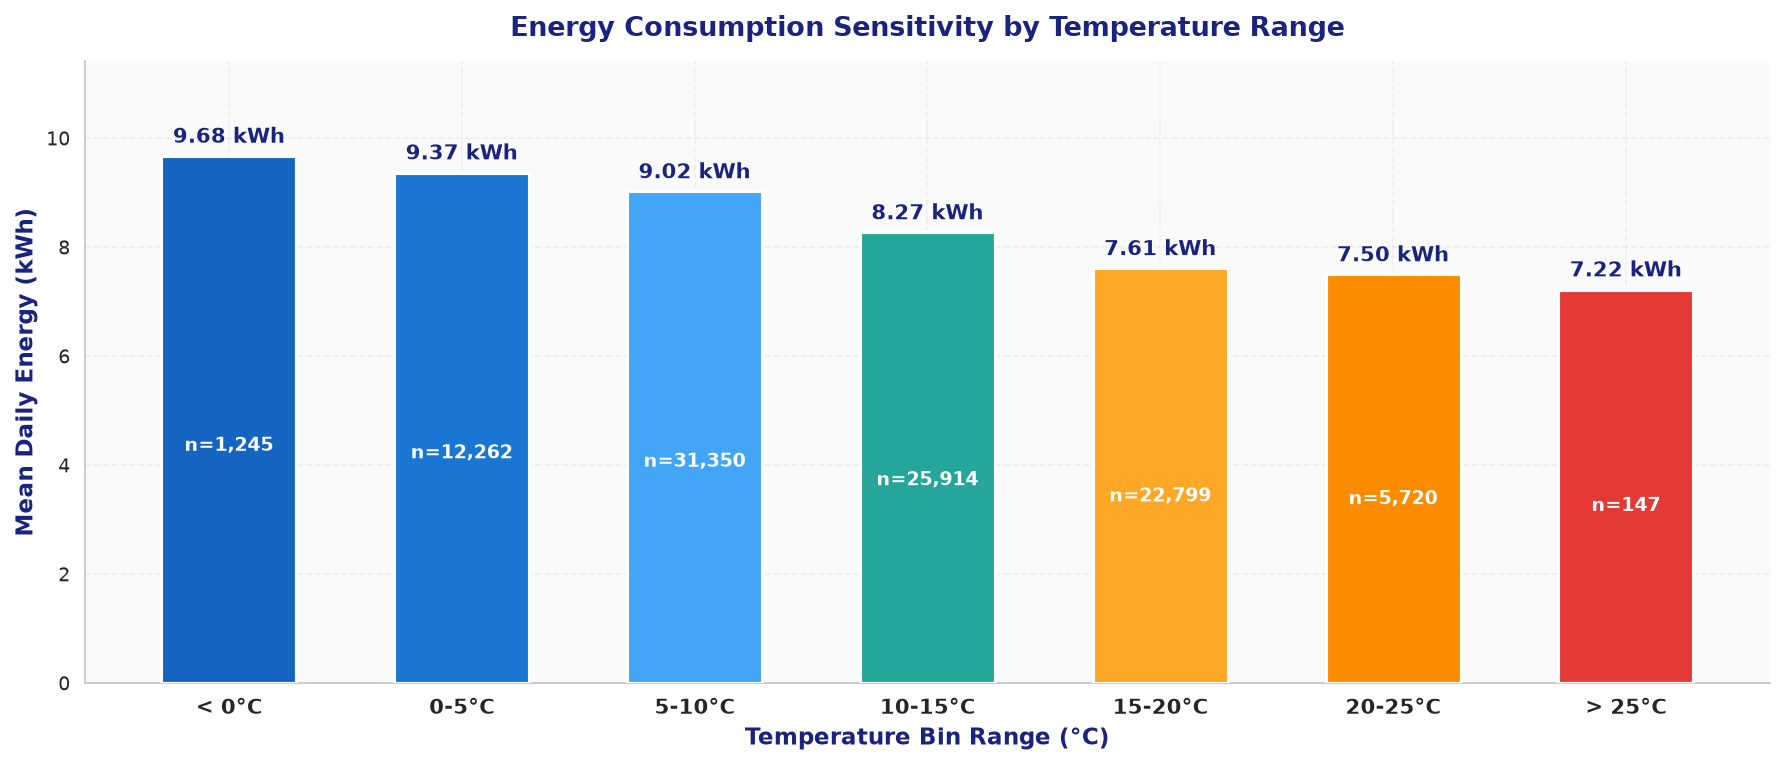

        ✅ Temperature sensitivity curve computed across 7 thermal bands

  [5/7] 📊 Weather-energy correlation matrix


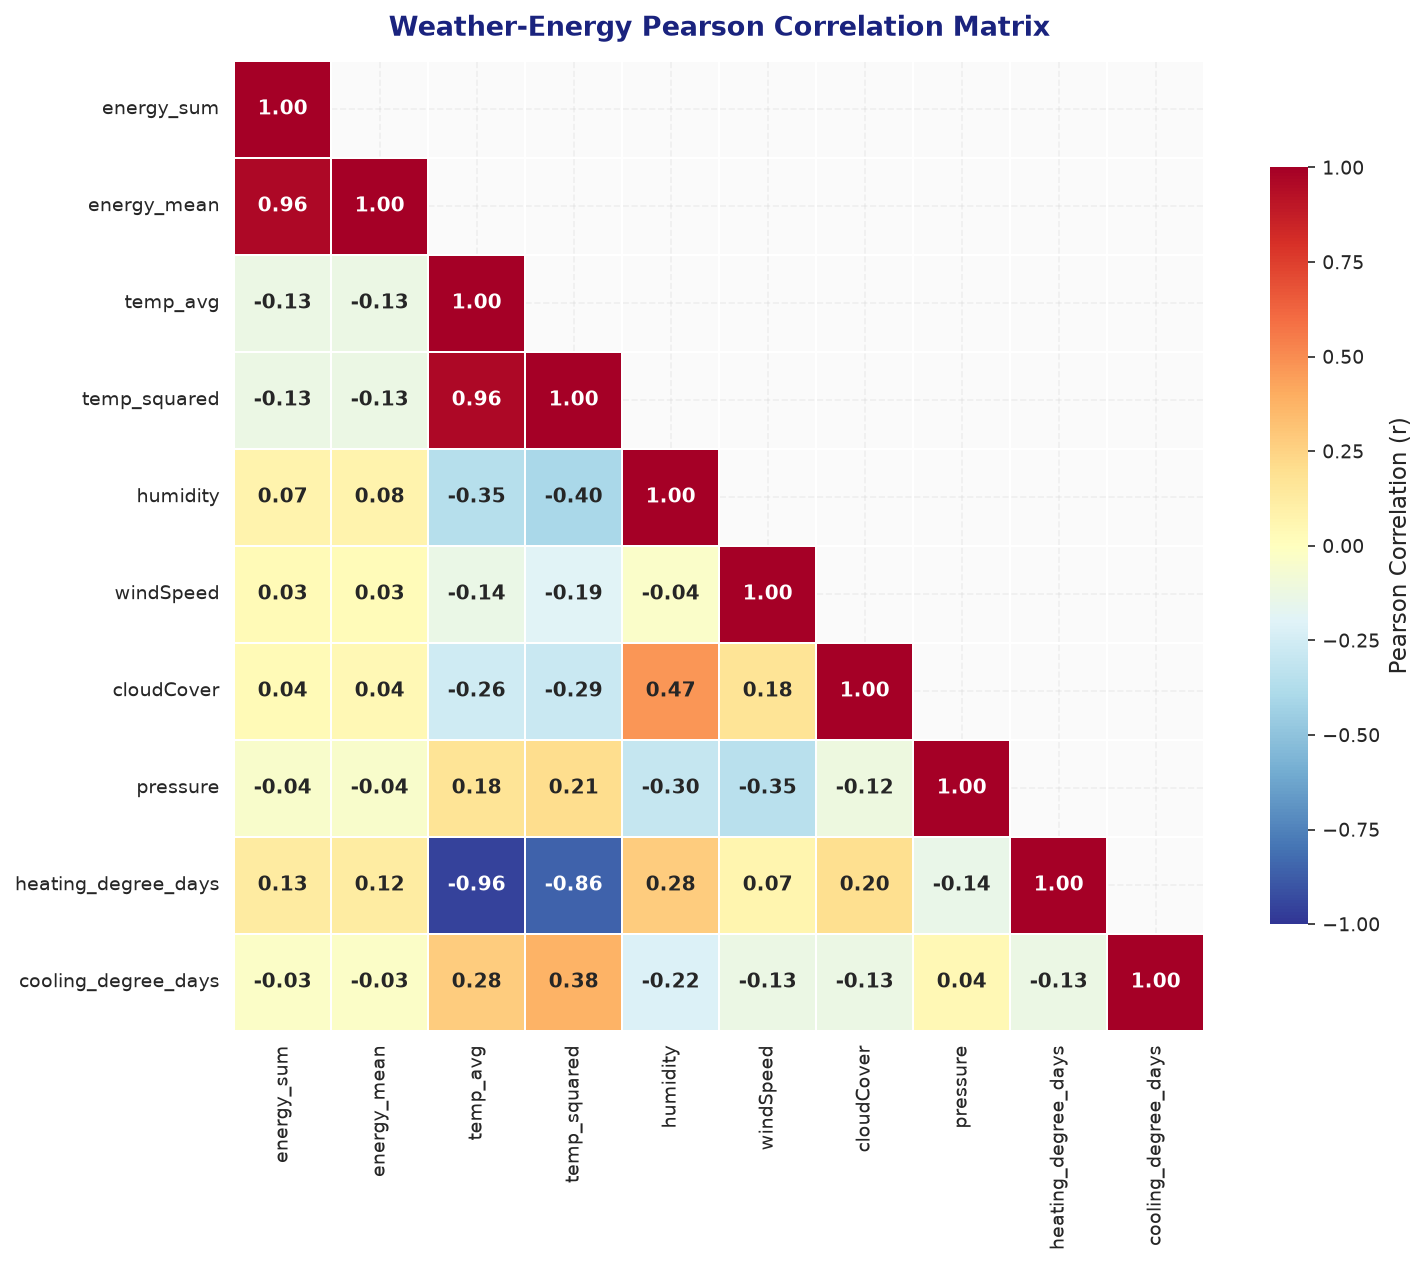

        ✅ Correlation heatmap generated from 49,910 representative points

  [6/7] 🚀 Model training & parameter optimization
        • [1/3] LinearRegression      : Val-R²=-0.0054 | Val-RMSE=0.5874 (5.5s)
        • [2/3] RandomForestRegressor : Val-R²=-0.0015 | Val-RMSE=0.5862 (11.4s)
        • [3/3] GBTRegressor          : Val-R²=-0.0077 | Val-RMSE=0.5881 (38.1s)

  [7/7] 🎯 Test evaluation & diagnostics
        • 🏆 Best Selected Model : Random Forest
        • Test Log-R² Score      : -0.0090
        • Test Log-RMSE Metric   : 0.6375
        • Test Log-MAE Metric    : 0.4962


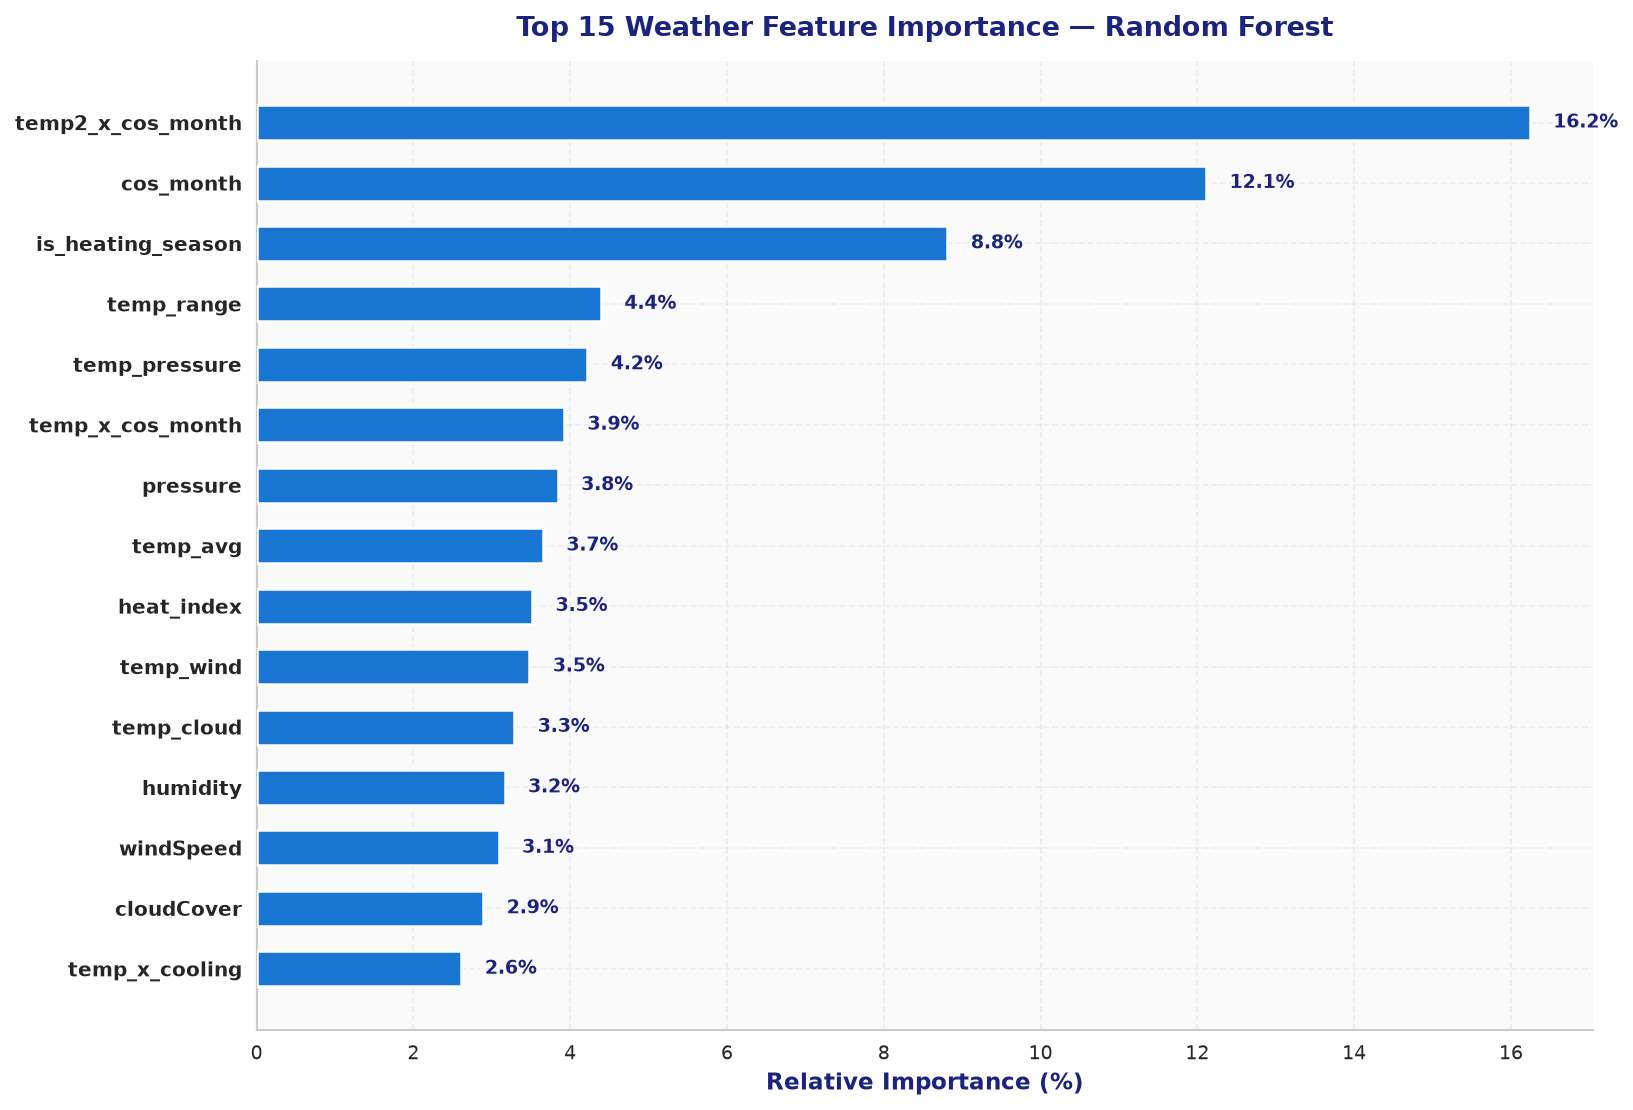

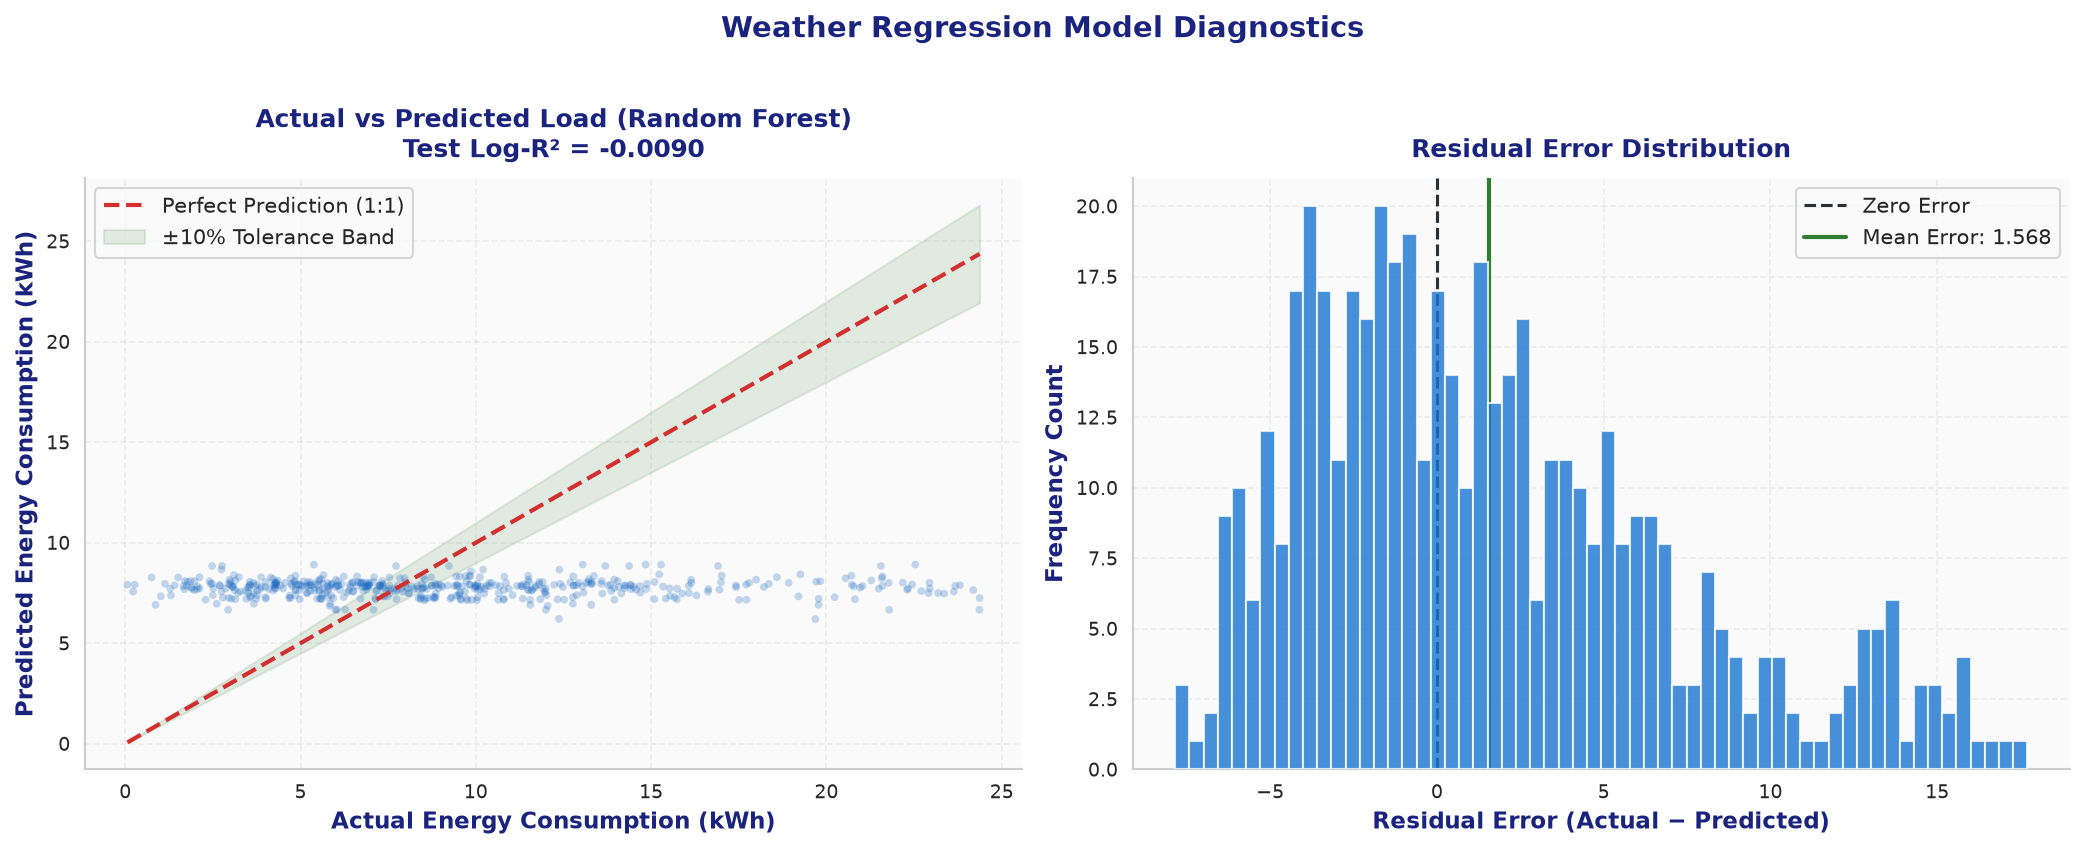


══════════════════════════════════════════════════════════════
  ✅ WEATHER IMPACT ANALYSIS  |  COMPLETE
──────────────────────────────────────────────────────────────
  • Best Model       : Random Forest
  • Test Log-R²      : -0.0090
  • Test Log-RMSE    : 0.6375
  • Test Log-MAE     : 0.4962
  • Top Feature      : temp2_x_cos_month (0.1624)
  • Execution Time   : 85.7s
──────────────────────────────────────────────────────────────
  • Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 7
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 7/task07_weather_20260827_050125.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 7/task07_weather_20260827_050125.csv
  🌐 HTML       : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\outpu

In [17]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
try:
    spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
except Exception as _spark_err:
    print(f" ⚠️ Spark session unavailable: {_spark_err}")
    print("  💡 Run Cell 1 first to initialize Spark session.")
    raise RuntimeError("Spark session not available. Run Cell 1 first.") from _spark_err
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 17: TASK 7 – WEATHER-AWARE MODELS & IMPACT ANALYSIS
#   Regression with Weather Features (LinearRegression | RF | GBT)
# ============================================================
import builtins
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as mgridspec
import seaborn as sns
import os
import io
import sys
import shutil
import logging
import warnings
from datetime import datetime
from pyspark.sql.functions import (
    col, when, expr, rand, min as spark_min, max as spark_max,
    sin, cos, radians, month as spark_month, dayofweek, abs as spark_abs,
    log1p, expm1
)
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

warnings.filterwarnings('ignore')

# ── Suppress Spark noise ─────────────────────────────────────────
logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)
logging.getLogger("org.apache.spark").setLevel(logging.ERROR)

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 7')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: remove previous run outputs ──────────────────────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

# ── Matplotlib Premium Style ─────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.edgecolor': '#cccccc',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans'],
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Figures are displayed inline as before, but are kept in memory (not saved
# as individual PNG files) so they can be merged straight into one final
# dashboard image — no per-chart files are ever written to disk, so there
# is nothing left over to rename, move, or delete afterwards.
_all_figs = []

def show_and_save(fig, name):
    plt.show()
    _all_figs.append((name, fig))

start_time = time.time()
timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"WEATHER IMPACT ANALYSIS  |  {timestamp}", "🌤️")

# Validate input
if 'daily_clean' not in globals():
    _err("'daily_clean' is not defined!")
    print("        💡 Run previous cells first to create 'daily_clean' DataFrame.")
    raise NameError("'daily_clean' not found. Please run previous cells first.")

n_rows = daily_clean.count()
n_cols = len(daily_clean.columns)
print(f"        • Input Records : {n_rows:,}")
print(f"        • Features Count: {n_cols}")

# ════════════════════════════════════════════════════════════
# [1/7] Data Preparation & Outlier Handling
# ════════════════════════════════════════════════════════════
_sec('1/7', 'Data preparation & outlier handling', '🔧')

essential_cols = [
    "LCLid", "day", "energy_sum", "energy_mean", "energy_max",
    "temperatureMax", "temperatureMin", "humidity", "windSpeed",
    "cloudCover", "pressure", "dewPoint",
    "month", "season", "is_weekend", "is_holiday", "stdorToU", "Acorn_grouped"
]
available_cols = [c for c in essential_cols if c in daily_clean.columns]

weather_df = daily_clean.select(*available_cols).filter(col("temperatureMax").isNotNull())
weather_df = weather_df.filter(col("energy_sum") >= 0)

# IQR outlier removal
energy_stats = weather_df.select(
    expr('percentile_approx(energy_sum, 0.25)').alias('q1'),
    expr('percentile_approx(energy_sum, 0.75)').alias('q3')
).collect()[0]

q1, q3 = energy_stats['q1'], energy_stats['q3']
iqr = q3 - q1
lower_bound = builtins.max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

weather_df_clean = weather_df.filter(
    (col("energy_sum") >= lower_bound) & (col("energy_sum") <= upper_bound)
)

removed = weather_df.count() - weather_df_clean.count()
print(f"        • Energy IQR Bounds : [{lower_bound:.2f}, {upper_bound:.2f}] kWh (Q1={q1:.2f}, Q3={q3:.2f})")
print(f"        • Filtered Outliers : {removed:,} rows ({removed/weather_df.count()*100:.1f}%)")

# Date bounds
date_bounds = weather_df_clean.select(
    spark_min("day").alias("min_date"),
    spark_max("day").alias("max_date")
).collect()[0]

min_date = date_bounds["min_date"]
max_date = date_bounds["max_date"]
total_days = (max_date - min_date).days

# 70/15/15 split
split_train = min_date + pd.Timedelta(days=int(total_days * 0.70))
split_val = min_date + pd.Timedelta(days=int(total_days * 0.85))

def fmt_date(d):
    if hasattr(d, 'date'):
        return d.date()
    return d

print(f"        • Date Range        : {fmt_date(min_date)} → {fmt_date(max_date)} ({total_days} days)")
print(f"        • Train (70%)       : {fmt_date(min_date)} → {fmt_date(split_train)}")
print(f"        • Val   (15%)       : {fmt_date(split_train)} → {fmt_date(split_val)}")
print(f"        • Test  (15%)       : {fmt_date(split_val)} → {fmt_date(max_date)}")
_ok("Outlier removal and temporal boundaries established")

# ════════════════════════════════════════════════════════════
# [2/7] Feature Engineering
# ════════════════════════════════════════════════════════════
_sec('2/7', 'Feature engineering (Thermal & Non-linear)', '📐')

weather_features = weather_df_clean \
    .withColumn("temp_avg", (col("temperatureMax") + col("temperatureMin")) / 2) \
    .withColumn("temp_range", col("temperatureMax") - col("temperatureMin")) \
    .withColumn("temp_squared", col("temp_avg") ** 2) \
    .withColumn("temp_cubed", col("temp_avg") ** 3) \
    .withColumn("temp_humidity", col("temp_avg") * col("humidity")) \
    .withColumn("temp_wind", col("temp_avg") * col("windSpeed")) \
    .withColumn("temp_cloud", col("temp_avg") * col("cloudCover")) \
    .withColumn("temp_pressure", col("temp_avg") * col("pressure")) \
    .withColumn("heating_degree_days", when(col("temp_avg") < 15, 15 - col("temp_avg")).otherwise(0)) \
    .withColumn("cooling_degree_days", when(col("temp_avg") > 22, col("temp_avg") - 22).otherwise(0)) \
    .withColumn("hdd_squared", col("heating_degree_days") ** 2) \
    .withColumn("cdd_squared", col("cooling_degree_days") ** 2) \
    .withColumn("wind_chill", 
        when(col("temp_avg") < 10, 
             13.12 + 0.6215*col("temp_avg") - 11.37*(col("windSpeed")**0.16) + 0.3965*col("temp_avg")*(col("windSpeed")**0.16))
        .otherwise(col("temp_avg"))) \
    .withColumn("heat_index",
        when((col("temp_avg") > 27) & (col("humidity") > 40),
             -42.379 + 2.04901523*col("temp_avg") + 10.14333127*col("humidity") 
             - 0.22475541*col("temp_avg")*col("humidity") - 6.83783e-3*col("temp_avg")**2
             - 5.481717e-2*col("humidity")**2 + 1.22874e-3*col("temp_avg")**2*col("humidity")
             + 8.5282e-4*col("temp_avg")*col("humidity")**2 - 1.99e-6*col("temp_avg")**2*col("humidity")**2)
        .otherwise(col("temp_avg"))) \
    .withColumn("month_rad", radians(col("month") * 30)) \
    .withColumn("sin_month", sin(col("month_rad"))) \
    .withColumn("cos_month", cos(col("month_rad"))) \
    .withColumn("temp_x_sin_month", col("temp_avg") * col("sin_month")) \
    .withColumn("temp_x_cos_month", col("temp_avg") * col("cos_month")) \
    .withColumn("temp2_x_sin_month", col("temp_squared") * col("sin_month")) \
    .withColumn("temp2_x_cos_month", col("temp_squared") * col("cos_month")) \
    .withColumn("temp_x_season", col("temp_avg") * col("season")) \
    .withColumn("temp2_x_season", col("temp_squared") * col("season")) \
    .withColumn("humidity_x_temp", col("humidity") * col("temp_avg")) \
    .withColumn("is_heating_season", when(col("month").isin([11,12,1,2,3]), 1).otherwise(0)) \
    .withColumn("is_cooling_season", when(col("month").isin([6,7,8]), 1).otherwise(0)) \
    .withColumn("temp_x_heating", col("temp_avg") * col("is_heating_season")) \
    .withColumn("temp_x_cooling", col("temp_avg") * col("is_cooling_season")) \
    .withColumn("log_energy_sum", log1p(col("energy_sum")))

weather_reg_cols = [
    "temp_avg", "temp_squared", "temp_cubed", "temp_range",
    "humidity", "windSpeed", "cloudCover", "pressure", "dewPoint",
    "temp_humidity", "temp_wind", "temp_cloud", "temp_pressure",
    "heating_degree_days", "cooling_degree_days", "hdd_squared", "cdd_squared",
    "wind_chill", "heat_index",
    "sin_month", "cos_month",
    "temp_x_sin_month", "temp_x_cos_month",
    "temp2_x_sin_month", "temp2_x_cos_month",
    "temp_x_season", "temp2_x_season",
    "humidity_x_temp", "is_weekend", "is_holiday",
    "is_heating_season", "is_cooling_season",
    "temp_x_heating", "temp_x_cooling"
]

print(f"        • Weather Features  : {len(weather_reg_cols)} columns")
print(f"        • Target Variable   : log(energy_sum + 1)")
_ok("Degree-days and thermodynamic interaction features engineered")

# ════════════════════════════════════════════════════════════
# [3/7] Temporal Split & Balanced Sampling
# ════════════════════════════════════════════════════════════
_sec('3/7', 'Temporal split & balanced sampling', '✂️')

weather_train_all = weather_features.filter(col("day") < split_train)
weather_val_all = weather_features.filter((col("day") >= split_train) & (col("day") < split_val))
weather_test_all = weather_features.filter(col("day") >= split_val)

train_count_raw = weather_train_all.count()
val_count_raw = weather_val_all.count()
test_count_raw = weather_test_all.count()
total_raw = train_count_raw + val_count_raw + test_count_raw

max_train = 50000
if train_count_raw > max_train:
    train_frac = max_train / train_count_raw
    weather_train = weather_train_all.sample(False, train_frac, seed=42)
    train_count = weather_train.count()
else:
    weather_train = weather_train_all
    train_count = train_count_raw

val_test_max = int(train_count * 0.25)

if val_count_raw > val_test_max:
    val_frac = val_test_max / val_count_raw
    weather_val = weather_val_all.sample(False, val_frac, seed=42)
    val_count = weather_val.count()
else:
    weather_val = weather_val_all
    val_count = val_count_raw

if test_count_raw > val_test_max:
    test_frac = val_test_max / test_count_raw
    weather_test = weather_test_all.sample(False, test_frac, seed=42)
    test_count = weather_test.count()
else:
    weather_test = weather_test_all
    test_count = test_count_raw

total_count = train_count + val_count + test_count

print(f"        • Train (70%) : {train_count:,} ({train_count/total_count*100:.1f}%)")
print(f"        • Val   (15%) : {val_count:,} ({val_count/total_count*100:.1f}%)")
print(f"        • Test  (15%) : {test_count:,} ({test_count/total_count*100:.1f}%)")
print(f"        • Total Size  : {total_count:,}")
_ok("Partitioning and speed-optimized sampling applied")

# ════════════════════════════════════════════════════════════
# [4/7] Temperature Bin Analysis
# ════════════════════════════════════════════════════════════
_sec('4/7', 'Temperature bin analysis', '🌡️')

bin_sample = weather_features.select("energy_sum", "temp_avg").sample(False, 0.03, seed=42).toPandas()

bin_sample["temp_bin"] = pd.cut(
    bin_sample["temp_avg"],
    bins=[-float('inf'), 0, 5, 10, 15, 20, 25, float('inf')],
    labels=["< 0°C", "0-5°C", "5-10°C", "10-15°C", "15-20°C", "20-25°C", "> 25°C"]
)

bin_stats = bin_sample.groupby("temp_bin", observed=True).agg({
    "energy_sum": ["mean", "std", "count"]
}).reset_index()
bin_stats.columns = ["temp_bin", "avg_energy", "std_energy", "count"]
bin_stats = bin_stats.dropna()

fig, ax = plt.subplots(figsize=(12, 5.2), facecolor='white')
colors_bar = ['#1565c0', '#1976d2', '#42a5f5', '#26a69a', '#ffa726', '#fb8c00', '#e53935']

bars = ax.bar(range(len(bin_stats)), bin_stats["avg_energy"], 
              color=colors_bar[:len(bin_stats)], edgecolor='white', linewidth=1.5, zorder=3, width=0.58)

for bar, val, cnt in zip(bars, bin_stats["avg_energy"], bin_stats["count"]):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
            f'{val:.2f} kWh', ha='center', va='bottom', fontweight='bold', fontsize=10, color='#1a237e')
    ax.text(bar.get_x() + bar.get_width()/2, h * 0.45,
            f'n={int(cnt):,}', ha='center', va='center', fontsize=9, 
            color='white', fontweight='bold')

ax.set_xticks(range(len(bin_stats)))
ax.set_xticklabels(bin_stats["temp_bin"], fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Daily Energy (kWh)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_xlabel('Temperature Bin Range (°C)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Energy Consumption Sensitivity by Temperature Range', fontsize=13, fontweight='bold', color='#1a237e', pad=12)
ax.set_ylim(0, bin_stats["avg_energy"].max() * 1.18)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
show_and_save(fig, "weather_bins")

_ok(f"Temperature sensitivity curve computed across {len(bin_stats)} thermal bands")

# ════════════════════════════════════════════════════════════
# [5/7] Correlation Matrix Analysis
# ════════════════════════════════════════════════════════════
_sec('5/7', 'Weather-energy correlation matrix', '📊')

corr_cols = ["energy_sum", "energy_mean", "temp_avg", "temp_squared", "humidity", 
             "windSpeed", "cloudCover", "pressure", "heating_degree_days", "cooling_degree_days"]
corr_sample = weather_features.select(*corr_cols).sample(False, 0.015, seed=42).toPandas()

corr_matrix = corr_sample.corr()

fig, ax = plt.subplots(figsize=(10.5, 8.5), facecolor='white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, vmin=-1, vmax=1,
            linewidths=0.8, cbar_kws={"shrink": 0.78, "label": "Pearson Correlation (r)"}, ax=ax,
            annot_kws={'fontsize': 9.5, 'fontweight': 'bold'})
ax.set_title('Weather-Energy Pearson Correlation Matrix', fontsize=13, fontweight='bold', color='#1a237e', pad=12)
plt.tight_layout()
show_and_save(fig, "weather_corr")

_ok(f"Correlation heatmap generated from {len(corr_sample):,} representative points")

# ════════════════════════════════════════════════════════════
# [6/7] Model Training & Validation
# ════════════════════════════════════════════════════════════
_sec('6/7', 'Model training & parameter optimization', '🚀')

assembler = VectorAssembler(inputCols=weather_reg_cols, outputCol="features_raw", handleInvalid="skip")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)

# Linear Regression
_t0 = time.time()
lr = LinearRegression(featuresCol="features", labelCol="log_energy_sum", maxIter=20, regParam=0.3, elasticNetParam=0.1)
lr_model = Pipeline(stages=[assembler, scaler, lr]).fit(weather_train)
_t_lr = time.time() - _t0

lr_preds = lr_model.transform(weather_val)
lr_rmse = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="rmse").evaluate(lr_preds)
lr_r2 = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="r2").evaluate(lr_preds)
lr_mae = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="mae").evaluate(lr_preds)
print(f"        • [1/3] LinearRegression      : Val-R²={lr_r2:.4f} | Val-RMSE={lr_rmse:.4f} ({_t_lr:.1f}s)")

# LR Coefficients table
lr_stage = lr_model.stages[-1]
lr_coeffs = lr_stage.coefficients.toArray()
lr_intercept = lr_stage.intercept
lr_df = pd.DataFrame({'Feature': weather_reg_cols, 'Coefficient': lr_coeffs})
lr_df['Abs'] = lr_df['Coefficient'].abs()
lr_df = lr_df.sort_values('Abs', ascending=False)

# Random Forest
_t0 = time.time()
rf = RandomForestRegressor(featuresCol="features", labelCol="log_energy_sum", 
                           numTrees=15, maxDepth=8, seed=42, subsamplingRate=0.8, maxBins=32)
rf_model = Pipeline(stages=[assembler, scaler, rf]).fit(weather_train)
_t_rf = time.time() - _t0

rf_preds = rf_model.transform(weather_val)
rf_rmse = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="rmse").evaluate(rf_preds)
rf_r2 = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="r2").evaluate(rf_preds)
rf_mae = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="mae").evaluate(rf_preds)
print(f"        • [2/3] RandomForestRegressor : Val-R²={rf_r2:.4f} | Val-RMSE={rf_rmse:.4f} ({_t_rf:.1f}s)")

# GBT
_t0 = time.time()
gbt = GBTRegressor(featuresCol="features", labelCol="log_energy_sum", 
                   maxIter=15, maxDepth=5, seed=42, stepSize=0.1, maxBins=32)
gbt_model = Pipeline(stages=[assembler, scaler, gbt]).fit(weather_train)
_t_gbt = time.time() - _t0

gbt_preds = gbt_model.transform(weather_val)
gbt_rmse = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="rmse").evaluate(gbt_preds)
gbt_r2 = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="r2").evaluate(gbt_preds)
gbt_mae = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="mae").evaluate(gbt_preds)
print(f"        • [3/3] GBTRegressor          : Val-R²={gbt_r2:.4f} | Val-RMSE={gbt_rmse:.4f} ({_t_gbt:.1f}s)")

# ════════════════════════════════════════════════════════════
# [7/7] Test Evaluation & Diagnostics
# ════════════════════════════════════════════════════════════
_sec('7/7', 'Test evaluation & diagnostics', '🎯')

models_info = {
    'Linear Regression': (lr_model, lr_r2, lr_rmse, lr_mae, _t_lr),
    'Random Forest': (rf_model, rf_r2, rf_rmse, rf_mae, _t_rf),
    'Gradient Boosted Trees': (gbt_model, gbt_r2, gbt_rmse, gbt_mae, _t_gbt)
}

best_name = builtins.max(models_info, key=lambda x: models_info[x][1])
best_model = models_info[best_name][0]

results = {}
for name, (model, _, _, _, _tm) in models_info.items():
    test_preds = model.transform(weather_test)
    rmsel = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="rmse").evaluate(test_preds)
    r2l = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="r2").evaluate(test_preds)
    mael = RegressionEvaluator(labelCol="log_energy_sum", predictionCol="prediction", metricName="mae").evaluate(test_preds)
    test_orig = test_preds.withColumn("prediction_orig", expm1(col("prediction")))
    results[name] = {'rmse_log': rmsel, 'r2_log': r2l, 'mae_log': mael, 'model': model, 'preds': test_orig, 'time': _tm}

best_test = results[best_name]
test_rmse = best_test['rmse_log']
test_r2 = best_test['r2_log']
test_mae = best_test['mae_log']

print(f"        • 🏆 Best Selected Model : {best_name}")
print(f"        • Test Log-R² Score      : {test_r2:.4f}")
print(f"        • Test Log-RMSE Metric   : {test_rmse:.4f}")
print(f"        • Test Log-MAE Metric    : {test_mae:.4f}")

# Feature importance visualization
feature_importance_df = None
if best_name in ["Random Forest", "Gradient Boosted Trees"]:
    final_stage = best_model.stages[-1]
    if hasattr(final_stage, 'featureImportances'):
        importances = final_stage.featureImportances.toArray()
        fi = list(zip(weather_reg_cols, importances))
        fi.sort(key=lambda x: x[1], reverse=True)
        feature_importance_df = pd.DataFrame(fi, columns=['Feature', 'Importance'])
        feature_importance_df['Importance_Pct'] = feature_importance_df['Importance'] * 100
        
        fig, ax = plt.subplots(figsize=(11, 7.5), facecolor='white')
        top_n = 15
        top_imp = feature_importance_df.head(top_n)
        
        bars = ax.barh(range(len(top_imp)), top_imp['Importance_Pct'], 
                       color='#1976d2', height=0.58, edgecolor='white', linewidth=1.2, zorder=3)
        ax.set_yticks(range(len(top_imp)))
        ax.set_yticklabels(top_imp['Feature'], fontsize=9.5, fontweight='bold')
        ax.invert_yaxis()
        ax.set_xlabel('Relative Importance (%)', fontsize=11, fontweight='bold', color='#1a237e')
        ax.set_title(f'Top {top_n} Weather Feature Importance — {best_name}', 
                     fontsize=13, fontweight='bold', color='#1a237e', pad=12)
        ax.grid(axis='x', alpha=0.3)
        
        for bar, val in zip(bars, top_imp['Importance_Pct']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color='#1a237e')
        
        plt.tight_layout()
        show_and_save(fig, "weather_importance")
        top_feature = top_imp.iloc[0]['Feature']
        top_importance = top_imp.iloc[0]['Importance']
    else:
        top_feature, top_importance = "N/A", 0
else:
    top_feature = lr_df.iloc[0]['Feature']
    top_importance = lr_df.iloc[0]['Abs']
    feature_importance_df = lr_df[['Feature', 'Abs']].rename(columns={'Abs': 'Importance'})
    feature_importance_df['Importance_Pct'] = (feature_importance_df['Importance'] / 
                                              feature_importance_df['Importance'].sum()) * 100

# Diagnostics plot
pred_sample = best_test['preds'].select("energy_sum", "prediction_orig").sample(False, 0.04, seed=42).toPandas()
pred_sample.columns = ['actual', 'predicted']
pred_sample['residual'] = pred_sample['actual'] - pred_sample['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

ax = axes[0]
ax.scatter(pred_sample['actual'], pred_sample['predicted'], alpha=0.25, s=14, 
           color='#1565c0', edgecolors='none', zorder=2)
mn = builtins.min(pred_sample['actual'].min(), pred_sample['predicted'].min())
mx = builtins.max(pred_sample['actual'].max(), pred_sample['predicted'].max())
ax.plot([mn, mx], [mn, mx], '--', color='#d32f2f', linewidth=2, label='Perfect Prediction (1:1)', zorder=5)
ax.fill_between([mn, mx], [mn*0.9, mx*0.9], [mn*1.1, mx*1.1],
                alpha=0.12, color='#2e7d32', label='±10% Tolerance Band')
ax.set_xlabel('Actual Energy Consumption (kWh)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title(f'Actual vs Predicted Load ({best_name})\nTest Log-R² = {test_r2:.4f}', 
             fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(loc='upper left', frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(pred_sample['residual'], bins=60, color='#1976d2', edgecolor='white', alpha=0.8, zorder=3)
ax.axvline(x=0, color='#263238', linestyle='--', linewidth=1.5, label='Zero Error')
ax.axvline(x=pred_sample['residual'].mean(), color='#2e7d32', linestyle='-', linewidth=2, 
           label=f'Mean Error: {pred_sample["residual"].mean():.3f}')
ax.set_xlabel('Residual Error (Actual − Predicted)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Frequency Count', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Residual Error Distribution', fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(loc='upper right', frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)

plt.suptitle('Weather Regression Model Diagnostics', fontsize=14, fontweight='bold', color='#1a237e', y=1.02)
plt.tight_layout()
show_and_save(fig, "weather_diagnostics")

# ════════════════════════════════════════════════════════════
# HTML Report Generation
# ════════════════════════════════════════════════════════════
elapsed = time.time() - start_time

# Summary — written straight to its final path (single CSV, no rename dance)
_final_csv = f"{output_dir}/task07_weather_{timestamp}.csv"
summary = pd.DataFrame({
    'Metric': ['Records', 'Train', 'Val', 'Test', 'Outliers', 'Best Model', 
               'Test Log-RMSE', 'Test Log-MAE', 'Test Log-R2', 'Top Feature', 'Runtime(s)'],
    'Value': [f'{total_count:,}', f'{train_count:,}', f'{val_count:,}', f'{test_count:,}',
              f'{removed:,}', best_name, f'{test_rmse:.4f}', f'{test_mae:.4f}', 
              f'{test_r2:.4f}', top_feature, f'{elapsed:.1f}']
})
summary.to_csv(_final_csv, index=False)

# Feature rows for HTML
feat_html = ""
if feature_importance_df is not None:
    _max_imp = feature_importance_df['Importance_Pct'].max() if len(feature_importance_df) > 0 else 1.0
    for i, row in feature_importance_df.head(10).iterrows():
        _bar_pct = (row['Importance_Pct'] / _max_imp) * 100.0 if _max_imp > 0 else 0.0
        feat_html += f"""
        <div class="feat-row">
            <div class="feat-name">{i+1:2d}. {row['Feature']}</div>
            <div class="feat-bar-wrap"><div class="feat-bar" style="width:{_bar_pct:.1f}%"></div></div>
            <div class="feat-val">{row['Importance_Pct']:.2f}%</div>
        </div>"""

# Model comparison rows for HTML
model_html = ""
for name, (_, vr2, _, _, _tm) in models_info.items():
    r = results[name]
    cls = 'best-row' if name == best_name else ''
    trophy = ' 🏆' if name == best_name else ''
    model_html += f"""
        <tr class="{cls}">
            <td><strong>{name}</strong>{trophy}</td>
            <td>{vr2:.4f}</td>
            <td>{r['r2_log']:.4f}</td>
            <td>{r['rmse_log']:.4f}</td>
            <td>{r['mae_log']:.4f}</td>
            <td>{r['time']:.1f}</td>
        </tr>"""

# Temperature bins rows for HTML
bin_html = ""
for _, brow in bin_stats.iterrows():
    bin_html += f"""
        <tr>
            <td><strong>{brow['temp_bin']}</strong></td>
            <td>{brow['avg_energy']:.2f} kWh</td>
            <td>{brow['std_energy']:.2f}</td>
            <td>{int(brow['count']):,}</td>
        </tr>"""

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Weather Impact Report — {timestamp}</title>
<style>
:root{{--p:#1a237e;--pl:#3949ab;--ac:#42a5f5;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(26,35,126,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.feat-row{{display:flex;align-items:center;padding:8px 0;border-bottom:1px solid #f0f0f0}}
.feat-name{{width:250px;font-size:.88rem;font-weight:500;flex-shrink:0}}
.feat-bar-wrap{{flex:1;height:18px;background:#eceff1;border-radius:9px;
                overflow:hidden;margin:0 12px}}
.feat-bar{{height:100%;border-radius:9px;
           background:linear-gradient(90deg,var(--ac) 0%,var(--pl) 100%)}}
.feat-val{{width:64px;text-align:right;font-weight:700;color:var(--p);font-size:.88rem;flex-shrink:0}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>🌤️ Weather Impact Analysis Report</h1>
  <p>Thermodynamic & Meteorological Sensitivity Analysis · PySpark ML</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best: {best_name}</span>
    <span class="bdg">📊 {len(weather_reg_cols)} Weather Features</span>
    <span class="bdg">🗂️ {total_count:,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{test_r2:.4f}</div><div class="kl">Test Log-R² Score</div></div>
  <div class="kpi"><div class="kv">{test_rmse:.4f}</div><div class="kl">Test Log-RMSE</div></div>
  <div class="kpi"><div class="kv">{test_mae:.4f}</div><div class="kl">Test Log-MAE</div></div>
  <div class="kpi"><div class="kv">{len(weather_reg_cols)}</div><div class="kl">Engineered Features</div></div>
  <div class="kpi"><div class="kv">{total_count:,}</div><div class="kl">Evaluated Samples</div></div>
  <div class="kpi"><div class="kv">{elapsed:.1f}s</div><div class="kl">Total Runtime</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Model Comparison (70/15/15 Temporal Split)</div>
  <div class="tw"><table>
    <thead><tr><th>Model</th><th>Val R²</th><th>Test Log-R²</th><th>Test Log-RMSE</th><th>Test Log-MAE</th><th>Time (s)</th></tr></thead>
    <tbody>{model_html}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🌡️ Temperature Range Sensitivity Breakdown</div>
  <div class="tw"><table>
    <thead><tr><th>Thermal Bin</th><th>Mean Consumption</th><th>Std Deviation</th><th>Record Count</th></tr></thead>
    <tbody>{bin_html}</tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🔍 Top 10 Influential Weather Features</div>
  {feat_html}
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Dataset Temporal Partitioning</div>
  <div class="tw"><table>
    <thead><tr><th>Split Partition</th><th>Record Count</th><th>Share Percentage</th></tr></thead>
    <tbody>
      <tr><td><strong>Training Set (70%)</strong></td><td>{train_count:,}</td><td>{train_count/total_count*100:.1f}%</td></tr>
      <tr><td><strong>Validation Set (15%)</strong></td><td>{val_count:,}</td><td>{val_count/total_count*100:.1f}%</td></tr>
      <tr><td><strong>Testing Set (15%)</strong></td><td>{test_count:,}</td><td>{test_count/total_count*100:.1f}%</td></tr>
      <tr class="best-row"><td><strong>Total Evaluated Samples</strong></td><td>{total_count:,}</td><td>100.0%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by Task 7 Weather Impact Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

_final_html = f"{output_dir}/task07_weather_{timestamp}.html"
with open(_final_html, 'w', encoding='utf-8') as f:
    f.write(html)

# ════════════════════════════════════════════════════════════
# PNG Consolidation (in-memory — same approach as Task 6)
# ════════════════════════════════════════════════════════════
# Every chart above was kept in memory in `_all_figs` (never written to
# disk individually). They are rendered to PNG bytes in a buffer and
# stitched into a single dashboard image, so there is nothing left on
# disk to move, rename, or delete afterwards.
_final_png = f'{output_dir}/task07_weather_{timestamp}.png'

_n = len(_all_figs)
_nc = 2
_nr = (_n + _nc - 1) // _nc
_fg, _ax = plt.subplots(_nr, _nc, figsize=(_nc * 10, _nr * 6), facecolor='white')
_ax = np.atleast_1d(_ax).flatten()

for _i, (_name, _fig) in enumerate(_all_figs):
    _buf = io.BytesIO()
    _fig.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    _buf.seek(0)
    _ax[_i].imshow(mpimg.imread(_buf))
    _ax[_i].axis('off')
    plt.close(_fig)

for _j in range(_n, len(_ax)):
    _ax[_j].set_visible(False)

plt.tight_layout(pad=0.5)
plt.savefig(_final_png, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(_fg)

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = "═" * 62
_s2 = "─" * 62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ WEATHER IMPACT ANALYSIS  |  COMPLETE
{_s2}
  • Best Model       : {best_name}
  • Test Log-R²      : {test_r2:.4f}
  • Test Log-RMSE    : {test_rmse:.4f}
  • Test Log-MAE     : {test_mae:.4f}
  • Top Feature      : {top_feature} ({top_importance:.4f})
  • Execution Time   : {elapsed:.1f}s
{_s2}
  • Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")


### CELL 18: TASK 8 - MULTI-INPUT-NEURAL NETWORK (Keras/TensorFlow)



──────────────────────────────────────────────────────────────
  🧹 Removing previous run outputs …
    ✔ Nothing to clean
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  🧠  MULTI-INPUT NEURAL NETWORK  |  20260827_050315
══════════════════════════════════════════════════════════════
        • Input Features Available: 78 columns

  [1/6] 🔧 Data preparation & outlier handling
        • Energy IQR Bounds : [0.00, 24.40] kWh (Q1=4.68, Q3=12.57)
        • Outliers Removed  : 202,103 rows (5.7%)
        ✅ Data filtered and cleaned

  [2/6] 📐 Advanced feature engineering & branch partitioning
        • Time-Series Branch : 10 features
        • Weather Branch     : 13 features
        • Temporal Branch    : 9 features
        • Metadata Branch    : 2 features
        • Train Partition   : 159,852 (80.0%)
        • Test Partition    : 39,964 (20.0%)
        ✅ Multimodal feature normalization completed

  [3/6] 🏗️

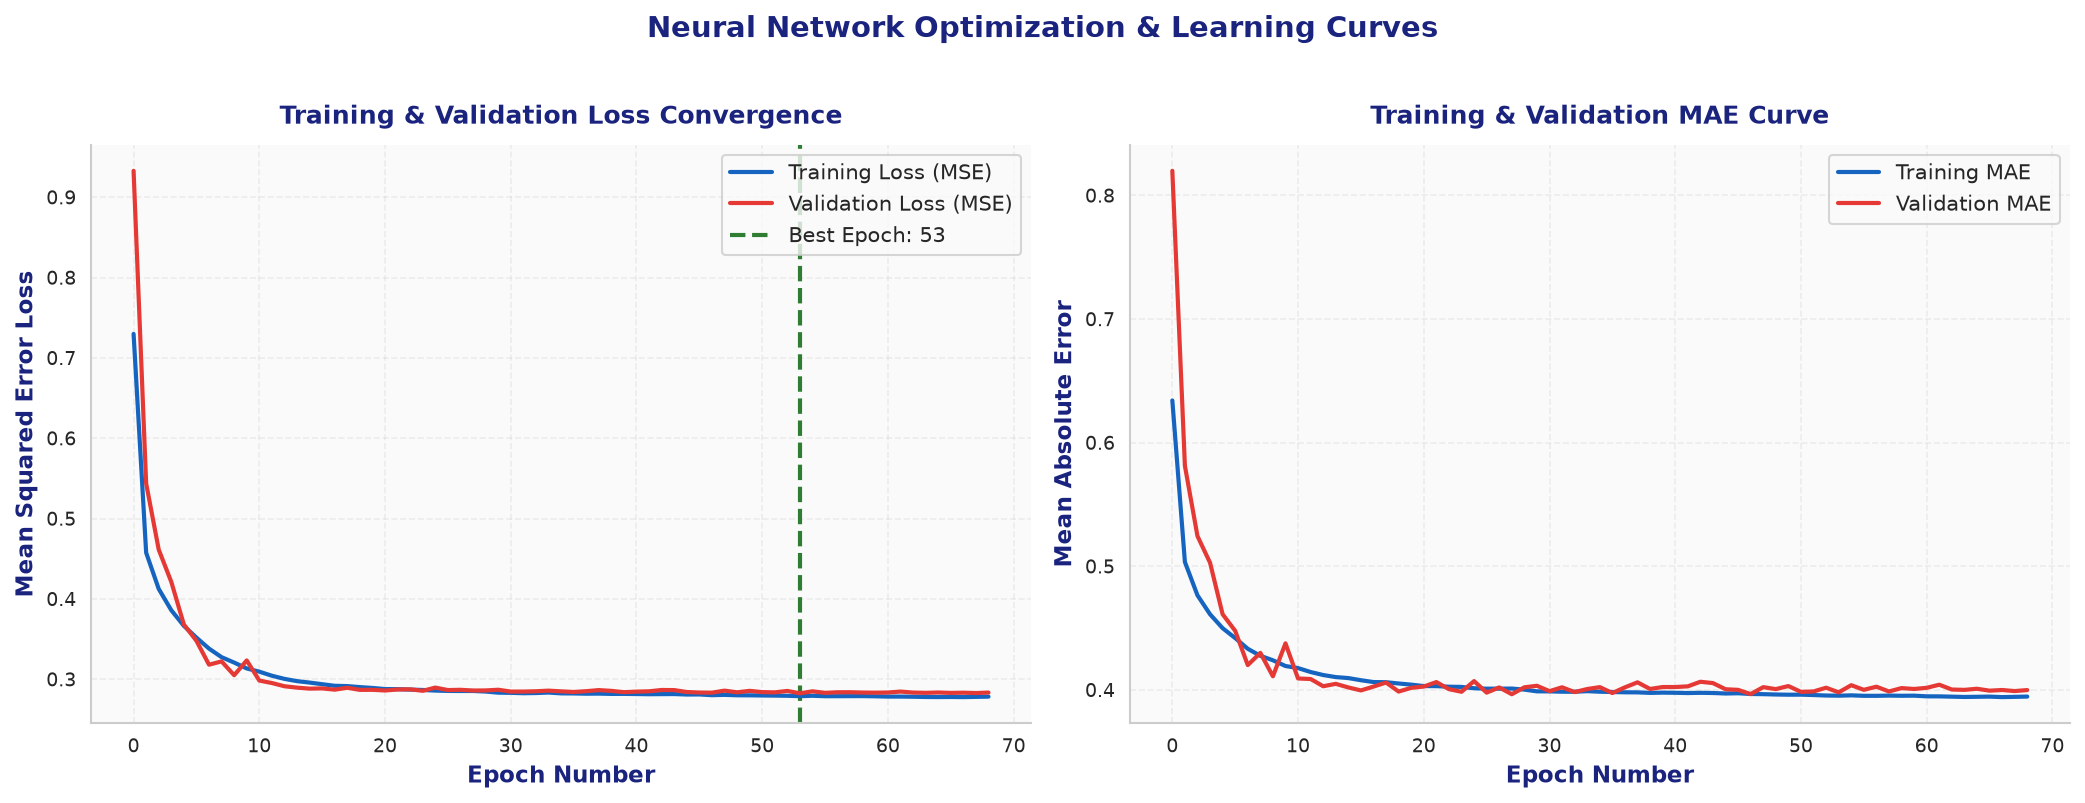

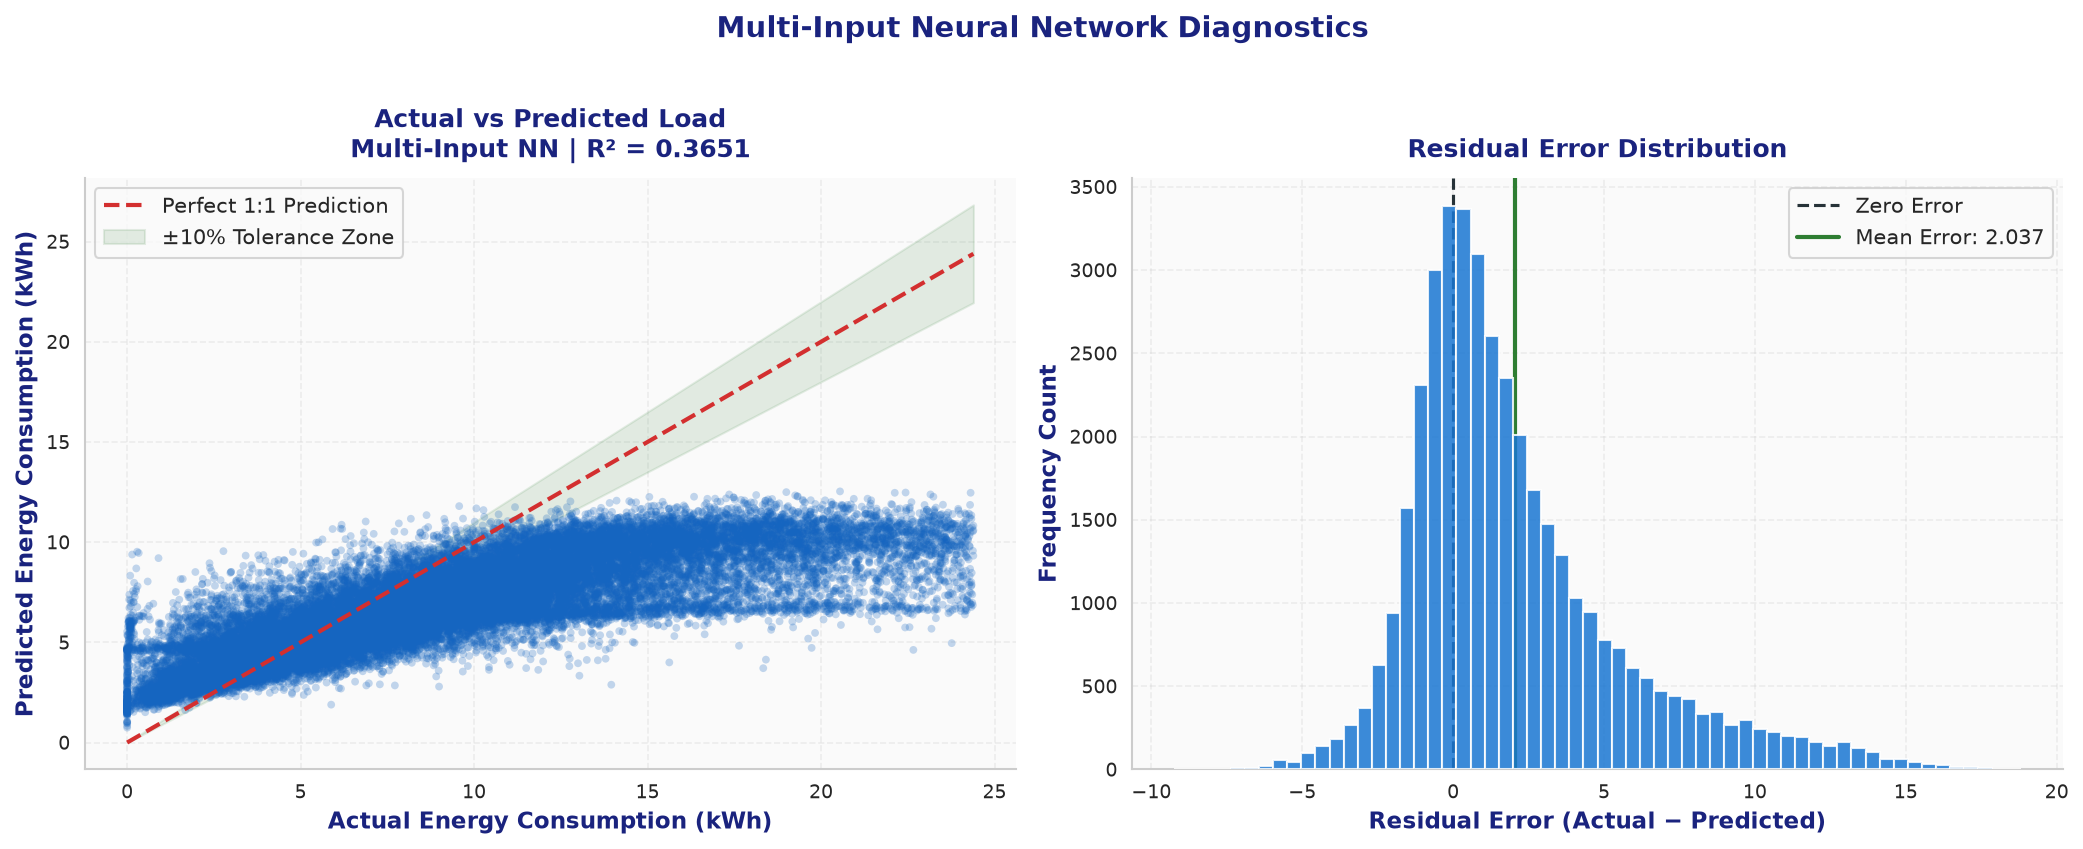

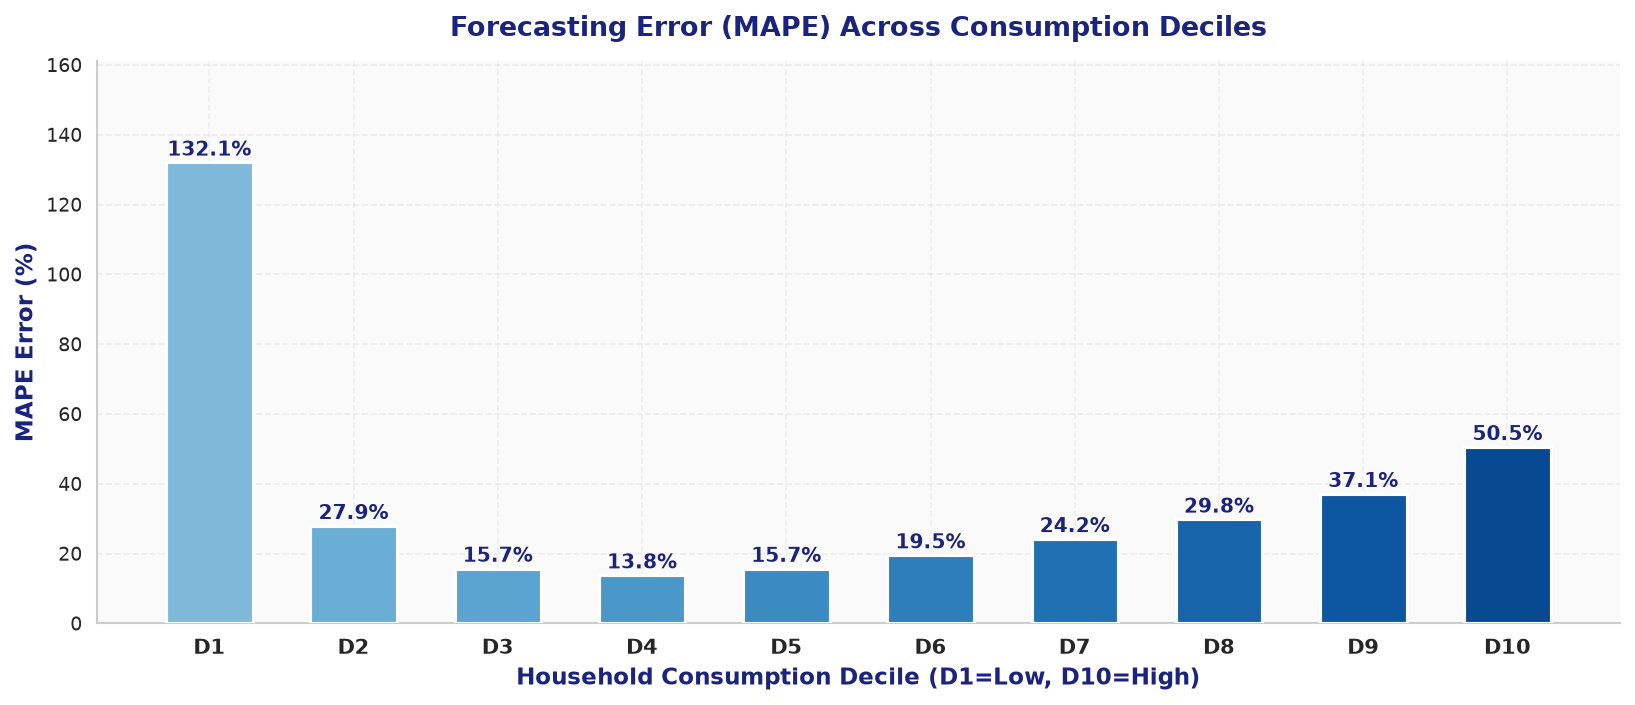


  [6/6] 📋 Summary & HTML report generation

══════════════════════════════════════════════════════════════
  ✅ MULTI-INPUT NEURAL NETWORK  |  COMPLETE
──────────────────────────────────────────────────────────────
  • Model Type       : 4-Branch Deep Neural Network
  • Parameters Count : 93,345
  • Best Epoch       : 53
  • Test R² Score    : 0.3651
  • Test RMSE        : 4.1218 kWh
  • Test MAE         : 2.7873 kWh
  • Test MAPE        : 36.63%
  • Training Time    : 171.9s
──────────────────────────────────────────────────────────────
  • Output dir : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 8
  🖼️ PNG        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 8/task08_neural_network_20260827_050315.png
  📊 CSV        : c:\Users\Alimm\Desktop\project\Big-Data-Engineering-NTI-Projects\london-smart-meters-pipeline\output\Task 8/task08_neural_network_20260827_050315.

In [18]:
# ── Spark session guard (auto-recover if session died) ────────
import builtins as _bi
try:
    spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
except Exception as _spark_err:
    print(f" ⚠️ Spark session unavailable: {_spark_err}")
    print("  💡 Run Cell 1 first to initialize Spark session.")
    raise RuntimeError("Spark session not available. Run Cell 1 first.") from _spark_err
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────
# ============================================================
# CELL 18: TASK 8 – MULTI-INPUT NEURAL NETWORK (Keras/TensorFlow)
#   4-Branch Deep Neural Network Architecture
# ============================================================
import os
import sys
import logging
import warnings
import io

# Suppress absl and TensorFlow pre-import noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'false'
logging.getLogger('absl').setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

old_stderr = sys.stderr
sys.stderr = io.StringIO()

try:
    import tensorflow as tf
    tf.get_logger().setLevel('ERROR')
    logging.getLogger('tensorflow').setLevel(logging.ERROR)
    tf.config.set_visible_devices([], 'GPU')
    tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
except Exception:
    pass
finally:
    sys.stderr = old_stderr

# Standard imports
import builtins
import time
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from pyspark.sql.functions import (
    col, when, expr, rand, min as spark_min, max as spark_max,
    sin, cos, radians, month as spark_month, dayofweek, abs as spark_abs
)
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks # type: ignore # type: ignore
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# Suppress Spark noise
logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)
logging.getLogger("org.apache.spark").setLevel(logging.ERROR)

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# ── ANSI terminal colours ────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _err(msg):  print(f"{C.R}        ❌ {msg}{C.END}")

# ── Output directory ─────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, 'output')
output_dir = os.path.join(base_output_dir, 'Task 8')
os.makedirs(output_dir, exist_ok=True)

# ── CLEANUP: remove previous run outputs ──────────────────────────
print(f"\n{C.BOLD}{'─'*62}{C.END}")
print(f"{C.BOLD}  🧹 Removing previous run outputs …{C.END}")
_deleted = 0
for _e in list(os.listdir(output_dir)):
    _fp = os.path.join(output_dir, _e)
    try:
        if os.path.isdir(_fp): shutil.rmtree(_fp)
        else:                   os.remove(_fp)
        _deleted += 1
    except: pass
print(f"    {'🗑 Removed ' + str(_deleted) + ' file(s)' if _deleted else '✔ Nothing to clean'}")
print(f"{C.BOLD}{'─'*62}{C.END}")

# ── Matplotlib Premium Style ─────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.edgecolor': '#cccccc',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Liberation Sans'],
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def show_and_save(fig, name):
    filepath = f"{output_dir}/{name}_{timestamp}.png"
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    plt.close(fig)

class TrainingLogger(callbacks.Callback):
    """Custom callback for single-line live epoch logging."""
    def __init__(self):
        super().__init__()
        self.best_loss = float('inf')
        self.best_epoch = 0
        
    def on_train_begin(self, logs=None):
        print()  # Add empty line to separate from header
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_loss = logs.get('val_loss', logs.get('loss', 0))
        current_mae = logs.get('val_mae', logs.get('mae', 0))
        
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.best_epoch = epoch + 1
        
        bar_len = 25
        progress = (epoch + 1) / self.params['epochs']
        filled = int(bar_len * progress)
        bar = '█' * filled + '░' * (bar_len - filled)
        
        marker = '★' if (epoch + 1) == self.best_epoch else '•'
        sys.stdout.write(f"\r        {marker} Epoch {epoch+1:03d}/{self.params['epochs']} │{bar}│ "
                         f"loss={logs.get('loss',0):.4f} val_loss={current_loss:.4f} val_mae={current_mae:.4f}")
        sys.stdout.flush()
    
    def on_train_end(self, logs=None):
        print(f"\n\n        • Optimal Weights: Epoch {self.best_epoch} (val_loss={self.best_loss:.4f})")

start_time = time.time()
timestamp = time.strftime("%Y%m%d_%H%M%S")
_hdr(f"MULTI-INPUT NEURAL NETWORK  |  {timestamp}", "🧠")

# Validate input
if 'daily_clean' not in globals():
    _err("'daily_clean' is not defined!")
    print("        💡 Run previous cells first to create 'daily_clean' DataFrame.")
    raise NameError("'daily_clean' not found. Please run previous cells first.")

n_cols = len(daily_clean.columns)
print(f"        • Input Features Available: {n_cols} columns")

# ════════════════════════════════════════════════════════════
# [1/6] Data Preparation & Outlier Handling
# ════════════════════════════════════════════════════════════
_sec('1/6', 'Data preparation & outlier handling', '🔧')

nn_data = daily_clean.select(
    "LCLid", "day", "energy_mean", "energy_sum", "energy_max", "stdorToU", "Acorn_grouped",
    "temperatureMax", "temperatureMin", "humidity", "windSpeed", "cloudCover", "pressure",
    "month", "day_of_week", "is_weekend", "is_holiday", "season",
    "lag_mean_1", "lag_mean_7", "lag_sum_1", "rolling_mean_7d", "rolling_mean_30d",
    "cv", "peak_to_mean_ratio", "load_factor"
).filter(col("temperatureMax").isNotNull())

nn_data = nn_data.filter(col("energy_sum") >= 0)

energy_stats = nn_data.select(
    expr('percentile_approx(energy_sum, 0.25)').alias('q1'),
    expr('percentile_approx(energy_sum, 0.75)').alias('q3')
).collect()[0]

q1 = energy_stats['q1']
q3 = energy_stats['q3']
iqr = q3 - q1
lower_bound = builtins.max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

print(f"        • Energy IQR Bounds : [{lower_bound:.2f}, {upper_bound:.2f}] kWh (Q1={q1:.2f}, Q3={q3:.2f})")

nn_data_clean = nn_data.filter(
    (col("energy_sum") >= lower_bound) & (col("energy_sum") <= upper_bound)
)

removed_count = nn_data.count() - nn_data_clean.count()
print(f"        • Outliers Removed  : {removed_count:,} rows ({removed_count/nn_data.count()*100:.1f}%)")
_ok("Data filtered and cleaned")

# ════════════════════════════════════════════════════════════
# [2/6] Advanced Feature Engineering & Branch Partitioning
# ════════════════════════════════════════════════════════════
_sec('2/6', 'Advanced feature engineering & branch partitioning', '📐')

total_clean = nn_data_clean.count()
sample_frac = builtins.min(0.3, 200000 / total_clean) if total_clean > 200000 else 0.3

nn_sample_spark = nn_data_clean.sample(False, sample_frac, seed=42)

nn_sample_spark = nn_sample_spark \
    .withColumn("temp_avg", (col("temperatureMax") + col("temperatureMin")) / 2) \
    .withColumn("temp_range", col("temperatureMax") - col("temperatureMin")) \
    .withColumn("temp_squared", col("temp_avg") ** 2) \
    .withColumn("temp_humidity", col("temp_avg") * col("humidity")) \
    .withColumn("temp_wind", col("temp_avg") * col("windSpeed")) \
    .withColumn("heating_degree_days", when(col("temp_avg") < 15, 15 - col("temp_avg")).otherwise(0)) \
    .withColumn("cooling_degree_days", when(col("temp_avg") > 22, col("temp_avg") - 22).otherwise(0)) \
    .withColumn("month_rad", radians(col("month") * 30)) \
    .withColumn("sin_month", sin(col("month_rad"))) \
    .withColumn("cos_month", cos(col("month_rad"))) \
    .withColumn("is_heating_season", when(col("month").isin([11,12,1,2,3]), 1).otherwise(0)) \
    .withColumn("is_cooling_season", when(col("month").isin([6,7,8]), 1).otherwise(0)) \
    .withColumn("log_energy_sum", expr("log(energy_sum + 1)"))

nn_sample = nn_sample_spark.toPandas()

le_tariff = LabelEncoder()
nn_sample['tariff_encoded'] = le_tariff.fit_transform(nn_sample['stdorToU'])

le_acorn = LabelEncoder()
nn_sample['acorn_encoded'] = le_acorn.fit_transform(nn_sample['Acorn_grouped'])

ts_features = ['lag_mean_1', 'lag_mean_7', 'lag_sum_1', 'rolling_mean_7d', 'rolling_mean_30d', 
               'cv', 'peak_to_mean_ratio', 'load_factor', 'energy_mean', 'energy_max']

weather_features_nn = ['temperatureMax', 'temperatureMin', 'temp_avg', 'temp_range', 'temp_squared',
                       'humidity', 'windSpeed', 'cloudCover', 'pressure', 'temp_humidity', 'temp_wind',
                       'heating_degree_days', 'cooling_degree_days']

temporal_features = ['month', 'day_of_week', 'is_weekend', 'is_holiday', 'season', 
                     'sin_month', 'cos_month', 'is_heating_season', 'is_cooling_season']

metadata_features = ['tariff_encoded', 'acorn_encoded']

X_ts = nn_sample[ts_features].fillna(0).values
X_weather = nn_sample[weather_features_nn].fillna(0).values
X_temporal = nn_sample[temporal_features].fillna(0).values
X_meta = nn_sample[metadata_features].fillna(0).values

y_raw = nn_sample['energy_sum'].values
y_log = nn_sample['log_energy_sum'].values
y = np.roll(y_log, -1)
y[-1] = np.median(y_log)

print(f"        • Time-Series Branch : {X_ts.shape[1]} features")
print(f"        • Weather Branch     : {X_weather.shape[1]} features")
print(f"        • Temporal Branch    : {X_temporal.shape[1]} features")
print(f"        • Metadata Branch    : {X_meta.shape[1]} features")

scaler_ts = StandardScaler()
scaler_weather = StandardScaler()
scaler_temporal = StandardScaler()

X_ts_scaled = scaler_ts.fit_transform(X_ts)
X_weather_scaled = scaler_weather.fit_transform(X_weather)
X_temporal_scaled = scaler_temporal.fit_transform(X_temporal)

split_idx = int(len(y) * 0.8)
X_ts_train, X_ts_test = X_ts_scaled[:split_idx], X_ts_scaled[split_idx:]
X_weather_train, X_weather_test = X_weather_scaled[:split_idx], X_weather_scaled[split_idx:]
X_temporal_train, X_temporal_test = X_temporal_scaled[:split_idx], X_temporal_scaled[split_idx:]
X_meta_train, X_meta_test = X_meta[:split_idx], X_meta[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
y_raw_train, y_raw_test = y_raw[:split_idx], y_raw[split_idx:]

print(f"        • Train Partition   : {len(y_train):,} ({len(y_train)/len(y)*100:.1f}%)")
print(f"        • Test Partition    : {len(y_test):,} ({len(y_test)/len(y)*100:.1f}%)")
_ok("Multimodal feature normalization completed")

# ════════════════════════════════════════════════════════════
# [3/6] Neural Network Architecture Build
# ════════════════════════════════════════════════════════════
_sec('3/6', 'Building multi-input neural network architecture', '🏗️')

input_ts = layers.Input(shape=(X_ts_train.shape[1],), name='time_series')
x_ts = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_ts)
x_ts = layers.BatchNormalization()(x_ts)
x_ts = layers.Dropout(0.3)(x_ts)
x_ts = layers.Dense(64, activation='relu')(x_ts)
x_ts = layers.Dropout(0.2)(x_ts)

input_weather = layers.Input(shape=(X_weather_train.shape[1],), name='weather')
x_weather = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_weather)
x_weather = layers.BatchNormalization()(x_weather)
x_weather = layers.Dropout(0.3)(x_weather)
x_weather = layers.Dense(32, activation='relu')(x_weather)

input_temporal = layers.Input(shape=(X_temporal_train.shape[1],), name='temporal')
x_temporal = layers.Dense(32, activation='relu')(input_temporal)
x_temporal = layers.Dropout(0.2)(x_temporal)

input_meta = layers.Input(shape=(X_meta_train.shape[1],), name='metadata')
tariff_embed = layers.Embedding(input_dim=len(le_tariff.classes_), output_dim=4, input_length=1)(input_meta[:, 0:1])
tariff_embed = layers.Flatten()(tariff_embed)
acorn_embed = layers.Embedding(input_dim=len(le_acorn.classes_), output_dim=8, input_length=1)(input_meta[:, 1:2])
acorn_embed = layers.Flatten()(acorn_embed)
x_meta = layers.Concatenate()([tariff_embed, acorn_embed])
x_meta = layers.Dense(16, activation='relu')(x_meta)

merged = layers.Concatenate()([x_ts, x_weather, x_temporal, x_meta])
x = layers.Dense(256, activation='relu')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, name='consumption')(x)

model = Model(inputs=[input_ts, input_weather, input_temporal, input_meta], outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

print(f"        • Total Trainable Parameters: {model.count_params():,}")
_ok("4-Branch Deep Architecture compiled")

# ════════════════════════════════════════════════════════════
# [4/6] Model Training
# ════════════════════════════════════════════════════════════
_sec('4/6', 'Training neural network model', '🚀')

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)
train_logger = TrainingLogger()

history = model.fit(
    [X_ts_train, X_weather_train, X_temporal_train, X_meta_train],
    y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr, train_logger],
    verbose=0
)

_ok(f"Training completed across {len(history.history['loss'])} epochs")

# ════════════════════════════════════════════════════════════
# [5/6] Model Evaluation & Diagnostics
# ════════════════════════════════════════════════════════════
_sec('5/6', 'Model evaluation & diagnostics', '📊')

y_pred_log = model.predict([X_ts_test, X_weather_test, X_temporal_test, X_meta_test], verbose=0).flatten()

y_pred = np.expm1(y_pred_log) - 1
y_pred = np.clip(y_pred, 0, None)
y_true = y_raw_test

test_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
test_mae = mean_absolute_error(y_true, y_pred)
test_r2 = r2_score(y_true, y_pred)
test_mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
test_mae_log = mean_absolute_error(y_test, y_pred_log)
test_r2_log = r2_score(y_test, y_pred_log)

print(f"        • Test R² Score        : {test_r2:.4f} (Log-R²: {test_r2_log:.4f})")
print(f"        • Test RMSE            : {test_rmse:.4f} kWh (Log-RMSE: {test_rmse_log:.4f})")
print(f"        • Test MAE             : {test_mae:.4f} kWh (Log-MAE: {test_mae_log:.4f})")
print(f"        • Test MAPE            : {test_mape:.2f}%")

# Plot 1: Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), facecolor='white')

ax = axes[0]
ax.plot(history.history['loss'], color='#1565c0', linewidth=2, label='Training Loss (MSE)', zorder=3)
ax.plot(history.history['val_loss'], color='#e53935', linewidth=2, label='Validation Loss (MSE)', zorder=3)
best_epoch = np.argmin(history.history['val_loss'])
ax.axvline(x=best_epoch, color='#2e7d32', linestyle='--', linewidth=2, label=f'Best Epoch: {best_epoch}')
ax.set_xlabel('Epoch Number', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Mean Squared Error Loss', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Training & Validation Loss Convergence', fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(frameon=True, fancybox=True, loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history.history['mae'], color='#1565c0', linewidth=2, label='Training MAE', zorder=3)
ax.plot(history.history['val_mae'], color='#e53935', linewidth=2, label='Validation MAE', zorder=3)
ax.set_xlabel('Epoch Number', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Mean Absolute Error', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Training & Validation MAE Curve', fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(frameon=True, fancybox=True, loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('Neural Network Optimization & Learning Curves', fontsize=14, fontweight='bold', color='#1a237e', y=1.02)
plt.tight_layout()
show_and_save(fig, "nn_loss")

# Plot 2: Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.25, s=14, color='#1565c0', edgecolors='none', zorder=2)
min_val = builtins.min(y_true.min(), y_pred.min())
max_val = builtins.max(y_true.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], '--', color='#d32f2f', linewidth=2, label='Perfect 1:1 Prediction', zorder=5)
ax.fill_between([min_val, max_val], [min_val*0.9, max_val*0.9], [min_val*1.1, max_val*1.1],
                alpha=0.12, color='#2e7d32', label='±10% Tolerance Zone')
ax.set_xlabel('Actual Energy Consumption (kWh)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title(f'Actual vs Predicted Load\nMulti-Input NN | R² = {test_r2:.4f}', 
             fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(loc='upper left', frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)

residuals = y_true - y_pred
ax = axes[1]
ax.hist(residuals, bins=60, color='#1976d2', edgecolor='white', alpha=0.85, zorder=3)
ax.axvline(x=0, color='#263238', linestyle='--', linewidth=1.5, label='Zero Error')
ax.axvline(x=np.mean(residuals), color='#2e7d32', linestyle='-', linewidth=2, 
           label=f'Mean Error: {np.mean(residuals):.3f}')
ax.set_xlabel('Residual Error (Actual − Predicted)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('Frequency Count', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Residual Error Distribution', fontsize=12, fontweight='bold', color='#1a237e', pad=10)
ax.legend(loc='upper right', frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Input Neural Network Diagnostics', fontsize=14, fontweight='bold', color='#1a237e', y=1.02)
plt.tight_layout()
show_and_save(fig, "nn_diagnostics")

# Plot 3: Error by Decile
pred_df = pd.DataFrame({'actual': y_true, 'predicted': y_pred})
pred_df['decile'] = pd.qcut(pred_df['actual'], 10, labels=False, duplicates='drop')
decile_errors = pred_df.groupby('decile').apply(
    lambda x: np.mean(np.abs(x['actual'] - x['predicted']) / np.clip(x['actual'], 1, None)) * 100
).reset_index(name='mape')

fig, ax = plt.subplots(figsize=(11, 4.8), facecolor='white')
colors_bar = plt.cm.Blues(np.linspace(0.45, 0.9, len(decile_errors)))
bars = ax.bar(decile_errors['decile'], decile_errors['mape'], 
              color=colors_bar, edgecolor='white', linewidth=1.5, zorder=3, width=0.6)
for bar, val in zip(bars, decile_errors['mape']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1a237e')
ax.set_xlabel('Household Consumption Decile (D1=Low, D10=High)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_ylabel('MAPE Error (%)', fontsize=11, fontweight='bold', color='#1a237e')
ax.set_title('Forecasting Error (MAPE) Across Consumption Deciles', fontsize=13, fontweight='bold', color='#1a237e', pad=12)
ax.set_xticks(range(len(decile_errors)))
ax.set_xticklabels([f'D{i+1}' for i in range(len(decile_errors))], fontsize=10, fontweight='bold')
ax.set_ylim(0, decile_errors['mape'].max() * 1.22)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
show_and_save(fig, "nn_error_by_decile")

# ════════════════════════════════════════════════════════════
# [6/6] Summary & HTML Report Generation
# ════════════════════════════════════════════════════════════
_sec('6/6', 'Summary & HTML report generation', '📋')

elapsed = time.time() - start_time

summary_data = {
    'Metric': [
        'Total Records', 'Train Size', 'Test Size', 'Outliers Removed',
        'Model', 'Parameters', 'Best Epoch',
        'Test RMSE', 'Test MAE', 'Test R2', 'Test MAPE (%)',
        'Log-RMSE', 'Log-MAE', 'Log-R2',
        'Runtime (s)'
    ],
    'Value': [
        f'{len(nn_sample):,}', f'{len(y_train):,}', f'{len(y_test):,}', f'{removed_count:,}',
        'Multi-Input NN', f'{model.count_params():,}', f'{best_epoch}',
        f'{test_rmse:.4f}', f'{test_mae:.4f}', f'{test_r2:.4f}', f'{test_mape:.2f}',
        f'{test_rmse_log:.4f}', f'{test_mae_log:.4f}', f'{test_r2_log:.4f}',
        f'{elapsed:.1f}'
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f"{output_dir}/nn_summary_{timestamp}.csv", index=False)

# Save model artifact

# Generate HTML report
html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Multi-Input Neural Network Report — {timestamp}</title>
<style>
:root{{--p:#311b92;--pl:#512da8;--ac:#b39ddb;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(49,27,146,.08)}}
*{{margin:0;padding:0;box-sizing:border-box}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1160px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 100%);
      border-radius:var(--r);padding:36px 32px;color:#fff;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:700;margin-bottom:10px}}
.hdr p{{opacity:.9}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;
      border-radius:50px;font-size:.82rem;font-weight:600;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.25);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.8rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.78rem;color:var(--mu);margin-top:4px;font-weight:500}}
.sec{{background:var(--w);border-radius:var(--r);padding:24px 26px;
      margin-bottom:20px;box-shadow:var(--sh);border:1px solid var(--bd)}}
.sh{{font-size:1.15rem;font-weight:700;color:var(--p);margin-bottom:16px;
     padding-bottom:10px;border-bottom:2px solid #e8eaf6;
     display:flex;align-items:center;gap:8px}}
.sh .ln{{display:inline-block;width:4px;height:20px;background:var(--ac);border-radius:2px}}
.tw{{overflow-x:auto;border-radius:8px;border:1px solid var(--bd)}}
table{{width:100%;border-collapse:collapse;font-size:.88rem;min-width:540px}}
thead th{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);
          color:#fff;padding:12px 14px;text-align:left;font-weight:600}}
td{{padding:10px 14px;border-bottom:1px solid #f0f0f0}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.branch-card{{background:#f8fafc;border-radius:10px;padding:16px 18px;margin-bottom:12px;border-left:4px solid var(--pl);border:1px solid var(--bd)}}
.branch-title{{font-weight:700;color:var(--p);margin-bottom:6px;font-size:.95rem}}
.branch-desc{{color:var(--tx);font-size:.86rem;font-family:monospace}}
.foot{{text-align:center;padding:24px;color:var(--mu);font-size:.82rem}}
</style>
</head>
<body>
<div class="wrap">
<div class="hdr">
  <h1>🧠 Multi-Input Neural Network Report</h1>
  <p>Deep Learning Forecasting · 4-Branch Multimodal Architecture · Keras / TensorFlow</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">🏆 Best Epoch: {best_epoch}</span>
    <span class="bdg">⚡ {model.count_params():,} Parameters</span>
    <span class="bdg">🗂️ {len(nn_sample):,} Samples</span>
  </div>
</div>

<div class="grid">
  <div class="kpi top"><div class="kv">{test_r2:.4f}</div><div class="kl">Test R² Score</div></div>
  <div class="kpi"><div class="kv">{test_rmse:.4f}</div><div class="kl">Test RMSE (kWh)</div></div>
  <div class="kpi"><div class="kv">{test_mae:.4f}</div><div class="kl">Test MAE (kWh)</div></div>
  <div class="kpi"><div class="kv">{test_mape:.2f}%</div><div class="kl">Test MAPE</div></div>
  <div class="kpi"><div class="kv">{test_r2_log:.4f}</div><div class="kl">Log-Scale R²</div></div>
  <div class="kpi"><div class="kv">{elapsed:.1f}s</div><div class="kl">Training Runtime</div></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>📊 Performance Metrics Summary</div>
  <div class="tw"><table>
    <thead><tr><th>Evaluation Metric</th><th>Original Scale (kWh)</th><th>Log Scale</th></tr></thead>
    <tbody>
      <tr class="best-row"><td><strong>R² Score (Variance Explained)</strong></td><td><strong>{test_r2:.4f}</strong></td><td><strong>{test_r2_log:.4f}</strong></td></tr>
      <tr><td>Root Mean Squared Error (RMSE)</td><td>{test_rmse:.4f}</td><td>{test_rmse_log:.4f}</td></tr>
      <tr><td>Mean Absolute Error (MAE)</td><td>{test_mae:.4f}</td><td>{test_mae_log:.4f}</td></tr>
      <tr><td>Mean Absolute Percentage Error (MAPE)</td><td>{test_mape:.2f}%</td><td>—</td></tr>
    </tbody>
  </table></div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🏗️ 4-Branch Neural Architecture</div>
  <div class="branch-card">
    <div class="branch-title">1. Time-Series Branch</div>
    <div class="branch-desc">{X_ts_train.shape[1]} Lag & Rolling Features → Dense(128) → BatchNorm → Dropout(0.3) → Dense(64) → Dropout(0.2)</div>
  </div>
  <div class="branch-card">
    <div class="branch-title">2. Weather Branch</div>
    <div class="branch-desc">{X_weather_train.shape[1]} Meteorological Features → Dense(64) → BatchNorm → Dropout(0.3) → Dense(32)</div>
  </div>
  <div class="branch-card">
    <div class="branch-title">3. Temporal Cyclical Branch</div>
    <div class="branch-desc">{X_temporal_train.shape[1]} Calendar Features → Dense(32) → Dropout(0.2)</div>
  </div>
  <div class="branch-card">
    <div class="branch-title">4. Household Metadata Embeddings</div>
    <div class="branch-desc">Tariff Embedding (4D) + ACORN Embedding (8D) → Concatenate → Dense(16)</div>
  </div>
  <div class="branch-card" style="border-left-color:var(--ac);">
    <div class="branch-title">5. Fusion & Dense Regressor Layers</div>
    <div class="branch-desc">Concatenate(All 4 Branches) → Dense(256) → BatchNorm → Dropout(0.4) → Dense(128) → Dropout(0.3) → Dense(64) → Dense(1)</div>
  </div>
</div>

<div class="sec">
  <div class="sh"><span class="ln"></span>🗂️ Data Partitioning</div>
  <div class="tw"><table>
    <thead><tr><th>Partition</th><th>Record Count</th><th>Share Percentage</th></tr></thead>
    <tbody>
      <tr><td><strong>Training Partition</strong></td><td>{len(y_train):,}</td><td>{len(y_train)/len(y)*100:.1f}%</td></tr>
      <tr><td><strong>Testing Partition</strong></td><td>{len(y_test):,}</td><td>{len(y_test)/len(y)*100:.1f}%</td></tr>
      <tr class="best-row"><td><strong>Total Evaluated Samples</strong></td><td>{len(y):,}</td><td>100.0%</td></tr>
    </tbody>
  </table></div>
</div>

<div class="foot">Generated by Task 8 Multi-Input Neural Network Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div>
</body></html>"""

_final_html = f"{output_dir}/task08_neural_network_{timestamp}.html"
with open(_final_html, 'w', encoding='utf-8') as f:
    f.write(html_content)

# ════════════════════════════════════════════════════════════
# PNG Consolidation & Spark Cleanup
# ════════════════════════════════════════════════════════════
import glob as _glob18
_png_list = sorted(_glob18.glob(f'{output_dir}/nn_*_{timestamp}.png'))
_final_png = f'{output_dir}/task08_neural_network_{timestamp}.png'

if len(_png_list) > 1:
    import matplotlib.image as _mpimg
    _n = len(_png_list)
    _nc = 2; _nr = (_n + _nc - 1) // _nc
    _fg, _ax = plt.subplots(_nr, _nc, figsize=(_nc * 10, _nr * 6), facecolor='white')
    _ax = _ax.flatten()
    for _i, _p in enumerate(_png_list):
        _ax[_i].imshow(_mpimg.imread(_p)); _ax[_i].axis('off')
    for _j in range(_n, len(_ax)): _ax[_j].set_visible(False)
    plt.tight_layout(pad=0.5)
    plt.savefig(_final_png, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(_fg)
    for _p in _png_list:
        try: os.remove(_p)
        except: pass
elif len(_png_list) == 1:
    import shutil as _sh18
    _sh18.move(_png_list[0], _final_png)

_src_csv = f'{output_dir}/nn_summary_{timestamp}.csv'
_final_csv = f'{output_dir}/task08_neural_network_{timestamp}.csv'
if os.path.exists(_src_csv): os.rename(_src_csv, _final_csv)

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
_s1 = "═" * 62
_s2 = "─" * 62
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ MULTI-INPUT NEURAL NETWORK  |  COMPLETE
{_s2}
  • Model Type       : 4-Branch Deep Neural Network
  • Parameters Count : {model.count_params():,}
  • Best Epoch       : {best_epoch}
  • Test R² Score    : {test_r2:.4f}
  • Test RMSE        : {test_rmse:.4f} kWh
  • Test MAE         : {test_mae:.4f} kWh
  • Test MAPE        : {test_mape:.2f}%
  • Training Time    : {elapsed:.1f}s
{_s2}
  • Output dir : {output_dir}
  🖼️ PNG        : {_final_png}
  📊 CSV        : {_final_csv}
  🌐 HTML       : {_final_html}

{_s1}{C.END}""")


### CELL 19: RESULTS SUMMARY & VISUALIZATION DASHBOARD 



════════════════════════════════════════════════════════════════════
  🏙️  LONDON SMART METERS · COMPREHENSIVE RESULTS
════════════════════════════════════════════════════════════════════

  [1/8] 🏠 ACORN Group Prediction
  ────────────────────────────────────────────────────────────
  Best: RandomForest            F1=0.4305  Acc=0.4281

  [2/8] ⚡ Tariff Type Classification
  ────────────────────────────────────────────────────────────
  Best: RandomForest            AUC=0.5433  F1=0.4857

  [3/8] 📈 Energy Consumption Forecasting
  ────────────────────────────────────────────────────────────
  Best: LinearRegression        RMSE=3.8154  R²=0.8561

  [4/8] 🔋 Peak Demand Prediction
  ────────────────────────────────────────────────────────────
  Best: LinearRegression        RMSE=0.0328  R²=0.9979

  [5/8] 🔍 Household Segmentation
  ────────────────────────────────────────────────────────────
  Best Load-Shape K             2 clusters  (Silhouette=0.0937)
  Best Household K              

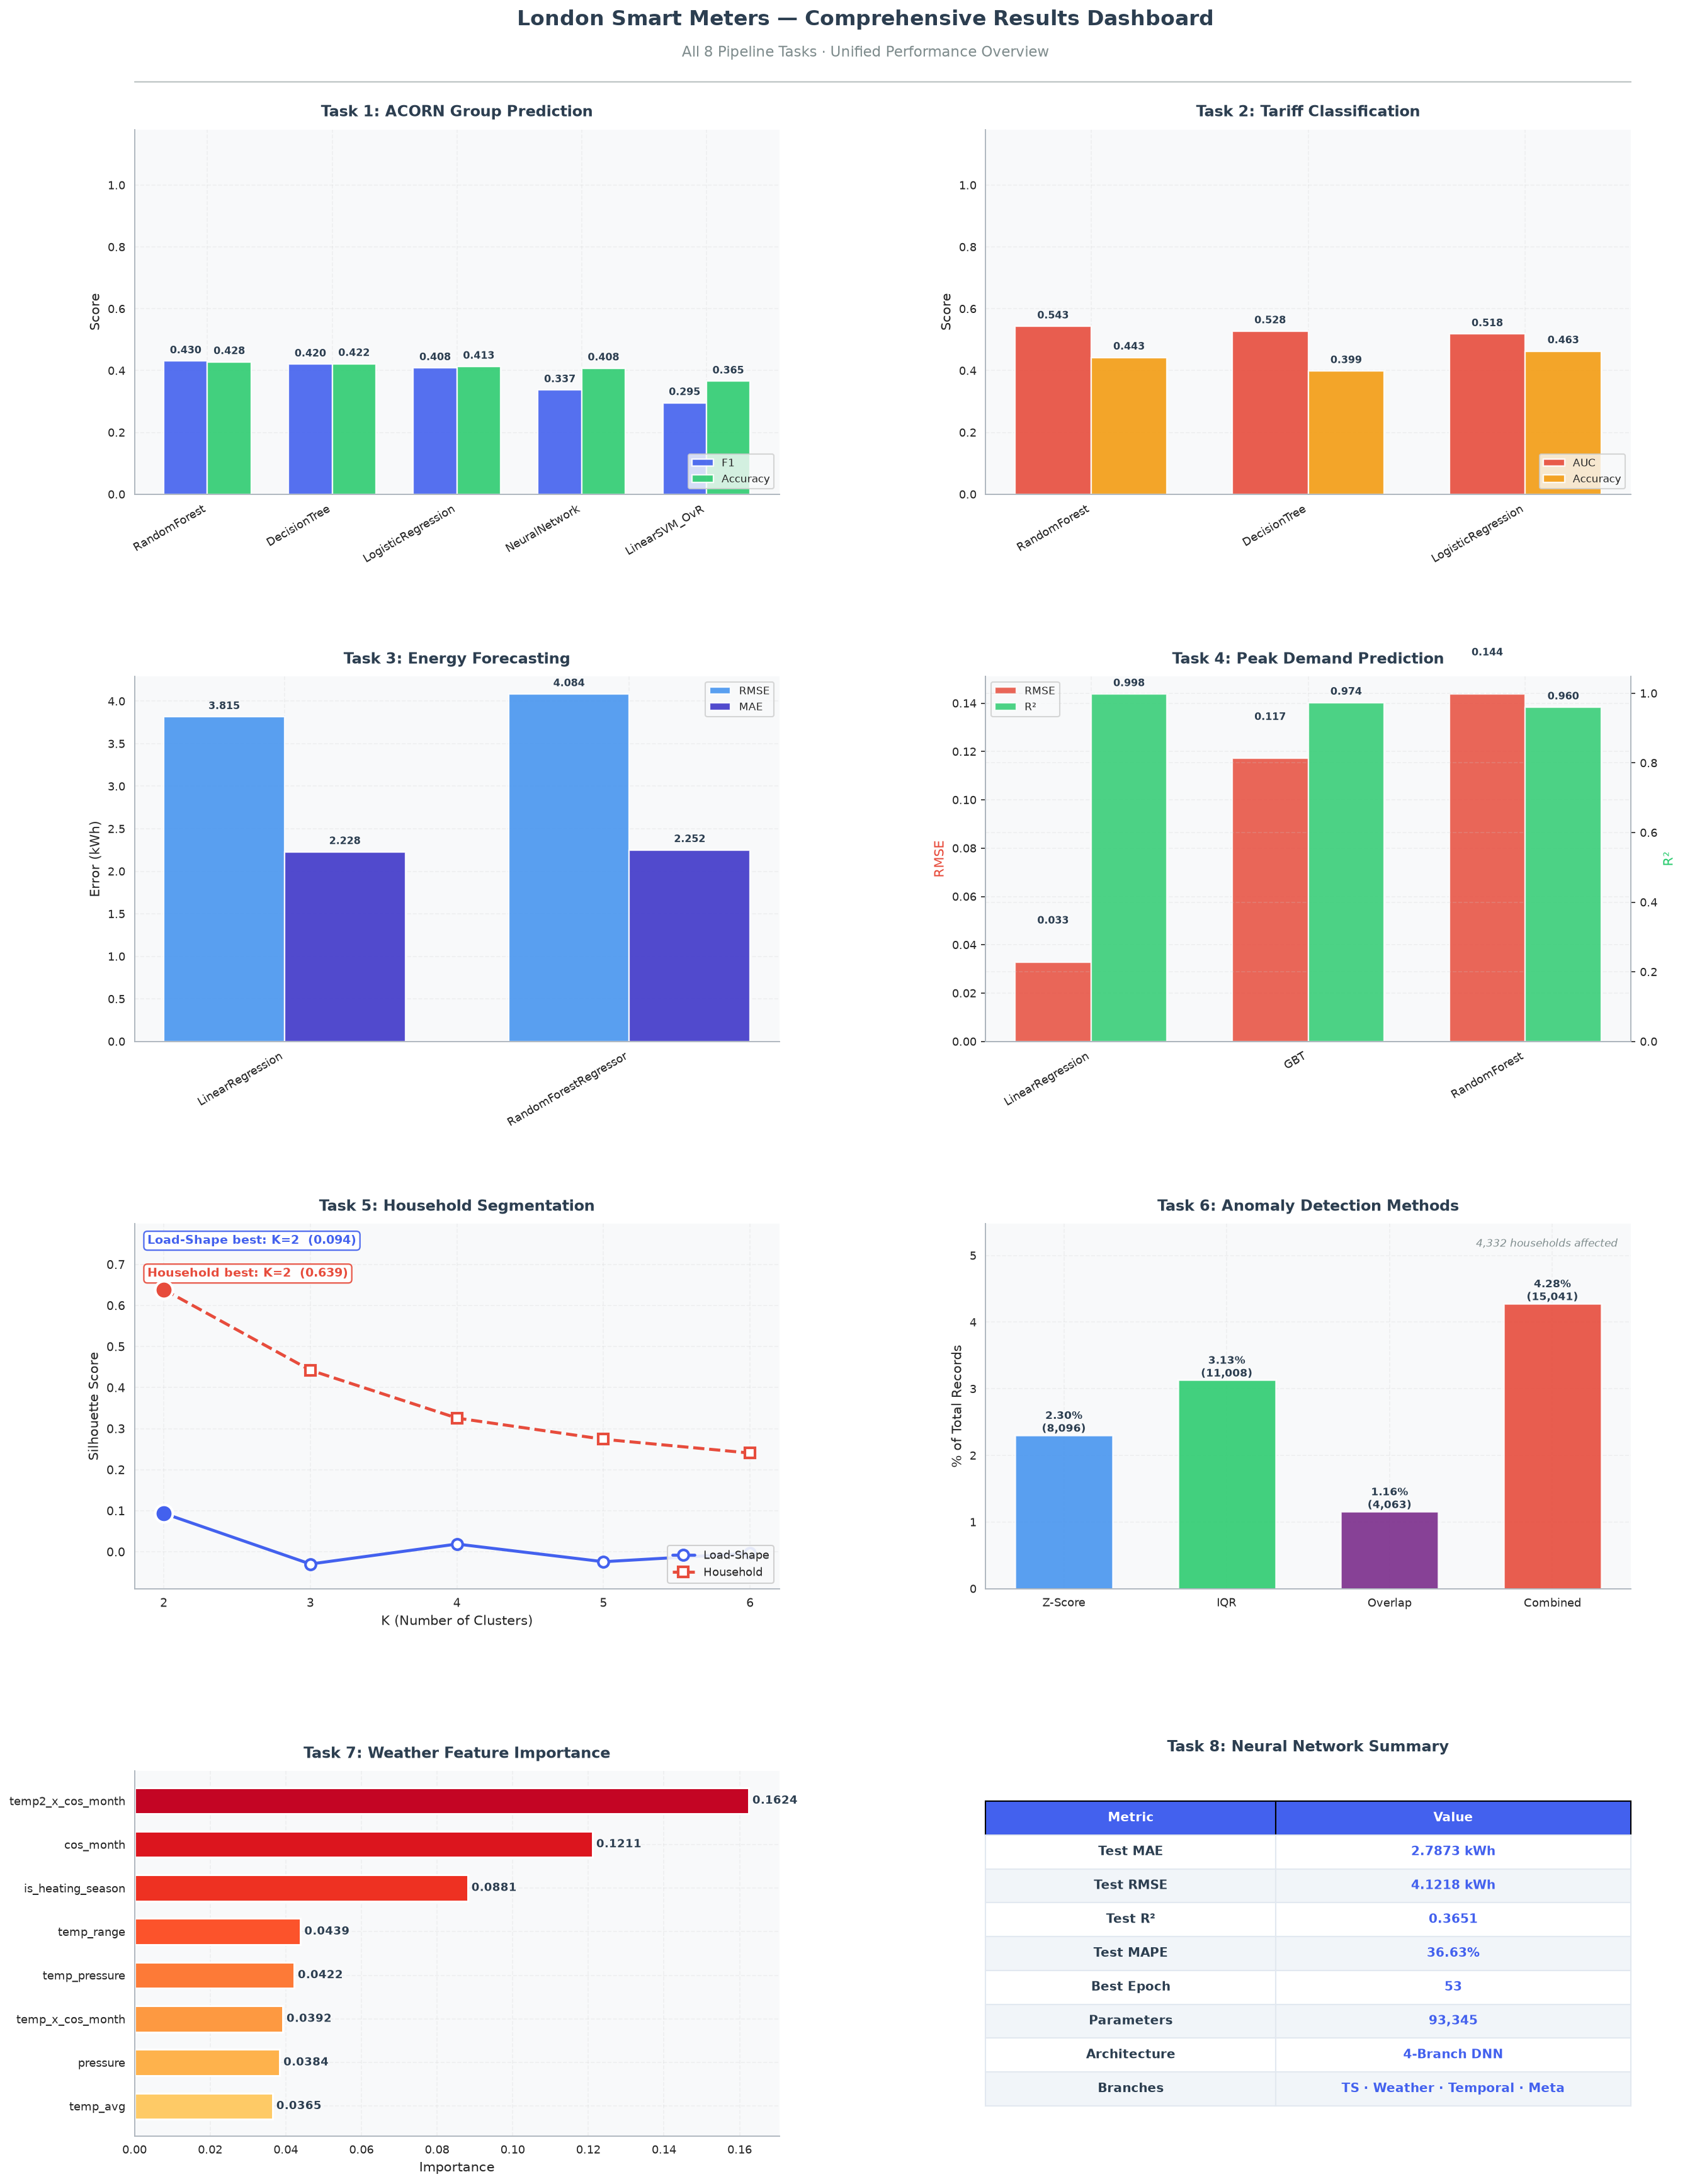


════════════════════════════════════════════════════════════════════
  ✅ RESULTS SUMMARY  |  COMPLETE  (8/8 tasks)
────────────────────────────────────────────────────────────────────
  🖼️ PNG   : results_summary_20260827_051008.png
  📊 CSV   : results_summary_20260827_051008.csv
  🌐 HTML  : results_summary_20260827_051008.html

════════════════════════════════════════════════════════════════════


In [19]:
# ── Spark session guard (auto-recover if session died) ─────────────────────
import builtins as _bi
spark = _bi.ensure_spark() if hasattr(_bi, "ensure_spark") else spark
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────────────────

# ════════════════════════════════════════════════════════════════════════
# CELL 19: RESULTS SUMMARY & VISUALIZATION DASHBOARD
# ════════════════════════════════════════════════════════════════════════
import os, time, glob, sys, csv, base64, io, builtins
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image

# ── Output directories ────────────────────────────────────────────────────
base_output_dir = os.path.join(NOTEBOOK_DIR, "output")
output_dir      = os.path.join(base_output_dir, "RESULTS_SUMMARY")
os.makedirs(output_dir, exist_ok=True)
timestamp = time.strftime("%Y%m%d_%H%M%S")

# ── ANSI colours ──────────────────────────────────────────────────────────
class C:
    B    = "\033[94m"; G    = "\033[92m"; R    = "\033[91m"
    Y    = "\033[93m"; CY   = "\033[96m"; BOLD = "\033[1m"
    END  = "\033[0m";  DIM  = "\033[2m"

def _hdr(title, emoji=""):
    w = 68
    print(f"\n{C.BOLD}{C.B}{'═'*w}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*w}{C.END}")

def _sec(step, title, emoji="•"):
    print(f"\n{C.BOLD}{C.CY}  [{step}] {emoji} {title}{C.END}")
    print(f"  {C.DIM}{'─'*60}{C.END}")

def _row(label, val, color=C.G):
    print(f"  {C.BOLD}{label:<30}{C.END}{color}{val}{C.END}")

def _warn(msg):
    print(f"  {C.Y}⚠ {msg}{C.END}")

# ── CSV loader helpers ────────────────────────────────────────────────────
def _latest_csv(task_folder):
    """Return the most recently modified CSV from output/<task_folder>/."""
    folder = os.path.join(base_output_dir, task_folder)
    files  = glob.glob(f"{folder}/*.csv")
    return builtins.max(files, key=os.path.getmtime) if files else None

def _csv_section(path, section_marker, stop_on_blank=True):
    """Return rows (as dicts) of a named section inside a multi-section CSV.
    The section marker line (e.g. '── SECTION 1: ... ──') must be a
    dedicated separator line, distinct from the header row that follows it.
    """
    if not path or not os.path.exists(path):
        return []
    with open(path, encoding="utf-8", errors="replace") as f:
        lines = f.read().splitlines()
    inside = False
    header = None
    result = []
    for line in lines:
        stripped = line.strip()
        if section_marker in stripped:
            inside = True
            header = None
            continue
        if inside:
            if stripped.startswith("──") or (stop_on_blank and not stripped):
                if result:
                    break
                continue
            parts = stripped.split(",")
            if header is None:
                header = parts
            else:
                result.append(dict(zip(header, parts)))
    return result

def _kv_section(path, section_marker, stop_on_blank=True):
    """Return a list of (key, value) pairs for a section made of loose
    'Key,Value[,Value2,...]' lines of *varying* width (e.g. a free-form
    'DATASET SUMMARY' block), rather than a fixed-column table. Using the
    fixed-column _csv_section parser on such a block would treat the first
    line as a header and zip() would silently truncate/misalign every
    following row that has a different number of fields.
    """
    if not path or not os.path.exists(path):
        return []
    with open(path, encoding="utf-8", errors="replace") as f:
        lines = f.read().splitlines()
    inside = False
    result = []
    for line in lines:
        stripped = line.strip()
        if section_marker in stripped:
            inside = True
            continue
        if inside:
            if stripped.startswith("──") or (stop_on_blank and not stripped):
                if result:
                    break
                continue
            parts = stripped.split(",", 1)
            key = parts[0].strip()
            val = parts[1].strip() if len(parts) > 1 else ""
            result.append((key, val))
    return result

def _csv_dictrows(path):
    """Read a plain (non-sectioned) CSV into a list of dicts using the
    real csv module, so quoted fields / embedded commas are handled
    correctly and the header row is never mistaken for data."""
    rows = []
    if not path or not os.path.exists(path):
        return rows
    with open(path, encoding="utf-8", errors="replace", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    return rows

def _scalar(path, key):
    """Read a simple key,value CSV and return the value for key (case-insensitive)."""
    if not path or not os.path.exists(path):
        return None
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            parts = line.strip().split(",", 1)
            if len(parts) == 2 and parts[0].strip().lower() == key.lower():
                return parts[1].strip().strip('"')
    return None

def _flt(v, default=0.0):
    try:
        return float(str(v).replace(",", "").replace("%", ""))
    except (TypeError, ValueError):
        return default

# ── Load saved results from CSVs ──────────────────────────────────────────
_t1_csv = _latest_csv("Task 1")
_t2_csv = _latest_csv("Task 2")
_t3_csv = _latest_csv("Task 3")
_t4_csv = _latest_csv("Task 4")
_t6_csv = _latest_csv("Task 6")
_t7_csv = _latest_csv("Task 7")
_t8_csv = _latest_csv("Task 8")

# Task 1
_t1_models  = _csv_section(_t1_csv, "SECTION 1: MODEL COMPARISON")
_t1_classes = _csv_section(_t1_csv, "SECTION 2: PER-CLASS METRICS")
_t1_features= _csv_section(_t1_csv, "SECTION 3: FEATURE IMPORTANCE")
_t1_dataset = _kv_section(_t1_csv, "SECTION 6: DATASET SUMMARY")

# Task 2
_t2_models  = _csv_section(_t2_csv, "SECTION 1: MODEL COMPARISON")
_t2_classes = _csv_section(_t2_csv, "SECTION 2: PER-CLASS METRICS")

# Task 3
_t3_models  = _csv_section(_t3_csv, "SECTION 1: MODEL COMPARISON")
_t3_features= _csv_section(_t3_csv, "SECTION 2: FEATURE IMPORTANCE")

# Task 4
_t4_models  = _csv_section(_t4_csv, "SECTION 1: MODEL COMPARISON")
_t4_features= _csv_section(_t4_csv, "SECTION 2: FEATURE IMPORTANCE")

# Task 5 — read straight from the in-memory globals produced by Cell 15.
# NOTE: the segmentation pipeline runs TWO clustering analyses (load-shape
# clustering and household behavioural clustering), each with its own
# variables (…_shape / …_hh). Earlier drafts of this cell looked for
# "silhouette_scores"/"best_k", which never exist, so Task 5 always
# rendered as "not available" even after a successful run.
_hh_sil     = globals().get("silhouette_scores_hh", [])
_hh_k       = globals().get("best_k_hh", None)
_hh_score   = globals().get("best_score_hh", None)
_hh_n       = globals().get("n_households", 0)
_hh_results = globals().get("hh_results", None)

_shape_sil     = globals().get("silhouette_scores_shape", [])
_shape_k       = globals().get("best_k_shape", None)
_shape_score   = globals().get("best_score_shape", None)
_shape_n       = globals().get("n_profiles", 0)
_shape_done    = globals().get("loadshape_done", False)

_task5_ran = (_hh_results is not None) or _shape_done

# Task 6 — Task 6 only ever saves ONE CSV: the raw per-record export
# (columns like LCLid, day, is_anomaly_zscore, is_anomaly_iqr, is_anomaly, …).
# It never writes a separate Metric/Count summary file, so looking for one
# here always failed. Recompute the same summary numbers Task 6 itself
# prints, directly from those per-record flag columns.
_t6_raw = _csv_dictrows(_t6_csv)
_t6_stats = None
if _t6_raw:
    try:
        # NOTE: plain sum()/max()/min() are shadowed by PySpark's Column-based
        # versions after Cell 1's "from pyspark.sql.functions import *" — the
        # exact cause of the "[NOT_COLUMN_OR_STR] ... got NoneType" crash seen
        # here previously. builtins.sum() is the real Python sum() on ints.
        _t6_total    = len(_t6_raw)
        _t6_z        = builtins.sum(1 for r in _t6_raw if _flt(r.get("is_anomaly_zscore")) == 1)
        _t6_iqr      = builtins.sum(1 for r in _t6_raw if _flt(r.get("is_anomaly_iqr")) == 1)
        _t6_combined = builtins.sum(1 for r in _t6_raw if _flt(r.get("is_anomaly")) == 1)
        _t6_overlap  = builtins.sum(1 for r in _t6_raw
                            if _flt(r.get("is_anomaly_zscore")) == 1
                            and _flt(r.get("is_anomaly_iqr")) == 1)
        _t6_households = len({r.get("LCLid") for r in _t6_raw if _flt(r.get("is_anomaly")) == 1})
        # label -> (count, percent-of-total)
        _t6_stats = {
            "Total":      (_t6_total,    100.0),
            "Z-Score":    (_t6_z,        _t6_z        / _t6_total * 100 if _t6_total else 0.0),
            "IQR":        (_t6_iqr,      _t6_iqr      / _t6_total * 100 if _t6_total else 0.0),
            "Overlap":    (_t6_overlap,  _t6_overlap  / _t6_total * 100 if _t6_total else 0.0),
            "Combined":   (_t6_combined, _t6_combined / _t6_total * 100 if _t6_total else 0.0),
            "Households": (_t6_households, None),  # % of all households isn't derivable from this file
        }
    except Exception:
        _t6_stats = None

# Task 7 — this CSV is a flat "Metric,Value" file (not a sectioned table),
# so its figures are read with _scalar rather than _csv_section.
_t7_rmse    = _scalar(_t7_csv, "Test Log-RMSE")
_t7_r2      = _scalar(_t7_csv, "Test Log-R2")
_t7_best    = _scalar(_t7_csv, "Best Model")
_t7_top     = _scalar(_t7_csv, "Top Feature")

# The Task 7 cell stores per-feature importances in `feature_importance_df`
# (a pandas DataFrame with columns Feature / Importance / Importance_Pct),
# not in a bare `feature_importance` list — that name never existed, so
# this branch previously always fell through to "no data".
_fi7 = []
_fi_df = globals().get("feature_importance_df", None)
if _fi_df is not None and len(_fi_df) > 0:
    _fi7 = list(zip(_fi_df["Feature"].tolist(),
                     (_fi_df["Importance_Pct"] / 100.0).tolist()))

# Task 8
_t8_best_epoch = _scalar(_t8_csv, "Best Epoch")
_t8_rmse       = _scalar(_t8_csv, "Test RMSE")
_t8_mae        = _scalar(_t8_csv, "Test MAE")
_t8_r2         = _scalar(_t8_csv, "Test R2")
_t8_mape       = _scalar(_t8_csv, "Test MAPE (%)")
_t8_params     = _scalar(_t8_csv, "Parameters")
_t8_train      = _scalar(_t8_csv, "Train Size")
_t8_test       = _scalar(_t8_csv, "Test Size")

# ══════════════════════════════════════════════════════════════════════════
_hdr("LONDON SMART METERS · COMPREHENSIVE RESULTS", "🏙️")

def _best_row(models):
    """Return the row flagged Best=YES, falling back to the first row."""
    return next((r for r in models if r.get("Best", "").strip() == "YES"), models[0])

# ── Task 1 ────────────────────────────────────────────────────────────────
_sec("1/8", "ACORN Group Prediction", "🏠")
if _t1_models:
    b = _best_row(_t1_models)
    _row(f"Best: {b.get('Model','?')}", f"F1={b.get('Test_F1','?')}  Acc={b.get('Accuracy','?')}")
else:
    _warn("CSV not found — run Task 1 first.")

# ── Task 2 ────────────────────────────────────────────────────────────────
_sec("2/8", "Tariff Type Classification", "⚡")
if _t2_models:
    b = _best_row(_t2_models)
    _row(f"Best: {b.get('Model','?')}", f"AUC={b.get('AUC','?')}  F1={b.get('Test_F1','?')}")
else:
    _warn("CSV not found — run Task 2 first.")

# ── Task 3 ────────────────────────────────────────────────────────────────
_sec("3/8", "Energy Consumption Forecasting", "📈")
if _t3_models:
    b = _best_row(_t3_models)
    _row(f"Best: {b.get('Model','?')}", f"RMSE={b.get('Test_RMSE','?')}  R²={b.get('R2','?')}")
else:
    _warn("CSV not found — run Task 3 first.")

# ── Task 4 ────────────────────────────────────────────────────────────────
_sec("4/8", "Peak Demand Prediction", "🔋")
if _t4_models:
    b = _best_row(_t4_models)
    _row(f"Best: {b.get('Model','?')}", f"RMSE={b.get('Test_RMSE','?')}  R²={b.get('R2','?')}")
else:
    _warn("CSV not found — run Task 4 first.")

# ── Task 5 ────────────────────────────────────────────────────────────────
_sec("5/8", "Household Segmentation", "🔍")
if _task5_ran:
    if _shape_done and _shape_sil:
        _row("Best Load-Shape K", f"{_shape_k} clusters  (Silhouette={_shape_score:.4f})")
    if _hh_results is not None and _hh_sil:
        _row("Best Household K", f"{_hh_k} clusters  (Silhouette={_hh_score:.4f})")
    if _hh_n:
        _row("Households Segmented", f"{_hh_n:,}")
    if _shape_n:
        _row("Daily Load Profiles", f"{_shape_n:,}")
else:
    _warn("Clustering results not in memory — run Task 5 in this session first.")

# ── Task 6 ────────────────────────────────────────────────────────────────
_sec("6/8", "Anomaly Detection", "🚨")
if _t6_stats:
    for _label in ("Combined", "Total"):
        _cnt, _pct = _t6_stats[_label]
        _row(_label, f"{_cnt:,}  ({_pct:.2f}%)" if _pct is not None else f"{_cnt:,}")
else:
    _warn("Could not parse the Task 6 export CSV — run Task 6 again to regenerate it.")

# ── Task 7 ────────────────────────────────────────────────────────────────
_sec("7/8", "Weather Impact Analysis", "🌤️")
if _t7_rmse:
    _row(f"Best: {_t7_best}", f"Log-R²={_t7_r2}  Log-RMSE={_t7_rmse}")
    if _fi7:
        feat, imp = _fi7[0]
        _row("Top Feature", f"{feat} ({imp:.4f})")
else:
    _warn("CSV not found — run Task 7 first.")

# ── Task 8 ────────────────────────────────────────────────────────────────
_sec("8/8", "Multi-Input Neural Network", "🧠")
if _t8_mae:
    _row("Test Metrics", f"MAE={_t8_mae} kWh  RMSE={_t8_rmse} kWh  R²={_t8_r2}  MAPE={_t8_mape}%")
    _row("Best Epoch",   f"{_t8_best_epoch}  ({_t8_params} params)")
else:
    _warn("CSV not found — run Task 8 first.")

_s = "═" * 68
print(f"\n{C.BOLD}{C.G}{_s}")
print(f"  ✅ COMPREHENSIVE RESULTS SUMMARY — ALL 8 TASKS")
print(f"{_s}{C.END}\n")

# ══════════════════════════════════════════════════════════════════════════
# VISUALIZATION DASHBOARD
# ══════════════════════════════════════════════════════════════════════════
print(f"  {C.BOLD}{C.B}[VIZ] 📊 Generating Comprehensive Dashboard...{C.END}\n")

plt.rcParams.update({
    "figure.dpi": 150, "font.family": "sans-serif",
    "axes.grid": True, "grid.alpha": 0.22, "grid.linestyle": "--",
    "axes.facecolor": "#f8f9fa", "figure.facecolor": "white",
    "axes.edgecolor": "#adb5bd", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5, "legend.frameon": True, "legend.fancybox": True,
})

COL = {
    "p": "#4361ee", "s": "#3f37c9", "i": "#4895ef",
    "ok": "#2ecc71", "r": "#e74c3c", "w": "#f39c12",
    "dk": "#2c3e50", "mu": "#7f8c8d", "li": "#ecf0f1",
    "pu": "#7b2d8b", "te": "#00897b",
}

def add_labels(ax, bars, fmt="{:.3f}", color="#2c3e50"):
    ymax = builtins.max(ax.get_ylim()[1], 1)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2., h + 0.015*ymax,
                    fmt.format(h), ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold", color=color)

def _ttl(emoji, text):
    # matplotlib/DejaVu Sans cannot render colour emoji glyphs — they draw as
    # "missing glyph" boxes with broken advance widths, which is exactly what
    # made the icon visually collide with the title text. Chart titles are
    # plain text; the emoji is kept everywhere else (console + HTML report),
    # which render it correctly.
    return text

def na_ax(ax, emoji, title):
    ax.text(0.5, 0.5, "Data not available\n(run this task first)",
            ha="center", va="center", fontsize=10, color=COL["mu"], style="italic",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f1f5f9", edgecolor="#cbd5e1"))
    ax.set_title(_ttl(emoji, title), fontweight="bold", color=COL["dk"], pad=10); ax.axis("off")

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor("white")
gs  = GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.32,
               left=0.07, right=0.95, top=0.925, bottom=0.04)

fig.text(0.5, 0.978, "London Smart Meters — Comprehensive Results Dashboard",
         ha="center", va="top", fontsize=16, fontweight="bold", color=COL["dk"])
fig.text(0.5, 0.962, "All 8 Pipeline Tasks · Unified Performance Overview",
         ha="center", va="top", fontsize=11, color=COL["mu"])
# Divider rule under the header, clearly separated from both the subtitle
# above and the first row of charts below (previously the header sat right
# on top of the grid with almost no breathing room).
fig.add_artist(plt.Line2D([0.07, 0.95], [0.946, 0.946],
                           transform=fig.transFigure, color=COL["mu"], linewidth=1.1, alpha=0.5))

# ── Task 1 ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
try:
    _m1 = [r for r in _t1_models if r.get("Model")]
    if not _m1:
        raise ValueError("no rows")
    names1 = [r["Model"] for r in _m1]
    f1s1   = [_flt(r.get("Test_F1", 0)) for r in _m1]
    accs1  = [_flt(r.get("Accuracy", 0)) for r in _m1]
    x1 = np.arange(len(names1)); w1 = 0.35
    b1 = ax1.bar(x1-w1/2, f1s1,  w1, label="F1",       color=COL["p"], edgecolor="white", linewidth=1.1, alpha=0.9)
    b2 = ax1.bar(x1+w1/2, accs1, w1, label="Accuracy", color=COL["ok"], edgecolor="white", linewidth=1.1, alpha=0.9)
    ax1.set_ylabel("Score"); ax1.set_ylim(0, 1.18)
    ax1.set_xticks(x1); ax1.set_xticklabels(names1, rotation=30, ha="right")
    ax1.legend(loc="lower right", fontsize=8)
    add_labels(ax1, b1); add_labels(ax1, b2)
    ax1.set_title(_ttl("🏠", "Task 1: ACORN Group Prediction"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax1, "🏠", "Task 1: ACORN Prediction")

# ── Task 2 ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
try:
    _m2 = [r for r in _t2_models if r.get("Model")]
    if not _m2:
        raise ValueError("no rows")
    names2 = [r["Model"] for r in _m2]
    aucs2  = [_flt(r.get("AUC", 0)) for r in _m2]
    accs2  = [_flt(r.get("Accuracy", 0)) for r in _m2]
    x2 = np.arange(len(names2)); w2 = 0.35
    b1 = ax2.bar(x2-w2/2, aucs2, w2, label="AUC",      color=COL["r"],  edgecolor="white", linewidth=1.1, alpha=0.9)
    b2 = ax2.bar(x2+w2/2, accs2, w2, label="Accuracy", color=COL["w"],  edgecolor="white", linewidth=1.1, alpha=0.9)
    ax2.set_ylabel("Score"); ax2.set_ylim(0, 1.18)
    ax2.set_xticks(x2); ax2.set_xticklabels(names2, rotation=30, ha="right")
    ax2.legend(loc="lower right", fontsize=8)
    add_labels(ax2, b1); add_labels(ax2, b2)
    ax2.set_title(_ttl("⚡", "Task 2: Tariff Classification"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax2, "⚡", "Task 2: Tariff Classification")

# ── Task 3 ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
try:
    _m3 = [r for r in _t3_models if r.get("Model")]
    if not _m3:
        raise ValueError("no rows")
    names3 = [r["Model"] for r in _m3]
    rmses3 = [_flt(r.get("Test_RMSE", 0)) for r in _m3]
    maes3  = [_flt(r.get("MAE", 0))       for r in _m3]
    x3 = np.arange(len(names3)); w3 = 0.35
    b1 = ax3.bar(x3-w3/2, rmses3, w3, label="RMSE", color=COL["i"], edgecolor="white", linewidth=1.1, alpha=0.9)
    b2 = ax3.bar(x3+w3/2, maes3,  w3, label="MAE",  color=COL["s"], edgecolor="white", linewidth=1.1, alpha=0.9)
    ax3.set_ylabel("Error (kWh)")
    ax3.set_xticks(x3); ax3.set_xticklabels(names3, rotation=30, ha="right")
    ax3.legend(loc="upper right", fontsize=8)
    add_labels(ax3, b1); add_labels(ax3, b2)
    ax3.set_title(_ttl("📈", "Task 3: Energy Forecasting"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax3, "📈", "Task 3: Energy Forecasting")

# ── Task 4 ────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
try:
    _m4 = [r for r in _t4_models if r.get("Model")]
    if not _m4:
        raise ValueError("no rows")
    names4 = [r["Model"] for r in _m4]
    rmses4 = [_flt(r.get("Test_RMSE", 0)) for r in _m4]
    r2s4   = [_flt(r.get("R2", 0))        for r in _m4]
    x4 = np.arange(len(names4)); w4 = 0.35
    ax4b = ax4.twinx()
    ax4b.spines["right"].set_visible(True)
    b1 = ax4.bar(x4-w4/2,  rmses4, w4, label="RMSE", color=COL["r"],  alpha=0.85, edgecolor="white", linewidth=1.1)
    b2 = ax4b.bar(x4+w4/2, r2s4,   w4, label="R²",   color=COL["ok"], alpha=0.85, edgecolor="white", linewidth=1.1)
    ax4.set_ylabel("RMSE",  color=COL["r"])
    ax4b.set_ylabel("R²",   color=COL["ok"])
    ax4.set_xticks(x4); ax4.set_xticklabels(names4, rotation=30, ha="right")
    lines1, lbls1 = ax4.get_legend_handles_labels()
    lines2, lbls2 = ax4b.get_legend_handles_labels()
    ax4.legend(lines1+lines2, lbls1+lbls2, loc="upper left", fontsize=8)
    add_labels(ax4, b1); add_labels(ax4b, b2)
    ax4.set_title(_ttl("🔋", "Task 4: Peak Demand Prediction"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax4, "🔋", "Task 4: Peak Demand")

# ── Task 5 (both Load-Shape and Household clustering) ─────────────────────
ax5 = fig.add_subplot(gs[2, 0])
try:
    if not _task5_ran:
        raise ValueError("Task 5 not run")
    plotted   = False
    _all_ks   = []
    _all_scs  = []
    _best_lines = []   # collected for a single, non-overlapping summary box
    if _shape_sil:
        k_vals_s = [k for k, _ in _shape_sil]
        scs_s    = [s for _, s in _shape_sil]
        _all_ks  += k_vals_s; _all_scs += scs_s
        ax5.plot(k_vals_s, scs_s, "o-", color=COL["p"], linewidth=2.3, markersize=8,
                 markerfacecolor="white", markeredgewidth=2, label="Load-Shape")
        if _shape_k in dict(_shape_sil):
            _sy = dict(_shape_sil)[_shape_k]
            ax5.scatter([_shape_k], [_sy], color=COL["p"], s=180,
                        zorder=5, edgecolors="white", linewidth=2)
            _best_lines.append((f"Load-Shape best: K={_shape_k}  ({_sy:.3f})", COL["p"]))
        plotted = True
    if _hh_sil:
        k_vals_h = [k for k, _ in _hh_sil]
        scs_h    = [s for _, s in _hh_sil]
        _all_ks  += k_vals_h; _all_scs += scs_h
        ax5.plot(k_vals_h, scs_h, "s--", color=COL["r"], linewidth=2.3, markersize=8,
                 markerfacecolor="white", markeredgewidth=2, label="Household")
        if _hh_k in dict(_hh_sil):
            _hy = dict(_hh_sil)[_hh_k]
            ax5.scatter([_hh_k], [_hy], color=COL["r"], s=180,
                        zorder=5, edgecolors="white", linewidth=2)
            _best_lines.append((f"Household best: K={_hh_k}  ({_hy:.3f})", COL["r"]))
        plotted = True
    if not plotted:
        raise ValueError("no silhouette curves in memory")
    ax5.set_xlabel("K (Number of Clusters)", fontsize=10)
    ax5.set_ylabel("Silhouette Score", fontsize=10)
    # Data-driven y-range with headroom reserved at the TOP for the summary
    # box below, instead of per-point inline annotations that collide with
    # each other whenever the two curves peak at neighbouring K values.
    _lo = builtins.min(0.0, builtins.min(_all_scs) - 0.06)
    _hi = builtins.max(_all_scs) + 0.16
    ax5.set_ylim(_lo, _hi)
    ax5.set_xticks(sorted(set(_all_ks)))
    ax5.tick_params(labelsize=9)
    ax5.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
    # Best-K values as one clean stacked box (axes-relative position), so it
    # never overlaps the curves regardless of where their peaks land.
    for _i, (_txt, _clr) in enumerate(_best_lines):
        ax5.text(0.02, 0.97 - _i * 0.09, _txt, transform=ax5.transAxes,
                  ha="left", va="top", fontsize=9, fontweight="bold", color=_clr,
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                            edgecolor=_clr, linewidth=1.1, alpha=0.92))
    ax5.set_title(_ttl("🔍", "Task 5: Household Segmentation"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax5, "🔍", "Task 5: Household Segmentation")

# ── Task 6 ────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
try:
    if not _t6_stats:
        raise ValueError("no stats")
    _labels6 = ["Z-Score", "IQR", "Overlap", "Combined"]
    _pcts6 = [_t6_stats[l][1] for l in _labels6]
    _cnts6 = [_t6_stats[l][0] for l in _labels6]
    _cols6 = [COL["i"], COL["ok"], COL["pu"], COL["r"]]
    bars6  = ax6.bar(_labels6, _pcts6, color=_cols6, edgecolor="white", linewidth=1.2,
                      alpha=0.9, width=0.6)
    ax6.set_ylabel("% of Total Records")
    ax6.set_ylim(0, builtins.max(_pcts6) * 1.28 if _pcts6 else 1)
    for bar6, pct6, cnt6 in zip(bars6, _pcts6, _cnts6):
        ax6.text(bar6.get_x()+bar6.get_width()/2., bar6.get_height(),
                 f"{pct6:.2f}%\n({cnt6:,})", ha="center", va="bottom",
                 fontsize=8, fontweight="bold", color=COL["dk"])
    ax6.set_xticks(range(len(_labels6)))
    ax6.set_xticklabels(_labels6)
    _hh_note = f"{_t6_stats['Households'][0]:,} households affected"
    ax6.text(0.98, 0.96, _hh_note, transform=ax6.transAxes, ha="right", va="top",
             fontsize=8, style="italic", color=COL["mu"])
    ax6.set_title(_ttl("🚨", "Task 6: Anomaly Detection Methods"), fontweight="bold", color=COL["dk"], pad=10)
except Exception:
    na_ax(ax6, "🚨", "Task 6: Anomaly Detection")

# ── Task 7 ────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
if _fi7:
    try:
        top7   = _fi7[:8]
        names7 = [f[0] for f in top7]
        imps7  = [f[1] for f in top7]
        cmap7  = plt.cm.YlOrRd(np.linspace(0.3, 0.85, len(names7)))[::-1]
        bars7  = ax7.barh(names7, imps7, color=cmap7, edgecolor="white", linewidth=1.4, height=0.6)
        ax7.set_xlabel("Importance"); ax7.invert_yaxis()
        for b7, v7 in zip(bars7, imps7):
            ax7.text(b7.get_width()+0.001, b7.get_y()+b7.get_height()/2,
                     f"{v7:.4f}", va="center", fontsize=8.5, fontweight="bold", color=COL["dk"])
        ax7.set_title(_ttl("🌤️", "Task 7: Weather Feature Importance"), fontweight="bold", color=COL["dk"], pad=10)
    except Exception:
        na_ax(ax7, "🌤️", "Task 7: Weather Feature Importance")
elif _t7_rmse:
    try:
        _t7_items = [
            ("Log-RMSE", _flt(_t7_rmse)),
            ("Log-R²",   _flt(_t7_r2)),
        ]
        ax7.barh([i[0] for i in _t7_items], [i[1] for i in _t7_items],
                 color=[COL["r"], COL["w"]], edgecolor="white", height=0.5)
        ax7.set_xlabel("Value")
        for i, (lbl, val) in enumerate(_t7_items):
            ax7.text(val+0.005, i, f"{val:.4f}", va="center", fontsize=9.5, fontweight="bold")
        ax7.set_title(_ttl("🌤️", "Task 7: Weather Impact Analysis"), fontweight="bold", color=COL["dk"], pad=10)
    except Exception:
        na_ax(ax7, "🌤️", "Task 7: Weather Impact")
else:
    na_ax(ax7, "🌤️", "Task 7: Weather Impact")

# ── Task 8 ────────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
try:
    if not _t8_mae:
        raise ValueError("no data")
    ax8.axis("off")
    _t8_data = [
        ["Metric", "Value"],
        ["Test MAE",      f"{_t8_mae} kWh"      if _t8_mae  else "—"],
        ["Test RMSE",     f"{_t8_rmse} kWh"     if _t8_rmse else "—"],
        ["Test R²",       str(_t8_r2)            if _t8_r2   else "—"],
        ["Test MAPE",     f"{_t8_mape}%"         if _t8_mape else "—"],
        ["Best Epoch",    str(_t8_best_epoch)    if _t8_best_epoch else "—"],
        ["Parameters",    str(_t8_params)        if _t8_params else "—"],
        ["Architecture",  "4-Branch DNN"],
        ["Branches",      "TS · Weather · Temporal · Meta"],
    ]
    tbl8 = ax8.table(cellText=_t8_data[1:], colLabels=_t8_data[0],
                     cellLoc="center", loc="center", colWidths=[0.45, 0.55])
    tbl8.auto_set_font_size(False); tbl8.set_fontsize(9.5); tbl8.scale(1, 2.15)
    for j in range(2):
        tbl8[(0,j)].set_facecolor(COL["p"])
        tbl8[(0,j)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(_t8_data)):
        for j in range(2):
            tbl8[(i,j)].set_facecolor("#f1f5f9" if i%2==0 else "white")
            tbl8[(i,j)].set_edgecolor("#e2e8f0")
            if j == 0:
                tbl8[(i,j)].set_text_props(fontweight="bold", color=COL["dk"])
            else:
                tbl8[(i,j)].set_text_props(color=COL["p"], fontweight="bold")
    ax8.set_title(_ttl("🧠", "Task 8: Neural Network Summary"), fontweight="bold", color=COL["dk"], pad=15)
except Exception:
    na_ax(ax8, "🧠", "Task 8: Neural Network Summary")

# ── Save dashboard ──────────────────────────────────────────────────────────
for old in glob.glob(f"{output_dir}/results_summary_*.png"):
    try: os.remove(old)
    except Exception: pass

_dash_path = f"{output_dir}/results_summary_{timestamp}.png"
fig.savefig(_dash_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Image(filename=_dash_path))

# ══════════════════════════════════════════════════════════════════════════
# PREMIUM HTML REPORT  (same design system as Cells 11-18: --p/--pl/--ac/--ok
# gradient hero, badge pills, KPI strip, card grid, striped tables)
# ══════════════════════════════════════════════════════════════════════════
def _img64(path):
    if path and os.path.exists(path):
        with open(path, "rb") as f: return base64.b64encode(f.read()).decode()
    return ""

_dash_b64 = _img64(_dash_path)

def _tr(label, val, best=False):
    cls = ' class="best-row"' if best else ""
    return f'<tr{cls}><td><strong>{label}</strong></td><td>{val}</td></tr>'

def _task_card(emoji, num, title, rows_html, badge=""):
    bdg = f'<span class="bdg">{badge}</span>' if badge else ""
    return f"""<div class="task-card">
  <div class="tc-hdr"><span class="tc-emoji">{emoji}</span><span class="tc-title">Task {num}: {title}</span>{bdg}</div>
  <div class="tc-body"><table><tbody>{rows_html}</tbody></table></div>
</div>"""

def _model_rows(models, key_map):
    """Show only the winning model, with a short note on how many were
    compared, instead of listing every candidate — keeps the card concise
    and consistent with the console output (which also prints only Best)."""
    if not models:
        return _tr("Status", "Not available — run task first")
    best = next((r for r in models if r.get("Best", "").strip() == "YES"), models[0])
    val  = "  |  ".join(f"{k}: {r_v}" for k, r_v in
                         ((k, best.get(v, "?")) for k, v in key_map.items()))
    rows = _tr(best.get("Model", "?"), val, best=True)
    if len(models) > 1:
        rows += _tr("Models Compared", f"{len(models)} candidates evaluated")
    return rows

t1_html = _model_rows(_t1_models, {"F1": "Test_F1", "Acc": "Accuracy"})
if _t1_dataset:
    for k, v in _t1_dataset:
        t1_html += _tr(k, v)

t2_html = _model_rows(_t2_models, {"AUC": "AUC", "F1": "Test_F1", "Acc": "Accuracy"})
t3_html = _model_rows(_t3_models, {"RMSE": "Test_RMSE", "MAE": "MAE", "R²": "R2"})
t4_html = _model_rows(_t4_models, {"RMSE": "Test_RMSE", "R²": "R2"})

# Task 5 — concise: just the winning K for each analysis + sample sizes,
# not the full sweep of every K value tested (that lives in the console log).
if _task5_ran:
    t5_html = ""
    if _shape_done and _shape_sil:
        _shape_best_sc = dict(_shape_sil).get(_shape_k, _shape_score)
        t5_html += _tr("Load-Shape Best K", f"{_shape_k} clusters  (Silhouette: {_shape_best_sc:.4f})", best=True)
    if _hh_results is not None and _hh_sil:
        _hh_best_sc = dict(_hh_sil).get(_hh_k, _hh_score)
        t5_html += _tr("Household Best K", f"{_hh_k} clusters  (Silhouette: {_hh_best_sc:.4f})", best=True)
    if _hh_n:
        t5_html += _tr("Households Segmented", f"{_hh_n:,}")
    if _shape_n:
        t5_html += _tr("Daily Load Profiles", f"{_shape_n:,}")
    if not t5_html:
        t5_html = _tr("Status", "Run Task 5 in the same session to see clustering results")
else:
    t5_html = _tr("Status", "Run Task 5 in the same session to see clustering results")

# Task 6
if _t6_stats:
    t6_html = ""
    for _label in ("Total", "Z-Score", "IQR", "Overlap", "Combined", "Households"):
        _cnt, _pct = _t6_stats[_label]
        _val = f"{_cnt:,}  ({_pct:.2f}%)" if _pct is not None else f"{_cnt:,}"
        t6_html += _tr(_label, _val, best=(_label == "Total"))
else:
    t6_html = _tr("Status", "Not available — run Task 6 first")

# Task 7
if _t7_rmse:
    t7_html  = _tr("Best Model",    str(_t7_best), best=True)
    t7_html += _tr("Test Log-RMSE", str(_t7_rmse))
    t7_html += _tr("Test Log-R²",   str(_t7_r2))
    t7_html += _tr("Top Feature",   str(_t7_top))
    if _fi7:
        t7_html += "<tr><td colspan='2' style='padding:6px 14px;font-weight:700;color:var(--p);'>Top Features</td></tr>"
        for feat, imp in _fi7[:3]:
            bw = builtins.min(100, int(imp * 500))
            t7_html += f"""<tr><td><strong>{feat}</strong></td><td>
              <div class="feat-bar-wrap"><div class="feat-bar" style="width:{bw}%"></div></div>
              <span class="feat-val">{imp:.4f}</span></td></tr>"""
else:
    t7_html = _tr("Status", "Not available — run Task 7 first")

# Task 8
if _t8_mae:
    t8_html  = _tr("Test MAE",       f"{_t8_mae} kWh",  best=True)
    t8_html += _tr("Test RMSE",      f"{_t8_rmse} kWh")
    t8_html += _tr("Test R²",        str(_t8_r2))
    t8_html += _tr("Test MAPE",      f"{_t8_mape}%")
    t8_html += _tr("Best Epoch",     str(_t8_best_epoch))
    t8_html += _tr("Parameters",     str(_t8_params))
    t8_html += _tr("Train / Test",   f"{_t8_train} / {_t8_test} records")
    t8_html += _tr("Architecture",   "4-Branch DNN (TS · Weather · Temporal · Meta)")
else:
    t8_html = _tr("Status", "Not available — run Task 8 first")

# ── KPI strip (headline number per task, same look as other cells' .kpi) ──
def _best_model_metric(models, metric_key, want_max=True, fmt="{:.4f}"):
    rows = [r for r in models if r.get("Best", "").strip() == "YES"] or models
    if not rows:
        return "—"
    vals = [(_flt(r.get(metric_key, 0)), r) for r in rows]
    vals.sort(key=lambda x: x[0], reverse=want_max)
    return fmt.format(vals[0][0]) if vals else "—"

_kpi_t1 = _best_model_metric(_t1_models, "Test_F1") if _t1_models else "—"
_kpi_t2 = _best_model_metric(_t2_models, "AUC") if _t2_models else "—"
_kpi_t3 = _best_model_metric(_t3_models, "Test_RMSE", want_max=False) if _t3_models else "—"
_kpi_t4 = _best_model_metric(_t4_models, "Test_RMSE", want_max=False) if _t4_models else "—"
_kpi_t5 = f"{_hh_k}/{_shape_k}" if _task5_ran and (_hh_k or _shape_k) else "—"
_kpi_t6 = f"{_t6_stats['Combined'][1]:.1f}%" if _t6_stats else "—"
_kpi_t7 = f"{_flt(_t7_r2):.3f}" if _t7_r2 else "—"
_kpi_t8 = f"{_t8_mape}%" if _t8_mape else "—"

kpi_html = f"""
<div class="grid">
  <div class="kpi top"><div class="kv">{_kpi_t1}</div><div class="kl">Best ACORN F1</div></div>
  <div class="kpi"><div class="kv">{_kpi_t2}</div><div class="kl">Best Tariff AUC</div></div>
  <div class="kpi"><div class="kv">{_kpi_t3}</div><div class="kl">Best Forecast RMSE</div></div>
  <div class="kpi"><div class="kv">{_kpi_t4}</div><div class="kl">Best Peak RMSE</div></div>
  <div class="kpi"><div class="kv">{_kpi_t5}</div><div class="kl">Segmentation K (HH/Shape)</div></div>
  <div class="kpi"><div class="kv">{_kpi_t6}</div><div class="kl">Combined Anomaly Rate</div></div>
  <div class="kpi"><div class="kv">{_kpi_t7}</div><div class="kl">Weather Log-R²</div></div>
  <div class="kpi"><div class="kv">{_kpi_t8}</div><div class="kl">Neural Net MAPE</div></div>
</div>"""

# ── Build HTML ─────────────────────────────────────────────────────────────
_html = f"""<!DOCTYPE html>
<html lang="en"><head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>London Smart Meters — Results Summary</title>
<style>
:root{{--p:#0d47a1;--pl:#1565c0;--ac:#00bcd4;--ok:#2e7d32;
      --bg:#f0f2f5;--w:#fff;--tx:#263238;--mu:#78909c;
      --bd:#e0e0e0;--r:14px;--sh:0 8px 32px rgba(13,71,161,.08)}}
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg);color:var(--tx);padding:28px 16px}}
.wrap{{max-width:1200px;margin:0 auto}}
.hdr{{background:linear-gradient(135deg,var(--p) 0%,var(--pl) 55%,var(--ac) 100%);
      color:#fff;border-radius:var(--r);padding:36px 40px;margin-bottom:26px;
      box-shadow:var(--sh)}}
.hdr h1{{font-size:1.9rem;font-weight:800;letter-spacing:-.5px}}
.hdr p{{opacity:.9;font-size:1rem;margin-top:8px}}
.bdg{{display:inline-flex;align-items:center;gap:5px;padding:5px 14px;border-radius:50px;
      font-size:.78rem;font-weight:700;letter-spacing:.3px;margin:4px 3px;
      background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.3);color:#fff}}
.bdg.gold{{background:rgba(255,215,0,.25)}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));
       gap:16px;margin-bottom:26px}}
.kpi{{background:var(--w);border-radius:var(--r);padding:20px 16px;text-align:center;
      box-shadow:var(--sh);border:1px solid var(--bd)}}
.kpi.top{{border:2px solid var(--ok);background:linear-gradient(180deg,#fff 0%,#f1f8e9 100%)}}
.kv{{font-size:1.6rem;font-weight:800;color:var(--p)}}
.kl{{font-size:.76rem;color:var(--mu);margin-top:4px;font-weight:500}}
.task-grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(520px,1fr));
            gap:18px;margin-bottom:26px}}
.task-card{{background:var(--w);border-radius:12px;box-shadow:var(--sh);
            overflow:hidden;border:1px solid var(--bd)}}
.tc-hdr{{padding:13px 20px;background:linear-gradient(90deg,var(--p),var(--pl));
         color:#fff;font-size:.94rem;font-weight:700;
         display:flex;align-items:center;gap:10px;flex-wrap:wrap}}
.tc-hdr .tc-emoji{{font-size:1.15rem;line-height:1;flex-shrink:0}}
.tc-hdr .tc-title{{flex:1}}
.tc-body{{padding:0}}
table{{width:100%;border-collapse:collapse;font-size:.87rem}}
thead tr{{background:linear-gradient(180deg,var(--pl) 0%,var(--p) 100%);color:#fff}}
thead th{{padding:10px 14px;font-size:.82rem;text-align:left;font-weight:700;letter-spacing:.3px}}
tbody tr:nth-child(even){{background:#fafbfc}}
tbody tr:hover{{background:#e8eaf6;transition:background .15s}}
tbody td{{padding:9px 14px;border-bottom:1px solid var(--bd)}}
.best-row{{background:linear-gradient(90deg,#e8f5e9 0%,#c8e6c9 100%)!important;
           font-weight:600;border-left:3px solid var(--ok)}}
.best-row td:first-child{{font-weight:700;color:var(--ok)}}
.img-sec{{background:var(--w);border-radius:var(--r);box-shadow:var(--sh);
          padding:26px;margin-bottom:26px;text-align:center;border:1px solid var(--bd)}}
.img-sec h3{{font-size:1.0rem;font-weight:700;color:var(--p);margin-bottom:16px}}
.img-sec img{{max-width:100%;border-radius:10px;box-shadow:0 4px 20px rgba(0,0,0,.12)}}
.feat-bar-wrap{{display:inline-block;width:110px;height:8px;background:#e8eaf6;
                border-radius:4px;vertical-align:middle;margin-right:8px}}
.feat-bar{{height:8px;background:linear-gradient(90deg,var(--p),var(--ac));border-radius:4px}}
.feat-val{{font-size:.82rem;font-weight:700;color:var(--p)}}
.foot{{text-align:center;padding:22px;color:var(--mu);font-size:.82rem;
       border-top:1px solid var(--bd);margin-top:6px}}
</style>
</head><body>
<div class="wrap">

<div class="hdr">
  <h1>🏙️ London Smart Meters</h1>
  <p>Comprehensive Results Summary &nbsp;·&nbsp; All 8 Pipeline Tasks</p>
  <div style="margin-top:14px">
    <span class="bdg">📅 {timestamp}</span>
    <span class="bdg gold">✅ COMPLETE</span>
  </div>
</div>

{kpi_html}

<div class="task-grid">
  {_task_card("🏠", 1, "ACORN Group Prediction",      t1_html, "Classification")}
  {_task_card("⚡", 2, "Tariff Type Classification",  t2_html, "Binary")}
  {_task_card("📈", 3, "Energy Forecasting",          t3_html, "Regression")}
  {_task_card("🔋", 4, "Peak Demand Prediction",      t4_html, "Regression")}
  {_task_card("🔍", 5, "Household Segmentation",      t5_html, "Clustering")}
  {_task_card("🚨", 6, "Anomaly Detection",           t6_html, "Outlier")}
  {_task_card("🌤️", 7, "Weather Impact Analysis",     t7_html, "Regression")}
  {_task_card("🧠", 8, "Multi-Input Neural Network",  t8_html, "Deep Learning")}
</div>

<div class="img-sec">
  <h3>📊 Comprehensive Performance Dashboard (4 × 2)</h3>
  {'<img src="data:image/png;base64,' + _dash_b64 + '" alt="Dashboard">' if _dash_b64 else '<p>Dashboard not generated.</p>'}
</div>

<div class="foot">Generated by London Smart Meters PySpark Pipeline &nbsp;·&nbsp; {timestamp}</div>
</div></body></html>"""

for old in glob.glob(f"{output_dir}/results_summary_*.html"):
    try: os.remove(old)
    except Exception: pass

_html_path = f"{output_dir}/results_summary_{timestamp}.html"
with open(_html_path, "w", encoding="utf-8") as _f:
    _f.write(_html)

# ── CSV of headline KPIs (same PNG + CSV + HTML triplet every task saves) ──
for old in glob.glob(f"{output_dir}/results_summary_*.csv"):
    try: os.remove(old)
    except Exception: pass

_csv_path = f"{output_dir}/results_summary_{timestamp}.csv"
_kpi_rows = [
    ("Best ACORN F1 (Task 1)",          _kpi_t1),
    ("Best Tariff AUC (Task 2)",        _kpi_t2),
    ("Best Forecast RMSE (Task 3)",     _kpi_t3),
    ("Best Peak RMSE (Task 4)",         _kpi_t4),
    ("Segmentation K, HH/Shape (Task 5)", _kpi_t5),
    ("Combined Anomaly Rate (Task 6)",  _kpi_t6),
    ("Weather Log-R2 (Task 7)",         _kpi_t7),
    ("Neural Net MAPE (Task 8)",        _kpi_t8),
]
with open(_csv_path, "w", encoding="utf-8", newline="") as _f:
    _w = csv.writer(_f)
    _w.writerow(["Metric", "Value"])
    _w.writerows(_kpi_rows)

# ── Final summary — one continuous green block, matching every other
# task cell's closing banner (a single print() call, colour opened once
# and closed once, instead of being reset partway through by _row()). ──
_s1 = "═" * 68
_s2 = "─" * 68
print(f"""
{C.BOLD}{C.G}{_s1}
  ✅ RESULTS SUMMARY  |  COMPLETE  (8/8 tasks)
{_s2}
  🖼️ PNG   : results_summary_{timestamp}.png
  📊 CSV   : results_summary_{timestamp}.csv
  🌐 HTML  : results_summary_{timestamp}.html

{_s1}{C.END}""")


### CELL 20: Environment Cleanup & Shutdown

In [20]:
# ── Spark session guard (fetch existing session WITHOUT rebuilding) ────────
# This cell's job is to shut Spark down, so it must not call ensure_spark()
# (which would recreate a fresh session if the old one had already died).
import builtins as _bi
spark = getattr(_bi, "_spark_session", None) or globals().get("spark", None)
NOTEBOOK_DIR = getattr(_bi, "NOTEBOOK_DIR", NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else __import__("os").getcwd())
# ─────────────────────────────────────────────────────────────────────────

# ════════════════════════════════════════════════════════════════════════
# CELL 20: ENVIRONMENT CLEANUP & SHUTDOWN
#   Detect the OS, remove leftover temp/scratch files created during the
#   run, and stop the Spark session cleanly.
# ════════════════════════════════════════════════════════════════════════
import os, sys, glob, shutil, platform, tempfile, time

# ── ANSI terminal colours ───────────────────────────────────────────────
class C:
    H = '\033[95m'; B = '\033[94m'; G = '\033[92m'
    Y = '\033[93m'; R = '\033[91m'; BOLD = '\033[1m'; END = '\033[0m'

def _hdr(title, emoji=''):
    print(f"\n{C.BOLD}{C.B}{'═'*62}{C.END}")
    print(f"{C.BOLD}{C.B}  {emoji}  {title}{C.END}")
    print(f"{C.BOLD}{C.B}{'═'*62}{C.END}")

def _sec(step, title, emoji=''):
    print(f"\n{C.BOLD}  [{step}] {emoji} {title}{C.END}")

def _ok(msg):   print(f"{C.G}        ✅ {msg}{C.END}")
def _warn(msg): print(f"{C.Y}        ⚠️  {msg}{C.END}")
def _row(label, value, color=C.G):
    print(f"        {C.BOLD}{label:<20}{C.END}{color}{value}{C.END}")

_hdr("ENVIRONMENT CLEANUP & SHUTDOWN", "🧹")

# ════════════════════════════════════════════════════════════
# [1/3] Detect operating system
# ════════════════════════════════════════════════════════════
_sec('1/3', 'Detecting operating system', '💻')

_os_name = platform.system()          # 'Windows' | 'Darwin' | 'Linux'
_os_labels = {"Windows": "Windows", "Darwin": "macOS", "Linux": "Linux"}
_os_label = _os_labels.get(_os_name, _os_name or "Unknown")
_is_windows = _os_name == "Windows"
_is_mac     = _os_name == "Darwin"
_is_linux   = _os_name == "Linux"

_row("Operating System", f"{_os_label} ({platform.release()})")
_row("Architecture",     platform.machine())
_row("Python",           platform.python_version())
_ok(f"Detected platform: {_os_label}")

# ════════════════════════════════════════════════════════════
# [2/3] Remove generated temp / scratch files
# ════════════════════════════════════════════════════════════
_sec('2/3', 'Removing generated temp files', '🗑️')

_removed = []
_failed  = []

def _remove_path(path, label=None):
    """Remove a file or directory if it exists; record the outcome."""
    if not path or not os.path.exists(path):
        return
    try:
        if os.path.isdir(path):
            shutil.rmtree(path)
        else:
            os.remove(path)
        _removed.append(label or path)
    except Exception as ex:
        _failed.append((label or path, str(ex)))

# Spark's local Hive/Derby metastore artifacts, created relative to the
# process's working directory whenever a SparkSession touches SQL catalog
# state — harmless to delete between runs.
for _candidate_dir in {NOTEBOOK_DIR, os.getcwd()}:
    _remove_path(os.path.join(_candidate_dir, "metastore_db"), "metastore_db/")
    _remove_path(os.path.join(_candidate_dir, "derby.log"),    "derby.log")
    _remove_path(os.path.join(_candidate_dir, "spark-warehouse"), "spark-warehouse/")

# Leftover Spark shuffle/block-manager scratch directories in the OS temp
# folder. Spark normally cleans these up on a graceful stop, but a killed
# kernel or crashed session can leave them behind.
_tmp_root = tempfile.gettempdir()
for _pattern in ("spark-*", "blockmgr-*", "snappy-*", "hsperfdata_*"):
    for _p in glob.glob(os.path.join(_tmp_root, _pattern)):
        _remove_path(_p, os.path.basename(_p))

# Any leftover per-task "*_spark" scratch directories from older runs
# (legacy artifact of an earlier, since-removed write pattern in Task 6).
_output_root = os.path.join(NOTEBOOK_DIR, "output")
if os.path.isdir(_output_root):
    for _p in glob.glob(os.path.join(_output_root, "**", "*_spark"), recursive=True):
        _remove_path(_p, os.path.relpath(_p, _output_root))

# Python bytecode caches under the notebook directory.
for _p in glob.glob(os.path.join(NOTEBOOK_DIR, "**", "__pycache__"), recursive=True):
    _remove_path(_p, os.path.relpath(_p, NOTEBOOK_DIR))

if _removed:
    _ok(f"Removed {len(_removed)} temp item(s)")
    for _r in _removed[:10]:
        print(f"        {C.Y}• {_r}{C.END}")
    if len(_removed) > 10:
        print(f"        {C.Y}• … and {len(_removed) - 10} more{C.END}")
else:
    _ok("Nothing to clean — environment already tidy")

if _failed:
    _warn(f"Could not remove {len(_failed)} item(s) (likely still in use)")

# ════════════════════════════════════════════════════════════
# [3/3] Stop the Spark session
# ════════════════════════════════════════════════════════════
_sec('3/3', 'Stopping Spark session', '🔥')

if spark is not None:
    try:
        _sv = spark.version
        spark.stop()
        _bi._spark_session = None
        _ok(f"Spark {_sv} session stopped")
    except Exception as ex:
        _warn(f"Spark stop raised: {ex}")
else:
    _warn("No active Spark session found — nothing to stop")

_s1 = "═" * 62
print(f"\n{C.BOLD}{C.G}{_s1}")
print(f"  ✅ CLEANUP & SHUTDOWN  |  COMPLETE")
print(f"{'─'*62}")
_row("Platform",      _os_label)
_row("Items removed", str(len(_removed)))
_row("Spark",         "stopped" if spark is not None else "was not running")
print(f"{C.BOLD}{C.G}{_s1}{C.END}\n")



══════════════════════════════════════════════════════════════
  🧹  ENVIRONMENT CLEANUP & SHUTDOWN
══════════════════════════════════════════════════════════════

  [1/3] 💻 Detecting operating system
        Operating System    Windows (10)
        Architecture        AMD64
        Python              3.11.15
        ✅ Detected platform: Windows

  [2/3] 🗑️ Removing generated temp files
        ✅ Removed 4 temp item(s)
        • spark-363a82fe-81e2-408b-bcb3-23d2a9e642ee
        • spark-46458910-9049-42ae-9256-856ade4868eb
        • blockmgr-6eb55f75-5c0d-441b-9b89-ef69b7f8ef18
        • hsperfdata_Ali Mersal

  [3/3] 🔥 Stopping Spark session
        ✅ Spark 3.5.1 session stopped

══════════════════════════════════════════════════════════════
  ✅ CLEANUP & SHUTDOWN  |  COMPLETE
──────────────────────────────────────────────────────────────
        Platform            Windows
        Items removed       4
        Spark               stopped
═════════════════════════════════════════════